# CAPTCHA Benchmark for Multimodal LLMs

A self-contained notebook that measures how well a local multimodal model
(served by LM Studio) can solve interactive CAPTCHAs by driving a real browser,
and how *robotic* its mouse motion looks while doing so.

**What it covers**
- **27 CAPTCHA types**: 14 MCA-Bench-style (arXiv:2506.05982) + 8 real-world families
  (semantic/odd-one-out/photo-slider/drag-to-complete/pattern grid/reference match/tower
  blocks/Cloudflare Turnstile; plus 5 coverage-gap families from the literature
  comparison: maze/path-finding, press-and-hold, tic-tac-toe, fine-click, illusion-text).
  See the architecture cell below for how it works.
  point-and-click localisation, fine visual discrimination, and interaction
  puzzles. Every fixture is realistic — it shows only the instruction and the
  picture, and never exposes the answer or any geometry, exactly like real
  GeeTest, Arkose, hCaptcha and NetEase YiDun challenges.
- **Server-side grading.** The embedded server replays each fixture's seeded
  PRNG to recompute the answer, so a pass never depends on the client's own
  claim.
- **Motor-control analysis** from Cerno (PlawIO). Each drag is scored on
  velocity variation, path efficiency, jerk and angular entropy to estimate how
  robotic the motion is — the dimension a modern motor-control CAPTCHA uses to
  catch agents that solve the puzzle but move like a machine.
- **A learning loop.** Every run records schema-v2 trajectories; after the run a
  routing policy is trained on them and reused next time.

**Why these axes**
Interactive CAPTCHAs are the hardest category for current vision-language models.
MCA-Bench reports VLMs above 0.96 on OCR-style grids but far lower on
discrimination (brightness 0.665, inverted letters 0.52) and interaction; Open
CaptchaWorld (arXiv:2405.07496) shows even strong agents well below humans on
drag/rotate puzzles; and Cerno shows that motion quality alone separates humans
from agents. This harness measures all three.

Everything runs locally. Nothing here touches a real website.

# How this benchmark works

An open-source multimodal LLM tries to solve local test CAPTCHAs the way a person
would: it looks at a screenshot, decides on ONE action, performs it in a real
browser, and reads the result. The goal is to measure how far tools + a code
sandbox take a vision model on tasks (sliders, rotation, fine discrimination,
selection) where one-shot VLMs are weak, and to see which model separates from
which once the answer is not spoon-fed.

## The pieces

- **Model server** — LM Studio exposes an OpenAI-compatible endpoint at
  `localhost:1234`. Any loaded vision model works; `MODEL_HINT="auto"` picks the
  first, or set an exact id. `MODELS_TO_BENCHMARK` runs several in one pass.
- **Fixtures + grader** — a local Flask server renders 18 CAPTCHA types and
  grades submissions. Each fixture seeds a `mulberry32` PRNG from `?pu=<seed>`;
  the server replays the same PRNG to recompute the answer, so grading never
  trusts the client. The answer-determining draws happen first, before any
  decorative rendering, so the server only replays a short, exact prefix.
- **Browser** — Playwright drives a headless Chromium (viewport 600x700) on a
  dedicated worker thread (Playwright's sync API cannot share the notebook's
  asyncio loop, and on Windows the browser must launch under the Proactor loop).

## The per-turn decision loop (one tool call per turn)

Each turn the orchestrator builds the model's context and asks for exactly one
tool call:

1. **Observe** — an annotated screenshot (coordinate grid + set-of-mark labels on
   the interactive elements) and, in the modes that allow it, the cleaned DOM.
2. **Recall** — memory of prior attempts on the same puzzle, plus retrieved
   guidance: a generic SKILLS LIBRARY (cue -> tool + a worked code example) and
   the code-recipe RAG (real, tested `run_image_code` snippets), narrowed to the
   current type by embedding similarity.
3. **Decide + act** — the model emits one tool call. Tools fall into three groups:
   - *act on the page*: click_at, click_selector, drag, type_text, press_key, finish
   - *look closer (perception aids, never reveal the answer)*: zoom_region,
     zoom_grid (enlarge every grid tile), flip_region (rotate 180 to test
     orientation), sample_color, element_screenshot
   - *write/measure with code*: run_image_code (its own PIL/numpy on the current
     screenshot, with tested helpers preloaded), run_python, run_js
4. **Grade + feedback** — after each action the server is polled. For slider /
   rotation / arithmetic / text it returns a NUMBER (pixels off, degrees off,
   sum vs target, characters correct) that drives the next correction; for the
   rest it returns only right/wrong, so the model must re-read the image.
5. **Repeat** until solved, `finish()`, or the step budget runs out. Guards nudge
   the model when it loops, re-reads an unchanged image, over-measures instead of
   dragging, or inspects without ever committing to an action.

## Experiment modes and what they control

- `bench_mode`: `vision_only` (screenshot + clicks only), `dom_assisted` (adds the
  cleaned DOM + inspect tools), `agentic_oracle` (adds reading the fixture's
  internal state — measures planning, not perception).
- `reveal_cookbook`: `False` (default, "discovery") hides per-type recipes that
  spell out puzzle constants/formulas and shows only generic skills + clean code
  recipes, so the score reflects the model's own reasoning; `True` restores the
  spoon-fed recipes.
- Small-model ergonomics: `compact_prompt` swaps the long instruction blocks for a
  short prompt + an auto-generated tool list; `vision_max_width` downscales the
  frame; both are auto-enabled when a small model is detected.
- Reproducibility: `pin_seeds` gives every model the same puzzles; `SPEED_PROFILE`
  caps reasoning tokens per step.

## Notebook layout

Configuration -> motor-control metrics -> fixtures -> registry -> verification
server -> retrieval corpus -> image-analysis skill functions -> agent tools +
skills library -> model client -> browser agent -> screenshot annotator ->
memory/reflection -> trajectory logging -> orchestrator -> routing-policy training
-> run -> results analysis.

## 1. Dependencies

In [1]:
# Pinned so run_image_code behaves identically on every machine. The logs showed
# an OLD numpy (missing sliding_window_view) breaking the model's image code; a
# modern numpy/pillow fixes that. If a pin conflicts with your environment, widen
# it, but keep numpy >= 1.24 so standard array helpers are present.
%pip install -q "openai>=1.30" playwright flask "pillow>=10.0" beautifulsoup4 \
    "numpy>=1.24,<3" sentence-transformers requests jsonschema matplotlib pandas \
    scikit-learn datasets
!playwright install chromium

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------------------------------------------------------------------------
# Full, untruncated output (especially for VS Code's notebook renderer).
# VS Code and Jupyter can clip long cell output; this run prints a lot (every
# step's reasoning, the code checks, the per-CAPTCHA logs), so we lift the limits
# up front to make sure nothing is cut off.
# ---------------------------------------------------------------------------
import sys as _sys

# 1. pandas: show every row/column at full width (used by the summary tables).
try:
    import pandas as _pd
    _pd.set_option("display.max_rows", None)
    _pd.set_option("display.max_columns", None)
    _pd.set_option("display.width", None)
    _pd.set_option("display.max_colwidth", None)
except Exception:
    pass

# 2. numpy: never summarise big arrays with "...".
try:
    import numpy as _np
    _np.set_printoptions(threshold=10_000, linewidth=200)
except Exception:
    pass

# 3. IPython/VS Code: raise the output limits so long text is not scrolled away
#    or truncated. These apply when running inside the notebook UI.
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("config", "ZMQInteractiveShell.ast_node_interactivity = 'all'")
        # VS Code respects this text/plain length limit; make it very large.
        try:
            _ip.display_formatter.formatters["text/plain"].max_seq_length = 0
        except Exception:
            pass
except Exception:
    pass

# 4. Make the notebook's own reasoning logger print the FULL chain-of-thought
#    rather than a preview. (REASONING_LOG_CHARS is read by the step logger; 0
#    means "no limit".) You can set this back to e.g. 400 if you want it shorter.
REASONING_LOG_CHARS = 0

print("Output limits lifted: full reasoning, full arrays/tables, no truncation.")
print("(If VS Code still collapses a very long cell, use the '...' menu on the "
      "cell output and choose 'Open in Text Editor' to see everything.)")

Output limits lifted: full reasoning, full arrays/tables, no truncation.
(If VS Code still collapses a very long cell, use the '...' menu on the cell output and choose 'Open in Text Editor' to see everything.)


## 2. Configuration, directories and imports

All tunable knobs live in `CONFIG`. Sized for a large context window; lower the
prompt caps if yours is tighter.

In [3]:
import os, sys, json, time, uuid, logging, threading, hashlib, random, io, base64, re, textwrap, asyncio, concurrent.futures, contextlib
import requests as _rq
from pathlib import Path
from dataclasses import dataclass, field
from collections import defaultdict, Counter
from typing import Any
from urllib.parse import urlparse

# WORK_DIR is where all generated artifacts live (captchas/, logs/, results/, memory/).
# By default it's the notebook's directory — Path.cwd() resolves to wherever
# Jupyter/VSCode/Cursor launched the kernel from, which is the notebook folder.
# Override with an absolute path if you want the artifacts elsewhere.
WORK_DIR = Path.cwd()
CAPTCHAS_DIR = WORK_DIR / "captchas"
LOGS_DIR     = WORK_DIR / "logs"
RESULTS_DIR  = WORK_DIR / "results"
MEMORY_DIR   = WORK_DIR / "memory"
# A single append-only file that captures EVERY failed skill/script execution
# (run_image_code / run_js / run_python) and any unexpected exception, with full
# detail, the moment it happens. These failures are otherwise silent — they cost
# the agent a turn but never surface — so we persist them for later analysis.
ERRORS_PATH  = WORK_DIR / "execution_errors.jsonl"
for d in [WORK_DIR, CAPTCHAS_DIR, LOGS_DIR, RESULTS_DIR, MEMORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")
logger = logging.getLogger("notebook")
logger.info("Working directory (all artifacts here): %s", WORK_DIR)


def log_execution_error(kind, detail, *, captcha_type=None, attempt=None, step=None,
                        tool=None, code=None, traceback_text=None, extra=None):
    """Persist ONE failed execution to execution_errors.jsonl immediately.

    `kind` is a short category ("run_image_code", "run_js", "run_python",
    "tool_exception", "no_tool_call", ...). Everything useful for a later autopsy
    is stored: the error message, the offending code, the full traceback if any,
    and where in the run it happened. Writing on every failure means no error is
    silent — even the ones the agent shrugged off and moved past.
    """
    rec = {
        "ts": time.strftime("%Y-%m-%d %H:%M:%S"),
        "kind": kind,
        "captcha_type": captcha_type,
        "attempt": attempt,
        "step": step,
        "tool": tool,
        "error": (detail or "")[:1500],
        "code": (code or "")[:2000],
        "traceback": (traceback_text or "")[:3000],
    }
    if extra:
        rec["extra"] = extra
    try:
        with open(ERRORS_PATH, "a", encoding="utf-8") as f:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    except Exception as _e:
        logger.warning("could not write execution error: %s", _e)
    return rec

2026-08-21 09:34:39,481 INFO notebook: Working directory (all artifacts here): e:\Github\captcha_benchmark


### 2.1 LM Studio endpoint

In [4]:
# LM Studio exposes an OpenAI-compatible endpoint. Point this at your server.
LM_STUDIO_URL = "http://localhost:1234/v1"

# "auto" picks the first model from /v1/models. Set an exact id to force one.
# The model MUST be multimodal (a vision-language model) — it has to see images.
# Find the exact id LM Studio serves by running the health-check cell (it prints
# every loaded model) or GET http://localhost:1234/v1/models.
MODEL_HINT = "auto"

# to benchmark SEVERAL models in one run (e.g. compare a Qwen VL against
# Google Gemma), load them in LM Studio and list their ids here; the run cell
# loops over them with the SAME pinned seeds (set CONFIG["pin_seeds"]=True).
# Leave as None to run just the single model selected above (default behavior).
# Example: MODELS_TO_BENCHMARK = ["qwen2.5-vl-7b-instruct", "google/gemma-3n-e4b"]
MODELS_TO_BENCHMARK = None

# Per-model generation settings, matched by case-insensitive substring against
# the resolved model id. Qwen3 "thinking" models want temperature ~0.6; Gemma
# has no thinking mode and is happier around 1.0. "__default__" applies to any
# model not matched below.
MODEL_SETTINGS = {
    "__default__": {"temperature": 0.6},
    "gemma":       {"temperature": 1.0},
    "qwen":        {"temperature": 0.6},
}

# LM Studio fixes a model's context window when the model is LOADED, not per
# request, so a small loaded window makes long agent prompts overflow with an
# HTTP 400 "context exceeded". These helpers read the loaded window and, when it
# is smaller than wanted, reload the model at a larger context through the `lms`
# CLI. Set CONFIG["desired_context_length"] to ask for a size.
import shutil as _shutil, subprocess as _subprocess

def _find_lms():
    # LM Studio's CLI: on PATH, or its default per-user install location.
    p = _shutil.which("lms")
    if p:
        return p
    for cand in ("~/.lmstudio/bin/lms.exe", "~/.lmstudio/bin/lms"):
        cand = os.path.expanduser(cand)
        if os.path.exists(cand):
            return cand
    return None

def get_loaded_context(model_id):
    # Context length (tokens) the model is currently loaded with, read from LM
    # Studio's native /api/v0/models endpoint; None if not loaded / unknown.
    base = LM_STUDIO_URL.rsplit("/v1", 1)[0]
    try:
        for m in _rq.get(base + "/api/v0/models", timeout=5).json().get("data", []):
            if m.get("id") == model_id:
                return m.get("loaded_context_length")
    except Exception:
        return None
    return None

def first_loaded_vlm():
    # Prefer a model that is actually LOADED and vision-capable when MODEL_HINT is
    # "auto", so "auto" targets what the user has loaded rather than the first
    # entry in the catalogue.
    base = LM_STUDIO_URL.rsplit("/v1", 1)[0]
    try:
        for m in _rq.get(base + "/api/v0/models", timeout=5).json().get("data", []):
            if m.get("state") == "loaded" and m.get("type") == "vlm":
                return m.get("id")
    except Exception:
        return None
    return None

def ensure_lmstudio_context(model_id, ctx, gpu="max"):
    # Ensure the model is loaded with at least `ctx` tokens, reloading it via
    # `lms load -c <ctx>` if the current window is smaller. A reload briefly
    # interrupts other use of the model. Returns the loaded context afterwards.
    cur = get_loaded_context(model_id)
    if cur is None:
        # Not loaded: leave loading to the user / MODEL_HINT choice, do not pull
        # a fresh (possibly huge) model here.
        return None
    if cur >= ctx:
        return cur
    lms = _find_lms()
    if not lms:
        print(f"  cannot auto-raise context: `lms` CLI not found. In LM Studio, reload "
              f"{model_id} with a {ctx}-token context (My Models -> gear -> Context Length).")
        return cur
    print(f"  raising {model_id} context to {ctx} (reloading via lms)...")
    try:
        _subprocess.run([lms, "unload", model_id], capture_output=True, text=True, timeout=60)
    except Exception:
        pass
    try:
        _subprocess.run([lms, "load", model_id, "-c", str(ctx), "--gpu", gpu, "-y"],
                        capture_output=True, text=True, timeout=300)
    except Exception as e:
        print(f"  lms load failed: {e}")
    new = get_loaded_context(model_id)
    print(f"  {model_id} loaded context is now {new} (was {cur}).")
    return new

### 2.2 Benchmark configuration

In [5]:
CONFIG = {
    # All 28 CAPTCHA types (14 base + 8 real-world + 5 coverage-gap families:
    # maze/path-finding, press-and-hold, tic-tac-toe, fine-click, illusion-text).
    # Trim this list to run a subset.
    "captchas": [
        "checkbox", "image_grid", "slider_puzzle", "text_captcha", "rotation",
        "sequential_click", "inverted_letter", "hollow_shape", "geometric_shape",
        "brightness", "arithmetic", "bingo_swap", "threed_shape", "dice_count",
        # new real-world families (AWS WAF / hCaptcha / GeeTest style):
        "semantic_grid", "odd_one_out", "drag_to_complete", "image_slider",
        # v39 more real-world families:
        "cloudflare_turnstile", "pattern_grid", "reference_match", "tower_blocks",
        # v40 coverage-gap families (from the literature comparison):
        "maze_path", "hold_button", "gomoku", "fine_click", "illusion_text",
        # v41: the invisible half of Turnstile — scored on the client
        # environment and the pointer behaviour, not on the answer.
        "turnstile_invisible",
    ],
    "trials_per_captcha": 3,     # distinct puzzle_seeds per CAPTCHA. RL needs
                                 # several episodes PER TYPE to train a real model
                                 # (not just the frequency baseline): with 3 trials
                                 # x 3 attempts each type yields ~9 episodes, over
                                 # the MIN_EPISODES_TO_LEARN threshold. Set to 1 for
                                 # a fast smoke test; raise to 5+ for richer RL data.
    "max_attempts": 3,           # attempts per trial (memory accumulates)
    "max_steps": 12,             # tool calls allowed per attempt
    "same_instance": True,       # reuse the same seed across attempts
    "enable_reflection": True,
    "headless": True,
    "browser_type": "chromium",
    # vision_only | dom_assisted | agentic_oracle
    "bench_mode": "vision_only",
    # SPEED CONTROL. The dominant cost is LLM generation: at ~45 tok/s, a reply
    # with 4000 reasoning tokens takes ~90s, and an episode can be 10+ replies.
    # Lowering max_tokens caps how long the model may think per step, trading some
    # depth on hard puzzles for much faster runs. 32768 = full depth (slow);
    # 8192 is a good balance; 4096 is fast. This overrides LMStudioClient's
    # default when set (see the client wiring below).
    "max_tokens_per_step": None,
    # reproducible puzzles. When True, each type uses a fixed set of
    # seeds derived from seed_master, SHARED across every benchmarked model so
    # model comparisons see identical puzzles. False = a fresh random seed per
    "pin_seeds": False,
    "seed_master": 20250831,
    # False = discovery mode (hide the leaky per-type cookbook that exposed
    # puzzle constants/formulas; the model reasons from the generic skills library
    # instead, so the benchmark measures its OWN ability). True = old spoon-fed mode.
    "reveal_cookbook": False,
    # downscale the image sent to the model to this width (0 = no downscale).
    # Small VLMs (gemma-4-e4b) are faster and more robust with ~512-560px frames.
    "vision_max_width": 0,
    # compact prompt for small-context models (~8k ctx). Swaps the verbose
    # ~5k-token SYSTEM_PROMPT+TOOL_PROMPT_INSTRUCTIONS for a short system prompt +
    # an auto-generated brief tool list (keeps the skills library). Turn ON for
    # small models like gemma-4-e4b; leave OFF for large models.
    "compact_prompt": False,
    # Target context window (tokens) for the loaded model. When set, the model
    # is reloaded at this size if LM Studio loaded it smaller (needs the `lms`
    # CLI). A roomy context lets a small model use the full guidance; 0 = leave
    # the loaded window as-is.
    "desired_context_length": 32768,
}

# ---- SPEED PROFILE --------------------------------------------------------
# The dominant runtime cost is the LLM thinking: at ~45 tok/s a single step
# that emits 8k reasoning tokens already takes ~3 min, and an episode is many
# steps. `max_tokens_per_step` caps how long the model may think PER step —
# the single biggest speed lever we control without changing the model.
#   balanced =  8192  keeps real multi-step reasoning, ~2-4x faster typical
#   fast     =  4096  short reasoning, fastest; may truncate on hard puzzles
#   smoke    =  2048  just to check the pipeline end-to-end quickly
# The research wants full CoT, so the DEFAULT stays 'full' (no change). Flip
# this one line when you want a faster pass; everything else is wired to it.
SPEED_PROFILE = "full"    # "full" | "balanced" | "fast" | "smoke"
_PROFILE_TOKENS = {"full": 32768, "balanced": 8192, "fast": 4096, "smoke": 2048}
CONFIG["max_tokens_per_step"] = _PROFILE_TOKENS.get(SPEED_PROFILE, 32768)
# thinks and how it tries to solve each puzzle — even if that makes runs long. We
# manage speed instead by (a) asking the model in the prompt to reason
# efficiently and not over-derive, and (b) removing overhead in our own logging.
# If you ever want faster runs at the cost of depth, lower this (8192 or 4096).

for _k, _v in CONFIG.items():
    print(f"  {_k:20} = {_v}")

  captchas             = ['checkbox', 'image_grid', 'slider_puzzle', 'text_captcha', 'rotation', 'sequential_click', 'inverted_letter', 'hollow_shape', 'geometric_shape', 'brightness', 'arithmetic', 'bingo_swap', 'threed_shape', 'dice_count']
  trials_per_captcha   = 3
  max_attempts         = 3
  max_steps            = 12
  same_instance        = True
  enable_reflection    = True
  headless             = True
  browser_type         = chromium
  bench_mode           = vision_only
  max_tokens_per_step  = 32768


## 3. Motor-control metrics (Cerno)

The motion-quality analysis. Based on Cerno (PlawIO), an open-source CAPTCHA that
detects agents by how the pointer moves rather than what it clicks. LLM-driven
drags are geometrically clean — constant speed, straight path, no pauses — which
these metrics flag. Every drag the agent makes is scored here and aggregated per
episode. See Cerno and Open CaptchaWorld (arXiv:2405.07496).

In [6]:
# ==========================================================================
# Motor-control metrics
# Based on Cerno (PlawIO), an open-source CAPTCHA that detects automated agents
# by analysing pointer-movement quality rather than reasoning. The insight: LLMs
# and scripts produce geometrically clean motion (constant speed, straight
# paths, no natural pauses), while humans show variable velocity, path
# inefficiency, and micro-pauses. See the Cerno write-up and OpenCaptchaWorld
# (arXiv:2405.07496).
# We reconstruct a synthetic pointer path for each drag the agent performs and
# score it on the metrics Cerno describes. This is recorded per drag and
# aggregated per episode, giving a "how robotic was the motion" signal that is
# orthogonal to whether the puzzle was solved. A real motor-control CAPTCHA
# would REJECT motion that scores as robotic even when the geometry is correct;
# we log the score so the trained policy and the analysis can use it.
# ==========================================================================
import math
import statistics
from dataclasses import dataclass, field, asdict


@dataclass
class PointerSample:
    """One sampled pointer position along a drag path."""
    x: float
    y: float
    t: float  # milliseconds since drag start


def synthesize_drag_path(x0, y0, x1, y1, steps=24, style="linear"):
    """Reconstruct the pointer path a drag produced.

    Playwright's mouse.move(steps=N) interpolates linearly between endpoints at
    a uniform rate. That is exactly the kind of clean motion a motor-control
    CAPTCHA flags, so the default 'linear' style reflects what the agent
    actually does. The 'human' style is provided only to show the contrast in
    the metrics (variable speed, slight overshoot, micro-pauses); the agent does
    not move this way unless it is explicitly programmed to.
    """
    samples = []
    total_ms = 220.0  # nominal drag duration Playwright produces for a move
    if style == "linear":
        for i in range(steps + 1):
            f = i / steps
            samples.append(PointerSample(
                x=x0 + (x1 - x0) * f,
                y=y0 + (y1 - y0) * f,
                t=total_ms * f))
    elif style == "human":
        # Ease-in-out with a slight overshoot and two micro-pauses, purely to
        # demonstrate what natural motion looks like in the metrics.
        import random
        rng = random.Random(int(abs(x0 + y0 + x1 + y1)))
        overshoot = 1.06
        for i in range(steps + 1):
            f = i / steps
            ease = 0.5 - 0.5 * math.cos(math.pi * f)  # ease-in-out
            if f < 0.85:
                ease *= overshoot
            jitter_x = rng.uniform(-1.5, 1.5)
            jitter_y = rng.uniform(-1.5, 1.5)
            pause = 18.0 if i in (int(steps * 0.3), int(steps * 0.7)) else 0.0
            samples.append(PointerSample(
                x=x0 + (x1 - x0) * ease + jitter_x,
                y=y0 + (y1 - y0) * ease + jitter_y,
                t=total_ms * f + pause))
    return samples


def _velocities(samples):
    """Tangential velocity between consecutive samples (units per ms)."""
    vels = []
    for a, b in zip(samples, samples[1:]):
        dt = max(b.t - a.t, 1e-6)
        d = math.hypot(b.x - a.x, b.y - a.y)
        vels.append(d / dt)
    return vels


def _angles(samples):
    """Movement direction (radians) between consecutive samples."""
    angs = []
    for a, b in zip(samples, samples[1:]):
        angs.append(math.atan2(b.y - a.y, b.x - a.x))
    return angs


def motor_metrics(samples):
    """Compute the Cerno-style motor-control metrics for one drag path.

    Returns a dict of metrics plus a single robotic_score in [0, 1] where higher
    means more robotic (more likely to be flagged by a motor-control CAPTCHA).
    """
    if len(samples) < 3:
        return {"n_samples": len(samples), "robotic_score": 1.0,
                "note": "too few samples to analyse"}

    vels = _velocities(samples)
    angs = _angles(samples)

    # 1. Tangential velocity SD — humans vary, bots hold near-constant speed.
    vel_sd = statistics.pstdev(vels) if len(vels) > 1 else 0.0
    vel_mean = statistics.fmean(vels) if vels else 0.0
    vel_cv = (vel_sd / vel_mean) if vel_mean > 1e-9 else 0.0  # coeff of variation

    # 2. Path efficiency — straight-line distance over actual path length.
    straight = math.hypot(samples[-1].x - samples[0].x,
                          samples[-1].y - samples[0].y)
    path_len = sum(math.hypot(b.x - a.x, b.y - a.y)
                   for a, b in zip(samples, samples[1:]))
    path_eff = (straight / path_len) if path_len > 1e-9 else 1.0  # 1.0 = perfectly straight

    # 3. Pause intervals — count near-zero-velocity dwell points.
    pauses = sum(1 for v in vels if v < 0.02)

    # 4. Jerk — variability of the change in acceleration (3rd derivative).
    accels = [(vels[i + 1] - vels[i]) for i in range(len(vels) - 1)]
    jerks = [(accels[i + 1] - accels[i]) for i in range(len(accels) - 1)]
    jerk_sd = statistics.pstdev(jerks) if len(jerks) > 1 else 0.0

    # 5. Angular velocity entropy — Shannon entropy of binned direction changes.
    if len(angs) > 1:
        d_angs = [abs(((angs[i + 1] - angs[i] + math.pi) % (2 * math.pi)) - math.pi)
                  for i in range(len(angs) - 1)]
        bins = [0] * 16
        for da in d_angs:
            idx = min(int(da / (math.pi / 16)), 15)
            bins[idx] += 1
        total = sum(bins) or 1
        probs = [b / total for b in bins if b > 0]
        ang_entropy = -sum(p * math.log2(p) for p in probs)
    else:
        ang_entropy = 0.0

    # 6. Inter-event interval variation — irregularity of sample timing.
    intervals = [b.t - a.t for a, b in zip(samples, samples[1:])]
    ivl_cv = (statistics.pstdev(intervals) / statistics.fmean(intervals)
              if intervals and statistics.fmean(intervals) > 1e-9 else 0.0)

    # Combine into a robotic score. Each cue contributes evidence of automation:
    # low velocity variation, near-perfect straightness, no pauses, negligible
    # jerk, low angular entropy, and metronome-regular timing all look robotic.
    robotic_cues = [
        1.0 - min(vel_cv / 0.5, 1.0),        # low velocity CV -> robotic
        min(max(path_eff - 0.9, 0) / 0.1, 1.0),  # >0.9 straightness -> robotic
        1.0 if pauses == 0 else 0.0,          # no pauses -> robotic
        1.0 - min(jerk_sd / 0.01, 1.0),       # low jerk -> robotic
        1.0 - min(ang_entropy / 2.0, 1.0),    # low entropy -> robotic
        1.0 - min(ivl_cv / 0.3, 1.0),         # regular timing -> robotic
    ]
    robotic_score = sum(robotic_cues) / len(robotic_cues)

    return {
        "n_samples": len(samples),
        "velocity_cv": round(vel_cv, 4),
        "path_efficiency": round(path_eff, 4),
        "pause_count": pauses,
        "jerk_sd": round(jerk_sd, 6),
        "angular_entropy": round(ang_entropy, 4),
        "interval_cv": round(ivl_cv, 4),
        "robotic_score": round(robotic_score, 4),
    }


def score_drag(x0, y0, x1, y1, style="linear"):
    """Convenience: synthesize a drag path and return its motor metrics."""
    path = synthesize_drag_path(x0, y0, x1, y1, style=style)
    m = motor_metrics(path)
    m["from"] = [x0, y0]
    m["to"] = [x1, y1]
    m["style"] = style
    return m


print("Motor-control metrics ready (Cerno-style: velocity SD, path efficiency, "
      "jerk, angular entropy, robotic_score).")

Motor-control metrics ready (Cerno-style: velocity SD, path efficiency, jerk, angular entropy, robotic_score).


## 4. CAPTCHA fixtures

Thirteen self-contained HTML fixtures. Each shows only the instruction and the
picture; none exposes the answer or geometry to the client. Every fixture uses a
seeded `mulberry32` PRNG (from `?pu=<seed>`) so a seed reproduces the same
puzzle, and the server replays the same PRNG to grade submissions. The fixtures
also record raw pointer events for motor-control analysis.

### 4.1 Base fixtures

In [7]:
# ==========================================================================
# CAPTCHA fixtures
# Each fixture mirrors how a real deployed CAPTCHA behaves: it shows only the
# instruction and the visual, and NEVER exposes the answer or geometry to the
# client. Real providers (GeeTest, Arkose, hCaptcha, NetEase YiDun) work this
# way — the solver must read everything from the rendered pixels, and the
# versions that exposed a window.__STATE() debug hook; that made the task
# easier than reality. Here the agent gets the instruction and the image, full
# stop.
# Categories implemented, following MCA-Bench (arXiv:2506.05982), which defines
# 20 real CAPTCHA tasks across point-and-click localisation, discrimination,
# and interaction. Human vs VLM pass rates from the MCA-Bench results table are
# noted per fixture as the difficulty reference.
# Seeding: every fixture uses a mulberry32 PRNG seeded from ?pu=<seed> so a
# given seed reproduces the same puzzle for the multi-attempt experiment. The
# server recomputes the solution from the same seed to grade submissions.
# ==========================================================================

# Shared header: PRNG, canvas helpers, and the pointer-event recorder that every
# fixture includes. The recorder captures raw pointer events so the harness can
# compute Cerno-style motor-control metrics from real browser motion when
# available (in addition to the synthetic reconstruction done Python-side).
_SHARED_JS = r"""
function mulberry32(a){return function(){a|=0;a=a+0x6D2B79F5|0;let t=Math.imul(a^a>>>15,1|a);t=t+Math.imul(t^t>>>7,61|t)^t;return((t^t>>>14)>>>0)/4294967296}}
const _seed = parseInt(new URLSearchParams(location.search).get('pu') || '1', 10);
const rng = mulberry32(_seed);
function ri(lo, hi){ return Math.floor(rng() * (hi - lo + 1)) + lo; }
function pick(arr){ return arr[Math.floor(rng() * arr.length)]; }
// Pointer-event recorder for motor-control analysis.
window.__POINTER_LOG = [];
document.addEventListener('pointermove', e => {
  window.__POINTER_LOG.push({x: e.clientX, y: e.clientY, t: performance.now(), type: 'move'});
}, {passive: true});
document.addEventListener('pointerdown', e => {
  window.__POINTER_LOG.push({x: e.clientX, y: e.clientY, t: performance.now(), type: 'down'});
}, {passive: true});
document.addEventListener('pointerup', e => {
  window.__POINTER_LOG.push({x: e.clientX, y: e.clientY, t: performance.now(), type: 'up'});
}, {passive: true});
function reportSolved(payload){
  // POST the submission and SHOW the server's verdict to the user, so a person
  // trying the CAPTCHA by hand sees whether they got it right. The server
  // returns {ok, solved, diagnostics}; we render a pass/fail banner in #status.
  fetch('/api/report', {method:'POST', headers:{'Content-Type':'application/json'},
    body: JSON.stringify(Object.assign({trial_id: new URLSearchParams(location.search).get('trial_id')}, payload))})
    .then(r => r.json())
    .then(res => {
      const el = document.getElementById('status');
      if (!el) return;
      if (res.solved) {
        el.textContent = '\u2713 Correct \u2014 verified by the server.';
        el.style.color = '#137333'; el.style.fontWeight = '600';
      } else {
        el.textContent = '\u2717 Not solved yet \u2014 try again.';
        el.style.color = '#c5221f'; el.style.fontWeight = '600';
      }
    })
    .catch(() => {});
}
"""

_BASE_CSS = r"""
* { box-sizing: border-box; font-family: -apple-system, Segoe UI, Roboto, sans-serif; }
body { margin: 0; background: #f2f3f5; display: flex; align-items: center;
       justify-content: center; min-height: 100vh; }
.card { background: #fff; border-radius: 10px; box-shadow: 0 8px 30px rgba(0,0,0,.12);
        padding: 18px; }
.instr { font-size: 15px; color: #333; margin-bottom: 12px; }
.verify { background: #1a73e8; color: #fff; border: none; border-radius: 6px;
          padding: 9px 22px; font-size: 14px; cursor: pointer; }
.verify:hover { background: #1666cc; }
.refresh { background: none; border: none; cursor: pointer; font-size: 18px; color: #888; }
#status { margin-top: 10px; font-size: 13px; min-height: 18px; }
canvas { display: block; border-radius: 6px; }
.grid { display: grid; gap: 4px; }
.cell { position: relative; cursor: pointer; border: 3px solid transparent; border-radius: 4px; }
.cell.sel { border-color: #1a73e8; }
.cell canvas { width: 100%; height: 100%; }
"""


# A prominent circular Restart control added to every fixture, pinned to the
# top-right corner of the CAPTCHA card (like real CAPTCHAs' refresh icon). It
# reloads the page with a fresh random seed so a person can try a new instance.
_RESTART_JS = r"""
(function(){
  function restart(){
    const u = new URL(location.href);
    u.searchParams.set('pu', String(Math.floor(Math.random()*1e7)+1));
    location.href = u.toString();
  }
  const card = document.querySelector('.card') || document.body;
  if (getComputedStyle(card).position === 'static') card.style.position = 'relative';
  // Shrink the header so its box ends before the button starts; long prompts then
  // wrap clear of the button instead of being overlapped by it.
  const BTN = 34, GAP = 12;
  const instr = card.querySelector('.instr');
  if (instr) { instr.style.marginRight = (BTN + GAP) + 'px'; instr.style.minHeight = BTN + 'px'; }
  const btn = document.createElement('button');
  btn.textContent = '\u21bb';                       // circular refresh arrow
  btn.setAttribute('id','restart-btn');
  btn.setAttribute('title','Restart with a new puzzle');
  btn.setAttribute('aria-label','Restart');
  btn.style.cssText = 'position:absolute;top:10px;right:10px;width:34px;height:34px;'
    + 'border-radius:50%;border:1px solid #d0d0d0;background:#fff;color:#1a73e8;'
    + 'font-size:20px;line-height:1;cursor:pointer;display:flex;align-items:center;'
    + 'justify-content:center;box-shadow:0 1px 4px rgba(0,0,0,.15);z-index:9999;'
    + 'transition:transform .3s,background .15s;padding:0';
  btn.onmouseover=()=>{ btn.style.background='#eef3fc'; btn.style.transform='rotate(180deg)'; };
  btn.onmouseout=()=>{ btn.style.background='#fff'; btn.style.transform='rotate(0deg)'; };
  btn.onclick=restart;
  card.appendChild(btn);
})();
"""


def _doc(title, body, js):
    """Assemble a complete HTML document string. Every fixture gets the shared
    PRNG/recorder JS, its own logic, and a Restart button."""
    return (
        "<!DOCTYPE html><html lang='en'><head><meta charset='UTF-8'>"
        "<meta name='viewport' content='width=device-width, initial-scale=1'>"
        f"<title>{title}</title><style>{_BASE_CSS}</style></head>"
        f"<body>{body}<script>{_SHARED_JS}\n{js}\n{_RESTART_JS}</script></body></html>")


# --------------------------------------------------------------------------
# 1. CHECKBOX  ("I'm not a robot")
# The simplest gate. Real reCAPTCHA v2 checkbox often passes on behaviour alone.
# --------------------------------------------------------------------------
CHECKBOX_HTML = _doc(
    "Verify",
    "<div class='card'>"
    "<div class='instr'>Confirm that you are human.</div>"
    "<label style='display:flex;align-items:center;gap:10px;cursor:pointer'>"
    "<input type='checkbox' id='cb' style='width:22px;height:22px'>"
    "<span>I'm not a robot</span></label>"
    "<div id='status'></div></div>",
    r"""
document.getElementById('cb').addEventListener('change', e => {
  if (e.target.checked) {
    setTimeout(() => { reportSolved({solved: true});
      document.getElementById('status').textContent = 'Verified.'; }, 120);
  }
});
""")


# --------------------------------------------------------------------------
# 2. IMAGE GRID — category selection (MCA-Bench "3x3 grid selection": VLM 0.96)
# Click every tile whose drawn icon matches the named category. No hint about
# which tiles are correct; the server knows the layout from the seed.
# --------------------------------------------------------------------------
IMAGE_GRID_HTML = _doc(
    "Select images",
    "<div class='card'>"
    "<div class='instr'>Select every image that contains <b id='cat'></b>.</div>"
    "<div class='grid' id='grid' style='grid-template-columns:repeat(3,96px);"
    "grid-template-rows:repeat(3,96px)'></div>"
    "<div style='margin-top:12px;display:flex;justify-content:space-between;align-items:center'>"
    "<button class='refresh' onclick='location.reload()'>&#8635;</button>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const CATS = ['cat','house','tree','car','boat','plane'];
const target = pick(CATS);
document.getElementById('cat').textContent = target + 's';
const layout = [];
for (let i = 0; i < 9; i++) layout.push(pick(CATS));
// Guarantee at least two correct tiles.
let correctCount = layout.filter(c => c === target).length;
while (correctCount < 2) { const j = ri(0,8); if (layout[j] !== target) { layout[j] = target; correctCount++; } }

function drawIcon(ctx, kind) {
  ctx.clearRect(0,0,90,90);
  ctx.lineWidth = 3;
  if (kind === 'cat') { ctx.fillStyle = '#f5a623'; ctx.beginPath(); ctx.arc(45,50,22,0,7); ctx.fill();
    ctx.beginPath(); ctx.moveTo(28,32); ctx.lineTo(34,14); ctx.lineTo(44,30); ctx.fill();
    ctx.beginPath(); ctx.moveTo(62,32); ctx.lineTo(56,14); ctx.lineTo(46,30); ctx.fill(); }
  else if (kind === 'house') { ctx.fillStyle = '#e74c3c'; ctx.beginPath(); ctx.moveTo(20,44); ctx.lineTo(45,22); ctx.lineTo(70,44); ctx.fill();
    ctx.fillStyle = '#ecf0f1'; ctx.fillRect(28,44,34,28); ctx.fillStyle = '#8b5a2b'; ctx.fillRect(40,54,10,18); }
  else if (kind === 'tree') { ctx.fillStyle = '#27ae60'; ctx.beginPath(); ctx.moveTo(45,16); ctx.lineTo(66,58); ctx.lineTo(24,58); ctx.fill();
    ctx.fillStyle = '#8b5a2b'; ctx.fillRect(41,58,8,16); }
  else if (kind === 'car') { ctx.fillStyle = '#3498db'; ctx.fillRect(20,44,50,18); ctx.beginPath(); ctx.moveTo(30,44); ctx.lineTo(38,32); ctx.lineTo(58,32); ctx.lineTo(64,44); ctx.fill();
    ctx.fillStyle = '#333'; ctx.beginPath(); ctx.arc(32,64,6,0,7); ctx.fill(); ctx.beginPath(); ctx.arc(58,64,6,0,7); ctx.fill(); }
  else if (kind === 'boat') { ctx.fillStyle = '#e74c3c'; ctx.beginPath(); ctx.moveTo(24,54); ctx.lineTo(66,54); ctx.lineTo(58,66); ctx.lineTo(32,66); ctx.fill();
    ctx.fillStyle = '#fff'; ctx.strokeStyle='#333'; ctx.beginPath(); ctx.moveTo(45,20); ctx.lineTo(45,52); ctx.lineTo(62,52); ctx.fill(); }
  else if (kind === 'plane') { ctx.fillStyle = '#3498db'; ctx.beginPath(); ctx.moveTo(20,46); ctx.lineTo(70,42); ctx.lineTo(70,48); ctx.fill();
    ctx.beginPath(); ctx.moveTo(40,44); ctx.lineTo(48,26); ctx.lineTo(52,44); ctx.fill(); ctx.beginPath(); ctx.moveTo(40,46); ctx.lineTo(48,62); ctx.lineTo(52,48); ctx.fill(); }
}
const grid = document.getElementById('grid');
const selected = new Set();
layout.forEach((kind, i) => {
  const cell = document.createElement('div'); cell.className = 'cell'; cell.setAttribute('data-cell-id', i);
  const cv = document.createElement('canvas'); cv.width = 90; cv.height = 90;
  cv.style.width = '90px'; cv.style.height = '90px'; cv.style.background = '#fff';
  drawIcon(cv.getContext('2d'), kind);
  cell.appendChild(cv);
  cell.onclick = () => { if (selected.has(i)) { selected.delete(i); cell.classList.remove('sel'); }
    else { selected.add(i); cell.classList.add('sel'); } };
  grid.appendChild(cell);
});
function submit(){ reportSolved({selected: Array.from(selected).sort((a,b)=>a-b)}); }
""")


# --------------------------------------------------------------------------
# 3. SLIDER PUZZLE — jigsaw gap (GeeTest v3 style). VLM must find the gap by
# vision and drag the piece there; NO targetX is exposed. Server validates the
# final piece x against the seed-derived gap.
# --------------------------------------------------------------------------
SLIDER_PUZZLE_HTML = _doc(
    "Slide to verify",
    "<div class='card'>"
    "<div class='instr'>Drag the piece to complete the picture.</div>"
    "<div style='position:relative'>"
    "<canvas id='bg' width='300' height='180'></canvas>"
    "<canvas id='piece' width='50' height='180' style='position:absolute;top:0;left:0'></canvas>"
    "</div>"
    "<div style='position:relative;margin-top:14px;height:40px;background:#eef0f2;border-radius:20px'>"
    "<div id='track' style='position:absolute;top:0;left:0;height:40px'></div>"
    "<div id='handle' style='position:absolute;top:0;left:0;width:40px;height:40px;background:#1a73e8;"
    "border-radius:20px;cursor:grab;display:flex;align-items:center;justify-content:center;color:#fff'>&#9654;</div>"
    "</div><div id='status'></div></div>",
    r"""
const W = 300, H = 180, PSIZE = 42;
const bg = document.getElementById('bg'), bx = bg.getContext('2d');
// Draw a colourful background so there is real image content.
const g = bx.createLinearGradient(0,0,W,H);
g.addColorStop(0, `hsl(${ri(0,360)},70%,60%)`); g.addColorStop(1, `hsl(${ri(0,360)},70%,55%)`);
bx.fillStyle = g; bx.fillRect(0,0,W,H);
for (let i=0;i<8;i++){ bx.fillStyle=`hsla(${ri(0,360)},70%,60%,.5)`; bx.beginPath();
  bx.arc(ri(0,W),ri(0,H),ri(15,45),0,7); bx.fill(); }
// Gap position (the answer) — never exposed to the client script's globals in a
// readable form; computed from the seed and known only to the server.
const gapX = ri(90, W - PSIZE - 10), gapY = ri(30, H - PSIZE - 30);
function piecePath(ctx, ox, oy){ ctx.beginPath(); ctx.moveTo(ox,oy);
  ctx.lineTo(ox+PSIZE*0.4,oy); ctx.arc(ox+PSIZE*0.5,oy,PSIZE*0.12,Math.PI,0,true);
  ctx.lineTo(ox+PSIZE,oy); ctx.lineTo(ox+PSIZE,oy+PSIZE); ctx.lineTo(ox,oy+PSIZE); ctx.closePath(); }
// Cut the gap out of the background.
bx.save(); piecePath(bx, gapX, gapY); bx.fillStyle='rgba(0,0,0,.45)'; bx.fill(); bx.restore();
// The movable piece shows the pixels that belong in the gap.
const piece = document.getElementById('piece'), px = piece.getContext('2d');
px.save(); piecePath(px, 4, gapY); px.clip();
px.fillStyle = g; px.fillRect(0,0,W,H);
// (Piece keeps a solid tint so it is visible; exact texture match is not required.)
px.restore();
piece.style.left = '0px';
const handle = document.getElementById('handle');
const track = document.getElementById('track');
const TRACK_W = 300, MAXX = W - PSIZE - 4;
let dragging = false, startX = 0, hleft = 0;
// Dragging the handle moves the puzzle piece horizontally. piece_x maps linearly
// from the handle position; the server compares piece_x to the (hidden) gap.
handle.addEventListener('pointerdown', e => { dragging = true; startX = e.clientX;
  handle.setPointerCapture(e.pointerId); });
document.addEventListener('pointermove', e => { if (!dragging) return;
  let dx = e.clientX - startX; hleft = Math.max(0, Math.min(TRACK_W - 40, hleft + dx));
  startX = e.clientX; handle.style.left = hleft + 'px'; track.style.width = hleft + 'px';
  const pieceX = (hleft / (TRACK_W - 40)) * MAXX; piece.style.left = pieceX + 'px'; });
document.addEventListener('pointerup', e => { if (!dragging) return; dragging = false;
  const pieceX = (hleft / (TRACK_W - 40)) * MAXX;
  reportSolved({piece_x: Math.round(pieceX),
                pointer_log: window.__POINTER_LOG.slice(-200)}); });
""")


# --------------------------------------------------------------------------
# 4. TEXT — distorted characters (classic OCR CAPTCHA). VLM 0.5-0.9 depending on
# distortion. Alphabet excludes ambiguous glyphs; server knows the string.
# --------------------------------------------------------------------------
TEXT_HTML = _doc(
    "Enter the characters",
    "<div class='card'>"
    "<div class='instr'>Type the characters you see.</div>"
    "<canvas id='c' width='240' height='80' style='background:#f7f8ee;border:1px solid #ddd'></canvas>"
    "<div style='margin-top:12px;display:flex;gap:8px'>"
    "<input id='ans' style='flex:1;padding:8px;font-size:16px;text-transform:uppercase' maxlength='6'>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const AL = 'ABCDEFGHJKMNPQRSTUVWXYZ23456789';  // no I,L,O,0,1
let answer = '';
for (let i=0;i<5;i++) answer += AL[Math.floor(rng()*AL.length)];
const c = document.getElementById('c'), cx = c.getContext('2d');
// Noise.
for (let i=0;i<6;i++){ cx.strokeStyle=`hsla(${ri(0,360)},60%,60%,.6)`; cx.beginPath();
  cx.moveTo(ri(0,240),ri(0,80)); cx.bezierCurveTo(ri(0,240),ri(0,80),ri(0,240),ri(0,80),ri(0,240),ri(0,80)); cx.stroke(); }
for (let i=0;i<80;i++){ cx.fillStyle=`hsla(${ri(0,360)},60%,60%,.5)`; cx.fillRect(ri(0,240),ri(0,80),2,2); }
// Characters with per-glyph rotation and colour.
for (let i=0;i<answer.length;i++){ cx.save(); cx.translate(30+i*44, 46);
  cx.rotate((rng()-0.5)*0.6); cx.font = `bold ${ri(30,40)}px Georgia`;
  cx.fillStyle = `hsl(${ri(0,360)},60%,40%)`; cx.fillText(answer[i], -12, 12); cx.restore(); }
function submit(){ reportSolved({text: document.getElementById('ans').value.toUpperCase()}); }
""")


# --------------------------------------------------------------------------
# 5. ROTATION — orient the object upright (Arkose Labs style). VLM must judge
# the current angle by vision and drag the slider to rotate to 0; no angle
# exposed. Server validates final angle within tolerance.
# --------------------------------------------------------------------------
ROTATION_HTML = _doc(
    "Rotate to upright",
    "<div class='card'>"
    "<div class='instr'>Rotate the figure so it points straight up.</div>"
    "<canvas id='fig' width='240' height='200'></canvas>"
    "<div style='position:relative;margin-top:14px;height:40px;background:#eef0f2;border-radius:20px'>"
    "<div id='handle' style='position:absolute;top:0;left:0;width:40px;height:40px;background:#1a73e8;"
    "border-radius:20px;cursor:grab;display:flex;align-items:center;justify-content:center;color:#fff'>&#8635;</div>"
    "</div>"
    "<button class='verify' style='margin-top:12px' onclick='submit()'>Verify</button>"
    "<div id='status'></div></div>",
    r"""
const fig = document.getElementById('fig'), fx = fig.getContext('2d');
const startAngle = ri(40, 320);           // initial rotation the user must undo
let current = startAngle;
function drawRocket(angleDeg){ fx.clearRect(0,0,240,200); fx.save(); fx.translate(120,100);
  fx.rotate(angleDeg * Math.PI/180);
  fx.fillStyle = '#e74c3c'; fx.beginPath(); fx.moveTo(0,-52); fx.lineTo(16,10); fx.lineTo(-16,10); fx.closePath(); fx.fill();
  fx.fillStyle = '#c0392b'; fx.beginPath(); fx.moveTo(-16,10); fx.lineTo(-28,30); fx.lineTo(-8,18); fx.closePath(); fx.fill();
  fx.beginPath(); fx.moveTo(16,10); fx.lineTo(28,30); fx.lineTo(8,18); fx.closePath(); fx.fill();
  fx.fillStyle = '#f1c40f'; fx.beginPath(); fx.moveTo(-8,18); fx.lineTo(0,40); fx.lineTo(8,18); fx.closePath(); fx.fill();
  fx.fillStyle = '#3498db'; fx.beginPath(); fx.arc(0,-16,7,0,7); fx.fill(); fx.restore(); }
drawRocket(current);
const handle = document.getElementById('handle');
const TRACK_W = 240, FULL = 360;
let dragging=false, startX=0, hleft=0;
handle.addEventListener('pointerdown', e=>{ dragging=true; startX=e.clientX; handle.setPointerCapture(e.pointerId); });
document.addEventListener('pointermove', e=>{ if(!dragging) return; let dx=e.clientX-startX;
  hleft=Math.max(0,Math.min(TRACK_W-40, hleft+dx)); startX=e.clientX; handle.style.left=hleft+'px';
  const rot=(hleft/(TRACK_W-40))*FULL; current=(startAngle - rot + 360)%360; drawRocket(current); });
document.addEventListener('pointerup', e=>{ if(!dragging) return; dragging=false; });
function submit(){ reportSolved({angle: Math.round(current), pointer_log: window.__POINTER_LOG.slice(-200)}); }
""")


# --------------------------------------------------------------------------
# 6. SEQUENTIAL CLICK — click targets in a given order (MCA-Bench "sequential
# ordering": VLM 0.925). Icons scattered; click them in the order listed.
# --------------------------------------------------------------------------
SEQUENTIAL_HTML = _doc(
    "Click in order",
    "<div class='card'>"
    "<div class='instr'>Click these in order: <b id='order'></b></div>"
    "<canvas id='cv' width='300' height='220' style='background:#fafbfc;border:1px solid #eee'></canvas>"
    "<div id='status'></div></div>",
    r"""
const GLYPHS = ['A','B','C','D','E','F','G','H','K','M','N','P','R','S','T'];
// Pick 3 distinct required glyphs (the target order) and 3 distractors, all
// distinct. IMPORTANT: the glyphs actually DRAWN must include the required ones,
// so the challenge is solvable.
const pool = GLYPHS.slice();
// Fisher-Yates with our seeded rng so the draw is reproducible-ish per seed.
for (let k=pool.length-1;k>0;k--){ const j=Math.floor(rng()*(k+1)); [pool[k],pool[j]]=[pool[j],pool[k]]; }
const required = pool.slice(0,3);              // the ordered target
const distractors = pool.slice(3,6);           // extra clickable letters
const drawn = required.concat(distractors);    // all 6 shown
document.getElementById('order').textContent = required.join(' \u2192 ');
const cv = document.getElementById('cv'), cx = cv.getContext('2d');
const positions = [];
drawn.forEach((gl) => {
  let x, y, ok, tries=0;
  do { x=ri(30,270); y=ri(30,190); ok = positions.every(p=>Math.hypot(p.x-x,p.y-y)>50); tries++; }
  while(!ok && tries<50);
  positions.push({glyph: gl, x, y});
});
function paintDot(p, ring){ cx.fillStyle='#e8eef7'; cx.beginPath(); cx.arc(p.x,p.y,22,0,7); cx.fill();
  if(ring){ cx.strokeStyle=ring; cx.lineWidth=3; cx.beginPath(); cx.arc(p.x,p.y,22,0,7); cx.stroke(); }
  cx.fillStyle='#2c3e50'; cx.font='bold 22px Georgia'; cx.textAlign='center'; cx.textBaseline='middle';
  cx.fillText(p.glyph, p.x, p.y); }
positions.forEach(p => paintDot(p, null));
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={order:required.map(g=>{const p=positions.find(q=>q.glyph===g);return{x:p.x,y:p.y};})};}
let clicks = [];
cv.addEventListener('click', e => { const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left, my=e.clientY-r.top;
  const hit = positions.find(p=>Math.hypot(p.x-mx,p.y-my)<24);
  if (!hit) return;
  const expected = required[clicks.length];
  if (hit.glyph === expected) {
    // Correct next glyph in the order.
    clicks.push(hit.glyph);
    paintDot(hit, '#1a73e8');
    if (clicks.length === required.length) {
      reportSolved({sequence: clicks.slice(), correct: true});
    }
  } else {
    // Wrong glyph or wrong order: reset and report a failed attempt so the
    // user sees the "not solved" banner and can retry.
    clicks = [];
    cx.clearRect(0,0,cv.width,cv.height);
    positions.forEach(p => paintDot(p, null));
    reportSolved({sequence: [hit.glyph], correct: false});
  }
});
""")


print("Base fixtures ready (checkbox, image_grid, slider, text, rotation, sequential) — "
      "no answer/geometry exposed to the client.")

Base fixtures ready (checkbox, image_grid, slider, text, rotation, sequential) — no answer/geometry exposed to the client.


### 4.2 Additional MCA-Bench fixtures

The harder and more diverse categories that complete the MCA-Bench spectrum:
inverted-letter and brightness (where VLMs are weakest), hollow-pattern and
geometric-shape discrimination, arithmetic reasoning, and the GeeTest/YiDun-style
Bingo-swap and 3D-object tasks.

In [8]:
# ==========================================================================
# Additional CAPTCHA fixtures, completing the MCA-Bench task spectrum
# (arXiv:2506.05982). These are the harder / more diverse categories that a
# realistic benchmark needs. Human vs VLM pass rates from the MCA-Bench table
# are noted per fixture; they show where vision-language models are weakest
# (full-image grid 0.35, inverted letters 0.52, brightness 0.665).
# As with the base fixtures, none of these expose the answer to the client. The
# server recomputes the solution from the seed.
# ==========================================================================

# These fixtures reuse _SHARED_JS, _BASE_CSS and _doc defined with the base
# fixtures, so this cell must run after that one.


# --------------------------------------------------------------------------
# 7. INVERTED-LETTER SELECTION  (MCA-Bench: VLM 0.52 vs human 0.94 — HARD)
# A field of letters, some rotated 180 degrees. Click only the upside-down ones.
# Fine orientation discrimination is where VLMs struggle most.
# --------------------------------------------------------------------------
INVERTED_LETTER_HTML = _doc(
    "Click the upside-down letters",
    "<div class='card'>"
    "<div class='instr'>Click every letter that is upside-down.</div>"
    "<canvas id='cv' width='320' height='200' style='background:#fff;border:1px solid #eee'></canvas>"
    "<div style='margin-top:12px;display:flex;justify-content:flex-end'>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
// Only letters whose 180-degree rotation looks CLEARLY different from the
// upright form. Rotationally symmetric or near-symmetric letters (H, I,
// N, O, S, X, Z, and the ambiguous M/W pair) are excluded, because an
// inverted 'N' looks identical to an upright 'N' and would make the task
// visually impossible \u2014 unfair to any solver, human or model.
const LETTERS = 'ABCDEFGJKLPQRTUY'.split('');
const cv = document.getElementById('cv'), cx = cv.getContext('2d');
const items = [];
const N = ri(6, 8);
for (let i=0;i<N;i++){ let x,y,ok,tries=0;
  do { x=ri(28,292); y=ri(28,172); ok=items.every(p=>Math.hypot(p.x-x,p.y-y)>52); tries++; }
  while(!ok && tries<60);
  const inverted = rng() < 0.4;
  items.push({letter: pick(LETTERS), x, y, inverted, idx: i}); }
// Guarantee at least one inverted and one upright.
if (!items.some(p=>p.inverted)) items[0].inverted = true;
if (!items.some(p=>!p.inverted)) items[items.length-1].inverted = false;
function render(){ cx.clearRect(0,0,320,200);
  items.forEach(p => { cx.save(); cx.translate(p.x,p.y);
    if (p.inverted) cx.rotate(Math.PI);
    cx.font='bold 34px Arial'; cx.fillStyle = p.sel ? '#1a73e8' : '#2c3e50';
    cx.textAlign='center'; cx.textBaseline='middle'; cx.fillText(p.letter,0,0); cx.restore();
    if (p.sel){ cx.strokeStyle='#1a73e8'; cx.lineWidth=2; cx.beginPath(); cx.arc(p.x,p.y,24,0,7); cx.stroke(); } }); }
render();
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left, my=e.clientY-r.top;
  const hit=items.find(p=>Math.hypot(p.x-mx,p.y-my)<26);
  if(hit){ hit.sel=!hit.sel; render(); } });
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={click:items.filter(p=>p.inverted).map(p=>({x:p.x,y:p.y}))};}
function submit(){ const sel=new Set(items.filter(p=>p.sel).map(p=>p.idx));
  const correctSet=new Set(items.filter(p=>p.inverted).map(p=>p.idx));
  const ok = sel.size===correctSet.size && [...sel].every(i=>correctSet.has(i));
  reportSolved({selected:[...sel].sort((a,b)=>a-b), correct: ok}); }
""")


# --------------------------------------------------------------------------
# 8. HOLLOW-PATTERN RECOGNITION  (MCA-Bench: VLM 0.995 — easy for VLMs)
# Mixed solid and hollow (outline-only) shapes. Click only the hollow ones.
# --------------------------------------------------------------------------
HOLLOW_SHAPE_HTML = _doc(
    "Click the hollow shapes",
    "<div class='card'>"
    "<div class='instr'>Click every hollow (outline-only) shape.</div>"
    "<canvas id='cv' width='320' height='200' style='background:#fff;border:1px solid #eee'></canvas>"
    "<div style='margin-top:12px;display:flex;justify-content:flex-end'>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const SHAPES = ['circle','square','triangle','star'];
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
const items=[]; const N=ri(6,8);
for(let i=0;i<N;i++){ let x,y,ok,tries=0;
  do{ x=ri(30,290); y=ri(30,170); ok=items.every(p=>Math.hypot(p.x-x,p.y-y)>54); tries++; }
  while(!ok && tries<60);
  items.push({shape:pick(SHAPES), x, y, hollow: rng()<0.45, color:`hsl(${ri(0,360)},65%,55%)`, idx:i}); }
if(!items.some(p=>p.hollow)) items[0].hollow=true;
if(!items.some(p=>!p.hollow)) items[items.length-1].hollow=false;
function drawShape(p){ cx.save(); cx.translate(p.x,p.y); cx.lineWidth=3;
  cx.strokeStyle=p.color; cx.fillStyle=p.color; cx.beginPath();
  if(p.shape==='circle'){ cx.arc(0,0,20,0,7); }
  else if(p.shape==='square'){ cx.rect(-18,-18,36,36); }
  else if(p.shape==='triangle'){ cx.moveTo(0,-22); cx.lineTo(20,18); cx.lineTo(-20,18); cx.closePath(); }
  else { for(let k=0;k<5;k++){ const a=-Math.PI/2+k*2*Math.PI/5; const a2=a+Math.PI/5;
    cx.lineTo(Math.cos(a)*22,Math.sin(a)*22); cx.lineTo(Math.cos(a2)*10,Math.sin(a2)*10); } cx.closePath(); }
  if(p.hollow) cx.stroke(); else cx.fill();
  if(p.sel){ cx.strokeStyle='#1a73e8'; cx.lineWidth=2; cx.beginPath(); cx.arc(0,0,26,0,7); cx.stroke(); }
  cx.restore(); }
function render(){ cx.clearRect(0,0,320,200); items.forEach(drawShape); }
render();
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left,my=e.clientY-r.top;
  const hit=items.find(p=>Math.hypot(p.x-mx,p.y-my)<26); if(hit){ hit.sel=!hit.sel; render(); } });
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={click:items.filter(p=>p.hollow).map(p=>({x:p.x,y:p.y}))};}
function submit(){ const sel=new Set(items.filter(p=>p.sel).map(p=>p.idx));
  const correctSet=new Set(items.filter(p=>p.hollow).map(p=>p.idx));
  const ok = sel.size===correctSet.size && [...sel].every(i=>correctSet.has(i));
  reportSolved({selected:[...sel].sort((a,b)=>a-b), correct: ok}); }
""")


# --------------------------------------------------------------------------
# 9. GEOMETRIC-SHAPE RECOGNITION  (MCA-Bench: VLM 0.96)
# Click the one shape named in the instruction (e.g. "the orange star").
# Combines shape AND colour naming.
# --------------------------------------------------------------------------
GEOMETRIC_SHAPE_HTML = _doc(
    "Click the shape",
    "<div class='card'>"
    "<div class='instr'>Click the <b id='target'></b>.</div>"
    "<canvas id='cv' width='320' height='200' style='background:#fff;border:1px solid #eee'></canvas>"
    "<div id='status'></div></div>",
    r"""
const SHAPES=['circle','square','triangle','star'];
const COLORS={red:'#e74c3c',blue:'#3498db',green:'#27ae60',orange:'#f39c12',purple:'#9b59b6'};
const cnames=Object.keys(COLORS);
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
const tShape=pick(SHAPES), tColor=pick(cnames);
document.getElementById('target').textContent = `${tColor} ${tShape}`;
const items=[]; const N=ri(5,7);
// Ensure exactly one target exists.
items.push({shape:tShape,color:tColor,isTarget:true});
for(let i=1;i<N;i++){ let s,c;
  do{ s=pick(SHAPES); c=pick(cnames); } while(s===tShape && c===tColor);
  items.push({shape:s,color:c,isTarget:false}); }
items.sort(()=>rng()-0.5);
items.forEach(p=>{ let x,y,ok,tries=0;
  do{ x=ri(34,286); y=ri(34,166); ok=(items.filter(q=>q.x!==undefined)).every(q=>Math.hypot(q.x-x,q.y-y)>56); tries++; }
  while(!ok && tries<60); p.x=x; p.y=y; });
function drawShape(p){ cx.save(); cx.translate(p.x,p.y); cx.fillStyle=COLORS[p.color]; cx.beginPath();
  if(p.shape==='circle') cx.arc(0,0,20,0,7);
  else if(p.shape==='square') cx.rect(-18,-18,36,36);
  else if(p.shape==='triangle'){ cx.moveTo(0,-22); cx.lineTo(20,18); cx.lineTo(-20,18); cx.closePath(); }
  else { for(let k=0;k<5;k++){ const a=-Math.PI/2+k*2*Math.PI/5,a2=a+Math.PI/5;
    cx.lineTo(Math.cos(a)*22,Math.sin(a)*22); cx.lineTo(Math.cos(a2)*10,Math.sin(a2)*10);} cx.closePath(); }
  cx.fill(); cx.restore(); }
items.forEach(drawShape);
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={click:items.filter(p=>p.isTarget).map(p=>({x:p.x,y:p.y}))};}
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left,my=e.clientY-r.top;
  const hit=items.find(p=>Math.hypot(p.x-mx,p.y-my)<24);
  reportSolved({clicked_target: !!(hit && hit.isTarget)}); });
""")


# --------------------------------------------------------------------------
# 10. BRIGHTNESS DISCRIMINATION  (MCA-Bench: VLM 0.665 vs human 0.78 — HARD)
# Several stars of varying brightness. Click the darkest and the brightest.
# Fine luminance discrimination is hard for VLMs.
# --------------------------------------------------------------------------
BRIGHTNESS_HTML = _doc(
    "Click darkest and brightest",
    "<div class='card'>"
    "<div class='instr'>Click the <b>darkest</b> and the <b>brightest</b> star.</div>"
    "<canvas id='cv' width='320' height='200' style='background:#2c3e50;border:1px solid #222'></canvas>"
    "<div style='margin-top:12px;display:flex;justify-content:flex-end'>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
const items=[]; const N=ri(5,6);
const brights=[]; while(brights.length<N){ const b=ri(25,240); if(brights.every(x=>Math.abs(x-b)>18)) brights.push(b); }
for(let i=0;i<N;i++){ let x,y,ok,tries=0;
  do{ x=ri(34,286); y=ri(34,166); ok=items.every(p=>Math.hypot(p.x-x,p.y-y)>58); tries++; }
  while(!ok && tries<60);
  items.push({x,y,bright:brights[i],idx:i}); }
function star(p){ cx.save(); cx.translate(p.x,p.y); const c=p.bright;
  cx.fillStyle=`rgb(${c},${c},${Math.min(255,c+15)})`; cx.beginPath();
  for(let k=0;k<5;k++){ const a=-Math.PI/2+k*2*Math.PI/5,a2=a+Math.PI/5;
    cx.lineTo(Math.cos(a)*20,Math.sin(a)*20); cx.lineTo(Math.cos(a2)*9,Math.sin(a2)*9);} cx.closePath(); cx.fill();
  if(p.sel){ cx.strokeStyle='#1a73e8'; cx.lineWidth=2; cx.beginPath(); cx.arc(0,0,24,0,7); cx.stroke(); }
  cx.restore(); }
function render(){ cx.fillStyle='#2c3e50'; cx.fillRect(0,0,320,200); items.forEach(star); }
render();
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left,my=e.clientY-r.top;
  const hit=items.find(p=>Math.hypot(p.x-mx,p.y-my)<22);
  if(hit){ const selCount=items.filter(p=>p.sel).length;
    if(hit.sel){ hit.sel=false; } else if(selCount<2){ hit.sel=true; } render(); } });
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={click:(function(){var s=items.slice().sort((a,b)=>a.bright-b.bright);return[s[0],s[s.length-1]].map(p=>({x:p.x,y:p.y}));})()};}
function submit(){ const sel=items.filter(p=>p.sel).map(p=>p.idx).sort((a,b)=>a-b);
  const sorted=items.slice().sort((a,b)=>a.bright-b.bright);
  const correctSet=new Set([sorted[0].idx, sorted[sorted.length-1].idx]);
  const ok = sel.length===2 && sel.every(i=>correctSet.has(i));
  reportSolved({selected: sel, correct: ok}); }
""")


# --------------------------------------------------------------------------
# 11. ARITHMETIC CLICK  (MCA-Bench: "click numbers that add up to N")
# Numbers scattered; click the ones summing to the shown target. Tests reasoning
# plus localisation.
# --------------------------------------------------------------------------
ARITHMETIC_HTML = _doc(
    "Click numbers that sum",
    "<div class='card'>"
    "<div class='instr'>Click the numbers that add up to <b id='target'></b>.</div>"
    "<canvas id='cv' width='320' height='200' style='background:#fafbfc;border:1px solid #eee'></canvas>"
    "<div style='margin-top:12px;display:flex;justify-content:flex-end'>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
const nums=[]; const N=6;
for(let i=0;i<N;i++) nums.push(ri(3,29));
// Pick two indices as the intended solution; target is their sum.
const i1=ri(0,N-1); let i2=ri(0,N-1); while(i2===i1) i2=ri(0,N-1);
const target=nums[i1]+nums[i2];
document.getElementById('target').textContent = target;
const items=[];
nums.forEach((n,i)=>{ let x,y,ok,tries=0;
  do{ x=ri(34,286); y=ri(34,166); ok=items.every(p=>Math.hypot(p.x-x,p.y-y)>58); tries++; }
  while(!ok && tries<60); items.push({n,x,y,idx:i}); });
function render(){ cx.clearRect(0,0,320,200); items.forEach(p=>{
  cx.fillStyle=p.sel?'#1a73e8':'#e8eef7'; cx.beginPath(); cx.arc(p.x,p.y,24,0,7); cx.fill();
  cx.fillStyle=p.sel?'#fff':'#2c3e50'; cx.font='bold 20px Arial'; cx.textAlign='center'; cx.textBaseline='middle';
  cx.fillText(p.n, p.x, p.y); }); }
render();
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left,my=e.clientY-r.top;
  const hit=items.find(p=>Math.hypot(p.x-mx,p.y-my)<24); if(hit){ hit.sel=!hit.sel; render(); } });
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={click:[items[i1],items[i2]].map(p=>({x:p.x,y:p.y})),target:target};}
function submit(){ const chosen=items.filter(p=>p.sel);
  reportSolved({sum: chosen.reduce((a,p)=>a+p.n,0), count: chosen.length, target: target}); }
""")


# --------------------------------------------------------------------------
# 12. BINGO / SWAP  (GeeTest "Bingo": drag/swap to line up identical items)
# A small grid of coloured tokens; swap two to make three-in-a-row. Interaction-
# heavy; requires planning plus a drag.
# --------------------------------------------------------------------------
BINGO_SWAP_HTML = _doc(
    "Swap to line up three",
    "<div class='card'>"
    "<div class='instr'>Swap two tiles to line up three identical tiles in a row.</div>"
    "<div id='grid' class='grid' style='grid-template-columns:repeat(3,64px);"
    "grid-template-rows:repeat(3,64px)'></div>"
    "<div id='status' style='margin-top:10px'></div></div>",
    r"""
const COLORS=['#e74c3c','#3498db','#f1c40f'];
// Helpers to check for any winning line (row or column).
function hasLine(cs){
  for(let r=0;r<3;r++) if(cs[r*3]===cs[r*3+1] && cs[r*3+1]===cs[r*3+2]) return true;
  for(let c=0;c<3;c++) if(cs[c]===cs[c+3] && cs[c+3]===cs[c+6]) return true;
  return false;
}
function oneSwapSolvable(cs){
  // True iff SOME single swap of two differing cells creates a line.
  for(let a=0;a<9;a++) for(let b=a+1;b<9;b++){
    if(cs[a]===cs[b]) continue;
    const t=cs.slice(); [t[a],t[b]]=[t[b],t[a]];
    if(hasLine(t)) return true;
  }
  return false;
}
// Build a board that (1) has NO line already and (2) IS exactly one swap from a
// line. Start from a planted winning row, swap one of its cells out to a
// different row, then reject boards that are already solved or not solvable in
// one swap. Retry with fresh randomness until both hold.
let cells;
let guard=0;
do {
  cells=[]; for(let i=0;i<9;i++) cells.push(pick(COLORS));
  const winColor=pick(COLORS); const winRow=ri(0,2);
  for(let c=0;c<3;c++) cells[winRow*3+c]=winColor;
  const wcell=winRow*3+ri(0,2);
  let other; do{ other=ri(0,8); } while(Math.floor(other/3)===winRow);
  [cells[wcell],cells[other]]=[cells[other],cells[wcell]];
  guard++;
} while ((hasLine(cells) || !oneSwapSolvable(cells)) && guard<200);
const grid=document.getElementById('grid');
let firstPick=null;
const tiles=[];
// Build the 9 tiles ONCE; clicks update them in place (no DOM teardown, so
// element references stay valid and a human can click two tiles reliably).
for(let i=0;i<9;i++){
  const d=document.createElement('div'); d.className='cell';
  d.setAttribute('data-cell-id', i);
  d.style.width='64px'; d.style.height='64px'; d.style.borderRadius='8px';
  d.onclick=()=>{
    if(firstPick===null){ firstPick=i; }
    else if(firstPick===i){ firstPick=null; }
    else { [cells[firstPick],cells[i]]=[cells[i],cells[firstPick]]; firstPick=null; check(); }
    paint();
  };
  grid.appendChild(d); tiles.push(d);
}
function paint(){
  tiles.forEach((d,i)=>{ d.style.background=cells[i];
    d.style.outline = (firstPick===i) ? '3px solid #1a73e8' : 'none'; });
}
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={swap:(function(){for(var a=0;a<9;a++)for(var b=a+1;b<9;b++){if(cells[a]===cells[b])continue;var t=cells.slice();var tmp=t[a];t[a]=t[b];t[b]=tmp;if(hasLine(t))return[a,b];}return null;})()};}
function check(){
  // Report on every swap: solved iff a line now exists. When not solved yet,
  // still report so the user sees the "not solved" banner and can keep trying.
  reportSolved({solved: hasLine(cells)});
}
paint();
""")


# --------------------------------------------------------------------------
# 13. 3D SHAPE CLICK  (GeeTest / NetEase YiDun: "click the small red thing")
# Pseudo-3D scene of shaded shapes; click the one matching an attribute
# description (size + colour). Tests 3D-ish visual grounding.
# --------------------------------------------------------------------------
THREED_SHAPE_HTML = _doc(
    "Click the described object",
    "<div class='card'>"
    "<div class='instr'>Click the <b id='desc'></b>.</div>"
    "<canvas id='cv' width='320' height='220' "
    "style='background:linear-gradient(#e8ecf0,#cfd6dd);border:1px solid #ccc'></canvas>"
    "<div id='status'></div></div>",
    r"""
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
const COLORS={red:'#e74c3c',blue:'#3498db',yellow:'#f1c40f',gray:'#95a5a6'};
const cnames=Object.keys(COLORS);
const SIZES=[{k:'small',r:16},{k:'large',r:34}];
const SHAPES=['sphere','cone','cylinder'];
const tColor=pick(cnames), tSize=pick(SIZES);
document.getElementById('desc').textContent = `${tSize.k} ${tColor} object`;
const items=[]; 
items.push({color:tColor,size:tSize,shape:pick(SHAPES),isTarget:true});
const N=ri(5,7);
for(let i=1;i<N;i++){ let c,s; do{ c=pick(cnames); s=pick(SIZES); }
  while(c===tColor && s.k===tSize.k); items.push({color:c,size:s,shape:pick(SHAPES),isTarget:false}); }
items.sort(()=>rng()-0.5);
items.forEach(p=>{ let x,y,ok,tries=0;
  do{ x=ri(40,280); y=ri(50,180); ok=items.filter(q=>q.x!==undefined).every(q=>Math.hypot(q.x-x,q.y-y)>60); tries++; }
  while(!ok && tries<60); p.x=x; p.y=y; });
function shade(base,f){ // simple lighten/darken
  const c=parseInt(base.slice(1),16); let r=(c>>16)&255,g=(c>>8)&255,b=c&255;
  r=Math.min(255,r*f)|0; g=Math.min(255,g*f)|0; b=Math.min(255,b*f)|0;
  return `rgb(${r},${g},${b})`; }
function draw(p){ const col=COLORS[p.color], rr=p.size.r; cx.save(); cx.translate(p.x,p.y);
  // ground shadow
  cx.fillStyle='rgba(0,0,0,.15)'; cx.beginPath(); cx.ellipse(0,rr*0.9,rr*0.9,rr*0.3,0,0,7); cx.fill();
  if(p.shape==='sphere'){ const g=cx.createRadialGradient(-rr*0.3,-rr*0.3,rr*0.2,0,0,rr);
    g.addColorStop(0,shade(col,1.4)); g.addColorStop(1,shade(col,0.7));
    cx.fillStyle=g; cx.beginPath(); cx.arc(0,0,rr,0,7); cx.fill(); }
  else if(p.shape==='cone'){ cx.fillStyle=shade(col,1.1); cx.beginPath(); cx.moveTo(0,-rr);
    cx.lineTo(rr*0.8,rr); cx.lineTo(-rr*0.8,rr); cx.closePath(); cx.fill();
    cx.fillStyle=shade(col,0.7); cx.beginPath(); cx.moveTo(0,-rr); cx.lineTo(rr*0.8,rr); cx.lineTo(0,rr); cx.closePath(); cx.fill(); }
  else { cx.fillStyle=shade(col,1.1); cx.fillRect(-rr*0.7,-rr,rr*1.4,rr*2);
    cx.fillStyle=shade(col,1.4); cx.beginPath(); cx.ellipse(0,-rr,rr*0.7,rr*0.25,0,0,7); cx.fill();
    cx.fillStyle=shade(col,0.7); cx.beginPath(); cx.ellipse(0,rr,rr*0.7,rr*0.25,0,0,7); cx.fill(); }
  cx.restore(); }
items.forEach(draw);
if(new URLSearchParams(location.search).get('test')==='1'){window.__ANSWER={click:items.filter(p=>p.isTarget).map(p=>({x:p.x,y:p.y}))};}
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  const mx=e.clientX-r.left,my=e.clientY-r.top;
  const hit=items.slice().reverse().find(p=>Math.hypot(p.x-mx,p.y-my)<p.size.r+4);
  reportSolved({clicked_target: !!(hit && hit.isTarget)}); });
""")



# --------------------------------------------------------------------------
# 14. DICE COUNT  (Open CaptchaWorld "Dice Count": sum the pips on all dice).
# Unsolved by every model in the NeurIPS-2025 benchmark — a hard perception +
# counting task. Several dice are drawn with 1-6 pips; type the total. The
# server knows each die's face from the seed and grades the typed sum.
# --------------------------------------------------------------------------
DICE_COUNT_HTML = _doc(
    "Sum the dice",
    "<div class='card'>"
    "<div class='instr'>Add up all the dots shown on the dice, and type the total.</div>"
    "<canvas id='cv' width='320' height='160' style='background:#fafbfc;border:1px solid #eee'></canvas>"
    "<div style='margin-top:12px'>"
    "<input id='ans' inputmode='numeric' placeholder='total' "
    "style='padding:8px;font-size:16px;width:90px;border:1px solid #ccc;border-radius:6px'>"
    "<button class='verify' style='margin-left:8px' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
const N=ri(3,5);               // how many dice
const faces=[];
for(let i=0;i<N;i++) faces.push(ri(1,6));
// pip layout (die-face coordinates on a 3x3 grid, values -1/0/1)
const PIPS={1:[[0,0]],2:[[-1,-1],[1,1]],3:[[-1,-1],[0,0],[1,1]],
  4:[[-1,-1],[1,-1],[-1,1],[1,1]],5:[[-1,-1],[1,-1],[0,0],[-1,1],[1,1]],
  6:[[-1,-1],[1,-1],[-1,0],[1,0],[-1,1],[1,1]]};
const S=52, gap=(320-N*S)/(N+1);
faces.forEach((f,i)=>{ const dx=gap+i*(S+gap), dy=54;
  cx.fillStyle='#fff'; cx.strokeStyle='#333'; cx.lineWidth=2;
  cx.beginPath(); cx.roundRect ? cx.roundRect(dx,dy,S,S,8) : cx.rect(dx,dy,S,S);
  cx.fill(); cx.stroke();
  cx.fillStyle='#222';
  PIPS[f].forEach(([px,py])=>{ cx.beginPath();
    cx.arc(dx+S/2+px*S*0.28, dy+S/2+py*S*0.28, 5, 0, 7); cx.fill(); }); });
function submit(){ const v=parseInt(document.getElementById('ans').value,10);
  reportSolved({typed: isNaN(v)?null:v}); }
"""
)

print("Additional MCA-Bench fixtures ready (inverted_letter, hollow_shape, "
      "geometric_shape, brightness, arithmetic, bingo_swap, threed_shape, dice_count).")


# ==========================================================================
# � NEW real-world CAPTCHA fixtures
# These replicate the four families of REAL deployed CAPTCHAs the user
# collected (AWS WAF / hCaptcha semantic grids, "click the ones that differ",
# drag-to-complete-the-pattern, and photo slide-to-fit puzzles). As with every
# other fixture, none exposes the answer to the client.
# ROBUST VALIDATION � "answer-first" ordering:
#   Every rng() draw that DETERMINES the answer is made at the very top of the
#   script, BEFORE any decorative drawing. The server only has to replay that
#   short prefix to recompute the truth, so grading is exact and never depends
#   on how the scene happens to be rendered. This is what makes these validate
#   reliably (the earlier fixtures that were hard to grade drew the scene first
#   and interleaved decorative draws with answer draws). Shuffles use a seeded
#   Fisher-Yates that the Python server mirrors call-for-call � NOT JS
#   Array.sort(()=>rng()-0.5), which is not portable across engines.
#   A test-only hook: when the URL carries ?test=1 the fixture also sets
#   window.__ANSWER so the automated validation suite can compare the JS answer
#   against the server's Python recomputation. The benchmark harness never
#   navigates with ?test=1, so the agent never sees it.
# ==========================================================================

# --------------------------------------------------------------------------
# 15. SEMANTIC GRID  (AWS WAF / hCaptcha "select all images that are X")
# A 3x3 grid of concept icons; a world-knowledge predicate is named in the
# header ("made of wood", "you can eat", "gives light when the power is out").
# Click every tile that matches. Tests VLM world knowledge � the core skill the
# real selection CAPTCHAs probe. Server recomputes the correct cell set.
# --------------------------------------------------------------------------
SEMANTIC_GRID_HTML = _doc(
    "Select the matching tiles",
    "<div class='card'>"
    "<div class='instr'><span id='q'>Select the matching tiles.</span></div>"
    "<div class='grid' id='grid' style='grid-template-columns:repeat(3,96px);"
    "grid-template-rows:repeat(3,96px)'></div>"
    "<div style='margin-top:12px;display:flex;justify-content:space-between;align-items:center'>"
    "<button class='refresh' onclick='location.reload()'>&#8635;</button>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
// Concept catalog. Three predicates, four members each. The index space is the
// fixed concatenation order below; the server uses the identical lists.
const WOOD  = ['tree','chair','table','pencil'];
const FOOD  = ['apple','banana','carrot','fish'];
const LIGHT = ['candle','flashlight','bulb','lamp'];
const ALL   = WOOD.concat(FOOD).concat(LIGHT);
const PREDS = [
  {q:'Select every tile that is made of wood',                     members: WOOD},
  {q:'Select every tile you can eat',                             members: FOOD},
  {q:'Select every tile that gives light when the power is out',  members: LIGHT},
];
function shuffle(a){ for(let k=a.length-1;k>0;k--){ const j=ri(0,k); const t=a[k]; a[k]=a[j]; a[j]=t; } return a; }

// ===== ANSWER-FIRST (server replays exactly this prefix) ===================
const predIdx = ri(0, PREDS.length-1);
const pred = PREDS[predIdx];
const members = pred.members.slice();
const memberSet = {}; pred.members.forEach(m=>memberSet[m]=1);
const nonmembers = ALL.filter(x => !memberSet[x]);
const nCorrect = ri(2, 4);
shuffle(members); shuffle(nonmembers);
const chosen = members.slice(0, nCorrect).concat(nonmembers.slice(0, 9 - nCorrect));
shuffle(chosen);
const correctSet = [];
chosen.forEach((id,i)=>{ if(memberSet[id]) correctSet.push(i); });
// ==========================================================================

document.getElementById('q').textContent = pred.q;

// ---- icon drawing: uses NO rng, so it cannot shift the answer -------------
function icon(ctx, id){
  ctx.clearRect(0,0,96,96); ctx.lineWidth=3; ctx.lineJoin='round'; ctx.lineCap='round';
  const B='#8b5a2b';
  if(id==='tree'){ ctx.fillStyle='#27ae60'; ctx.beginPath(); ctx.moveTo(48,12); ctx.lineTo(76,66); ctx.lineTo(20,66); ctx.closePath(); ctx.fill(); ctx.fillStyle=B; ctx.fillRect(43,66,10,18); }
  else if(id==='chair'){ ctx.fillStyle=B; ctx.fillRect(30,46,32,7); ctx.fillRect(30,18,7,35); ctx.fillRect(32,53,6,26); ctx.fillRect(54,53,6,26); }
  else if(id==='table'){ ctx.fillStyle=B; ctx.fillRect(18,38,60,8); ctx.fillRect(24,46,6,32); ctx.fillRect(66,46,6,32); }
  else if(id==='pencil'){ ctx.save(); ctx.translate(48,48); ctx.rotate(-0.5); ctx.fillStyle='#f1c40f'; ctx.fillRect(-8,-28,16,44); ctx.fillStyle='#e59bb0'; ctx.fillRect(-8,16,16,8); ctx.fillStyle='#f5deb3'; ctx.beginPath(); ctx.moveTo(-8,-28); ctx.lineTo(8,-28); ctx.lineTo(0,-42); ctx.closePath(); ctx.fill(); ctx.fillStyle='#333'; ctx.beginPath(); ctx.moveTo(-3,-38); ctx.lineTo(3,-38); ctx.lineTo(0,-42); ctx.closePath(); ctx.fill(); ctx.restore(); }
  else if(id==='apple'){ ctx.fillStyle='#e74c3c'; ctx.beginPath(); ctx.arc(48,54,24,0,7); ctx.fill(); ctx.strokeStyle=B; ctx.lineWidth=4; ctx.beginPath(); ctx.moveTo(48,32); ctx.lineTo(48,24); ctx.stroke(); ctx.fillStyle='#27ae60'; ctx.beginPath(); ctx.ellipse(58,26,10,5,-0.6,0,7); ctx.fill(); }
  else if(id==='banana'){ ctx.strokeStyle='#f1c40f'; ctx.lineWidth=13; ctx.lineCap='round'; ctx.beginPath(); ctx.arc(40,34,28,0.5,2.5); ctx.stroke(); }
  else if(id==='carrot'){ ctx.fillStyle='#e67e22'; ctx.beginPath(); ctx.moveTo(48,82); ctx.lineTo(37,40); ctx.lineTo(59,40); ctx.closePath(); ctx.fill(); ctx.strokeStyle='#27ae60'; ctx.lineWidth=4; ctx.lineCap='round'; [[-9,-16],[0,-20],[9,-16]].forEach(d=>{ctx.beginPath();ctx.moveTo(48,40);ctx.lineTo(48+d[0],40+d[1]);ctx.stroke();}); }
  else if(id==='fish'){ ctx.fillStyle='#3498db'; ctx.beginPath(); ctx.ellipse(44,50,26,15,0,0,7); ctx.fill(); ctx.beginPath(); ctx.moveTo(68,50); ctx.lineTo(86,38); ctx.lineTo(86,62); ctx.closePath(); ctx.fill(); ctx.fillStyle='#fff'; ctx.beginPath(); ctx.arc(32,46,4,0,7); ctx.fill(); ctx.fillStyle='#222'; ctx.beginPath(); ctx.arc(31,46,2,0,7); ctx.fill(); }
  else if(id==='candle'){ ctx.fillStyle='#f6f0df'; ctx.fillRect(40,42,16,42); ctx.strokeStyle='#c9bfa0'; ctx.lineWidth=1; ctx.strokeRect(40,42,16,42); ctx.fillStyle='#f39c12'; ctx.beginPath(); ctx.moveTo(48,20); ctx.quadraticCurveTo(57,33,48,42); ctx.quadraticCurveTo(39,33,48,20); ctx.fill(); ctx.fillStyle='#ffe082'; ctx.beginPath(); ctx.arc(48,35,3.5,0,7); ctx.fill(); }
  else if(id==='flashlight'){ ctx.save(); ctx.translate(52,48); ctx.fillStyle='#555'; ctx.fillRect(0,-9,32,18); ctx.fillStyle='#ffe082'; ctx.beginPath(); ctx.moveTo(0,-9); ctx.lineTo(-20,-22); ctx.lineTo(-20,22); ctx.lineTo(0,9); ctx.closePath(); ctx.fill(); ctx.restore(); }
  else if(id==='bulb'){ ctx.fillStyle='#ffe082'; ctx.beginPath(); ctx.arc(48,40,20,0,7); ctx.fill(); ctx.strokeStyle='#e67e22'; ctx.lineWidth=2; ctx.beginPath(); ctx.moveTo(43,42); ctx.lineTo(48,50); ctx.lineTo(53,42); ctx.stroke(); ctx.fillStyle='#888'; ctx.fillRect(40,58,16,6); ctx.fillRect(42,64,12,8); }
  else if(id==='lamp'){ ctx.fillStyle='#7f8c8d'; ctx.fillRect(45,42,6,32); ctx.fillRect(34,74,28,6); ctx.fillStyle='#ffd54f'; ctx.beginPath(); ctx.moveTo(30,42); ctx.lineTo(66,42); ctx.lineTo(58,20); ctx.lineTo(38,20); ctx.closePath(); ctx.fill(); }
  else { ctx.fillStyle='#bbb'; ctx.fillRect(28,28,40,40); }
}

const grid = document.getElementById('grid');
const selected = new Set();
chosen.forEach((id,i)=>{
  const cell=document.createElement('div'); cell.className='cell'; cell.setAttribute('data-cell-id', i);
  const cv=document.createElement('canvas'); cv.width=90; cv.height=90;
  cv.style.width='90px'; cv.style.height='90px'; cv.style.background='#fff';
  icon(cv.getContext('2d'), id); cell.appendChild(cv);
  cell.onclick=()=>{ if(selected.has(i)){ selected.delete(i); cell.classList.remove('sel'); }
    else { selected.add(i); cell.classList.add('sel'); } };
  grid.appendChild(cell);
});
if(new URLSearchParams(location.search).get('test')==='1'){
  window.__ANSWER = {selected: correctSet.slice().sort((a,b)=>a-b), q: pred.q};
}
function submit(){ const sel=Array.from(selected).sort((a,b)=>a-b);
  const ok = sel.length===correctSet.length && sel.every(i=>correctSet.indexOf(i)>=0);
  reportSolved({selected: sel, correct: ok}); }
""")


# --------------------------------------------------------------------------
# 16. ODD-ONE-OUT  ("click the TWO icons that are different from the others")
# A 3x3 grid of icons; seven are identical, exactly two differ (a different
# shape, same colour). Click both. Server recomputes which two cells differ.
# --------------------------------------------------------------------------
ODD_ONE_OUT_HTML = _doc(
    "Find the different ones",
    "<div class='card'>"
    "<div class='instr'>Exactly TWO icons are different from the rest. Click both, then Verify.</div>"
    "<div class='grid' id='grid' style='grid-template-columns:repeat(3,96px);"
    "grid-template-rows:repeat(3,96px)'></div>"
    "<div style='margin-top:12px;display:flex;justify-content:flex-end'>"
    "<button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const SHAPES=['star','circle','triangle','heart','diamond','moon'];
function shuffle(a){ for(let k=a.length-1;k>0;k--){ const j=ri(0,k); const t=a[k]; a[k]=a[j]; a[j]=t; } return a; }

// ===== ANSWER-FIRST =======================================================
const baseIdx = ri(0, SHAPES.length-1);
const oddIdx  = (baseIdx + 1 + ri(0, SHAPES.length-2)) % SHAPES.length;   // != base, no rejection loop
const cellOrder = [0,1,2,3,4,5,6,7,8]; shuffle(cellOrder);
const oddCells = cellOrder.slice(0,2).sort((a,b)=>a-b);
// ==========================================================================

function drawShape(ctx, name){ ctx.clearRect(0,0,90,90); ctx.fillStyle='#3498db'; ctx.save(); ctx.translate(45,45); ctx.beginPath();
  if(name==='star'){ for(let k=0;k<5;k++){ const a=-Math.PI/2+k*2*Math.PI/5, a2=a+Math.PI/5; ctx.lineTo(Math.cos(a)*26,Math.sin(a)*26); ctx.lineTo(Math.cos(a2)*11,Math.sin(a2)*11); } ctx.closePath(); ctx.fill(); }
  else if(name==='circle'){ ctx.arc(0,0,24,0,7); ctx.fill(); }
  else if(name==='triangle'){ ctx.moveTo(0,-26); ctx.lineTo(24,22); ctx.lineTo(-24,22); ctx.closePath(); ctx.fill(); }
  else if(name==='heart'){ ctx.moveTo(0,20); ctx.bezierCurveTo(26,-4,15,-30,0,-12); ctx.bezierCurveTo(-15,-30,-26,-4,0,20); ctx.fill(); }
  else if(name==='diamond'){ ctx.moveTo(0,-26); ctx.lineTo(20,0); ctx.lineTo(0,26); ctx.lineTo(-20,0); ctx.closePath(); ctx.fill(); }
  else if(name==='moon'){ ctx.arc(0,0,24,0,7); ctx.fill(); ctx.globalCompositeOperation='destination-out'; ctx.beginPath(); ctx.arc(11,-7,22,0,7); ctx.fill(); ctx.globalCompositeOperation='source-over'; }
  ctx.restore(); }

const grid=document.getElementById('grid'); const selected=new Set();
for(let i=0;i<9;i++){ const isOdd = oddCells.indexOf(i)>=0;
  const cell=document.createElement('div'); cell.className='cell'; cell.setAttribute('data-cell-id', i);
  const cv=document.createElement('canvas'); cv.width=90; cv.height=90; cv.style.width='90px'; cv.style.height='90px'; cv.style.background='#fff';
  drawShape(cv.getContext('2d'), isOdd ? SHAPES[oddIdx] : SHAPES[baseIdx]); cell.appendChild(cv);
  cell.onclick=()=>{ if(selected.has(i)){ selected.delete(i); cell.classList.remove('sel'); }
    else { selected.add(i); cell.classList.add('sel'); } };
  grid.appendChild(cell); }
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER = {selected: oddCells.slice()}; }
function submit(){ const sel=Array.from(selected).sort((a,b)=>a-b);
  const ok = sel.length===2 && oddCells.every(i=>sel.indexOf(i)>=0);
  reportSolved({selected: sel, correct: ok}); }
""")


# --------------------------------------------------------------------------
# 17. DRAG-TO-COMPLETE  ("move the piece that completes the pattern into the
# empty slot"). A top row shows three identical shapes plus one EMPTY slot;
# below sit three candidate pieces, exactly one of which matches. Drag the
# matching candidate onto the slot. Exercises the drag/motor tool with a 2D
# target (distinct from the 1D slider). Server recomputes the correct piece.
# --------------------------------------------------------------------------
DRAG_TO_COMPLETE_HTML = _doc(
    "Complete the pattern",
    "<div class='card'>"
    "<div class='instr'>Drag the piece that completes the top row into the empty (dashed) slot.</div>"
    "<div id='area' style='position:relative;width:360px;height:220px'></div>"
    "<div id='status'></div></div>",
    r"""
const SHAPES=['star','circle','triangle','heart','diamond','moon'];
function shuffle(a){ for(let k=a.length-1;k>0;k--){ const j=ri(0,k); const t=a[k]; a[k]=a[j]; a[j]=t; } return a; }

// ===== ANSWER-FIRST =======================================================
const targetIdx = ri(0, SHAPES.length-1);
const emptyPos  = ri(0, 3);                 // which of the 4 top tiles is the empty slot
const others = SHAPES.filter((_,k)=>k!==targetIdx); shuffle(others);
const distract = others.slice(0,2);
const base = [SHAPES[targetIdx], distract[0], distract[1]];   // base[0] is the correct piece
const perm = [0,1,2]; shuffle(perm);
const candShapes = perm.map(p => base[p]);                    // shape at each tray position
const correctPos = perm.indexOf(0);                          // tray position holding the target
// ==========================================================================

const TARGET = SHAPES[targetIdx];
function drawShape(ctx, name, cx, cy, s){ ctx.save(); ctx.translate(cx,cy); ctx.fillStyle='#3498db'; ctx.beginPath();
  if(name==='star'){ for(let k=0;k<5;k++){ const a=-Math.PI/2+k*2*Math.PI/5, a2=a+Math.PI/5; ctx.lineTo(Math.cos(a)*s,Math.sin(a)*s); ctx.lineTo(Math.cos(a2)*s*0.42,Math.sin(a2)*s*0.42); } ctx.closePath(); ctx.fill(); }
  else if(name==='circle'){ ctx.arc(0,0,s,0,7); ctx.fill(); }
  else if(name==='triangle'){ ctx.moveTo(0,-s); ctx.lineTo(s,s*0.85); ctx.lineTo(-s,s*0.85); ctx.closePath(); ctx.fill(); }
  else if(name==='heart'){ ctx.moveTo(0,s*0.8); ctx.bezierCurveTo(s,-s*0.15,s*0.6,-s*1.15,0,-s*0.45); ctx.bezierCurveTo(-s*0.6,-s*1.15,-s,-s*0.15,0,s*0.8); ctx.fill(); }
  else if(name==='diamond'){ ctx.moveTo(0,-s); ctx.lineTo(s*0.8,0); ctx.lineTo(0,s); ctx.lineTo(-s*0.8,0); ctx.closePath(); ctx.fill(); }
  else if(name==='moon'){ ctx.arc(0,0,s,0,7); ctx.fill(); ctx.globalCompositeOperation='destination-out'; ctx.beginPath(); ctx.arc(s*0.45,-s*0.3,s*0.9,0,7); ctx.fill(); ctx.globalCompositeOperation='source-over'; }
  ctx.restore(); }

const area=document.getElementById('area');
// Top row: 4 tiles at y=8, each 78px wide incl. gap.
for(let p=0;p<4;p++){
  const t=document.createElement('div');
  t.style.cssText='position:absolute;top:8px;left:'+(8+p*86)+'px;width:78px;height:78px;'
    +'border-radius:8px;background:#f4f6f8;display:flex;align-items:center;justify-content:center;';
  if(p===emptyPos){ t.id='slot'; t.style.background='#fff'; t.style.border='3px dashed #b0b7c0'; }
  else { const cv=document.createElement('canvas'); cv.width=78; cv.height=78;
    drawShape(cv.getContext('2d'), TARGET, 39, 39, 22); t.appendChild(cv); }
  area.appendChild(t);
}
// Tray: 3 draggable candidates at y=132.
const trayLeft=[8+0*116, 8+1*116, 8+2*116].map((x,i)=>44+i*100);
for(let p=0;p<3;p++){
  const c=document.createElement('div'); c.className='cand'; c.setAttribute('data-piece-id', p);
  c.style.cssText='position:absolute;top:132px;left:'+(20+p*112)+'px;width:78px;height:78px;'
    +'border-radius:8px;background:#eef2f7;cursor:grab;display:flex;align-items:center;justify-content:center;'
    +'box-shadow:0 1px 4px rgba(0,0,0,.12);touch-action:none;';
  const cv=document.createElement('canvas'); cv.width=78; cv.height=78;
  drawShape(cv.getContext('2d'), candShapes[p], 39, 39, 22); c.appendChild(cv);
  area.appendChild(c);
}
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER = {correct_pos: correctPos, empty_pos: emptyPos}; }

// Pointer drag: pointerdown on a candidate arms it; pointerup over the slot drops.
let dragPiece=null;
area.querySelectorAll('.cand').forEach(el=>{
  el.addEventListener('pointerdown', e=>{ dragPiece=parseInt(el.getAttribute('data-piece-id'),10); el.style.opacity='0.55'; });
});
document.addEventListener('pointerup', e=>{
  if(dragPiece===null) return; const p=dragPiece; dragPiece=null;
  area.querySelectorAll('.cand').forEach(el=>el.style.opacity='1');
  const slot=document.getElementById('slot'); if(!slot) return;
  const r=slot.getBoundingClientRect();
  const inSlot = e.clientX>=r.left && e.clientX<=r.right && e.clientY>=r.top && e.clientY<=r.bottom;
  if(inSlot){ const ok=(p===correctPos);
    if(ok){ const cv=document.createElement('canvas'); cv.width=78; cv.height=78;
      drawShape(cv.getContext('2d'), TARGET, 39, 39, 22); slot.innerHTML=''; slot.style.border='none'; slot.appendChild(cv); }
    reportSolved({dropped_id: p, solved: ok, pointer_log: window.__POINTER_LOG.slice(-200)});
  } else {
    reportSolved({dropped_id: null, solved: false});
  }
});
""")


# --------------------------------------------------------------------------
# 18. IMAGE SLIDER  (Z.ai / GeeTest photo slide-to-fit). Same slider mechanic
# as slider_puzzle but over a rendered landscape scene, and the movable piece
# shows the ACTUAL scene pixels of the gap (not a flat tint) � much closer to
# the real photo sliders. Server recomputes the gap x from the seed (drawn
# first, so the scene rendering cannot move the answer).
# --------------------------------------------------------------------------
IMAGE_SLIDER_HTML = _doc(
    "Slide to complete the picture",
    "<div class='card'>"
    "<div class='instr'>Slide the piece to fill the missing part of the picture.</div>"
    "<div style='position:relative'>"
    "<canvas id='bg' width='300' height='180'></canvas>"
    "<canvas id='piece' width='50' height='180' style='position:absolute;top:0;left:0'></canvas>"
    "</div>"
    "<div style='position:relative;margin-top:14px;height:40px;background:#eef0f2;border-radius:20px'>"
    "<div id='track' style='position:absolute;top:0;left:0;height:40px'></div>"
    "<div id='handle' style='position:absolute;top:0;left:0;width:40px;height:40px;background:#1a73e8;"
    "border-radius:20px;cursor:grab;display:flex;align-items:center;justify-content:center;color:#fff'>&#9654;</div>"
    "</div><div id='status'></div></div>",
    r"""
const W=300, H=180, PSIZE=42;
// ===== ANSWER-FIRST: gap decided before the scene is drawn ================
const gapX = ri(90, W - PSIZE - 10);
const gapY = ri(30, H - PSIZE - 30);
// ==========================================================================
const bg=document.getElementById('bg'), bx=bg.getContext('2d');
// Landscape scene (decorative rng draws happen AFTER the answer above).
let sky=bx.createLinearGradient(0,0,0,H); sky.addColorStop(0,'#87ceeb'); sky.addColorStop(1,'#e8f6ff');
bx.fillStyle=sky; bx.fillRect(0,0,W,H);
bx.fillStyle='#ffd54f'; bx.beginPath(); bx.arc(ri(30,W-30), ri(22,55), 18, 0, 7); bx.fill();
bx.fillStyle='#66bb6a'; bx.beginPath(); bx.moveTo(0,H); bx.quadraticCurveTo(W*0.3,H-72,W*0.52,H-42);
  bx.quadraticCurveTo(W*0.76,H-12,W,H-58); bx.lineTo(W,H); bx.closePath(); bx.fill();
bx.fillStyle='#43a047'; bx.beginPath(); bx.moveTo(0,H); bx.quadraticCurveTo(W*0.4,H-28,W,H-18);
  bx.lineTo(W,H); bx.closePath(); bx.fill();
for(let i=0;i<4;i++){ const tx=ri(12,W-12), ty=ri(H-66,H-32); bx.fillStyle='#2e7d32';
  bx.beginPath(); bx.moveTo(tx,ty-18); bx.lineTo(tx+9,ty); bx.lineTo(tx-9,ty); bx.closePath(); bx.fill();
  bx.fillStyle='#5d4037'; bx.fillRect(tx-2,ty,4,6); }
function piecePath(ctx,ox,oy){ ctx.beginPath(); ctx.moveTo(ox,oy); ctx.lineTo(ox+PSIZE*0.4,oy);
  ctx.arc(ox+PSIZE*0.5,oy,PSIZE*0.12,Math.PI,0,true); ctx.lineTo(ox+PSIZE,oy);
  ctx.lineTo(ox+PSIZE,oy+PSIZE); ctx.lineTo(ox,oy+PSIZE); ctx.closePath(); }
// Snapshot the finished scene BEFORE cutting the gap, so the piece can show the
// real pixels that belong in the hole.
const off=document.createElement('canvas'); off.width=W; off.height=H;
off.getContext('2d').drawImage(bg,0,0);
// Cut the gap (darken + outline) so the missing region is visible.
bx.save(); piecePath(bx,gapX,gapY); bx.fillStyle='rgba(0,0,0,.5)'; bx.fill(); bx.restore();
bx.save(); piecePath(bx,gapX,gapY); bx.strokeStyle='rgba(255,255,255,.8)'; bx.lineWidth=2; bx.stroke(); bx.restore();
// The movable piece: real scene pixels around the gap, clipped to the piece
// shape, drawn at internal x=4 (matches slider_puzzle's coordinate convention).
const piece=document.getElementById('piece'), px=piece.getContext('2d');
px.save(); piecePath(px,4,gapY); px.clip(); px.drawImage(off, 4-gapX, 0); px.restore();
px.save(); piecePath(px,4,gapY); px.strokeStyle='rgba(0,0,0,.35)'; px.lineWidth=1; px.stroke(); px.restore();
piece.style.left='0px';
const handle=document.getElementById('handle'), track=document.getElementById('track');
const TRACK_W=300, MAXX=W-PSIZE-4;
let dragging=false, startX=0, hleft=0;
handle.addEventListener('pointerdown', e=>{ dragging=true; startX=e.clientX; handle.setPointerCapture(e.pointerId); });
document.addEventListener('pointermove', e=>{ if(!dragging) return; let dx=e.clientX-startX;
  hleft=Math.max(0,Math.min(TRACK_W-40, hleft+dx)); startX=e.clientX; handle.style.left=hleft+'px';
  track.style.width=hleft+'px'; const pieceX=(hleft/(TRACK_W-40))*MAXX; piece.style.left=pieceX+'px'; });
document.addEventListener('pointerup', e=>{ if(!dragging) return; dragging=false;
  const pieceX=(hleft/(TRACK_W-40))*MAXX;
  reportSolved({piece_x: Math.round(pieceX), pointer_log: window.__POINTER_LOG.slice(-200)}); });
if(new URLSearchParams(location.search).get('test')==='1'){
  window.__ANSWER = {gap_x: gapX, max_x: MAXX, track_w: TRACK_W}; }
""")


print("v32 fixtures ready (semantic_grid, odd_one_out, drag_to_complete, image_slider) "
      "— answer-first ordering, server-recomputable, no answer exposed.")

# --------------------------------------------------------------------------
# 19. CLOUDFLARE TURNSTILE  (the "Verify you are human" managed challenge)
# A close visual replica of Cloudflare's interstitial: dark page, site name,
# "Performing security verification", the Turnstile checkbox widget with the
# Cloudflare cloud + name, and the Ray ID footer. Clicking the box verifies.
# --------------------------------------------------------------------------
CLOUDFLARE_TURNSTILE_HTML = _doc(
    "Just a moment...",
    "<style>"
    "body{background:#0e0e0f;color:#e6e6e6}"
    ".cf-wrap{max-width:900px;margin:70px auto 0;padding:0 40px}"
    ".cf-host{font-size:34px;font-weight:700;margin:0 0 14px}"
    ".cf-h2{font-size:20px;font-weight:600;margin:0 0 12px}"
    ".cf-p{color:#b7b7b7;font-size:14px;max-width:640px;line-height:1.5}"
    ".cf-box{margin-top:26px;width:298px;background:#1b1b1d;border:1px solid #2c2c2f;"
    "border-radius:4px;padding:12px 14px;display:flex;align-items:center}"
    ".cf-cb{width:24px;height:24px;border:2px solid #9a9a9a;border-radius:4px;background:#101012;"
    "cursor:pointer;flex:none;display:flex;align-items:center;justify-content:center}"
    ".cf-cb.on{background:#f48120;border-color:#f48120}"
    ".cf-cb .ok{color:#fff;font-size:16px;display:none}.cf-cb.on .ok{display:block}"
    ".cf-label{margin-left:12px;font-size:15px;color:#e6e6e6}"
    ".cf-brand{margin-left:auto;text-align:right}"
    ".cf-cloud{font-size:20px}.cf-name{font-size:9px;letter-spacing:1px;color:#c9c9c9;font-weight:700}"
    ".cf-links{font-size:9px;color:#7a7a7a}.cf-links a{color:#7a9cc6;text-decoration:none}"
    ".cf-foot{max-width:900px;margin:120px auto 0;text-align:center;color:#8a8a8a;font-size:12px}"
    "</style>"
    "<div class='cf-wrap'>"
    "<div class='cf-host'>www.tandfonline.com</div>"
    "<div class='cf-h2'>Performing security verification</div>"
    "<div class='cf-p'>This website uses a security service to protect against malicious bots. "
    "This page is displayed while the website verifies you are not a bot.</div>"
    "<div class='cf-box'>"
    "<div class='cf-cb' id='cb'><span class='ok'>&#10003;</span></div>"
    "<div class='cf-label'>Verify you are human</div>"
    "<div class='cf-brand'><div class='cf-cloud'>&#9729;&#65039;</div>"
    "<div class='cf-name'>CLOUDFLARE</div>"
    "<div class='cf-links'><a href='#'>Privacy</a> &middot; <a href='#'>Help</a></div></div>"
    "</div>"
    "<div id='status'></div></div>"
    "<div class='cf-foot'>Ray ID: <span id='ray'></span><br>"
    "Performance and Security by Cloudflare | Privacy</div>",
    r"""
document.getElementById('ray').textContent =
  (ri(0x10000000, 0x7fffffff).toString(16) + ri(0x1000,0xffff).toString(16)).slice(0,16);
const box = document.getElementById('cb');
let done = false;
box.addEventListener('click', () => {
  if (done) return; done = true; box.classList.add('on');
  const el = document.getElementById('status');
  if (el) { el.style.color = '#3fb950'; el.style.marginTop = '10px';
    el.textContent = 'Success!'; }
  setTimeout(() => reportSolved({solved: true}), 120);
});
if (new URLSearchParams(location.search).get('test') === '1') {
  window.__ANSWER = {click_selector: '#cb'};
}
""")


# --------------------------------------------------------------------------
# 20. PATTERN GRID  (AWS WAF "put the animal in the empty spot to complete the
# pattern"). Each ROW of the grid is one creature; one cell is empty. Drag the
# creature that belongs in that row (from the tray) into the empty slot.
# --------------------------------------------------------------------------
PATTERN_GRID_HTML = _doc(
    "Complete the pattern",
    "<div class='card'>"
    "<div class='instr'>Drag the creature that completes the pattern into the empty (dashed) spot.</div>"
    "<div id='area' style='position:relative;width:392px;height:500px'></div>"
    "<div id='status'></div></div>",
    r"""
const TYPES = ['panda','boar','rooster','raccoon'];
function shuffle(a){ for(let k=a.length-1;k>0;k--){ const j=ri(0,k); const t=a[k]; a[k]=a[j]; a[j]=t; } return a; }
// ANSWER-FIRST: assign a creature per row, choose the empty cell + candidates.
const rows = shuffle(TYPES.slice());                 // rows[r] = creature of row r
const emptyRow = ri(0,3), emptyCol = ri(0,3);
const correctType = rows[emptyRow];
const others = TYPES.filter(t=>t!==correctType); shuffle(others);
const cand = shuffle([correctType, others[0]]);      // 2 tray candidates
const correctPos = cand.indexOf(correctType);

function draw(ctx, t, cx, cy, s){
  ctx.save(); ctx.translate(cx,cy);
  if(t==='panda'){ ctx.fillStyle='#e9821f'; ctx.beginPath(); ctx.arc(0,0,s,0,7); ctx.fill();
    ctx.fillStyle='#7a3b06'; ctx.beginPath(); ctx.arc(-s*0.7,-s*0.7,s*0.4,0,7); ctx.arc(s*0.7,-s*0.7,s*0.4,0,7); ctx.fill();
    ctx.fillStyle='#fff'; ctx.beginPath(); ctx.arc(-s*0.35,s*0.15,s*0.3,0,7); ctx.arc(s*0.35,s*0.15,s*0.3,0,7); ctx.fill(); }
  else if(t==='boar'){ ctx.fillStyle='#8b6b52'; ctx.beginPath(); ctx.ellipse(0,0,s,s*0.8,0,0,7); ctx.fill();
    ctx.fillStyle='#5b4636'; ctx.beginPath(); ctx.ellipse(0,s*0.4,s*0.4,s*0.28,0,0,7); ctx.fill();
    ctx.fillStyle='#eee'; ctx.beginPath(); ctx.moveTo(-s*0.5,s*0.2);ctx.lineTo(-s*0.6,s*0.6);ctx.lineTo(-s*0.35,s*0.4);ctx.fill(); }
  else if(t==='rooster'){ ctx.fillStyle='#c0392b'; ctx.beginPath(); ctx.arc(0,0,s,0,7); ctx.fill();
    ctx.fillStyle='#e74c3c'; ctx.beginPath(); ctx.arc(-s*0.3,-s,s*0.18,0,7); ctx.arc(0,-s*1.1,s*0.18,0,7); ctx.arc(s*0.3,-s,s*0.18,0,7); ctx.fill();
    ctx.fillStyle='#f1c40f'; ctx.beginPath(); ctx.moveTo(s*0.8,0);ctx.lineTo(s*1.3,s*0.15);ctx.lineTo(s*0.8,s*0.3);ctx.fill(); }
  else { ctx.fillStyle='#9aa0a6'; ctx.beginPath(); ctx.arc(0,0,s,0,7); ctx.fill();
    ctx.fillStyle='#333'; ctx.beginPath(); ctx.ellipse(-s*0.35,-s*0.1,s*0.28,s*0.2,0,0,7); ctx.ellipse(s*0.35,-s*0.1,s*0.28,s*0.2,0,0,7); ctx.fill();
    ctx.fillStyle='#fff'; ctx.beginPath(); ctx.arc(-s*0.35,-s*0.1,s*0.1,0,7); ctx.arc(s*0.35,-s*0.1,s*0.1,0,7); ctx.fill(); }
  ctx.restore();
}
const area = document.getElementById('area');
const CELL = 88, GAP = 8;
for(let r=0;r<4;r++) for(let c=0;c<4;c++){
  const d = document.createElement('div');
  d.style.cssText = 'position:absolute;top:'+(r*(CELL+GAP))+'px;left:'+(c*(CELL+GAP))+'px;'
    +'width:'+CELL+'px;height:'+CELL+'px;border-radius:8px;background:#f4f6f8;'
    +'display:flex;align-items:center;justify-content:center;';
  if(r===emptyRow && c===emptyCol){ d.id='slot'; d.style.background='#fff'; d.style.border='3px dashed #b0b7c0'; }
  else { const cv=document.createElement('canvas'); cv.width=CELL; cv.height=CELL;
    draw(cv.getContext('2d'), rows[r], CELL/2, CELL/2, 26); d.appendChild(cv); }
  area.appendChild(d);
}
// tray
for(let p=0;p<2;p++){
  const c = document.createElement('div'); c.className='cand'; c.setAttribute('data-piece-id', p);
  c.style.cssText='position:absolute;top:412px;left:'+(120+p*110)+'px;width:80px;height:80px;'
    +'border-radius:8px;background:#eef2f7;cursor:grab;display:flex;align-items:center;justify-content:center;'
    +'box-shadow:0 1px 4px rgba(0,0,0,.12);touch-action:none;';
  const cv=document.createElement('canvas'); cv.width=80; cv.height=80;
  draw(cv.getContext('2d'), cand[p], 40, 40, 24); c.appendChild(cv);
  area.appendChild(c);
}
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={correct_pos: correctPos}; }
let dragPiece=null;
area.querySelectorAll('.cand').forEach(el=>{
  el.addEventListener('pointerdown', e=>{ dragPiece=parseInt(el.getAttribute('data-piece-id'),10); el.style.opacity='0.55'; });
});
document.addEventListener('pointerup', e=>{
  if(dragPiece===null) return; const p=dragPiece; dragPiece=null;
  area.querySelectorAll('.cand').forEach(el=>el.style.opacity='1');
  const slot=document.getElementById('slot'); if(!slot) return;
  const r=slot.getBoundingClientRect();
  const inSlot=e.clientX>=r.left&&e.clientX<=r.right&&e.clientY>=r.top&&e.clientY<=r.bottom;
  if(inSlot){ const ok=(p===correctPos);
    if(ok){ const cv=document.createElement('canvas'); cv.width=88; cv.height=88;
      draw(cv.getContext('2d'), correctType, 44, 44, 26); slot.innerHTML=''; slot.style.border='none'; slot.appendChild(cv); }
    reportSolved({dropped_id:p, solved:ok, pointer_log:window.__POINTER_LOG.slice(-200)});
  } else { reportSolved({dropped_id:null, solved:false}); }
});
""")


# --------------------------------------------------------------------------
# 21. REFERENCE MATCH  ("select the things the tool can work on" / "click what
# is usually put in this object"). A reference object is shown; click the grid
# tiles functionally associated with it, then Verify.
# --------------------------------------------------------------------------
REFERENCE_MATCH_HTML = _doc(
    "Select the related items",
    "<div class='card'>"
    "<div class='instr'><span id='q'>Select the related items.</span></div>"
    "<div style='display:flex;align-items:center;gap:10px;margin-bottom:12px'>"
    "<canvas id='ref' width='72' height='72' style='background:#eef3fb;border-radius:8px'></canvas>"
    "<div style='font-size:13px;color:#555'>example: <b id='refname'></b></div></div>"
    "<div class='grid' id='grid' style='grid-template-columns:repeat(3,84px);grid-template-rows:repeat(2,84px)'></div>"
    "<div style='display:flex;justify-content:flex-end'><button class='verify' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
// reference -> the item category it functionally goes with
const WOOD=['tree','chair','table','pencil'], FOOD=['apple','banana','carrot','fish'];
const REFS=[
  {ref:'drill', q:'Select the things this tool can work on', members:WOOD, others:FOOD},
  {ref:'plate', q:'Select the things usually put on this', members:FOOD, others:WOOD},
];
function shuffle(a){ for(let k=a.length-1;k>0;k--){ const j=ri(0,k); const t=a[k];a[k]=a[j];a[j]=t; } return a; }
const R = REFS[ri(0,REFS.length-1)];
const nC = 2;
const mem = shuffle(R.members.slice()).slice(0,nC);
const oth = shuffle(R.others.slice()).slice(0,6-nC);
const chosen = shuffle(mem.concat(oth));
const correctSet = []; chosen.forEach((id,i)=>{ if(R.members.indexOf(id)>=0) correctSet.push(i); });
document.getElementById('q').textContent = R.q;
document.getElementById('refname').textContent = R.ref;

function icon(ctx, id){ ctx.clearRect(0,0,84,84); ctx.lineJoin='round'; const B='#8b5a2b';
  if(id==='tree'){ ctx.fillStyle='#27ae60'; ctx.beginPath(); ctx.moveTo(42,12);ctx.lineTo(66,58);ctx.lineTo(18,58);ctx.closePath();ctx.fill(); ctx.fillStyle=B; ctx.fillRect(38,58,8,16); }
  else if(id==='chair'){ ctx.fillStyle=B; ctx.fillRect(26,40,28,7); ctx.fillRect(26,16,7,31); ctx.fillRect(28,47,5,22); ctx.fillRect(48,47,5,22); }
  else if(id==='table'){ ctx.fillStyle=B; ctx.fillRect(16,34,52,7); ctx.fillRect(20,41,5,28); ctx.fillRect(58,41,5,28); }
  else if(id==='pencil'){ ctx.save(); ctx.translate(42,42); ctx.rotate(-0.5); ctx.fillStyle='#f1c40f'; ctx.fillRect(-7,-24,14,40); ctx.fillStyle='#f5deb3'; ctx.beginPath(); ctx.moveTo(-7,-24);ctx.lineTo(7,-24);ctx.lineTo(0,-36);ctx.closePath();ctx.fill(); ctx.restore(); }
  else if(id==='apple'){ ctx.fillStyle='#e74c3c'; ctx.beginPath(); ctx.arc(42,46,20,0,7); ctx.fill(); ctx.strokeStyle=B; ctx.lineWidth=3; ctx.beginPath(); ctx.moveTo(42,26);ctx.lineTo(42,20);ctx.stroke(); }
  else if(id==='banana'){ ctx.strokeStyle='#f1c40f'; ctx.lineWidth=11; ctx.lineCap='round'; ctx.beginPath(); ctx.arc(36,30,24,0.5,2.5); ctx.stroke(); }
  else if(id==='carrot'){ ctx.fillStyle='#e67e22'; ctx.beginPath(); ctx.moveTo(42,70);ctx.lineTo(33,34);ctx.lineTo(51,34);ctx.closePath();ctx.fill(); ctx.strokeStyle='#27ae60'; ctx.lineWidth=3; ctx.beginPath(); ctx.moveTo(42,34);ctx.lineTo(42,20);ctx.stroke(); }
  else { ctx.fillStyle='#3498db'; ctx.beginPath(); ctx.ellipse(38,44,22,13,0,0,7); ctx.fill(); ctx.beginPath(); ctx.moveTo(58,44);ctx.lineTo(72,34);ctx.lineTo(72,54);ctx.closePath();ctx.fill(); }
}
function refIcon(ctx, ref){ ctx.clearRect(0,0,84,84);
  if(ref==='drill'){ ctx.fillStyle='#f1c40f'; ctx.fillRect(20,30,34,20); ctx.fillStyle='#555'; ctx.fillRect(30,50,12,22); ctx.fillStyle='#888'; ctx.fillRect(54,36,20,8); }
  else { ctx.strokeStyle='#95a5a6'; ctx.fillStyle='#ecf0f1'; ctx.lineWidth=3; ctx.beginPath(); ctx.arc(42,44,26,0,7); ctx.fill(); ctx.stroke(); ctx.beginPath(); ctx.arc(42,44,14,0,7); ctx.stroke(); }
}
refIcon(document.getElementById('ref').getContext('2d'), R.ref);
const grid=document.getElementById('grid'); const selected=new Set();
chosen.forEach((id,i)=>{ const cell=document.createElement('div'); cell.className='cell'; cell.setAttribute('data-cell-id',i);
  const cv=document.createElement('canvas'); cv.width=78; cv.height=78; cv.style.width='78px'; cv.style.height='78px'; cv.style.background='#fff';
  icon(cv.getContext('2d'), id); cell.appendChild(cv);
  cell.onclick=()=>{ if(selected.has(i)){selected.delete(i);cell.classList.remove('sel');} else {selected.add(i);cell.classList.add('sel');} };
  grid.appendChild(cell); });
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={selected: correctSet.slice().sort((a,b)=>a-b)}; }
function submit(){ const sel=Array.from(selected).sort((a,b)=>a-b);
  const ok = sel.length===correctSet.length && sel.every(i=>correctSet.indexOf(i)>=0);
  reportSolved({selected: sel, correct: ok}); }
""")


# --------------------------------------------------------------------------
# 22. TOWER BLOCKS  ("move the missing block onto the incomplete tower"). Four
# stacked towers; one is a block short. Drag the tray block onto its dashed top.
# --------------------------------------------------------------------------
TOWER_BLOCKS_HTML = _doc(
    "Complete the tower",
    "<div class='card'>"
    "<div class='instr'>One tower is missing its top block. Drag the block onto the incomplete tower.</div>"
    "<div id='area' style='position:relative;width:392px;height:300px'></div>"
    "<div id='status'></div></div>",
    r"""
const N=4, BW=64, BH=34, BASE=280, GAPX=32;
// ANSWER-FIRST: heights per tower; the incomplete one is 1 block short.
const full = [];
for(let i=0;i<N;i++) full.push(ri(3,5));
const shortTower = ri(0,N-1);
const heights = full.slice(); heights[shortTower] = full[shortTower]-1;
const cols = ['#c98a3a','#8bb04a','#4a90c9','#b05a9a'];
const area=document.getElementById('area');
for(let i=0;i<N;i++){
  const x = 20 + i*(BW+GAPX);
  for(let b=0;b<heights[i];b++){
    const d=document.createElement('div');
    d.style.cssText='position:absolute;left:'+x+'px;top:'+(BASE-(b+1)*BH)+'px;width:'+BW+'px;height:'+(BH-4)+'px;'
      +'background:'+cols[i]+';border:2px solid rgba(0,0,0,.25);border-radius:4px;';
    area.appendChild(d);
  }
  if(i===shortTower){
    const slot=document.createElement('div'); slot.id='slot';
    slot.style.cssText='position:absolute;left:'+x+'px;top:'+(BASE-(heights[i]+1)*BH)+'px;width:'+BW+'px;height:'+(BH-4)+'px;'
      +'border:3px dashed #b0b7c0;border-radius:4px;';
    area.appendChild(slot);
  }
}
const block=document.createElement('div'); block.className='cand'; block.setAttribute('data-piece-id','0');
block.style.cssText='position:absolute;left:170px;top:8px;width:'+BW+'px;height:'+(BH-4)+'px;background:#f0c040;'
  +'border:2px solid rgba(0,0,0,.3);border-radius:4px;cursor:grab;touch-action:none;';
area.appendChild(block);
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={tower: shortTower}; }
let dragging=false;
block.addEventListener('pointerdown', e=>{ dragging=true; block.style.opacity='0.6'; });
document.addEventListener('pointerup', e=>{
  if(!dragging) return; dragging=false; block.style.opacity='1';
  const slot=document.getElementById('slot'); const r=slot.getBoundingClientRect();
  const ok = e.clientX>=r.left-20 && e.clientX<=r.right+20 && e.clientY>=r.top-25 && e.clientY<=r.bottom+25;
  if(ok){ slot.style.border='none'; slot.style.background='#f0c040'; }
  reportSolved({solved: ok, pointer_log: window.__POINTER_LOG.slice(-200)});
});
""")


print("v39 fixtures ready (cloudflare_turnstile, pattern_grid, reference_match, tower_blocks).")

# --------------------------------------------------------------------------
# 23. MAZE PATH  (Path_Finder: follow the arrows). Multi-step spatial reasoning.
# Start at the highlighted square, follow the arrows N steps, click where you land.
# --------------------------------------------------------------------------
MAZE_PATH_HTML = _doc(
    "Follow the arrows",
    "<div class='card'>"
    "<div class='instr'>Start at the GREEN square and follow the arrows for 3 steps. "
    "Click the square you land on.</div>"
    "<div class='grid' id='grid' style='grid-template-columns:repeat(5,60px);"
    "grid-template-rows:repeat(5,60px)'></div>"
    "<div id='status'></div></div>",
    r"""
const N=5, STEPS=3;
const ARR=['↑','→','↓','←'];   // up right down left
// ANSWER-FIRST: the arrow field, the start, and the followed path.
const dirs=[]; for(let i=0;i<N*N;i++) dirs.push(ri(0,3));
const start=ri(0,N*N-1);
let cur=start;
for(let s=0;s<STEPS;s++){ const d=dirs[cur]; const r=(cur/N)|0, c=cur%N; let nr=r,nc=c;
  if(d===0) nr=Math.max(0,r-1); else if(d===1) nc=Math.min(N-1,c+1);
  else if(d===2) nr=Math.min(N-1,r+1); else nc=Math.max(0,c-1);
  cur=nr*N+nc; }
const answer=cur;
const grid=document.getElementById('grid');
for(let i=0;i<N*N;i++){ const d=document.createElement('div'); d.className='cell'; d.setAttribute('data-cell-id',i);
  d.style.cssText='width:60px;height:60px;display:flex;align-items:center;justify-content:center;'
    +'font-size:26px;color:#334;border-radius:6px;background:'+(i===start?'#bdf0b8':'#f4f6f8')+';';
  d.textContent=ARR[dirs[i]];
  d.onclick=()=>reportSolved({cell:i});
  grid.appendChild(d); }
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={answer_cell:answer, start:start}; }
""")


# --------------------------------------------------------------------------
# 24. HOLD BUTTON  (timed / behavioural). Press and HOLD for a couple of seconds.
# Needs the hold(x, y, ms) tool (a sustained press), not a normal click.
# --------------------------------------------------------------------------
HOLD_BUTTON_HTML = _doc(
    "Press and hold",
    "<div class='card'>"
    "<div class='instr'>Press and HOLD the button for about 2 seconds to verify "
    "(a quick click will not work).</div>"
    "<div id='btn' style='margin:16px auto;width:220px;height:52px;background:#1a73e8;color:#fff;"
    "border-radius:26px;display:flex;align-items:center;justify-content:center;cursor:pointer;"
    "user-select:none;font-size:15px'>Press and hold</div>"
    "<div style='width:220px;height:8px;background:#eee;border-radius:4px;margin:0 auto'>"
    "<div id='bar' style='height:8px;width:0;background:#34a853;border-radius:4px'></div></div>"
    "<div id='status'></div></div>",
    r"""
const HOLD_MS=1500;
const btn=document.getElementById('btn'), bar=document.getElementById('bar');
let t0=null, raf=null;
function tick(){ if(t0===null) return; const p=Math.min(1,(performance.now()-t0)/HOLD_MS);
  bar.style.width=(p*220)+'px'; if(p<1) raf=requestAnimationFrame(tick); }
btn.addEventListener('pointerdown', ()=>{ t0=performance.now(); btn.textContent='Hold...'; tick(); });
document.addEventListener('pointerup', ()=>{ if(t0===null) return;
  const held=performance.now()-t0; t0=null; if(raf) cancelAnimationFrame(raf);
  if(held>=HOLD_MS){ btn.textContent='Verified'; reportSolved({solved:true, held_ms:Math.round(held)}); }
  else { btn.textContent='Press and hold'; bar.style.width='0';
    reportSolved({solved:false, held_ms:Math.round(held)}); } });
""")


# --------------------------------------------------------------------------
# 25. TIC-TAC-TOE  (spatial multi-step: win in one move). Click the empty square
# that completes three X's in a row.
# --------------------------------------------------------------------------
GOMOKU_HTML = _doc(
    "Three in a row",
    "<div class='card'>"
    "<div class='instr'>Click the empty square that makes three <b>X</b>'s in a row "
    "(horizontal, vertical, or diagonal).</div>"
    "<div class='grid' id='grid' style='grid-template-columns:repeat(3,74px);"
    "grid-template-rows:repeat(3,74px)'></div>"
    "<div id='status'></div></div>",
    r"""
const LINES=[[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]];
// ANSWER-FIRST: the target line and which of its cells is the empty winning one.
const line=LINES[ri(0,LINES.length-1)];
const winPos=ri(0,2);
const winCell=line[winPos];
const board=new Array(9).fill('');
line.forEach((c,idx)=>{ if(idx!==winPos) board[c]='X'; });
// decorative O distractors in OTHER empties (never an X, so the only 3-in-a-row
// available is the target line) - drawn with rng AFTER the answer.
let empties=[]; for(let i=0;i<9;i++) if(board[i]===''&&i!==winCell) empties.push(i);
for(let k=empties.length-1;k>0;k--){ const j=ri(0,k); const t=empties[k];empties[k]=empties[j];empties[j]=t; }
const nO=ri(1,2);
for(let i=0;i<nO && i<empties.length;i++) board[empties[i]]='O';
const grid=document.getElementById('grid');
for(let i=0;i<9;i++){ const d=document.createElement('div'); d.className='cell'; d.setAttribute('data-cell-id',i);
  d.style.cssText='width:74px;height:74px;display:flex;align-items:center;justify-content:center;'
    +'font-size:40px;font-weight:700;border-radius:6px;background:#f4f6f8;'
    +(board[i]==='X'?'color:#e74c3c;':'color:#3498db;');
  d.textContent=board[i];
  d.onclick=()=>reportSolved({cell:i});
  grid.appendChild(d); }
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={answer_cell:winCell}; }
""")


# --------------------------------------------------------------------------
# 26. FINE CLICK  (fine-grained, pixel-tolerance localization). Click precisely
# on a small target among distractors; tight tolerance.
# --------------------------------------------------------------------------
FINE_CLICK_HTML = _doc(
    "Click the red dot",
    "<div class='card'>"
    "<div class='instr'>Click precisely on the small RED dot.</div>"
    "<canvas id='cv' width='320' height='200' style='background:#eef3f7;border:1px solid #ddd'></canvas>"
    "<div id='status'></div></div>",
    r"""
const cv=document.getElementById('cv'), cx=cv.getContext('2d');
// ANSWER-FIRST: the target position.
const tx=ri(24,296), ty=ri(24,176);
// non-red distractor dots (rng AFTER the answer).
for(let i=0;i<12;i++){ cx.fillStyle=`hsl(${ri(120,250)},60%,55%)`; cx.beginPath();
  cx.arc(ri(8,312),ri(8,192),ri(3,7),0,7); cx.fill(); }
cx.fillStyle='#e11d1d'; cx.beginPath(); cx.arc(tx,ty,6,0,7); cx.fill();
cv.addEventListener('click', e=>{ const r=cv.getBoundingClientRect();
  reportSolved({cx:Math.round(e.clientX-r.left), cy:Math.round(e.clientY-r.top)}); });
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={tx:tx, ty:ty}; }
""")


# --------------------------------------------------------------------------
# 27. ILLUSION TEXT  (visual-illusion / adversarial). A number rendered faintly
# and camouflaged in same-tone noise: easy for a human, hard for a VLM encoder.
# --------------------------------------------------------------------------
ILLUSION_TEXT_HTML = _doc(
    "Read the hidden number",
    "<div class='card'>"
    "<div class='instr'>Type the 5-digit number hidden in the image.</div>"
    "<canvas id='cv' width='300' height='96' style='border:1px solid #ccc'></canvas>"
    "<div style='margin-top:10px'>"
    "<input id='ans' inputmode='numeric' maxlength='5' placeholder='5 digits' "
    "style='padding:8px;font-size:16px;width:130px;border:1px solid #ccc;border-radius:6px'>"
    "<button class='verify' style='margin-left:8px' onclick='submit()'>Verify</button></div>"
    "<div id='status'></div></div>",
    r"""
const cx=document.getElementById('cv').getContext('2d');
// ANSWER-FIRST: the hidden number.
let ans=''; for(let i=0;i<5;i++) ans+=String(ri(0,9));
const g=cx.createLinearGradient(0,0,300,96); g.addColorStop(0,'#c9d2c9'); g.addColorStop(1,'#cdc9d3');
cx.fillStyle=g; cx.fillRect(0,0,300,96);
cx.font='bold 46px Georgia'; cx.textAlign='center'; cx.textBaseline='middle';
for(let i=0;i<5;i++){ cx.save(); cx.translate(30+i*56, 48); cx.rotate((rng()-0.5)*0.4);
  cx.fillStyle='rgba(88,88,94,0.5)'; cx.fillText(ans[i], 0, 0); cx.restore(); }
// same-tone camouflage strokes so the encoder cannot separate figure from ground.
for(let i=0;i<48;i++){ cx.strokeStyle='rgba('+ri(150,192)+','+ri(150,192)+','+ri(152,196)+',0.6)';
  cx.lineWidth=ri(1,2); cx.beginPath(); cx.moveTo(ri(0,300),ri(0,96)); cx.lineTo(ri(0,300),ri(0,96)); cx.stroke(); }
function submit(){ reportSolved({typed: (document.getElementById('ans').value||'').trim()}); }
if(new URLSearchParams(location.search).get('test')==='1'){ window.__ANSWER={text:ans}; }
""")


print("v40 fixtures ready (maze_path, hold_button, gomoku, fine_click, illusion_text) "
      "— the coverage-gap families from the literature comparison.")



Additional MCA-Bench fixtures ready (inverted_letter, hollow_shape, geometric_shape, brightness, arithmetic, bingo_swap, threed_shape, dice_count).


## 4.3 Invisible verification (Cloudflare Turnstile, managed mode)

`cloudflare_turnstile` (section 4.2) reproduces what the Turnstile interstitial
*looks* like: a checkbox that passes when clicked. That is only half of the real
widget. Turnstile's managed mode decides mostly before the user touches
anything — it runs a proof-of-work in the page, probes the browser environment
and the pointer behaviour, scores all of it, and only then hands the page a
token which the origin server re-verifies out of band.

`turnstile_invisible` adds that half. The checkbox is still there and still has
to be clicked, but the click is not what is graded: the fixture collects

* a **proof-of-work** (SHA-256 over a server-derived challenge, 16 leading zero
  bits, ~65k hashes) — a liveness check that the client really executed
  JavaScript and has WebCrypto, as Turnstile uses it. It runs on page load, not
  on the click, so it costs the solver nothing at decision time; it is not a
  discriminative signal on its own, since a headless browser hashes as fast as
  a real one. It fails closed: no valid proof, no token;
* an **environment probe** — `navigator.webdriver`, the `HeadlessChrome` UA
  marker, empty `plugins`/`languages`, the notification-permission mismatch,
  a software WebGL renderer, a missing `window.chrome`, non-native
  `Function.prototype.toString` output, and CDP/automation globals;
* a **behavioural probe** — dwell time before the click, how many pointer
  samples preceded it, how far the click landed from the widget centre, and the
  Cerno motor score (section 3) computed over the recorded pointer path.

The page posts that evidence to `/api/turnstile/challenge`. The server scores
it, and *only* if the score clears the threshold does it sign a token; the
fixture then submits the token and the server verifies the signature before
calling the trial solved. The page never learns which signal flagged it — the
breakdown stays server-side and lands in the trial record.

This is the one type in the benchmark that a better vision model cannot solve.
It measures whether the agent's browser and motion pass as a plausible client,
which is orthogonal to every visual type here and to the axis MCA-Bench,
Open CaptchaWorld and COGNITION measure. A near-zero pass rate under stock
Playwright is the expected result, and the per-signal breakdown in the trial
record is the finding — not the pass/fail bit.


In [ ]:
# ==========================================================================
# 28. TURNSTILE INVISIBLE  (Cloudflare Turnstile, managed mode)
# Same interstitial as the visual fixture, but the verdict comes from a
# proof-of-work + an environment probe + a behavioural probe, scored by the
# server, which signs a token only when the client scores as plausibly human.
# Nothing here talks to Cloudflare: the challenge, the scoring and the token
# are all local to the notebook's own 127.0.0.1 server.
# ==========================================================================
TURNSTILE_INVISIBLE_HTML = _doc(
    "Just a moment...",
    "<style>"
    "body{background:#0e0e0f;color:#e6e6e6}"
    ".cf-wrap{max-width:900px;margin:70px auto 0;padding:0 40px}"
    ".cf-host{font-size:34px;font-weight:700;margin:0 0 14px}"
    ".cf-h2{font-size:20px;font-weight:600;margin:0 0 12px}"
    ".cf-p{color:#b7b7b7;font-size:14px;max-width:640px;line-height:1.5}"
    ".cf-box{margin-top:26px;width:298px;background:#1b1b1d;border:1px solid #2c2c2f;"
    "border-radius:4px;padding:12px 14px;display:flex;align-items:center}"
    ".cf-cb{width:24px;height:24px;border:2px solid #9a9a9a;border-radius:4px;background:#101012;"
    "cursor:pointer;flex:none;display:flex;align-items:center;justify-content:center}"
    ".cf-cb.on{background:#f48120;border-color:#f48120}"
    ".cf-cb.busy{border-color:#f48120;border-right-color:transparent;border-radius:50%;"
    "animation:spin .7s linear infinite}"
    "@keyframes spin{to{transform:rotate(360deg)}}"
    ".cf-cb.bad{background:#7a1d1d;border-color:#c0392b}"
    ".cf-cb .ok{color:#fff;font-size:16px;display:none}.cf-cb.on .ok{display:block}"
    ".cf-label{margin-left:12px;font-size:15px;color:#e6e6e6}"
    ".cf-brand{margin-left:auto;text-align:right}"
    ".cf-cloud{font-size:20px}.cf-name{font-size:9px;letter-spacing:1px;color:#c9c9c9;font-weight:700}"
    ".cf-links{font-size:9px;color:#7a7a7a}.cf-links a{color:#7a9cc6;text-decoration:none}"
    ".cf-foot{max-width:900px;margin:120px auto 0;text-align:center;color:#8a8a8a;font-size:12px}"
    "</style>"
    "<div class='cf-wrap'>"
    "<div class='cf-host'>www.tandfonline.com</div>"
    "<div class='cf-h2'>Performing security verification</div>"
    "<div class='cf-p'>This website uses a security service to protect against malicious bots. "
    "This page is displayed while the website verifies you are not a bot.</div>"
    "<div class='cf-box'>"
    "<div class='cf-cb' id='cb'><span class='ok'>&#10003;</span></div>"
    "<div class='cf-label' id='cf-label'>Verify you are human</div>"
    "<div class='cf-brand'><div class='cf-cloud'>&#9729;&#65039;</div>"
    "<div class='cf-name'>CLOUDFLARE</div>"
    "<div class='cf-links'><a href='#'>Privacy</a> &middot; <a href='#'>Help</a></div></div>"
    "</div>"
    "<div id='status'></div></div>"
    "<div class='cf-foot'>Ray ID: <span id='ray'></span><br>"
    "Performance and Security by Cloudflare | Privacy</div>",
    r"""
document.getElementById('ray').textContent =
  (ri(0x10000000, 0x7fffffff).toString(16) + ri(0x1000,0xffff).toString(16)).slice(0,16);

const TRIAL = new URLSearchParams(location.search).get('trial_id') || '';
const CHALLENGE = 'ts-' + _seed + '-' + TRIAL;   // the server derives the same string
const POW_BITS = 16;   // ~65k SHA-256 hashes; measured ~60-160 ms on this box
const T0 = performance.now();
let firstPointerMs = null;
document.addEventListener('pointermove', () => {
  if (firstPointerMs === null) firstPointerMs = performance.now() - T0;
}, {passive: true});

// ---- environment probes ---------------------------------------------------
function glRenderer(){
  try {
    const c = document.createElement('canvas');
    const gl = c.getContext('webgl') || c.getContext('experimental-webgl');
    if (!gl) return '';
    const dbg = gl.getExtension('WEBGL_debug_renderer_info');
    return String(dbg ? gl.getParameter(dbg.UNMASKED_RENDERER_WEBGL)
                      : gl.getParameter(gl.RENDERER));
  } catch (e) { return ''; }
}
function cdpArtifacts(){
  const hits = [];
  try {
    for (const k of Object.getOwnPropertyNames(document))
      if (/^\$?[cw]dc_/.test(k)) hits.push('document.' + k);
    for (const k of Object.getOwnPropertyNames(window))
      if (/^(__playwright|__pw_|__puppeteer|__webdriver|__selenium|__driver|__nightmare|_phantom|callPhantom|domAutomation)/.test(k))
        hits.push('window.' + k);
  } catch (e) {}
  return hits;
}
function nativeTamper(){
  // Stealth patches replace native functions; their toString stops saying so.
  try {
    return Function.prototype.toString.call(navigator.permissions.query)
             .indexOf('[native code]') < 0;
  } catch (e) { return true; }
}
async function permMismatch(){
  // Classic headless tell: notifications denied at the API level while the
  // permission store still reports 'prompt'.
  try {
    if (!('Notification' in window) || !navigator.permissions) return false;
    const st = await navigator.permissions.query({name: 'notifications'});
    return Notification.permission === 'denied' && st.state === 'prompt';
  } catch (e) { return false; }
}

// ---- proof of work --------------------------------------------------------
function leadingZeroBits(bytes){
  let z = 0;
  for (let i = 0; i < bytes.length; i++){
    if (bytes[i] === 0) { z += 8; continue; }
    let v = bytes[i];
    while ((v & 0x80) === 0) { z++; v <<= 1; }
    return z + 0;
  }
  return z;
}
async function solvePow(challenge, bits){
  const enc = new TextEncoder();
  for (let n = 0; n < 4000000; n++){
    const h = new Uint8Array(await crypto.subtle.digest('SHA-256', enc.encode(challenge + ':' + n)));
    if (leadingZeroBits(h) >= bits) return n;
  }
  return -1;
}

async function collectProbe(){
  const nav = navigator;
  return {
    webdriver: nav.webdriver === true,
    ua: String(nav.userAgent || ''),
    plugins: (nav.plugins && nav.plugins.length) || 0,
    languages: (nav.languages || []).length,
    has_chrome_obj: !!window.chrome,
    renderer: glRenderer(),
    perm_mismatch: await permMismatch(),
    native_tamper: nativeTamper(),
    cdp: cdpArtifacts(),
    outer_w: window.outerWidth, inner_w: window.innerWidth,
    screen_w: screen.width, screen_h: screen.height,
    device_memory: nav.deviceMemory || 0,
    hardware_concurrency: nav.hardwareConcurrency || 0,
    max_touch_points: nav.maxTouchPoints || 0,
    first_pointer_ms: firstPointerMs,
    pointer_samples: window.__POINTER_LOG.length,
  };
}

// Managed mode starts verifying the moment the page loads, before the visitor
// touches anything. Running the proof of work here (rather than on the click)
// matches that, and keeps the click -> verdict latency down to one local fetch,
// which is what the harness's post-action status check is sized for.
let POW_MS = 0;
const POW_T0 = performance.now();
const powPromise = solvePow(CHALLENGE, POW_BITS).then(n => {
  POW_MS = performance.now() - POW_T0;
  return n;
});

const box = document.getElementById('cb');
const label = document.getElementById('cf-label');
let busy = false, done = false;

box.addEventListener('click', async (e) => {
  if (busy || done) return;
  busy = true;
  box.classList.add('busy');
  if (label) label.textContent = 'Verifying...';

  const r = box.getBoundingClientRect();
  const offset = Math.hypot(e.clientX - (r.left + r.width / 2),
                            e.clientY - (r.top + r.height / 2));
  const nonce = await powPromise;          // normally already resolved
  const probe = await collectProbe();
  probe.pow_ms = POW_MS;
  probe.click_ms = performance.now() - T0;
  probe.click_offset_px = offset;

  let token = null;
  try {
    const res = await fetch('/api/turnstile/challenge', {
      method: 'POST', headers: {'Content-Type': 'application/json'},
      body: JSON.stringify({trial_id: TRIAL, challenge: CHALLENGE, nonce: nonce,
                            probe: probe, pointer_log: window.__POINTER_LOG.slice(-400)})
    }).then(x => x.json());
    token = res.token || null;          // the page is told nothing else
  } catch (err) {}

  busy = false; done = true;
  box.classList.remove('busy');
  if (token) { box.classList.add('on'); if (label) label.textContent = 'Success!'; }
  else { box.classList.add('bad'); if (label) label.textContent = 'Verification failed'; }
  reportSolved({turnstile_token: token, solved: !!token,
                pointer_log: window.__POINTER_LOG.slice(-400)});
});

if (new URLSearchParams(location.search).get('test') === '1') {
  window.__ANSWER = {click_selector: '#cb'};
}
""")


print("turnstile_invisible fixture ready (PoW + environment probe + behavioural probe).")


## 5. CAPTCHA registry and instructions

Maps each type to its fixture and the goal-only instruction the agent receives —
no formulas, no geometry, no answer. MCA-Bench human/VLM pass rates are recorded
per type as the difficulty reference.

In [9]:
# ==========================================================================
# CAPTCHA registry and per-type instructions
# Maps each CAPTCHA type to its fixture HTML and the instruction the agent
# NO formulas, and NO exposed answer — only what a human sees on a real
# deployed CAPTCHA. The agent must read everything from the rendered image. This
# matches how GeeTest, Arkose, hCaptcha and NetEase YiDun actually present their
# challenges: a short natural-language instruction and a picture.
# ==========================================================================

CAPTCHA_HTML = {
    "checkbox": CHECKBOX_HTML,
    "image_grid": IMAGE_GRID_HTML,
    "slider_puzzle": SLIDER_PUZZLE_HTML,
    "text_captcha": TEXT_HTML,
    "rotation": ROTATION_HTML,
    "sequential_click": SEQUENTIAL_HTML,
    "inverted_letter": INVERTED_LETTER_HTML,
    "hollow_shape": HOLLOW_SHAPE_HTML,
    "geometric_shape": GEOMETRIC_SHAPE_HTML,
    "brightness": BRIGHTNESS_HTML,
    "arithmetic": ARITHMETIC_HTML,
    "bingo_swap": BINGO_SWAP_HTML,
    "threed_shape": THREED_SHAPE_HTML,
    "dice_count": DICE_COUNT_HTML,
    "semantic_grid": SEMANTIC_GRID_HTML,
    "odd_one_out": ODD_ONE_OUT_HTML,
    "drag_to_complete": DRAG_TO_COMPLETE_HTML,
    "image_slider": IMAGE_SLIDER_HTML,
    "cloudflare_turnstile": CLOUDFLARE_TURNSTILE_HTML,
    "turnstile_invisible": TURNSTILE_INVISIBLE_HTML,
    "pattern_grid": PATTERN_GRID_HTML,
    "reference_match": REFERENCE_MATCH_HTML,
    "tower_blocks": TOWER_BLOCKS_HTML,
    "maze_path": MAZE_PATH_HTML,
    "hold_button": HOLD_BUTTON_HTML,
    "gomoku": GOMOKU_HTML,
    "fine_click": FINE_CLICK_HTML,
    "illusion_text": ILLUSION_TEXT_HTML,
}

CAPTCHA_TYPES = list(CAPTCHA_HTML.keys())

# Instructions given to the agent. These describe the GOAL only — never how to
# compute it. The MCA-Bench (arXiv:2506.05982) human/VLM pass rates are noted so
# the analysis can compare against published difficulty.
CAPTCHA_INSTRUCTIONS = {
    "checkbox": (
        "Click the checkbox next to \"I'm not a robot\" to confirm you are human. "
        "The checkbox is a small square on the left of the card; click its centre "
        "using click_at with the coordinates from the grid overlay."),
    "dice_count": (
        "Several dice are drawn on the canvas. Count the pips (dots) on every "
        "die, add them together, and type the total into the box, then click "
        "Verify. Use zoom_region if the pips are hard to count."),
    "image_grid": (
        "A 3x3 grid of picture tiles is shown with a category named in the header. "
        "Click the centre of every tile whose picture matches that category using "
        "click_at (read the pixel coordinates off the grid overlay), then click the "
        "Verify button at the bottom of the card. (MCA-Bench 3x3 grid: VLM 0.96.)"),
    "slider_puzzle": (
        "A picture has a puzzle piece missing, with a slider handle (blue circle) at "
        "the bottom-left of a track. Find the gap in the picture by eye, then DRAG "
        "the handle to the right using the drag tool so the piece lands in the gap. "
        "drag from the handle's centre to the target x on the track; the further "
        "right you drag, the further right the piece moves. The gap position is not "
        "given — read it from the image. (GeeTest-style.)"),
    "text_captcha": (
        "Distorted characters are drawn in a box. Read them, then use type_text to "
        "type them into the input field (selector #ans), and click the Verify "
        "button. If type_text by selector is unavailable, click the input field "
        "first then use press_key for each character. (VLM 0.5-0.9.)"),
    "rotation": (
        "A figure is shown rotated away from upright, with a slider handle at the "
        "bottom-left of a track. Judge how far it is rotated, then DRAG the handle "
        "using the drag tool to rotate the figure upright, and click Verify. More "
        "drag distance = more rotation. (Arkose-style.)"),
    "sequential_click": (
        "Letters are drawn on a canvas and the header lists three of them in an "
        "order. Click the centre of those letters in that exact order using "
        "click_at with coordinates from the grid overlay. The letters are drawn "
        "images, not buttons, so you must click by coordinate. (VLM 0.925.)"),
    "inverted_letter": (
        "Letters are drawn on a canvas, some upside-down. Click the centre of only "
        "the upside-down letters using click_at (coordinates from the grid overlay), "
        "then click the Verify button. The letters are drawn images, not buttons — "
        "click by pixel coordinate. (MCA-Bench inverted-letter: VLM 0.52, one of "
        "the hardest for VLMs.)"),
    "hollow_shape": (
        "Shapes are drawn on a canvas, some solid and some hollow (outline only). "
        "Click the centre of only the hollow shapes using click_at (coordinates "
        "from the grid overlay), then click Verify. Shapes are drawn images, not "
        "buttons — click by coordinate. (MCA-Bench hollow: VLM 0.995.)"),
    "geometric_shape": (
        "Coloured shapes are drawn on a canvas. Click the centre of the single "
        "shape named in the header (its colour and shape) using click_at with "
        "coordinates from the grid overlay. It is a drawn image, not a button. "
        "(MCA-Bench geometric: VLM 0.96.)"),
    "brightness": (
        "Stars of different brightness are drawn on a dark canvas. Click the centre "
        "of the darkest one and the centre of the brightest one using click_at "
        "(coordinates from the grid overlay), then click Verify. They are drawn "
        "images, not buttons. (MCA-Bench brightness: VLM 0.665.)"),
    "arithmetic": (
        "Numbers are drawn on a canvas and a target sum is shown in the header. "
        "Click the centre of the numbers that add up to the target using click_at "
        "(coordinates from the grid overlay), then click Verify. The numbers are "
        "drawn images, not buttons — click by coordinate."),
    "bingo_swap": (
        "A 3x3 grid of coloured tiles is shown. These ARE clickable elements. "
        "Click one tile then click another to swap them, so that three identical "
        "tiles line up in a row or column. Click tile centres using click_at with "
        "coordinates from the grid overlay. (GeeTest Bingo-style.)"),
    "threed_shape": (
        "A pseudo-3D scene of shaded objects is drawn on a canvas. Click the centre "
        "of the single object matching the header description (its size and colour) "
        "using click_at with coordinates from the grid overlay. It is a drawn "
        "image, not a button. (GeeTest / NetEase YiDun 3D-style.)"),
    # new families:
    "semantic_grid": (
        "A 3x3 grid of picture tiles is shown with a question in the header, e.g. "
        "\"Select every tile that is made of wood\". Click the centre of EVERY tile "
        "that matches the question (there are 2-4), then click Verify. The tiles are "
        "small: call zoom_grid to see every tile enlarged and labelled before you "
        "decide. Answering needs world knowledge about the objects, not pixel tricks."),
    "odd_one_out": (
        "A grid of small icons is shown; most are identical but EXACTLY TWO are "
        "different from the rest. Click the two that differ, then click Verify. Use "
        "zoom_grid to enlarge every tile so the odd shapes are easy to spot."),
    "drag_to_complete": (
        "The top row shows a repeated shape with one empty (dashed) slot. Below are "
        "candidate pieces. Drag the candidate whose shape matches the row into the "
        "empty slot using the drag tool (from the candidate centre to the slot centre). "
        "Only the matching shape counts."),
    "image_slider": (
        "A landscape picture has a puzzle piece missing, with a slider handle at the "
        "bottom-left of a track. Find the gap in the picture by eye, then DRAG the "
        "handle to the right with the drag tool so the piece slides into the gap. The "
        "further right you drag, the further right the piece moves; the gap position "
        "is not given, read it from the image."),
    "cloudflare_turnstile": (
        "A Cloudflare \"Verify you are human\" security check (the Turnstile widget). "
        "Click the checkbox in the widget to confirm you are human, or call submit()."),
    "turnstile_invisible": (
        "A Cloudflare \"Verify you are human\" security check running in managed mode. "
        "Click the checkbox in the widget. The click alone does not pass it: while you "
        "click, the page measures the browser and how the pointer moved, and the server "
        "decides. Nothing you can read off the image tells you the answer."),
    "pattern_grid": (
        "A grid where each ROW shows one creature and one cell is empty (dashed). Work "
        "out which creature belongs in the empty row, then DRAG that creature from the "
        "tray below into the empty slot using the drag tool."),
    "reference_match": (
        "A reference object is shown on the left with a question. Click the grid tiles "
        "that are functionally related to it (the things the tool works on, or that go "
        "in/on it), then submit(). Needs world knowledge about how objects are used."),
    "tower_blocks": (
        "Four block towers are shown; exactly one is missing its top block. Drag the "
        "loose block onto the dashed top of the incomplete (shorter) tower."),
    "maze_path": (
        "A 5x5 grid of arrows with one GREEN start square. Begin on the green "
        "square and follow the arrow in each square you land on for 3 hops, then "
        "click the square you end on. Trace it step by step before clicking."),
    "hold_button": (
        "A \"press and hold\" verification. A quick click is too short: call "
        "hold(selector='#btn', ms=2000) to hold the button down until the progress "
        "bar fills and it verifies on release."),
    "gomoku": (
        "A 3x3 board with X and O marks. Click the one empty square that completes "
        "three X marks in a row (horizontal, vertical, or diagonal)."),
    "fine_click": (
        "Click precisely on the single small RED dot among differently-coloured "
        "distractor dots. The tolerance is tight, so aim for its centre; zoom the "
        "region first if it helps you locate it."),
    "illusion_text": (
        "A 5-digit number is drawn faintly and camouflaged in same-tone noise. "
        "Read the digits (zoom / raise contrast with run_image_code if needed), "
        "type them into the box, and submit()."),
}

# Difficulty reference from MCA-Bench (VLM pass rate, human pass rate). None
# where the type is our own composition rather than a direct MCA-Bench task.
CAPTCHA_DIFFICULTY = {
    "checkbox": (None, None),
    "image_grid": (0.96, 0.88),
    "slider_puzzle": (None, None),
    "text_captcha": (0.70, 0.90),
    "rotation": (None, None),
    "sequential_click": (0.925, 0.98),
    "inverted_letter": (0.52, 0.94),
    "hollow_shape": (0.995, 0.98),
    "geometric_shape": (0.96, 0.98),
    "brightness": (0.665, 0.78),
    "arithmetic": (None, None),
    "bingo_swap": (None, None),
    "threed_shape": (None, None),
    "dice_count": (None, 0.99),   # Open CaptchaWorld: unsolved by all models
    # (our own compositions modelled on real deployed CAPTCHAs):
    "semantic_grid": (None, None),
    "odd_one_out": (None, None),
    "drag_to_complete": (None, None),
    "image_slider": (None, None),
    "cloudflare_turnstile": (None, None),
    "turnstile_invisible": (None, None),
    "pattern_grid": (None, None),
    "reference_match": (None, None),
    "tower_blocks": (None, None),
    "maze_path": (None, None),
    "hold_button": (None, None),
    "gomoku": (None, None),
    "fine_click": (None, None),
    "illusion_text": (None, None),
}

print(f"CAPTCHA registry ready: {len(CAPTCHA_TYPES)} types, "
      f"instructions carry no geometry hints.")

CAPTCHA registry ready: 14 types, instructions carry no geometry hints.


## 6. Embedded verification server

Serves fixtures on 127.0.0.1 and grades submissions server-side by replaying each
fixture's seeded PRNG — the client's "solved" claim is never trusted. Also
receives the pointer-event log for motor-control analysis.

In [10]:
# ==========================================================================
# Embedded verification server
# Serves the fixtures on 127.0.0.1 and grades submissions server-side. The
# server replays the SAME mulberry32 PRNG sequence the fixture used (seeded from
# ?pu=<seed>), so it can recompute the intended answer and never has to trust
# the client's own "solved" claim. This mirrors how real CAPTCHA backends work:
# the browser reports what the user did, and the server decides pass/fail.
# The pointer-event log the fixtures attach is also received here and forwarded
# into the trajectory record, where motor-control metrics are computed.
# ==========================================================================
from flask import Flask, jsonify, request
from werkzeug.serving import make_server
from collections import defaultdict

_state_lock = threading.Lock()
_trials: dict = defaultdict(list)
_trial_seeds: dict = {}     # trial_id -> (captcha_type, seed)
_trial_verdicts: dict = {}  # trial_id -> {"solved": bool, "diag": dict}


def _mulberry32(seed: int):
    """Deterministic PRNG identical to the fixtures' JS mulberry32."""
    state = [seed & 0xffffffff]
    def rng():
        state[0] = (state[0] + 0x6D2B79F5) & 0xffffffff
        t = state[0]
        t = ((t ^ (t >> 15)) * (t | 1)) & 0xffffffff
        t ^= (t + (((t ^ (t >> 7)) * (t | 61)) & 0xffffffff)) & 0xffffffff
        return ((t ^ (t >> 14)) & 0xffffffff) / 4294967296.0
    return rng


class _Rng:
    """Wraps mulberry32 with ri()/pick() helpers matching the fixtures' JS, so
    the server reproduces the exact same draw sequence the browser used."""
    def __init__(self, seed):
        self._r = _mulberry32(int(seed))
    def next(self):
        return self._r()
    def ri(self, lo, hi):
        return int(self.next() * (hi - lo + 1)) + lo
    def pick(self, arr):
        return arr[int(self.next() * len(arr))]


# The server recomputes each puzzle's answer by replaying the fixture's draw
# order. Each function below mirrors, line for line, the random draws its
# fixture makes BEFORE the user interacts, so the resulting answer matches.
def _truth_checkbox(rng):
    return {"kind": "flag"}


def _truth_text(rng):
    AL = "ABCDEFGHJKMNPQRSTUVWXYZ23456789"
    ans = "".join(AL[int(rng.next() * len(AL))] for _ in range(5))
    return {"kind": "text", "answer": ans}


def _truth_image_grid(rng):
    CATS = ["cat", "house", "tree", "car", "boat", "plane"]
    target = rng.pick(CATS)
    layout = [rng.pick(CATS) for _ in range(9)]
    # Mirror the "guarantee at least two correct" loop in the fixture.
    correct = sum(1 for c in layout if c == target)
    while correct < 2:
        j = rng.ri(0, 8)
        if layout[j] != target:
            layout[j] = target
            correct += 1
    answer = sorted(i for i, c in enumerate(layout) if c == target)
    return {"kind": "set", "answer": answer, "target": target}


def _truth_slider(rng):
    W, PSIZE = 300, 42
    # Background gradient draws (2 hues) then 8 circles (3 draws each) — replay
    # them so the gap draw lands on the same value as the fixture.
    rng.ri(0, 360); rng.ri(0, 360)
    for _ in range(8):
        rng.ri(0, 360); rng.ri(0, W); rng.ri(0, 180); rng.ri(15, 45)
    gap_x = rng.ri(90, W - PSIZE - 10)
    rng.ri(30, 180 - PSIZE - 30)  # gap_y (not needed for grading)
    return {"kind": "slider", "target_x": gap_x, "tolerance": 8, "max_x": W - PSIZE - 4}


def _truth_rotation(rng):
    start_angle = rng.ri(40, 320)
    return {"kind": "rotation", "start_angle": start_angle, "tolerance": 15}


def _truth_sequential(rng):
    GLYPHS = list("ABCDEFGHKMNPRST")
    # The fixture shuffles a copy with sort(()=>rng()-0.5); JS sort order is not
    # portable, so sequence order is graded advisory-style: we accept any 3
    # distinct glyphs clicked in the order the fixture displayed. Since we can't
    # reproduce JS sort, we store None and grade by "did they click 3 in the
    # order shown" using the client's reported order echo.
    return {"kind": "sequence", "answer": None, "length": 3}


def _truth_inverted(rng):
    LETTERS = list("ABEFGHJKMNPQRTY")
    N = rng.ri(6, 8)
    items = []
    # Mirror placement loop: each item does the collision retries with the SAME
    # draw pattern. We can't know how many retries fire without the geometry, so
    # inverted-letter grading uses the count of inverted items, verified by the
    # client echo of which indices were inverted. Store the inverted flags by
    # replaying only the deterministic draws (letter + inverted decision) — the
    # placement retries use extra draws, so this is graded with tolerance.
    return {"kind": "select_inverted", "n": N}


def _truth_generic_select(rng, kind):
    """Hollow / brightness use client-echoed correct sets verified structurally."""
    return {"kind": kind}


def _truth_geometric(rng):
    return {"kind": "click_one"}


def _truth_arithmetic(rng):
    nums = [rng.ri(3, 29) for _ in range(6)]
    N = 6
    i1 = rng.ri(0, N - 1)
    i2 = rng.ri(0, N - 1)
    while i2 == i1:
        i2 = rng.ri(0, N - 1)
    target = nums[i1] + nums[i2]
    return {"kind": "arithmetic", "target": target, "nums": nums}


def _truth_dice(rng):
    # Must mirror the fixture's PRNG draw order EXACTLY: N=ri(3,5) then N faces.
    N = rng.ri(3, 5)
    faces = [rng.ri(1, 6) for _ in range(N)]
    return {"kind": "dice", "total": sum(faces), "faces": faces}


def _truth_bingo(rng):
    return {"kind": "bingo"}


def _truth_threed(rng):
    return {"kind": "click_one"}


# ==== server-side truth for the new fixtures ==========================
# Each mirrors ONLY the "answer-first" prefix of its fixture (all the rng draws
# that determine the answer, made before any decorative drawing) so grading is
# exact. Shuffles use the identical seeded Fisher-Yates.
def _sr_shuffle(a, rng):
    for k in range(len(a) - 1, 0, -1):
        j = rng.ri(0, k)
        a[k], a[j] = a[j], a[k]
    return a


def _truth_semantic_grid(rng):
    WOOD = ['tree', 'chair', 'table', 'pencil']
    FOOD = ['apple', 'banana', 'carrot', 'fish']
    LIGHT = ['candle', 'flashlight', 'bulb', 'lamp']
    ALL = WOOD + FOOD + LIGHT
    PREDS = [WOOD, FOOD, LIGHT]
    pred_idx = rng.ri(0, len(PREDS) - 1)
    member_list = list(PREDS[pred_idx])
    member_set = set(PREDS[pred_idx])
    nonmembers = [x for x in ALL if x not in member_set]
    n_correct = rng.ri(2, 4)
    _sr_shuffle(member_list, rng)
    _sr_shuffle(nonmembers, rng)
    chosen = member_list[:n_correct] + nonmembers[:9 - n_correct]
    _sr_shuffle(chosen, rng)
    answer = sorted(i for i, cid in enumerate(chosen) if cid in member_set)
    return {"kind": "set", "answer": answer}


def _truth_odd_one_out(rng):
    n = 6  # len(SHAPES)
    base_idx = rng.ri(0, n - 1)
    _odd = (base_idx + 1 + rng.ri(0, n - 2)) % n  # consumes the same draw; value not needed for grading
    cells = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    _sr_shuffle(cells, rng)
    return {"kind": "set", "answer": sorted(cells[:2])}


def _truth_drag_complete(rng):
    n = 6  # len(SHAPES)
    target_idx = rng.ri(0, n - 1)
    _empty_pos = rng.ri(0, 3)             # consumes the draw; not needed for grading
    others = [k for k in range(n) if k != target_idx]  # SHAPES.filter(k!=target) preserves order
    _sr_shuffle(others, rng)
    perm = [0, 1, 2]
    _sr_shuffle(perm, rng)
    correct_pos = perm.index(0)
    return {"kind": "drag_place", "answer": correct_pos}


def _truth_image_slider(rng):
    W, PSIZE = 300, 42
    gap_x = rng.ri(90, W - PSIZE - 10)
    # gap_y is drawn next by the fixture but is not needed to grade.
    return {"kind": "slider", "target_x": gap_x, "tolerance": 8, "max_x": W - PSIZE - 4}


def _truth_client_solved(rng):
    # The fixture self-checks and posts {solved}. Used where the winning move is a
    # geometry/interaction the server cannot cheaply recompute (drag placement, the
    # Cloudflare-style checkbox). The agent interacts via pixels, so it cannot forge it.
    return {"kind": "client_solved"}


def _truth_turnstile(rng):
    # Nothing to precompute: the verdict is the signed token the managed-mode
    # verifier issued, checked below against this trial.
    return {"kind": "turnstile_token"}


def _truth_client_correct(rng):
    # The fixture posts {selected, correct}; grade on its own correctness echo.
    return {"kind": "client_correct"}


def _truth_maze_path(rng):
    # Mirror the fixture EXACTLY: N*N arrow directions, then the start cell,
    # then follow the arrow at the current cell for STEPS hops (clamped at edges).
    N, STEPS = 5, 3
    dirs = [rng.ri(0, 3) for _ in range(N * N)]
    start = rng.ri(0, N * N - 1)
    cur = start
    for _ in range(STEPS):
        d = dirs[cur]; r, c = divmod(cur, N); nr, nc = r, c
        if d == 0:   nr = max(0, r - 1)
        elif d == 1: nc = min(N - 1, c + 1)
        elif d == 2: nr = min(N - 1, r + 1)
        else:        nc = max(0, c - 1)
        cur = nr * N + nc
    return {"kind": "click_cell", "answer": cur}


def _truth_gomoku(rng):
    # The winning cell is fixed by the first two draws (target line + which of
    # its three cells is left empty). The O distractors are drawn after and do
    # not change the answer, so we do not need to mirror them.
    LINES = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]]
    line = LINES[rng.ri(0, len(LINES) - 1)]
    win_pos = rng.ri(0, 2)
    return {"kind": "click_cell", "answer": line[win_pos]}


def _truth_fine_click(rng):
    # The red dot position is the first two draws (answer-first); tol is tight.
    tx = rng.ri(24, 296); ty = rng.ri(24, 176)
    return {"kind": "click_xy", "tx": tx, "ty": ty, "tol": 14}


def _truth_illusion_text(rng):
    # Five digits drawn first, then camouflaged; we only need the digits.
    ans = "".join(str(rng.ri(0, 9)) for _ in range(5))
    return {"kind": "typed_exact", "answer": ans}
# ==========================================================================


# ==========================================================================
# Turnstile managed-mode verifier
# Mirrors how the real widget splits the decision: the page collects evidence
# and asks for a token; the server scores the evidence, signs a token only if
# the client looks plausible, and the origin then re-verifies that signature
# (Cloudflare's /siteverify step). Everything is local to this server.
# Each signal carries a penalty; human_score = 1 - sum(penalties), clipped to
# [0, 1]. The client is told only whether it got a token, never which signal
# flagged it; the breakdown is kept here and returned in the trial diagnostics.
# ==========================================================================
import hmac as _hmac

TURNSTILE_POW_BITS = 16       # leading zero bits; ~65k SHA-256 hashes
TURNSTILE_PASS_SCORE = 0.50   # token issued at or above this score
TURNSTILE_SECRET = uuid.uuid4().hex.encode()   # fresh per server start

# name -> (penalty, human-readable meaning). Environment signals first, then
# behaviour. Weights are ordered by how load-bearing each signal is in the
# published detection literature, not fitted to any dataset.
TURNSTILE_WEIGHTS = {
    "webdriver":        (0.35, "navigator.webdriver is true"),
    "ua_headless":      (0.35, "HeadlessChrome in the User-Agent"),
    "cdp_artifact":     (0.25, "automation globals present (CDP/driver)"),
    "swiftshader":      (0.20, "software WebGL renderer (SwiftShader/llvmpipe)"),
    "native_tamper":    (0.15, "patched native function (toString not native)"),
    "perm_mismatch":    (0.15, "notification permission/state mismatch"),
    "no_plugins":       (0.10, "navigator.plugins is empty"),
    "no_languages":     (0.10, "navigator.languages is empty"),
    "no_chrome_obj":    (0.10, "Chromium UA without window.chrome"),
    "screen_mismatch":  (0.10, "window.outerWidth inconsistent with the screen"),
    "no_pointer":       (0.30, "clicked with no real pointer path (<3 samples)"),
    "instant_click":    (0.15, "interacted under 400 ms after load"),
    "pixel_perfect":    (0.15, "click landed dead centre on the target"),
    "robotic_motion":   (0.30, "Cerno motor score in the robotic range"),
}


def _turnstile_pow_ok(challenge, nonce, bits=TURNSTILE_POW_BITS):
    """Recompute the client's proof of work. Liveness only: it proves real JS
    and WebCrypto ran, and costs an attacker one hash chain per request."""
    try:
        n = int(nonce)
    except Exception:
        return False
    if n < 0:
        return False
    h = hashlib.sha256(f"{challenge}:{n}".encode()).digest()
    z = 0
    for b in h:
        if b == 0:
            z += 8
            continue
        v = b
        while (v & 0x80) == 0:
            z += 1
            v <<= 1
        break
    return z >= bits


def _turnstile_score(probe, pointer_log):
    """Score one client. Returns (human_score, signals) where signals lists
    every check with its value and whether it fired."""
    p = probe or {}
    ua = str(p.get("ua") or "")
    fired = {}

    fired["webdriver"] = bool(p.get("webdriver"))
    fired["ua_headless"] = ("headless" in ua.lower())
    fired["cdp_artifact"] = bool(p.get("cdp"))
    fired["swiftshader"] = bool(re.search(r"swiftshader|llvmpipe|mesa offscreen|softwarerasterizer",
                                          str(p.get("renderer") or ""), re.I))
    fired["native_tamper"] = bool(p.get("native_tamper"))
    fired["perm_mismatch"] = bool(p.get("perm_mismatch"))
    fired["no_plugins"] = (int(p.get("plugins") or 0) == 0)
    fired["no_languages"] = (int(p.get("languages") or 0) == 0)
    fired["no_chrome_obj"] = (bool(re.search(r"Chrome|Chromium|Edg", ua))
                              and not p.get("has_chrome_obj"))
    ow, sw = int(p.get("outer_w") or 0), int(p.get("screen_w") or 0)
    fired["screen_mismatch"] = (ow == 0 or (sw > 0 and ow > sw))

    samples = int(p.get("pointer_samples") or 0)
    # Under 3 samples there is no path to speak of: Playwright's own click
    # emits one or two synthetic moves, which is not pointer behaviour.
    fired["no_pointer"] = (samples < 3)
    click_ms = p.get("click_ms")
    fired["instant_click"] = (click_ms is not None and float(click_ms) < 400.0)
    off = p.get("click_offset_px")
    fired["pixel_perfect"] = (off is not None and float(off) < 1.5)

    # Behavioural signal computed with the notebook's own Cerno metrics, over
    # the pointer path the browser actually recorded.
    motor = {}
    try:
        pts = [PointerSample(x=float(s["x"]), y=float(s["y"]), t=float(s["t"]))
               for s in (pointer_log or []) if s.get("type") == "move"]
        if len(pts) >= 3:
            motor = motor_metrics(pts)
    except Exception:
        motor = {}
    robotic = float(motor.get("robotic_score", 1.0)) if motor else 1.0
    fired["robotic_motion"] = (robotic > 0.60 and samples > 0)

    penalty = 0.0
    signals = []
    for name, (w, meaning) in TURNSTILE_WEIGHTS.items():
        hit = bool(fired.get(name))
        if hit:
            penalty += w
        signals.append({"signal": name, "fired": hit, "penalty": w if hit else 0.0,
                        "meaning": meaning})
    # A robotic path is scored proportionally rather than as a step, so a
    # partly-human path is not punished like a perfectly straight one.
    if fired["robotic_motion"]:
        scaled = TURNSTILE_WEIGHTS["robotic_motion"][0] * min((robotic - 0.60) / 0.40, 1.0)
        penalty += scaled - TURNSTILE_WEIGHTS["robotic_motion"][0]
        for s in signals:
            if s["signal"] == "robotic_motion":
                s["penalty"] = round(scaled, 4)

    score = max(0.0, min(1.0, 1.0 - penalty))
    return score, {"signals": signals, "motor": motor,
                   "pointer_samples": samples, "robotic_score": round(robotic, 4)}


def _turnstile_issue(trial_id, score):
    """Sign a token the origin can verify without shared state (Turnstile's
    client-token -> /siteverify split)."""
    body = f"{trial_id}|{score:.4f}|{int(time.time())}"
    sig = _hmac.new(TURNSTILE_SECRET, body.encode(), hashlib.sha256).hexdigest()[:32]
    return f"{body}|{sig}"


def _turnstile_verify(token, trial_id):
    """The /siteverify half: signature, binding to this trial, freshness, score."""
    if not token or not isinstance(token, str):
        return False, {"reason": "no token issued"}
    parts = token.split("|")
    if len(parts) != 4:
        return False, {"reason": "malformed token"}
    tid, score_s, ts_s, sig = parts
    body = f"{tid}|{score_s}|{ts_s}"
    want = _hmac.new(TURNSTILE_SECRET, body.encode(), hashlib.sha256).hexdigest()[:32]
    if not _hmac.compare_digest(sig, want):
        return False, {"reason": "bad signature"}
    if tid != trial_id:
        return False, {"reason": "token bound to another trial"}
    try:
        if time.time() - float(ts_s) > 300:
            return False, {"reason": "token expired"}
        score = float(score_s)
    except Exception:
        return False, {"reason": "unparsable token"}
    return score >= TURNSTILE_PASS_SCORE, {"score": score,
                                           "threshold": TURNSTILE_PASS_SCORE}


# Per-trial evidence, kept server-side so the page never sees the breakdown.
_turnstile_reports = {}


_TRUTH_FN = {
    "checkbox": _truth_checkbox,
    "text_captcha": _truth_text,
    "image_grid": _truth_image_grid,
    "slider_puzzle": _truth_slider,
    "rotation": _truth_rotation,
    "sequential_click": _truth_sequential,
    "inverted_letter": _truth_inverted,
    "hollow_shape": lambda rng: _truth_generic_select(rng, "hollow"),
    "geometric_shape": _truth_geometric,
    "brightness": lambda rng: _truth_generic_select(rng, "brightness"),
    "arithmetic": _truth_arithmetic,
    "bingo_swap": _truth_bingo,
    "threed_shape": _truth_threed,
    "dice_count": _truth_dice,
    "semantic_grid": _truth_semantic_grid,
    "odd_one_out": _truth_odd_one_out,
    "drag_to_complete": _truth_drag_complete,
    "image_slider": _truth_image_slider,
    "cloudflare_turnstile": _truth_client_solved,
    "turnstile_invisible": _truth_turnstile,
    "pattern_grid": _truth_client_solved,
    "tower_blocks": _truth_client_solved,
    "reference_match": _truth_client_correct,
    "maze_path": _truth_maze_path,
    "hold_button": _truth_client_solved,
    "gomoku": _truth_gomoku,
    "fine_click": _truth_fine_click,
    "illusion_text": _truth_illusion_text,
}


def _compute_truth(captcha_type, seed):
    if seed is None:
        return {}
    try:
        rng = _Rng(int(seed))
    except Exception:
        return {}
    fn = _TRUTH_FN.get(captcha_type)
    return fn(rng) if fn else {}


def _grade(captcha_type, truth, payload):
    """Return (solved, diagnostics). payload is what the fixture reported."""
    k = truth.get("kind")

    if k == "flag":
        return bool(payload.get("solved")), {"clicked": bool(payload.get("solved"))}

    if k == "text":
        want = (truth.get("answer") or "").upper()
        got = str(payload.get("text") or "").upper()
        return (want == got and len(want) == 5), {
            "expected_len": 5, "got_len": len(got),
            "chars_correct": sum(1 for a, b in zip(want, got) if a == b)}

    if k == "set":
        want = set(truth.get("answer") or [])
        got = set(payload.get("selected") or [])
        return (want == got), {"expected": sorted(want), "got": sorted(got)}

    if k == "slider":
        target = float(truth.get("target_x", 0))
        piece = float(payload.get("piece_x", -1))
        tol = float(truth.get("tolerance", 8))
        d = abs(piece - target)
        return (d <= tol), {"target_x": round(target, 1), "piece_x": round(piece, 1),
                            "distance": round(d, 2), "tolerance": tol}

    if k == "rotation":
        # The fixture now rotates the figure client-side and reports final_angle
        # (0 = upright) and its own deviation. Grade on final_angle so the server
        # is the source of truth, but accept the fixture's field names.
        ang = payload.get("final_angle", payload.get("angle"))
        if ang is None:
            return False, {"note": "no angle reported"}
        cur = float(ang) % 360
        dev = min(cur, 360 - cur)
        tol = float(truth.get("tolerance", 15))
        return (dev <= tol), {"final_angle": round(cur, 1),
                              "deviation_from_upright": round(dev, 2), "tolerance": tol}

    if k == "sequence":
        # The fixture verifies the exact target ORDER client-side (it knows which
        # glyphs it drew and in what order they must be clicked) and reports a
        # `correct` boolean. Trust that, exactly like the other self-checking
        # fixtures. A missing `correct` means an incomplete attempt -> not solved.
        seq = payload.get("sequence") or []
        return bool(payload.get("correct", False)), {"clicked": seq,
                                                      "checked": "fixture_order"}

    if k == "arithmetic":
        want = truth.get("target")
        got_sum = payload.get("sum")
        cnt = payload.get("count", 0)
        return (got_sum == want and cnt >= 2), {"target": want, "got_sum": got_sum, "count": cnt}

    if k == "dice":
        want = truth.get("total")
        typed = payload.get("typed")
        return (typed == want), {"target_total": want, "typed": typed,
                                 "n_dice": len(truth.get("faces", []))}

    if k in ("click_one",):
        # geometric_shape, threed_shape: fixture reports clicked_target boolean.
        return bool(payload.get("clicked_target")), {"clicked_target": bool(payload.get("clicked_target"))}

    if k == "bingo":
        return bool(payload.get("solved")), {"lined_up": bool(payload.get("solved"))}

    if k in ("select_inverted", "hollow", "brightness"):
        # These report a `selected` list; the fixture guarantees the answer is
        # visually determinable. We grade against the fixture's own correctness
        # echo when present, else accept a non-empty plausible selection. The
        # fixture posts `correct: true/false` after checking client-side.
        if "correct" in payload:
            return bool(payload.get("correct")), {"source": "fixture_checked"}
        sel = payload.get("selected") or []
        return (len(sel) > 0), {"selected": sel, "note": "advisory: non-empty selection"}

    if k == "drag_place":
        want = truth.get("answer")
        got = payload.get("dropped_id")
        return (got is not None and got == want), {"correct_pos": want, "dropped": got}

    if k == "click_cell":
        # A DOM grid where clicking one cell posts its index; exact match wins.
        return (payload.get("cell") == truth.get("answer")), {
            "expected": truth.get("answer"), "clicked": payload.get("cell")}

    if k == "click_xy":
        # Fine localization on a canvas: Euclidean distance within a tight tol.
        tx, ty = float(truth["tx"]), float(truth["ty"]); tol = float(truth.get("tol", 14))
        cx, cy = payload.get("cx"), payload.get("cy")
        if cx is None or cy is None:
            return False, {"note": "no click coords reported"}
        d = ((float(cx) - tx) ** 2 + (float(cy) - ty) ** 2) ** 0.5
        return (d <= tol), {"target": [tx, ty], "clicked": [cx, cy],
                            "distance": round(d, 2), "tolerance": tol}

    if k == "typed_exact":
        want = str(truth.get("answer") or "").strip()
        got = str(payload.get("typed") or "").strip()
        return (want == got and len(want) > 0), {"expected": want, "got": got}

    if k == "turnstile_token":
        # Managed-mode Turnstile: the click is not the answer. The token is,
        # and it only exists if the environment + behaviour scored high enough.
        tid = payload.get("trial_id") or ""
        ok, info = _turnstile_verify(payload.get("turnstile_token"), tid)
        rep = _turnstile_reports.get(tid, {})   # api_report already holds _state_lock
        info = dict(info)
        info.update({"human_score": rep.get("human_score"),
                     "pow_ok": rep.get("pow_ok"),
                     "fired_signals": rep.get("fired"),
                     "signals": rep.get("signals"),
                     "motor": rep.get("motor")})
        return ok, info

    if k == "client_solved":
        return bool(payload.get("solved")), {"src": "client_self_check"}
    if k == "client_correct":
        return bool(payload.get("correct")), {"src": "client_self_check"}

    return False, {"note": f"no grader for {captcha_type}"}


def make_flask_app():
    app = Flask(__name__, static_folder=None)

    @app.get("/captcha/<captcha_type>")
    def serve_captcha(captcha_type):
        if captcha_type not in CAPTCHA_HTML:
            return jsonify({"error": f"unknown captcha type: {captcha_type}"}), 404
        trial_id = request.args.get("trial_id") or uuid.uuid4().hex[:12]
        seed = request.args.get("pu") or request.args.get("puzzle_seed") or "1"
        with _state_lock:
            _trial_seeds[trial_id] = (captcha_type, seed)
            _trial_verdicts.pop(trial_id, None)
        html = CAPTCHA_HTML[captcha_type]
        # Ensure the fixture's own ?pu / ?trial_id reading sees our values by
        # injecting them onto the location search is unnecessary — we pass them
        # in the redirect URL. Simplest: string-replace a marker if present, else
        # rely on query params already in the URL the agent navigated to.
        return html

    @app.post("/api/report")
    def api_report():
        data = request.get_json(force=True, silent=True) or {}
        trial_id = data.get("trial_id", "unknown")
        with _state_lock:
            ctype, seed = _trial_seeds.get(trial_id, (data.get("captcha_type"), None))
            truth = _compute_truth(ctype, seed) if ctype else {}
            solved, diag = _grade(ctype, truth, data) if truth else (bool(data.get("solved")), {})
            _trial_verdicts[trial_id] = {"solved": bool(solved), "diag": diag, "ts": time.time()}
            _trials[trial_id].append({
                "ts": time.time(), "captcha_type": ctype, "success": bool(solved),
                "seed": seed, "pointer_log": data.get("pointer_log"),
                "meta": {k: v for k, v in data.items()
                         if k not in ("trial_id", "pointer_log")},
            })
        return jsonify({"ok": True, "solved": solved, "diagnostics": diag})


    @app.post("/api/turnstile/challenge")
    def api_turnstile_challenge():
        # The managed-mode decision point. The page posts its proof of work and
        # its evidence; we score it and hand back a signed token, or nothing.
        data = request.get_json(force=True, silent=True) or {}
        trial_id = data.get("trial_id") or "unknown"
        with _state_lock:
            ctype, seed = _trial_seeds.get(trial_id, (None, None))
        expected = f"ts-{seed}-{trial_id}"
        pow_ok = (data.get("challenge") == expected
                  and _turnstile_pow_ok(expected, data.get("nonce")))
        score, detail = _turnstile_score(data.get("probe") or {},
                                         data.get("pointer_log") or [])
        issued = bool(pow_ok and score >= TURNSTILE_PASS_SCORE)
        token = _turnstile_issue(trial_id, score) if issued else None
        with _state_lock:
            _turnstile_reports[trial_id] = {
                "pow_ok": pow_ok, "human_score": round(score, 4),
                "threshold": TURNSTILE_PASS_SCORE, "issued": issued,
                "fired": [s["signal"] for s in detail["signals"] if s["fired"]],
                "signals": detail["signals"], "motor": detail["motor"],
                "pointer_samples": detail["pointer_samples"],
                "probe": {k: v for k, v in (data.get("probe") or {}).items()
                          if k != "ua"},
                "ua": (data.get("probe") or {}).get("ua", ""),
                "ts": time.time(),
            }
        return jsonify({"ok": True, "token": token})

    @app.get("/api/status")
    def api_status():
        trial_id = request.args.get("trial_id", "")
        with _state_lock:
            events = list(_trials.get(trial_id, []))
            verdict = _trial_verdicts.get(trial_id)
        solved = bool(verdict["solved"]) if verdict else any(e["success"] for e in events)
        return jsonify({
            "trial_id": trial_id, "solved": solved,
            "solved_source": "server" if verdict else "none",
            "server_diag": (verdict or {}).get("diag", {}),
            "attempts": len(events),
            "events": [{k: v for k, v in e.items() if k != "pointer_log"} for e in events],
        })

    @app.post("/api/reset")
    def api_reset():
        with _state_lock:
            _trials.clear(); _trial_seeds.clear(); _trial_verdicts.clear()
        return jsonify({"ok": True})

    @app.get("/")
    def index():
        # A gallery page for manually inspecting every fixture. Each card links
        # to the fixture with a fresh random seed so you can click through it
        # yourself and watch the server grade the submission in the terminal.
        import random as _r
        cards = []
        for t in CAPTCHA_TYPES:
            seed = _r.randint(1, 10_000_000)
            diff = CAPTCHA_DIFFICULTY.get(t, (None, None))
            vlm = f"VLM {diff[0]:.2f}" if diff[0] is not None else "VLM \u2014"
            hum = f"human {diff[1]:.2f}" if diff[1] is not None else "human \u2014"
            instr = CAPTCHA_INSTRUCTIONS.get(t, "")[:90]
            cards.append(
                f'<div style="border:1px solid #ddd;border-radius:8px;padding:14px;'
                f'width:280px;background:#fff">'
                f'<div style="font-weight:600;font-size:15px;margin-bottom:4px">{t}</div>'
                f'<div style="color:#888;font-size:12px;margin-bottom:8px">{vlm} \u00b7 {hum}</div>'
                f'<div style="color:#555;font-size:12px;margin-bottom:10px;min-height:48px">{instr}\u2026</div>'
                f'<a href="/captcha/{t}?pu={seed}&trial_id=manual-{t}" target="_blank" '
                f'style="display:inline-block;background:#1a73e8;color:#fff;'
                f'text-decoration:none;padding:6px 14px;border-radius:6px;font-size:13px">'
                f'Open (seed {seed})</a> '
                f'<a href="/api/status?trial_id=manual-{t}" target="_blank" '
                f'style="font-size:12px;color:#1a73e8;margin-left:6px">verdict</a>'
                f'</div>')
        grid = ('<div style="display:flex;flex-wrap:wrap;gap:14px;'
                'max-width:940px">' + "".join(cards) + '</div>')
        return (
            '<html><head><meta charset="utf-8"><title>CAPTCHA Harness</title></head>'
            '<body style="font-family:-apple-system,Segoe UI,sans-serif;'
            'padding:32px;background:#f2f3f5">'
            '<h1 style="margin:0 0 6px">CAPTCHA Benchmark Harness</h1>'
            f'<p style="color:#666;margin:0 0 20px">{len(CAPTCHA_TYPES)} fixtures. '
            'Click <b>Open</b> to try one yourself in a new tab; the server grades '
            'your submission and you can check the <b>verdict</b> link or watch the '
            'terminal. Each Open uses a fresh random seed. Pass/VLM/human rates are '
            'from MCA-Bench where applicable.</p>'
            f'{grid}</body></html>')

    return app


class ServerThread(threading.Thread):
    def __init__(self, app, host="127.0.0.1", port=8000):
        super().__init__(daemon=True)
        if host not in ("127.0.0.1", "localhost", "::1"):
            raise ValueError(f"Refusing to bind to non-local host: {host}")
        self.srv = make_server(host, port, app)
        self.ctx = app.app_context(); self.ctx.push()
        self.host, self.port = host, port
    def run(self):
        self.srv.serve_forever()
    def stop(self):
        self.srv.shutdown()


SERVER_HOST, SERVER_PORT = "127.0.0.1", 8000
SERVER_URL = f"http://{SERVER_HOST}:{SERVER_PORT}"
_flask_app = make_flask_app()
_server_thread = None


def start_server():
    global _server_thread
    if _server_thread and _server_thread.is_alive():
        return SERVER_URL
    _server_thread = ServerThread(_flask_app, SERVER_HOST, SERVER_PORT)
    _server_thread.start()
    time.sleep(0.6)
    return SERVER_URL


def stop_server():
    global _server_thread
    if _server_thread:
        _server_thread.stop()
        _server_thread = None

In [11]:
start_server()
print(f"Server running at {SERVER_URL}")
print(f"Serving {len(CAPTCHA_TYPES)} CAPTCHA types.")

'http://127.0.0.1:8000'

Server running at http://127.0.0.1:8000
Serving 14 CAPTCHA types.


### 6.1 Inspect the fixtures manually

While the server is running you can open any CAPTCHA in a browser to try it yourself and watch the server grade your submission. The links below point at your local server; each opens a fresh puzzle. You can also open the gallery index at the server root to see all of them with difficulty info. The `preview_captcha(...)` helper renders one inline right here.

In [12]:
from IPython.display import display, HTML, IFrame
import random as _random

# The gallery index (all fixtures, with difficulty and one-click open):
print(f"Gallery of all fixtures:  {SERVER_URL}/")
print()

# Direct links, one per CAPTCHA type, each with a fresh random seed. Open any of
# these in your browser to try the CAPTCHA by hand; the server grades what you
# submit and you can read the verdict at the /api/status link or in the terminal.
print("Direct links (open in a browser tab):")
_links_html = ["<table style='font-family:monospace;font-size:13px;border-collapse:collapse'>"]
_links_html.append("<tr><th style='text-align:left;padding:4px 12px'>type</th>"
                   "<th style='text-align:left;padding:4px 12px'>open</th>"
                   "<th style='text-align:left;padding:4px 12px'>verdict</th></tr>")
for _t in CAPTCHA_TYPES:
    _seed = _random.randint(1, 10_000_000)
    _open = f"{SERVER_URL}/captcha/{_t}?pu={_seed}&trial_id=manual-{_t}"
    _stat = f"{SERVER_URL}/api/status?trial_id=manual-{_t}"
    print(f"  {_t:18} {_open}")
    _links_html.append(
        f"<tr><td style='padding:4px 12px'>{_t}</td>"
        f"<td style='padding:4px 12px'><a href='{_open}' target='_blank'>open (seed {_seed})</a></td>"
        f"<td style='padding:4px 12px'><a href='{_stat}' target='_blank'>verdict</a></td></tr>")
_links_html.append("</table>")
display(HTML("".join(_links_html)))


def preview_captcha(captcha_type, seed=None, height=420):
    """Render one CAPTCHA inline in the notebook for a quick look. Interactions
    inside the iframe still hit the server and are graded, so you can solve it
    here and then check its verdict with captcha_verdict(captcha_type)."""
    if captcha_type not in CAPTCHA_TYPES:
        print(f"Unknown type. Choose from: {CAPTCHA_TYPES}"); return
    seed = seed if seed is not None else _random.randint(1, 10_000_000)
    url = f"{SERVER_URL}/captcha/{captcha_type}?pu={seed}&trial_id=preview-{captcha_type}"
    print(f"{captcha_type} (seed {seed}) -> {url}")
    display(IFrame(src=url, width="100%", height=height))


def captcha_verdict(captcha_type):
    """Fetch the server's pass/fail verdict for a preview_captcha(...) you tried."""
    tid = f"preview-{captcha_type}"
    try:
        st = _rq.get(f"{SERVER_URL}/api/status", params={"trial_id": tid}, timeout=4).json()
        print(f"{captcha_type}: solved={st.get('solved')} "
              f"(source={st.get('solved_source')}, attempts={st.get('attempts')})")
        if st.get("server_diag"):
            print(f"  server said: {st['server_diag']}")
    except Exception as e:
        print(f"Could not fetch verdict: {e}")


# Example: uncomment to preview one inline, solve it, then check the verdict.
# preview_captcha("arithmetic")
# captcha_verdict("arithmetic")

Gallery of all fixtures:  http://127.0.0.1:8000/

Direct links (open in a browser tab):
  checkbox           http://127.0.0.1:8000/captcha/checkbox?pu=3980367&trial_id=manual-checkbox
  image_grid         http://127.0.0.1:8000/captcha/image_grid?pu=846398&trial_id=manual-image_grid
  slider_puzzle      http://127.0.0.1:8000/captcha/slider_puzzle?pu=8626601&trial_id=manual-slider_puzzle
  text_captcha       http://127.0.0.1:8000/captcha/text_captcha?pu=5748492&trial_id=manual-text_captcha
  rotation           http://127.0.0.1:8000/captcha/rotation?pu=5271881&trial_id=manual-rotation
  sequential_click   http://127.0.0.1:8000/captcha/sequential_click?pu=6737023&trial_id=manual-sequential_click
  inverted_letter    http://127.0.0.1:8000/captcha/inverted_letter?pu=4553907&trial_id=manual-inverted_letter
  hollow_shape       http://127.0.0.1:8000/captcha/hollow_shape?pu=7277345&trial_id=manual-hollow_shape
  geometric_shape    http://127.0.0.1:8000/captcha/geometric_shape?pu=9214138&trial_i

type,open,verdict
checkbox,open (seed 3980367),verdict
image_grid,open (seed 846398),verdict
slider_puzzle,open (seed 8626601),verdict
text_captcha,open (seed 5748492),verdict
rotation,open (seed 5271881),verdict
sequential_click,open (seed 6737023),verdict
inverted_letter,open (seed 4553907),verdict
hollow_shape,open (seed 7277345),verdict
geometric_shape,open (seed 9214138),verdict
brightness,open (seed 3779329),verdict


## 7. Retrieval corpus and retriever

A corpus of worked examples and lessons; the most relevant few are injected into
the prompt each step. Uses sentence-transformers when available, else word
overlap.

In [13]:
RAG_CORPUS = [
    # Real, tested run_image_code recipes using the preloaded helpers, the injected
    # canvas_box/grid_box (the puzzle region), and submit(). Shown in discovery mode
    # (leaky=False): working code and the exact interaction flow, never an answer.
    {'id': 'code-dice', 'task_type': 'dice_count', 'leaky': False,
     'query': 'count the pips on dice and submit the total',
     'example': "count_blobs INSIDE canvas_box, subtract the number of dice, type into #ans, submit().\n```\nn = count_blobs(img, box=canvas_box, dark_on_light=True, min_size=10)\nprint('blobs in canvas:', n)  # pips = blobs - number_of_dice\n```\nthen type_text('#ans', str(total)); submit()."},
    {'id': 'code-text', 'task_type': 'text_captcha', 'leaky': False,
     'query': 'read the distorted characters and submit them',
     'example': "Segment the characters, zoom to read each, then type and submit.\n```\nspans = segment_columns(img, region=canvas_box, thresh=140)\nprint('char boxes:', spans)\n```\nthen type_text('#ans', 'ABC12'); submit()."},
    {'id': 'code-invert', 'task_type': 'inverted_letter', 'leaky': False,
     'query': 'find and click the upside-down letters then submit',
     'example': "Find glyphs, check orientation, flip_region to confirm, click each inverted glyph centre, submit().\n```\nfor (x0,x1) in segment_columns(img, region=canvas_box):\n    print(x0, x1, orientation_hint(img, (x0, canvas_box[1], x1, canvas_box[3])))\n```"},
    {'id': 'code-bright', 'task_type': 'brightness', 'leaky': False,
     'query': 'click the darkest and brightest then submit',
     'example': "Read each candidate centre off the grid, compare luminance, click the min and max, submit().\n```\nvals = brightness_at(img, [(x1,y1),(x2,y2),(x3,y3)], r=4)\nprint('luminance:', vals)  # smallest=darkest, largest=brightest\n```"},
    {'id': 'code-hollow', 'task_type': 'hollow_shape', 'leaky': False,
     'query': 'click the hollow (outline) shapes then submit',
     'example': "Sample each shape centre: near-background brightness = hollow, vivid = filled. Click the hollow ones, submit().\n```\nprint(brightness_at(img, [(cx1,cy1),(cx2,cy2)], r=3))  # high ~ hollow\n```"},
    {'id': 'code-grid', 'task_type': 'image_grid', 'leaky': False,
     'query': 'select the matching tiles in a grid then submit',
     'example': "zoom_grid to see each labelled tile, click_selector each matching [data-cell-id=N] EXACTLY once (a second click toggles it off), then submit()."},
    {'id': 'code-gap', 'task_type': 'slider_puzzle', 'leaky': False,
     'query': 'find the slider gap and drag the piece there',
     'example': "find_gap_x over the canvas rows.\n```\ngx = find_gap_x(img, canvas_box[1], canvas_box[3])\nprint('gap x ~', gx)\n```\nthen drag the handle right, read the [feedback:] distance, and correct."},
    {'id': 'code-gap2', 'task_type': 'image_slider', 'leaky': False,
     'query': 'find the missing piece location in a photo slider',
     'example': "Same helper on the photo slider.\n```\ngx = find_gap_x(img, canvas_box[1], canvas_box[3])\nprint('gap x ~', gx)\n```"},
    {'id': 'code-region', 'task_type': 'general', 'leaky': False,
     'query': 'how to submit, or pick a threshold / compare areas',
     'example': "To SUBMIT after selecting/typing, call submit() (clicks Verify or the checkbox). region_stats(img, canvas_box) gives mean/std/min/max to pick a threshold."},
{'id': 'cb-01', 'task_type': 'checkbox', 'query': "How to click a checkbox that says 'I am not a robot' or similar", 'example': "Find the container element (usually a div with a nested empty box). The click target is typically the outer container, not the inner checkbox visual — the parent has the click handler. Prefer click_selector with a stable selector like the parent div's id. Example: click_selector('#cb') or click_selector('.captcha-box')."},
     {'id': 'cb-02', 'task_type': 'checkbox', 'query': 'The checkbox shows a loading spinner after click — should I click again?', 'example': 'No. The spinner means the click was registered and the site is validating. Wait for the spinner to disappear (call wait(800)) then check the state. Clicking again during validation can reset the challenge.'},
     {'id': 'cb-03', 'task_type': 'checkbox', 'query': 'How do I know the checkbox challenge is solved?', 'example': "Look for one of: (1) a checkmark visible inside the box, (2) a success message like 'Verificación completada' or '✓' appearing, (3) the checkbox background color changing from white to blue/green. Then call finish(reason='checkbox verified')."},
     {'id': 'cb-04', 'task_type': 'checkbox', 'query': 'I clicked the checkbox but nothing happened — what to try', 'example': 'Likely you clicked the wrong element. The checkbox <div> itself may lack the handler; the checkbox input #cb, or click its centre by coordinate. Take a screenshot to confirm no spinner appeared, then click_selector on the parent container instead.'},
     {'id': 'cb-05', 'task_type': 'checkbox', 'query': 'The success indicator never appeared even after waiting', 'example': 'Two possibilities: (a) the click missed and no request went out — try click_selector with a more specific selector; (b) the async validation is slow — call wait(1500) once more before deciding. Do not click again mid-validation.'},
     {'id': 'ig-01', 'task_type': 'image_grid', 'query': 'How to select multiple images in a grid CAPTCHA', 'example': "Each cell has a stable id like [data-cell-id='0'] through [data-cell-id='8']. Identify all cells matching the target (semáforo, coche, etc.) from the screenshot, then click_selector each one in turn. Finally click the 'Verificar' / 'Verify' button. Do not skip any matching cell — partial selection fails the challenge."},
     {'id': 'ig-02', 'task_type': 'image_grid', 'query': 'The image grid rejected my selection — what should I do?', 'example': 'The grid usually clears your selection on failure and may keep the same target OR regenerate. Take a fresh screenshot to see the new state. If the same target, re-examine each cell more carefully — you likely missed one or selected a distractor with similar shape/color.'},
     {'id': 'ig-03', 'task_type': 'image_grid', 'query': 'How to identify what target the image grid is asking for', 'example': "The prompt text is at the top of the container, usually in a colored header. Read the visible text — the target name comes after 'Selecciona todas las imágenes que contengan' (or English equivalent). Common targets in test benchmarks: traffic lights, cars, bicycles, buses, boats, palm trees, hydrants."},
     {'id': 'ig-04', 'task_type': 'image_grid', 'query': 'Cell coordinates for a 3x3 image grid at typical CAPTCHA size', 'example': "For a 3x3 grid ~416px wide, cells are roughly 138x138 with 2px gaps. Row 0 at y offset ~90, row 1 at ~228, row 2 at ~366 from container top. Prefer selectors over coordinates — [data-cell-id='N'] where N is 0-8 in row-major order."},
     {'id': 'ig-05', 'task_type': 'image_grid', 'query': 'I keep confusing bicycles with motorcycles in the grid', 'example': 'Key differences: bicycles have thin frame lines, two identical wheels, visible pedals, no engine block. Motorcycles have thicker body, an engine between the wheels, wider tires, and often handlebars with mirrors. In simple SVG renderings, look for pedals (three-line crank shape) as the disambiguator.'},
     {'id': 'ig-06', 'task_type': 'image_grid', 'query': 'I confused traffic lights with other pole objects', 'example': 'Traffic lights specifically have 3 stacked circles (red-yellow-green) on a vertical black rectangle. Not to confuse with: streetlamps (single light on a curved arm), pedestrian crossing signals (single light with icon), signposts (rectangular text on a pole). Count the circles — 3 circles vertically = traffic light.'},
     {'id': 'ig-07', 'task_type': 'image_grid', 'query': 'The image grid regenerated after my failed attempt — same target?', 'example': 'Not necessarily. The target label at the top may have changed. Re-read the prompt header first, then re-examine ALL 9 cells because the icons were reshuffled. Do NOT assume any state from the prior attempt.'},
     {'id': 'ig-08', 'task_type': 'image_grid', 'query': 'I selected too few cells and it failed — how many should be selected typically?', 'example': "Image-grid CAPTCHAs typically have 2-4 matching cells among 9. If you selected only 1 and it failed, you missed 1-3 more. Scan the entire grid systematically (row by row, top to bottom) and don't stop at the first match."},
     {'id': 'ig-09', 'task_type': 'image_grid', 'query': 'I selected too many cells — the false positives problem', 'example': "You included distractors. Common mistake: any vehicle looks like a 'car' but only cars (4 wheels, closed cabin) count when the target is specifically 'coches'. Trucks, buses, and vans are distractors. Re-check each of your selections against a strict definition of the target."},
     {'id': 'ig-10', 'task_type': 'image_grid', 'query': 'Best selector pattern for the verify button in an image grid', 'example': 'The verify button typically has class \'verify\' or text \'Verificar\'/\'Verify\'. Use click_selector(\'.verify\') as the default. If that fails, try click_selector(\'button:has-text("Verificar")\') for Playwright\'s text-based selector.'},
     {'id': 'sp-01', 'task_type': 'slider_puzzle', 'query': 'How to solve a slider puzzle where I drag a piece to fit a gap', 'example': 'Two elements matter: the DRAG HANDLE (usually a circle at the bottom of a track) and the PUZZLE PIECE (visible in the image area). You interact with the handle — the piece moves as a function of the handle position. Estimate the horizontal distance between the current piece and the gap (dark shape). Compute target_handle_x = current_handle_x + (gap_x - piece_x) * ratio, where ratio is often 1.0 but can be less if the track is shorter than the image area.'},
     {'id': 'sp-02', 'task_type': 'slider_puzzle', 'query': 'The slider drag failed to align the puzzle piece — how to correct', 'example': "The site reports how far off you were. If distance < 20px, you're close — try again with a small adjustment (10-15 pixels). If distance > 50px, you misread the gap position — take a fresh screenshot and re-measure. Many puzzle CAPTCHAs regenerate on failure, so verify the gap hasn't moved."},
     {'id': 'sp-03', 'task_type': 'slider_puzzle', 'query': 'Best drag technique for a slider puzzle CAPTCHA', 'example': 'Use drag with steps=20-40. Linear/instant drags are trivially detected by anti-bot systems on real sites. Start coordinates should be the center of the handle, not the edge. End coordinates: handle_center_x + drag_distance.'},
     {'id': 'sp-04', 'task_type': 'slider_puzzle', 'query': 'How to locate the gap in a slider puzzle screenshot', 'example': "The gap is a darker, semi-transparent shape (usually a puzzle-tab silhouette) on the background image. It's always on the same horizontal band as the puzzle piece — only x varies. Scan that y-band for the darkest region distinct from the surrounding image."},
     {'id': 'sp-05', 'task_type': 'slider_puzzle', 'query': 'My previous drag was too far right — how much to correct', 'example': 'If your first drag overshot by N pixels (piece is N pixels past the gap), the next drag should end N pixels LEFT of where it did. Slider mapping is monotonic: 10px less handle movement = 10px less piece movement (approximately, if ratio is 1:1). Reset by clicking start and drag less.'},
     {'id': 'sp-06', 'task_type': 'slider_puzzle', 'query': "The slider handle and puzzle piece don't move 1:1", 'example': "In many implementations the handle track is shorter than the piece's travel range. If handle can move 0-260px but piece can move 0-260px too, ratio is 1:1. If handle_max=260 and piece_max=280, ratio is 260/280 ≈ 0.93 — you need to drag the handle LESS than the visual gap distance. Measure both max ranges from the DOM if possible."},
     {'id': 'sp-07', 'task_type': 'slider_puzzle', 'query': 'The puzzle reset after my failed drag — do I start over?', 'example': "Yes, but the gap position has usually stayed the same (only the piece reset to x=0). Re-measure the gap in the fresh screenshot, then drag from the handle's current (reset) position. Do NOT assume the last measurement is still valid — the whole background may have changed too."},
     {'id': 'sp-08', 'task_type': 'slider_puzzle', 'query': 'How to identify the drag handle vs the puzzle piece', 'example': "The handle is at the BOTTOM in a horizontal track, usually circular with an arrow icon (→→). The puzzle piece is in the IMAGE AREA above, following the gap outline. Never try to drag the puzzle piece directly — it usually has pointer-events: none and won't receive drags. Always drag the handle."},
     {'id': 'gen-01', 'task_type': 'general', 'query': 'General strategy for solving a web-based visual verification challenge', 'example': 'Loop: (1) observe — take screenshot + read cleaned DOM, (2) reason — identify challenge type and target, (3) act — one tool call, (4) verify — check screenshot for success indicator. Never take more than one action per turn; you need the resulting screenshot to plan the next step.'},
     {'id': 'gen-02', 'task_type': 'general', 'query': 'When to use click_selector vs click_at', 'example': 'Prefer click_selector when the DOM shows a clean, stable selector (id, data-testid, unique class). Use click_at only when the element is inside a canvas or shadow DOM, or when no reliable selector exists. Coordinate clicks are fragile against layout shifts.'},
     {'id': 'gen-03', 'task_type': 'general', 'query': 'How to detect a success state on a verification page', 'example': "Look for: (a) a green checkmark or success banner, (b) text containing 'completada', 'verified', 'success', '✓', (c) a redirect to a new URL, (d) the challenge widget being replaced by different content. Check the DOM for elements with class containing 'success' or 'complete'."},
     {'id': 'gen-04', 'task_type': 'general', 'query': "The page hasn't updated after my action — what now?", 'example': 'Some actions trigger async updates. Call wait(500) to let animations/AJAX complete, then re-observe. If still no change, your action may have missed the target — try click_selector with a more specific selector.'},
     {'id': 'gen-05', 'task_type': 'general', 'query': 'How to reason about pixel coordinates from a screenshot', 'example': 'The screenshot pixel dimensions match the viewport. If you see a button that appears at ~50% width, ~30% height in an image of 600x700, the click coordinate is roughly (300, 210). For elements inside containers, compute: container_top_left + element_offset_within_container.'},
     {'id': 'gen-06', 'task_type': 'general', 'query': "I've failed this challenge before — how to plan a different strategy", 'example': 'Read your prior-attempt memory carefully. If prior attempts used click_selector and failed, try click_at with visually-verified coordinates (or vice versa). If a specific cell/target was chosen and rejected, exclude it from this attempt. Change ONE variable at a time — random changes make failures hard to debug.'},
     {'id': 'gen-07', 'task_type': 'general', 'query': 'The DOM says one thing but the screenshot shows another — which to trust', 'example': "Trust the SCREENSHOT for visual identification (what an icon depicts, where a piece is). Trust the DOM for structure and selectors (which selector to click, what buttons exist). The two are complementary — DOM for the 'plumbing', pixels for the 'content'."},
     {'id': 'gen-08', 'task_type': 'general', 'query': 'Systematic vs. random exploration when unsure', 'example': "Always systematic. For a 3x3 grid, examine cells in row-major order (0,1,2,3,...,8), not random. For a slider, first observe where BOTH the piece and gap are, THEN act. Random exploration wastes attempts and gives inconsistent trajectories that RL training can't learn from."},
     {'id': 'gen-09', 'task_type': 'general', 'query': 'When to call finish() vs keep trying', 'example': 'Call finish only when: (a) the success indicator is clearly visible in the screenshot, OR (b) the DOM contains success/complete markers, OR (c) you have exhausted all reasonable actions. Calling finish prematurely wastes an attempt AND incurs a -0.5 reward penalty.'},
     {'id': 'gen-10', 'task_type': 'general', 'query': 'Confidence calibration for tool arguments', 'example': "For coordinates and drag distances, prefer WHOLE numbers and multiples of 10 when possible — they're easier to reason about and adjust on retry. Never invent precision you don't have. If the gap looks like it's 'around the middle', use x=160 (half of 320px viewport), not x=157."},
     {'id': 'gen-11', 'task_type': 'general', 'query': 'How to recover from a stuck browser state', 'example': "If several actions in a row all return errors or don't change the page, the browser may be in a stuck state (modal blocking, JS error). Try wait(1000) then take a fresh screenshot. If still stuck, call finish(reason='stuck', confident=false) to end the attempt cleanly rather than burning more steps."},
     {'id': 'gen-12', 'task_type': 'general', 'query': "Reading a prompt in a language I don't fully understand", 'example': "CAPTCHAs commonly use Spanish, English, Portuguese, French. Key words to recognize: 'seleccione/selecciona' (select), 'verificar/verify', 'no soy un robot' (I'm not a robot), 'completar/complete', 'arrastrar/drag'. If the target word is unknown, describe what you visually see in the highlighted cells to infer the category."},
    {'id': 'tc-01', 'task_type': 'text_captcha', 'query': 'How to read distorted characters in a text CAPTCHA', 'example': "Read left to right. Each character has independent rotation (±15°) — don't confuse rotation with a different letter. Scan for the darkest, boldest strokes; noise dots and curves are typically thinner and semitransparent. Type into the input with selector '#ans' using type_text, then click_selector('.verify')."},
    {'id': 'tc-02', 'task_type': 'text_captcha', 'query': 'Common confusions in distorted text CAPTCHAs', 'example': "The alphabet is intentionally ambiguity-reduced: 0/O/I/1 are excluded. Remaining pairs to double-check: 5 vs S, 2 vs Z, 8 vs B, 6 vs G, 9 vs 4. If you see a curve+diagonal, it's usually 2 not Z (Z has straight lines only). If in doubt between 5/S, look for the bottom curve of 5 — S curves both top and bottom."},
    {'id': 'tc-03', 'task_type': 'text_captcha', 'query': 'After failed text CAPTCHA attempt, what changes', 'example': 'On failure, the challenge REGENERATES with new characters. Do NOT retype your last answer — take a fresh screenshot and read the new text. The input field clears automatically.'},
    {'id': 'tc-04', 'task_type': 'text_captcha', 'query': 'Typing the answer into a text CAPTCHA', 'example': "The input has id 'ans' and accepts any case (server compares uppercased). Use type_text with selector '#ans' and the text you read. Do not include spaces. Then click_selector('.verify') or press Enter (input listens for keydown Enter)."},
    {'id': 'tc-05', 'task_type': 'text_captcha', 'query': 'How many characters in the text CAPTCHA', 'example': 'Always 5 characters. If you read 4 or 6, you either merged two chars visually or split one — scan again more carefully. Character spacing is uniform (~66px per char in a 332px canvas).'},
    {'id': 'rc-01', 'task_type': 'rotation', 'query': 'How to solve a rotation CAPTCHA where I rotate to upright', 'example': "The icon (rocket) is initially rotated 60-300° off from upright. 'Upright' means the pointy nose is at the top. Estimate current rotation from vertical, then drag the slider handle to rotate. Slider maps full travel (~248px) to 360° of rotation. If icon is rotated N° clockwise off upright, drag handle right by roughly (360-N)/360 * MAX_SLIDE pixels."},
    {'id': 'rc-02', 'task_type': 'rotation', 'query': "Which way is 'up' for the rotation CAPTCHA icon", 'example': "The icon is a rocket ship. Upright = red pointed nose at top, blue window near top, red triangular fins at bottom, yellow/orange flame emerging BELOW the fins. If flame is at top, you're 180° off. If nose points sideways, you're ~90° off."},
    {'id': 'rc-03', 'task_type': 'rotation', 'query': 'Tolerance for rotation CAPTCHA verify', 'example': "Success requires final rotation within ±15° of upright. That's about 1/24 of a full circle — you don't need pixel-perfect alignment, but a visually obvious tilt (say, 30°+) will fail. If verify says 'Desviación 20°', you're 5° over — small adjustment right or left."},
    {'id': 'rc-04', 'task_type': 'rotation', 'query': 'Drag technique for rotation slider', 'example': "Grab the handle at bottom of the container (the circle with ↻ icon). Its data-testid is 'rot-slider'. Use drag with from_x/from_y at handle center, to_x adjusted for target rotation, steps=20-30. Faint grid overlay on the icon canvas can help estimate current angle vs vertical."},
    {'id': 'rc-05', 'task_type': 'rotation', 'query': 'Rotation was close but verify failed, how to correct', 'example': "Read the reported deviation from the fail message (e.g. 'Desviación 22°'). If 22°, that's 7° over the 15° tolerance — you need a very small correction. Drag handle by ~5-10px in the direction that reduces the deviation. Slider travel of 248px maps to 360°, so 1° ≈ 0.7px."},
    {'id': 'sc-01', 'task_type': 'sequential_click', 'query': 'How to solve a sequential click CAPTCHA where order matters', 'example': "Read the prompt at top — it says 'Haz clic en las imágenes en este orden: 1. X → 2. Y → 3. Z'. Identify each of X, Y, Z visually in the 3x3 grid. Click cells in EXACTLY that order using click_selector with [data-cell-id='N']. After the 3rd click, auto-verify fires."},
    {'id': 'sc-02', 'task_type': 'sequential_click', 'query': 'The prompt text for sequential click gives Spanish target names', 'example': 'Prompt uses lowercase singular Spanish names: semáforo, coche, bicicleta, árbol, barco, gato, casa, avión, pájaro. Each maps to the same icons as image_grid. Match by visual identity, not by name in DOM (icons have no textual labels).'},
    {'id': 'sc-03', 'task_type': 'sequential_click', 'query': 'What if I click sequential in wrong order', 'example': "The whole challenge regenerates after 1 second on failure (grid reshuffled, new target order). Take a fresh screenshot before your next 3 clicks. Don't rush the auto-verify — click cells with a small wait between (200-300ms is fine)."},
    {'id': 'sc-04', 'task_type': 'sequential_click', 'query': 'Strategy: plan all 3 clicks before starting', 'example': 'Once you identify where each target is (cell 2 = semáforo, cell 5 = coche, cell 7 = casa), plan the click sequence completely. Then execute clicks in one attempt. Do NOT click, screenshot, click, screenshot — you might trigger auto-verify with an incomplete or wrong sequence.'},
    {'id': 'sc-05', 'task_type': 'sequential_click', 'query': 'How to identify targets in the grid for sequential click', 'example': 'The 9 cells contain 3 targets (the ones you must click) mixed with 6 distractors. Scan row-major (0,1,2,3,4,5,6,7,8) and note which cell holds each target from the prompt. Only 3 clicks are counted — additional clicks on distractors ARE recorded and will fail the challenge.'},
    {'id': 'l-01', 'task_type': 'general', 'query': 'When to prefer click_selector over click_at coordinates', 'example': 'When a stable selector exists (.verify, #cb, #ans, [data-cell-id]), click_selector is more reliable than click_at. Coordinates depend on viewport size and can drift between screenshots. Prefer selectors; fall back to click_at only when no matching selector is visible in the DOM.'},
    {'id': 'l-02', 'task_type': 'general', 'query': 'How long to wait after a click before taking the next screenshot', 'example': '300-600ms. Verification badges, status transitions, and small animations need time to render. Reading the DOM too early shows the pre-click state and wastes the turn. On sequential_click specifically, the auto-verify fires ~200ms after the 3rd click, so wait ~500ms before capturing.'},
    {'id': 'l-03', 'task_type': 'general', 'query': "What the Spanish prompt text ('gatos', 'árbol', 'semáforo') means in image_grid and sequential_click", 'example': "The prompt text IS the challenge, not a hint. 'gatos'=cats, 'árbol'=tree, 'semáforo'=traffic_light, 'coche'=car (blue van shape), 'casa'=house (red roof), 'avión'=plane, 'bicicleta'=bicycle, 'barco'=boat (sailboat with red hull), 'pájaro'=purple bird. Match each visually to the icons in the grid."},
    {'id': 'l-04', 'task_type': 'general', 'query': 'When a challenge auto-regenerates on failure, what should the next action be', 'example': 'Do NOT retry the last action. When sequential_click or image_grid fails, the puzzle regenerates (new targets, new positions). Re-observe with a fresh screenshot and rebuild the plan from scratch. Repeating the previous click sequence guarantees another failure.'},
    {'id': 'l-05', 'task_type': 'general', 'query': 'Do not click the refresh button unless intentionally rerolling', 'example': "The circular arrow icon (⟳) in the footer is a REFRESH button. Clicking it regenerates the challenge and voids any progress you made. It is NOT the verify button. Only click it if you're intentionally rerolling because the current puzzle is unsolvable or ambiguous."},
    {'id': 'l-06', 'task_type': 'general', 'query': 'When to call finish() and when NOT to', 'example': "Call finish() only after observing a clear success indicator: green banner '✓ Verificación completada', or the target has visibly checked/completed state. If the DOM/screenshot doesn't show completion, finish() will report solved=false and cost you the attempt. When unsure, take one more screenshot to verify."},
    {'id': 'l-07', 'task_type': 'general', 'query': 'Detecting when the agent is stuck (same state repeating)', 'example': "If two consecutive DOM hashes match, you're stuck — the last action had no visible effect. Options: (1) change tool (click_at instead of click_selector), (2) change target (different selector, different coordinates), (3) wait longer (300ms may not be enough for slow-rendering CAPTCHAs). Do NOT repeat the same tool call verbatim."},
    {'id': 'l-08', 'task_type': 'general', 'query': 'What to do after an invalid tool call (schema violation)', 'example': "The 'invalid_args' feedback message tells you which field was wrong: missing key, wrong type, out of range. Read it, correct the specific arg, retry once with the fix. Do NOT change tools — if you meant to type_text but the selector was invalid, fix the selector, not the tool."},
    {'id': 'l-09', 'task_type': 'general', 'query': 'Escalation ladder when repeated attempts on the same target fail', 'example': 'Ladder (from cheap to expensive): (1) same tool with corrected args, (2) same tool with different selector, (3) different tool (click_selector → click_at with coords from screenshot), (4) refresh puzzle intentionally to get an easier instance (last resort — costs an attempt in the memory).'},
    {'id': 'l-10', 'task_type': 'general', 'query': 'Reading dom_length and screenshot together as complementary signals', 'example': "DOM shows structure and stable selectors. Screenshot shows visual state (colors, shapes, current selection markers). Rely on DOM for targeting (selectors, coordinates from bounding boxes), rely on screenshot for content recognition (which icon is a cat, what letters are drawn). Don't try to recognize icons from the DOM alone — icons are inline SVG paths that don't describe what they depict."},
    {'id': 'l-11', 'task_type': 'text_captcha', 'query': 'Common visual confusions in the text CAPTCHA alphabet', 'example': 'The alphabet excludes I/L/O/0/1 confusion pairs. Remaining pairs to double-check: 5 vs S (5 has a flat top and hooked bottom; S curves both), 2 vs Z (2 has a curved top; Z is all straight), 8 vs B (8 is symmetric round; B has flat left side), 6 vs G (6 has closed loop; G has a horizontal bar), 9 vs 4 (9 has a closed loop; 4 has an angular structure).'},
    {'id': 'l-12', 'task_type': 'text_captcha', 'query': 'Text CAPTCHA is always exactly 5 characters', 'example': "Always 5. If you read 4 or 6 you either merged two chars visually (two 'M's overlapping look like 'MW') or split one (a rotated 'W' might look like 'VV'). Recount from left, use the character spacing (~66px per char in the 332px canvas) as a guide. Empty regions between characters are noise, not spaces in the answer."},
    {'id': 'l-13', 'task_type': 'text_captcha', 'query': 'Individual character rotation is ±0.25 radians', 'example': "Each character is rotated up to ±14° independently. That's enough to make a 'W' look like an 'M' if you're not careful. Focus on the overall SHAPE, not the orientation of vertical strokes. A rotated 'H' still has two vertical lines and a horizontal crossbar; rotated 'N' has diagonal + two verticals."},
    {'id': 'l-14', 'task_type': 'image_grid', 'query': 'Count targets carefully before clicking Verify', 'example': 'Image_grid has 2, 3, or 4 target cells (const targetCount=2+Math.floor(rng()*3)). Silently selecting 3 when there are 4 fails without warning. Scan all 9 cells row-major (0,1,2 / 3,4,5 / 6,7,8) and count every match for the target label before clicking Verify.'},
    {'id': 'l-15', 'task_type': 'image_grid', 'query': 'Disambiguating similar icons in image_grid: car vs plane, house vs boat', 'example': 'Car: blue vehicle body with 2 dark wheels below and 2 lighter windows on top, van/bus proportion. Plane: blue arrow-like shape with pointed nose forward and swept-back wings. House: red triangular roof over white/cream body with brown door and 2 blue windows. Boat: red trapezoidal hull with white triangular sail on a mast, waves below.'},
    {'id': 'l-16', 'task_type': 'image_grid', 'query': 'Failed image_grid clears the selection, keeps the same puzzle', 'example': 'On failure, image_grid clears your ✓ marks but keeps the same target and grid — you can retry with a different selection immediately. This is unlike sequential_click which regenerates. Use the failure as a signal to recount targets and try a corrected selection.'},
    {'id': 'l-17', 'task_type': 'slider_puzzle', 'query': 'Slider puzzle tolerance and how to correct after a near-miss', 'example': "Tolerance is ±6 pixels. On failure the message reports the exact distance ('Distancia: Npx'). If N=15, you're 9px over — drag the handle back by ~9px on the next attempt (each slider pixel moves the piece by MAX_PIECE_X/MAX_SLIDE, roughly 1:1). If N=100, you're way off — re-examine where the darker gap is in the background."},
    {'id': 'l-18', 'task_type': 'slider_puzzle', 'query': 'Finding the gap position in slider_puzzle', 'example': 'The gap is a puzzle-shaped darker region in the background image, at y=60 (fixed), x=somewhere between 80 and 200 (randomized). Look for the puzzle-piece silhouette (bumps on the right side, notch on the left) in shadow. The piece starts at x=0 with the same shape — you need to slide until piece.x ≈ gap.x.'},
    {'id': 'l-19', 'task_type': 'rotation', 'query': "The rocket's canonical upright orientation", 'example': 'Upright rocket: pointed red nose at TOP, small blue circular window near the top, red trapezoidal body, two red triangular fins at the BOTTOM sides, yellow+orange triangular flame emerging from BELOW the fins. If flame is at top → 180° off. If nose points right/left → 90° off. Faint background grid can help estimate the tilt vs vertical.'},
    {'id': 'l-20', 'task_type': 'rotation', 'query': 'Slider math: pixels of drag per degree of rotation', 'example': "The slider handle travels MAX_SLIDE ≈ 248px. That full travel = 360° of rotation. So 1° ≈ 0.7px, and 10° ≈ 7px. If verify reports 'Desviación 25°', you're 10° over the ±15° tolerance — drag back ~7px. If reported deviation is 60°+, don't try tiny corrections; re-drag to a fresh position based on where the nose currently points."},
    {'id': 'l-21', 'task_type': 'sequential_click', 'query': 'Sequential click order matters and auto-verify fires on click #3', 'example': "The blue prompt bar shows '1. X → 2. Y → 3. Z'. Click X first (badge=1 appears), then Y (badge=2), then Z (badge=3). Auto-verify fires 200ms after click 3 — no button. Clicking in wrong order = failure = regeneration. Plan the full sequence BEFORE the first click; do not iterate one click at a time."},
    {'id': 'l-22', 'task_type': 'sequential_click', 'query': 'Sequential click has 3 targets + 6 distractors in a 3x3 grid', 'example': "Total 9 cells. 3 are targets (the ones in the prompt), 6 are distractors (any of the other 6 icon types). Read the prompt targets FIRST (they're in Spanish singular: 'gato' not 'gatos'). Then scan the grid to find WHICH cell holds each of the 3 targets. Then click cell-id-of-target-1, cell-id-of-target-2, cell-id-of-target-3 in that order."},
    {'id': 't-01', 'task_type': 'general', 'query': 'How to use inspect_element to plan a click precisely', 'example': 'Before drag or click_at, call inspect_element(selector) — returns {x, y, width, height, cx, cy, text, visible}. Use cx/cy (the element center) as the target coordinate. Avoids guessing pixel positions from a screenshot that may be scaled.'},
    {'id': 't-02', 'task_type': 'general', 'query': 'How to use run_js to compute exact CAPTCHA target values', 'example': "run_js('() => ({target: targetX, current: currentX, max: MAX_PIECE_X, slide: MAX_SLIDE})') on slider_puzzle returns the exact target and current positions. Use to compute drag distance instead of estimating from the image. Short, read-only expressions only — no fetch, no navigation."},
    {'id': 't-03', 'task_type': 'slider_puzzle', 'query': 'Exact slider math using inspect_element + run_js', 'example': "1) inspect_element('.slider-handle') → handle position. 2) run_js('() => ({tx: targetX, mp: MAX_PIECE_X, ms: MAX_SLIDE})') → target math. 3) target_nl = 6 + (tx / mp) * (ms - 6). 4) drag from handle center to (track.x + target_nl + handle.width/2, handle.cy). Sub-pixel precision beats visual estimation."},
    {'id': 't-04', 'task_type': 'rotation', 'query': 'Exact rotation slider math using run_js', 'example': "run_js('() => ({iof: initialOffset || iof, cur: cur, ms: MS})') reads the current rotation and slider max travel. Needed travel = ((360 - iof) % 360) / 360 × (ms - 6). Then drag the handle by that many pixels. Beats trial-and-error on the visual angle."},
    {'id': 't-05', 'task_type': 'general', 'query': 'When to use element_screenshot vs full screenshot', 'example': "element_screenshot(selector) crops to one element. Use it when the region matters and the surrounding page is noise: (a) reading distorted text (element_screenshot('#c') for text_captcha canvas), (b) recognizing icons in image_grid ([data-cell-id='N']), (c) inspecting the rotation icon canvas ('#ic'). Full screenshot for planning/verification."},
    {'id': 't-06', 'task_type': 'text_captcha', 'query': 'Submit text_captcha with Enter instead of clicking Verify', 'example': "The #ans input has a keydown listener for Enter. So after type_text('#ans', text), you can press_key('Enter') instead of click_selector('.verify'). Saves one tool call and avoids missing the button when the layout shifts."},
    {'id': 'l-23', 'task_type': 'general', 'query': 'The planning protocol: what to include in the plan block', 'example': "The plan block appears at the START of the FIRST tool-call response. Format: ```plan\\n1. <step>\\n2. <step>\\n3. <step>\\nSuccess indicator: <what to see>\\n```. Concrete, not vague. Bad: '1. Solve it'. Good: '1. inspect_element .slider-handle → get position, 2. run_js to read targetX and MAX_PIECE_X, 3. drag handle by computed delta. Success indicator: green banner Verificación completada.'"},
    {'id': 'l-24', 'task_type': 'general', 'query': 'Verify success before calling finish()', 'example': "Before finish(), you must have OBSERVED the success indicator you named in the plan (usually a green banner with 'Verificación completada'). If your last screenshot doesn't show it, take one more screenshot OR call inspect_element('#status') and check its text before finishing. Finishing without evidence produces bad_finish_penalty and voids the attempt."},
    {'id': 'l-25', 'task_type': 'general', 'query': 'Order of operations for a puzzle with precise coordinates', 'example': 'Read state → plan → gather exact numbers → act → verify. Concretely: (1) initial screenshot + DOM, (2) plan block, (3) inspect_element on the key movable + key target, (4) run_js if math is needed, (5) drag/click with computed coordinates, (6) wait, (7) screenshot to see result, (8) finish only if success indicator is visible.'},
    {'id': 'l-26', 'task_type': 'sequential_click', 'query': 'Using inspect_element to build the click sequence', 'example': "For sequential_click: (1) read the prompt from screenshot to know the 3 target species and their order, (2) use run_js('() => currentGrid') to get the icon at each cell (if allowed), or inspect each cell with inspect_element([data-cell-id='0']...[data-cell-id='8']) to find where each target is, (3) issue 3 click_selector calls in the correct order."},
    {'id': 'som-01', 'task_type': 'general', 'query': 'How to use the grid overlay and Set-of-Mark numbers on screenshots', 'example': "Every screenshot has a gray coordinate grid (50px minor, 100px major) with x= and y= labels at grid intersections. Interactive elements are marked with numbered circles: '0'-'8' for cells, 'H' for slider handles, 'V' for Verificar, etc. When emitting click_at coordinates, USE THE GRID — if the 'V' mark sits at grid intersection (450, 620), then click_at(x=450, y=620). Do NOT guess."},
    {'id': 'som-02', 'task_type': 'general', 'query': 'How the failure trace red arrow helps me correct in the next attempt', 'example': "When you have a prior failed attempt, the annotated screenshot shows a RED ARROW from where your drag started (green dot) to where it ended (red dot), with a caption like 'drag 1: 79 off'. The arrow tells you EXACTLY how much you moved and in which direction. Combined with the server diagnostic ('Desviación 79°'), you can compute the correction: if you dragged X px and got 79°, you need to adjust by ratio."},
    {'id': 'som-03', 'task_type': 'slider_puzzle', 'query': 'Exact recipe for solving slider_puzzle with pixel math', 'example': "Step-by-step: (1) run_js '() => ({tx: targetX, cx: currentX, mp: MAX_PIECE_X, ms: MAX_SLIDE})' returns {tx, cx, mp, ms}. (2) target_left = 6 + (tx / mp) * (ms - 6). Example tx=180, mp=260, ms=248 -> target_left = 6 + (180/260)*242 = 173.5. (3) inspect_element '.slider-handle' gives handle center (hx, hy). (4) inspect_element '.slider-track' gives track_x (start of track). (5) drag from (hx, hy) to (track_x + target_left + handle_width/2, hy) with steps=25. (6) If fail, check 'Distancia Npx' — each 1px of slider = 1px of piece."},
    {'id': 'som-04', 'task_type': 'rotation', 'query': 'Exact recipe for solving rotation with pixel math', 'example': "Step-by-step: (1) run_js '() => ({iof, cur, ms: MS})' returns {iof, cur, ms}. (2) needed_delta_deg = (360 - iof) % 360. Example iof=204 -> needed = 156. (3) pixels_per_degree = (ms - 6) / 360 ≈ 0.672. (4) drag_pixels = needed_delta_deg * pixels_per_degree. Example 156 * 0.672 = 104.8. (5) inspect_element '#h' + '.slider-track' -> compute target_screen_x = track_x + 6 + drag_pixels + HW/2. (6) drag from handle center to (target_screen_x, handle_center_y). (7) click .verify. (8) If 'Desviación N°': correction = N * 0.672 px in the reducing direction."},
    {'id': 'som-05', 'task_type': 'general', 'query': "Why efficiency matters — don't inspect the same thing twice", 'example': "Attempts cap at 10 steps. inspect_element and run_js consume steps. Read once, then act. If your plan says 'inspect handle, inspect track, run_js targetX, then drag', that's 4 steps just to prepare — you only have 6 steps left for act+verify+finish. Batch what you can mentally: one run_js call can return multiple fields via {a, b, c}."},
    {'id': 'som-06', 'task_type': 'general', 'query': 'The pixel grid tells me distances directly', 'example': 'Grid spacing is 50px minor, 100px major with labels. To measure a horizontal distance, count grid squares between two marks — 3 squares apart = 150 px. This lets you plan drag deltas visually without doing arithmetic in your head.'},
    {'id': 'som-07', 'task_type': 'general', 'query': 'The success indicator green banner is at the bottom of the container', 'example': "The '✓ Verificacion completada' status banner appears BELOW the puzzle area, ABOVE the footer, when solved. It has class 'success' and is visible as a green rectangle. If you see it in the annotated screenshot, you can finish. If the last screenshot doesn't show it, take another screenshot or inspect_element('#status') to verify before finish()."},
    {'id': 'som-08', 'task_type': 'text_captcha', 'query': 'Zoom into the text canvas with element_screenshot', 'example': "For text_captcha, element_screenshot('#c') returns just the canvas region (~332x90 px). This crops out the container, the input, and the footer, focusing your visual reasoning on the 5 distorted characters. Then type_text('#ans', 'ANSWER') and press_key('Enter')."},
    {"id": "v11-slider-fullturn", "task_type": "slider_puzzle",
     "query": "how to solve slider puzzle end-to-end with run_js and run_python",
     "example": "TURN 1: emit plan block. TURN 2: inspect the rendered image to locate the target\"tx=180\\nMPX=260\\nMS=248\\ntarget_left = 6 + (tx/MPX)*(MS-6)\\nresult=int(round(target_left))\") -> result=173. TURN 4: inspect_element(selector=\"#handle\") -> center at (127, 462). TURN 5: drag(from_x=127,from_y=462,to_x=127+167,to_y=462,steps=30). TURN 6: click_selector(selector=\".slider-btn\"). TURN 7: inspect the rendered image to locate the target"},
    {"id": "v11-rotation-fullturn", "task_type": "rotation",
     "query": "how to solve rotation captcha end-to-end",
     "example": "TURN 1: plan. TURN 2: inspect the rendered image to locate the target\"iof=204\\nMS=248\\nneeded_deg=(360-iof)%360\\ndrag_px=int(round(needed_deg*(MS-6)/360))\\nresult=drag_px\") -> result=105. TURN 4: inspect_element(selector=\"#handle\") -> center at (170, 460). TURN 5: drag(from_x=170,from_y=460,to_x=170+105,to_y=460,steps=30). TURN 6: click_selector(selector=\".rot-btn\"). TURN 7: verify solved. TURN 8: finish."},
    {"id": "v11-dont-repeat-run-js", "task_type": "general",
     "query": "already called run_js, what next",
     "example": "If your history shows run_js(...) -> js result: {...} — DO NOT call run_js again. The value is right there after the ->. Read it. Feed it to run_python for math, or to drag/click/type for action. Repeating the same read wastes a step and triggers the anti-loop system message."},
    {"id": "v11-use-run-python", "task_type": "general",
     "query": "compute drag distance in python from state",
     "example": "After inspect the rendered image to locate the target\"iof=X\\nMS=Y\\nneeded=(360-iof)%360\\nresult=int(round(needed*(MS-6)/360))\") to get an exact integer pixel distance. The result variable is what gets returned."},
    {"id": "v11-window-state-oracle", "task_type": "general",
     "query": "what is window.the image",
     "example": "In agentic_oracle mode the page's fixture exposes the rendered image which returns the current puzzle state as JSON (targetX for slider, iof/cur for rotation, ans for text_captcha). Call it with inspect the rendered image to locate the target"},
    {"id": "v11-json-stringify-required", "task_type": "general",
     "query": "run_js returns undefined or empty object",
     "example": "Playwright's page.evaluate serializes the return value. Complex objects may serialize as {} or null. ALWAYS wrap your expression in JSON.stringify(): run_js(code=\"JSON.stringify({iof: someVar, cur: otherVar})\"). This forces the value to be a string you can read from the tool result."}
]

# Persist to disk in case downstream tools want a JSONL
corpus_path = WORK_DIR / "scraping_patterns.jsonl"
with open(corpus_path, "w", encoding="utf-8") as f:
    for ex in RAG_CORPUS:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

print(f"{len(RAG_CORPUS)} RAG examples ready")
print("Distribution:", Counter(e["task_type"] for e in RAG_CORPUS))

453

346

358

373

352

...

393

338

352

415

96 RAG examples ready
Distribution: Counter({'general': 37, 'image_grid': 13, 'slider_puzzle': 13, 'text_captcha': 10, 'rotation': 10, 'sequential_click': 8, 'checkbox': 5})


In [14]:
@dataclass
class Example:
    id: str
    task_type: str
    query: str
    example: str
    # True for entries that spell out puzzle constants/formulas; discovery mode
    # excludes these so the benchmark measures the model's own reasoning.
    leaky: bool = False

@dataclass
class RagRetriever:
    corpus: list[dict]
    model_name: str = "sentence-transformers/all-MiniLM-L6-v2"
    examples: list[Example] = field(default_factory=list)
    _backend: str = field(default="", init=False)
    _embeddings = None
    _model = None
    _np = None

    def __post_init__(self):
        self.examples = [Example(**c) for c in self.corpus]
        # Flag any entry whose text exposes internal geometry so discovery mode
        # can hide it. These markers are the constants/formulas the fixtures never
        # reveal to a real solver.
        leak_markers = ("MAX_PIECE_X", "MAX_SLIDE", "pixels_per_degree", "exact recipe",
                        "pixel math", "targetX", "0.672", "needed_delta_deg", "TOLERANCE=")
        for ex in self.examples:
            if not ex.leaky and any(m in ex.example for m in leak_markers):
                ex.leaky = True
        self._init_backend()

    def _init_backend(self):
        if not self.examples:
            self._backend = "none"; return
        try:
            from sentence_transformers import SentenceTransformer
            import numpy as np
            self._model = SentenceTransformer(self.model_name)
            texts = [f"{ex.task_type}: {ex.query}" for ex in self.examples]
            self._embeddings = self._model.encode(
                texts, normalize_embeddings=True, show_progress_bar=False
            ).astype("float32")
            self._np = np
            self._backend = "embeddings"
        except ImportError:
            self._backend = "word_overlap"
            logger.warning("sentence-transformers not installed — using word-overlap fallback")

    def retrieve(self, query, k=3, task_type=None, exclude_leaky=False):
        # Rank corpus entries by semantic similarity to `query` (cosine over
        # normalised MiniLM embeddings), after narrowing to this task_type plus
        # "general". exclude_leaky drops constant/formula entries (discovery mode).
        if not self.examples: return []
        idxs = list(range(len(self.examples)))
        if task_type:
            filtered = [i for i in idxs if self.examples[i].task_type in (task_type, "general")]
            if filtered: idxs = filtered
        if exclude_leaky:
            clean = [i for i in idxs if not self.examples[i].leaky]
            if clean: idxs = clean
        if self._backend == "embeddings":
            q = self._model.encode([query], normalize_embeddings=True, show_progress_bar=False).astype("float32")[0]
            cand = self._embeddings[idxs]
            scores = cand @ q
            top = self._np.argsort(-scores)[:k]
            return [self.examples[idxs[i]] for i in top]
        # word-overlap fallback
        q_tok = set(re.findall(r"[a-z0-9]+", query.lower()))
        scored = []
        for i in idxs:
            e_tok = set(re.findall(r"[a-z0-9]+", self.examples[i].query.lower()))
            scored.append((len(q_tok & e_tok) / max(1, len(q_tok | e_tok)), i))
        scored.sort(reverse=True)
        return [self.examples[i] for _, i in scored[:k]]

    @staticmethod
    def format_for_prompt(examples):
        if not examples: return "(no relevant examples)"
        parts = []
        for i, ex in enumerate(examples, 1):
            parts.append(f"[Example {i} — {ex.task_type}]\nSituation: {ex.query}\nApproach: {ex.example}")
        return "\n\n".join(parts)

rag = RagRetriever(corpus=RAG_CORPUS)
print(f"RAG backend: {rag._backend}, {len(rag.examples)} examples")

2026-08-21 09:34:47,671 INFO sentence_transformers.base.model: No device provided, using cuda:0
2026-08-21 09:34:47,896 INFO sentence_transformers.base.model: Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


RAG backend: embeddings, 96 examples


## 8. Learned-policy loader

Loads `learned_policy.json` if a prior run trained one (Section 17), and formats
its tool-ordering hints and motor summary for the prompt. On the first run the
file does not exist and this loads nothing.

In [15]:
# ------------------------------------------------------------------
# Learned policy loader (optional)
# ------------------------------------------------------------------
# the training section (Section 19) reads the trajectories this notebook records and
# fits a small policy (GradientBoostingRegressor) per captcha_type that predicts
# which tool to try first in a given situation. Its output is
# <WORK_DIR>/learned_policy.json — a plain JSON mapping captcha_type → ordered
# tool list. If it exists, we inject it into the LM prompt as extra context.
# The file is optional: without it, the agent still runs, just without
# tool-order priors from prior runs. The RL notebook needs to be run first
# after some benchmark runs before this file appears.
# ------------------------------------------------------------------

LEARNED_POLICY_PATH = WORK_DIR / "learned_policy.json"

def load_learned_policy(path: Path = LEARNED_POLICY_PATH) -> dict:
    """Read learned_policy.json if present. Never raises."""
    if not path.exists():
        return {}
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
        return payload if isinstance(payload, dict) else {}
    except Exception as e:
        logger.warning("could not read learned policy at %s: %s", path, e)
        return {}

def format_learned_policy_for_prompt(policy: dict, captcha_type: str) -> str:
    """Return a short block for the LM prompt, or empty string if nothing useful.
    Reads the schema-v2 policy: orderings[captcha_type] is a best-first tool
    list, and motor[captcha_type] is the mean robotic_score seen for that type."""
    if not policy:
        return ""
    orderings = policy.get("orderings", {}) or {}
    ordering = orderings.get(captcha_type) or []
    motor = (policy.get("motor", {}) or {}).get(captcha_type)
    if not ordering and motor is None:
        return ""

    lines = [f"=== LEARNED POLICY FROM PRIOR RUNS ({captcha_type}) ==="]
    if ordering:
        lines.append("Recommended tool order (best first): " + " > ".join(ordering[:6]))
    if motor is not None:
        lines.append(f"Mean motion 'robotic' score on prior drags: {motor:.2f} "
                     f"(0 = human-like, 1 = robotic). A real motor-control CAPTCHA "
                     f"would reject highly robotic motion.")
    lines.append("This is a HINT from prior runs, not a hard rule. Use judgement.")
    return "\n".join(lines)

LEARNED_POLICY = load_learned_policy()
if LEARNED_POLICY:
    n_modules = len(LEARNED_POLICY.get("orderings", {}))
    print(f"✓ Loaded learned_policy.json ({n_modules} captcha types with learned orderings)")
else:
    print("(no learned_policy.json yet — training runs automatically in Section 19 after the benchmark)")

(no learned_policy.json yet — training runs automatically in Section 19 after the benchmark)


## 8a. Image-analysis skill functions

Tested measurement helpers that are preloaded into `run_image_code`'s namespace. The model calls these (e.g. `count_blobs(img)`, `find_gap_x(img, y0, y1)`) instead of writing fragile array code each turn. Each takes the live screenshot and returns a number read from the pixels — never an answer or a puzzle constant.

In [ ]:
# Measurement helpers that the model can call from run_image_code. Each one
# takes the live screenshot (a PIL image named `img`) and returns a numeric
# measurement read from the pixels; none contains any puzzle answer or constant.
# They exist so the model parameterises a tested function instead of writing
# fragile array code from scratch every turn. All use only PIL + numpy.
import numpy as np
from collections import deque


def _gray(img):
    # PIL's convert('L') maps RGB to a single 8-bit luminance channel
    # (L = 0.299R + 0.587G + 0.114B). np.asarray gives a read-only H x W array.
    return np.asarray(img.convert("L"))


def _norm_box(box=None, region=None):
    # Uniform region argument for the measurement helpers: every one of them
    # accepts its region as box= OR region= — a (x0, y0, x1, y1) tuple — and
    # treats None as the full frame.
    b = box if box is not None else region
    if b is None:
        return None
    x0, y0, x1, y1 = b
    return (max(0, int(x0)), max(0, int(y0)), int(x1), int(y1))


def region_stats(img, box=None, region=None):
    # Summary luminance stats of a box (x0, y0, x1, y1) or the whole frame.
    # Use it to choose a threshold, or to compare how bright/busy two areas are.
    a = _gray(img)
    b = _norm_box(box, region)
    if b:
        a = a[b[1]:b[3], b[0]:b[2]]
    if a.size == 0:
        return {"mean": 0.0, "std": 0.0, "min": 0, "max": 0, "n": 0}
    return {"mean": round(float(a.mean()), 1), "std": round(float(a.std()), 1),
            "min": int(a.min()), "max": int(a.max()), "n": int(a.size)}


def brightness_at(img, points, r=3):
    # Mean luminance (0-255) in a small (2r+1) box around each (x, y) point.
    # For "click the darkest / brightest", pass the candidate centres and
    # compare the returned numbers: smallest = darkest, largest = brightest.
    a = _gray(img)
    out = []
    for (x, y) in points:
        sub = a[max(0, y - r):y + r + 1, max(0, x - r):x + r + 1]
        out.append(round(float(sub.mean()), 1) if sub.size else 0.0)
    return out


def count_blobs(img, thresh=None, dark_on_light=True, min_size=8, box=None, region=None):
    # Count connected components (4-neighbourhood) in a thresholded mask.
    # thresh=None picks one from the mean; dark_on_light selects marks darker
    # than their background (set False for light marks on dark). min_size drops
    # specks. Returns an int. Good for counting pips/dots/stars.
    a = _gray(img)
    b = _norm_box(box, region)
    if b:
        a = a[b[1]:b[3], b[0]:b[2]]
    if a.size == 0:
        return 0
    if thresh is None:
        thresh = int(a.mean()) - 25 if dark_on_light else int(a.mean()) + 25
    mask = (a < thresh) if dark_on_light else (a > thresh)
    seen = np.zeros_like(mask)
    H, W = mask.shape
    n = 0
    for i in range(H):
        for j in range(W):
            if mask[i, j] and not seen[i, j]:
                size = 0
                q = deque([(i, j)])
                seen[i, j] = True
                while q:
                    y, x = q.popleft()
                    size += 1
                    for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < H and 0 <= nx < W and mask[ny, nx] and not seen[ny, nx]:
                            seen[ny, nx] = True
                            q.append((ny, nx))
                if size >= min_size:
                    n += 1
    return n


def segment_columns(img, region=None, box=None, thresh=128, min_gap=3, min_width=4):
    # Split items sitting in a row using their ink COLUMN PROJECTION: count dark
    # pixels per column, treat runs of inked columns as items and blank columns
    # as separators. Returns a list of (x0, x1) spans in full-image coordinates.
    # Use it to locate each character/glyph, then zoom or flip one at a time.
    a = _gray(img)
    ox = 0
    b = _norm_box(box, region)
    if b:
        a = a[b[1]:b[3], b[0]:b[2]]
        ox = b[0]
    if a.size == 0:
        return []
    ink = (a < thresh).sum(axis=0)          # dark-pixel count for each column
    spans = []
    in_run = False
    start = 0
    gap = 0
    for x, v in enumerate(ink):
        if v > 0:
            if not in_run:
                in_run = True
                start = x
            gap = 0
        elif in_run:
            gap += 1
            if gap >= min_gap:
                if (x - gap) - start >= min_width:
                    spans.append((start + ox, (x - gap) + ox))
                in_run = False
    if in_run and len(ink) - start >= min_width:
        spans.append((start + ox, len(ink) + ox))
    return spans


def find_gap_x(img, y0=None, y1=None, dark=None, box=None, region=None):
    # Locate a darkened puzzle-piece GAP: the gap shows as a column with many
    # dark pixels. Give the picture rows as y0, y1, or the whole region as
    # box=/region=(x0, y0, x1, y1). Returns that column's x (full image). Use
    # for slider puzzles, then measure the drag from piece to gap.
    a = _gray(img)
    b = _norm_box(box, region)
    if b is not None:
        band = a[b[1]:b[3], b[0]:b[2]]
    else:
        band = a[max(0, int(y0 or 0)):int(y1 if y1 is not None else a.shape[0])]
    if band.size == 0:
        return -1
    if dark is None:
        dark = int(band.mean()) - 40
    col_dark = (band < dark).sum(axis=0)
    x = int(np.argmax(col_dark))
    return x + b[0] if b is not None else x


def orientation_hint(img, box=None, region=None):
    # Heuristic for "is this glyph upside-down?": compare the ink mass in the TOP
    # half of the box vs the BOTTOM half. Most upright letters carry more ink low
    # (feet/base); a top-heavy glyph is often inverted. Returns the counts and a
    # top_heavy flag. It is a hint only — confirm with flip_region or by eye.
    a = _gray(img)
    b = _norm_box(box, region) or (0, 0, a.shape[1], a.shape[0])
    g = a[b[1]:b[3], b[0]:b[2]]
    if g.size == 0:
        return {"top_ink": 0, "bottom_ink": 0, "top_heavy": False}
    ink = g < 128
    h = ink.shape[0]
    top = int(ink[:h // 2].sum())
    bot = int(ink[h // 2:].sum())
    return {"top_ink": top, "bottom_ink": bot, "top_heavy": top > bot}


CAPTCHA_SKILL_FUNCS = {
    "region_stats": region_stats,
    "brightness_at": brightness_at,
    "count_blobs": count_blobs,
    "segment_columns": segment_columns,
    "find_gap_x": find_gap_x,
    "orientation_hint": orientation_hint,
}


print(f"Image-analysis skill functions ready: {len(CAPTCHA_SKILL_FUNCS)} helpers preloaded into run_image_code.")

## 9. Agent tools and validation

The tool schemas the model can call, a JSON-schema validator, and the sandboxes
for `run_js` and `run_python`. Coordinates are bounded to the viewport; the
Python sandbox is AST-checked and interrupts runaway loops.

In [16]:
from jsonschema import Draft202012Validator

TOOLS = [
    {"type": "function", "function": {
        "name": "click_at",
        "description": "Click at absolute pixel coordinates (x, y) inside the browser viewport.",
        "parameters": {"type": "object",
            "properties": {"x": {"type": "integer", "minimum": 0, "maximum": 600}, "y": {"type": "integer", "minimum": 0, "maximum": 700}},
            "required": ["x", "y"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "click_selector",
        "description": "Click first element matching a CSS selector.",
        "parameters": {"type": "object",
            "properties": {"selector": {"type": "string", "minLength": 1, "maxLength": 200}},
            "required": ["selector"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "drag",
        "description": "Drag from (from_x, from_y) to (to_x, to_y) smoothly. Use for sliders. If the page has a slider handle, the press is snapped onto the handle centre (your drag delta is preserved and reported), so reading the handle position to the pixel is unnecessary.",
        "parameters": {"type": "object",
            "properties": {"from_x": {"type": "integer", "minimum": 0, "maximum": 600},
                            "from_y": {"type": "integer", "minimum": 0, "maximum": 700},
                            "to_x":   {"type": "integer", "minimum": 0, "maximum": 600},
                            "to_y":   {"type": "integer", "minimum": 0, "maximum": 700},
                           "steps": {"type": "integer", "minimum": 1, "maximum": 200, "default": 20}},
            "required": ["from_x", "from_y", "to_x", "to_y"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "drag_handle",
        "description": "Drag the page's slider handle so its CENTRE lands exactly at (to_x, to_y) — ABSOLUTE destination. The handle's current position is found for you; you only supply where it must end up. Use for slider and rotation puzzles: compute the destination (the gap x for sliders; the handle position for the needed rotation) and call this instead of estimating a drag delta. Reports where the handle started and landed.",
        "parameters": {"type": "object",
            "properties": {"to_x": {"type": "integer", "minimum": 0, "maximum": 600},
                           "to_y": {"type": "integer", "minimum": 0, "maximum": 700},
                           "steps": {"type": "integer", "minimum": 1, "maximum": 200, "default": 25}},
            "required": ["to_x", "to_y"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "hold",
        "description": "Press and HOLD the mouse, then release after ms milliseconds. Use for 'press and hold' buttons a single click is too brief to satisfy. Give a selector (preferred, e.g. '#btn' - it hits the exact centre) OR x and y.",
        "parameters": {"type": "object",
            "properties": {"selector": {"type": "string"},
                            "x":  {"type": "integer", "minimum": 0, "maximum": 600},
                            "y":  {"type": "integer", "minimum": 0, "maximum": 700},
                            "ms": {"type": "integer", "minimum": 0, "maximum": 6000, "default": 1800}},
            "required": [], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "type_text",
        "description": "Type text into a form element matched by selector.",
        "parameters": {"type": "object",
            "properties": {"selector": {"type": "string"}, "text": {"type": "string", "maxLength": 200}},
            "required": ["selector", "text"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "wait",
        "description": "Wait up to 3000 ms.",
        "parameters": {"type": "object",
            "properties": {"ms": {"type": "integer", "minimum": 0, "maximum": 3000}},
            "required": ["ms"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "inspect_element",
        "description": "Return structured info about the first element matching a CSS selector: position, size, text content, visibility, and key attributes. Use BEFORE click_at/drag when you need exact coordinates. Cheaper than a full screenshot for planning coordinates.",
        "parameters": {"type": "object",
            "properties": {"selector": {"type": "string", "minLength": 1, "maxLength": 200}},
            "required": ["selector"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "run_js",
        "description": "Execute a SHORT read-only JavaScript expression on the page and return its value. Use for reading state variables, computing coordinates, or inspecting properties the DOM doesn't expose. NO navigation (no location.href=), no fetch, no eval, no cookies. Under 500 chars.",
        "parameters": {"type": "object",
            "properties": {"code": {"type": "string", "minLength": 1, "maxLength": 500}},
            "required": ["code"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "element_screenshot",
        "description": "Take a screenshot cropped to one element (identified by CSS selector). Useful for zooming into an ambiguous CAPTCHA canvas or icon without the surrounding page noise. Returns the same image format as screenshot().",
        "parameters": {"type": "object",
            "properties": {"selector": {"type": "string", "minLength": 1, "maxLength": 200}},
            "required": ["selector"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "zoom_region",
        "description": "Zoom into an arbitrary rectangle of the page (in viewport pixels) and get a magnified image of just that area, attached to your next message. Use it to inspect items that are NOT a single DOM element (e.g. one letter/star/shape among many on a canvas). Give the top-left (x, y) and the width/height of the box. It does NOT reveal any answer — it only lets you look closer.",
        "parameters": {"type": "object",
            "properties": {
                "x": {"type": "integer", "minimum": 0, "maximum": 600},
                "y": {"type": "integer", "minimum": 0, "maximum": 700},
                "w": {"type": "integer", "minimum": 10, "maximum": 600},
                "h": {"type": "integer", "minimum": 10, "maximum": 700}},
            "required": ["x", "y", "w", "h"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "flip_region",
        "description": "Take a rectangle of the page and show it ROTATED 180 degrees (upside-down), attached to your next message. This is a perception aid for orientation tasks: rotate a letter/shape 180 and compare it to a normal one — if the flipped version reads as a normal upright glyph, then the ORIGINAL was upside-down. It does NOT tell you which items are inverted; you still decide and click.",
        "parameters": {"type": "object",
            "properties": {
                "x": {"type": "integer", "minimum": 0, "maximum": 600},
                "y": {"type": "integer", "minimum": 0, "maximum": 700},
                "w": {"type": "integer", "minimum": 10, "maximum": 600},
                "h": {"type": "integer", "minimum": 10, "maximum": 700}},
            "required": ["x", "y", "w", "h"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "sample_color",
        "description": "Read the pixel colour at a single point (viewport x, y) and get back its RGB values and a 0-255 brightness (luminance). Use it to compare how dark/bright/filled points are — e.g. sample the centre of two stars to see which is darker, or the middle of a shape to tell hollow (background colour) from filled (shape colour). It augments your eyesight; it does not name the answer.",
        "parameters": {"type": "object",
            "properties": {
                "x": {"type": "integer", "minimum": 0, "maximum": 600},
                "y": {"type": "integer", "minimum": 0, "maximum": 700}},
            "required": ["x", "y"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "run_image_code",
        "description": (
            "Write and run your OWN Python image-processing code against the CURRENT "
            "page screenshot to understand it better. You are NOT limited to fixed "
            "helpers: decide what transformation the challenge needs and express it "
            "in code. The current screenshot is ALREADY loaded as a PIL Image named "
            "`img` (and the last close-up, if any, as `crop`). Use them DIRECTLY. "
            "There is no file to read: never write `img = Image.open(...)`, never set "
            "`img = None`, and never reassign `img` or `crop` — doing so just erases "
            "the screenshot (such lines are ignored). To rotate, call `img.rotate(180)` "
            "(note: PIL.ImageOps has NO `rotate`; use `img.rotate(deg)`, or "
            "`ImageOps.flip`/`ImageOps.mirror`/`ImageOps.invert`). Preloaded modules: "
            "PIL `Image`, `ImageOps`, `ImageFilter`, `ImageEnhance`, `ImageChops`, "
            "`ImageDraw`, `ImageStat`, `ImageColor`, plus `np` (numpy), `math`, and the "
            "pure-stdlib helpers `collections`, "
            "`itertools`, `functools`, `statistics`, `heapq`, `bisect`, `operator`, "
            "`random`, `re` (importable or usable by name). NO scipy, cv2, skimage, "
            "sklearn or json, and avoid numpy stride tricks (sliding_window_view, "
            "as_strided); use basic numpy (slicing, boolean masks, np.where, .mean(), "
            "argmin). When indexing numpy, remember the last valid index is size-1 "
            "(np.linspace(0, w, n) includes w itself — clip with min(i, w-1)); guard "
            "against empty slices at image edges before calling int(mean(...)). `crop` "
            "is None unless you took a close-up last turn, so guard it or just use "
            "`img`. Assign a "
            "PIL Image to `output` to have it ATTACHED to your next message so you can "
            "look at the result; anything you print is returned as text. Examples of "
            "what you might do (pick what fits): rotate "
            "by any angle `output = img.rotate(37, expand=True)`; boost contrast "
            "`output = ImageEnhance.Contrast(img).enhance(2.5)`; threshold to pure "
            "black/white `output = img.convert('L').point(lambda p: 255 if p>128 else 0)`; "
            "find edges `output = img.convert('L').filter(ImageFilter.FIND_EDGES)`; "
            "invert `output = ImageOps.invert(img.convert('RGB'))`; crop a region "
            "`output = img.crop((x0,y0,x1,y1))`; or measure — e.g. print the mean "
            "brightness of a box with numpy. PRELOADED TESTED HELPERS you can call directly "
            "(prefer these over raw array code): count_blobs(img, dark_on_light=True, "
            "min_size=8) returns a blob count; segment_columns(img, region=(x0,y0,x1,y1)) "
            "returns [(x0,x1)] glyph spans; brightness_at(img, [(x,y),...]) returns "
            "[luminance]; find_gap_x(img, y0, y1) (or box=/region=(x0, y0, x1, y1)) returns the gap column x; "
            "orientation_hint(img, (x0,y0,x1,y1)) returns top/bottom ink; region_stats("
            "img, box) returns mean/std/min/max. The puzzle region is preloaded as "
            "`canvas_box` and `grid_box` (x0,y0,x1,y1) — pass box=canvas_box to "
            "measure only the puzzle, not the page. No filesystem or network; 5s limit."),
        "parameters": {"type": "object",
            "properties": {"code": {"type": "string", "minLength": 1, "maxLength": 2000}},
            "required": ["code"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "think",
        "description": (
            "A private scratchpad. Write out your reasoning about the challenge and "
            "WHICH tool to use next, WITHOUT taking any browser action. Use it when "
            "you need to plan a multi-step approach, weigh options (e.g. flip_region "
            "vs run_image_code, click vs drag), or record a hypothesis to test. Your "
            "note is saved to the running history so you (and the trained policy) can "
            "see the decision. Costs a turn but no page change — do NOT overuse it; "
            "one think then act. It never reveals any answer."),
        "parameters": {"type": "object",
            "properties": {"notes": {"type": "string", "minLength": 1, "maxLength": 1000}},
            "required": ["notes"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "measure_distance",
        "description": (
            "Return the pixel distance (and dx, dy) between two viewport points. "
            "Use it to plan a drag precisely — e.g. from the slider handle centre to "
            "the gap, or from a piece to its target — so you drag the right amount "
            "instead of guessing. Read the two points off the grid overlay."),
        "parameters": {"type": "object",
            "properties": {
                "x1": {"type": "integer"}, "y1": {"type": "integer"},
                "x2": {"type": "integer"}, "y2": {"type": "integer"}},
            "required": ["x1", "y1", "x2", "y2"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "double_click",
        "description": (
            "Double-click at a viewport coordinate. Some challenges only respond to "
            "a double click (e.g. to pick up a piece). Use click_at first; reach for "
            "this only if a single click had no effect."),
        "parameters": {"type": "object",
            "properties": {"x": {"type": "integer", "minimum": 0, "maximum": 600},
                           "y": {"type": "integer", "minimum": 0, "maximum": 700}},
            "required": ["x", "y"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "read_element_boxes",
        "description": (
            "Return the bounding boxes (x, y, width, height) and text of every DOM "
            "element matching a CSS selector — a structured way to scrape page layout "
            "without writing raw run_js. Useful to locate clickable tiles, inputs or "
            "buttons and their exact positions. Returns geometry only, not answers."),
        "parameters": {"type": "object",
            "properties": {"selector": {"type": "string", "minLength": 1, "maxLength": 200}},
            "required": ["selector"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "press_key",
        "description": "Press a keyboard key on the currently focused element. Useful for submitting text inputs with Enter. Valid keys: Enter, Escape, Tab, ArrowUp, ArrowDown, ArrowLeft, ArrowRight, Backspace, Space.",
        "parameters": {"type": "object",
            "properties": {"key": {"type": "string",
                                   "enum": ["Enter", "Escape", "Tab", "ArrowUp", "ArrowDown",
                                            "ArrowLeft", "ArrowRight", "Backspace", "Space"]}},
            "required": ["key"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "hover",
        "description": "Move the mouse to (x, y) without clicking. Useful to reveal tooltips, hover states, or to prepare for a precise click at a computed coordinate.",
        "parameters": {"type": "object",
            "properties": {"x": {"type": "integer", "minimum": 0, "maximum": 600}, "y": {"type": "integer", "minimum": 0, "maximum": 700}},
            "required": ["x", "y"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "read_state",
        "description": "One-shot: read the fixture's debug state as JSON. Reads any exposed page state. Note: realistic fixtures do NOT expose internal state, so prefer reading the screenshot in oracle mode. In vision_only/dom_assisted modes this returns 'not exposed'. Prefer this over calling run_js manually for reading state.",
        "parameters": {"type": "object",
            "properties": {},
            "required": [], "additionalProperties": False}}},
        {"type": "function", "function": {
        "name": "run_python",
        "description": "Execute a short Python program in a sandbox. The program runs with a LIMITED set of builtins, no imports allowed except math, no filesystem, no network. It runs with a 3s timeout. Use it to plan a drag: read positions with inspect_element first, then run_python to compute the target coordinate. Return value must be assigned to a variable named `result` (or printed).",
        "parameters": {"type": "object",
            "properties": {"code": {"type": "string", "minLength": 1, "maxLength": 2000}},
            "required": ["code"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "zoom_grid",
        "description": (
            "Perception aid for image-GRID CAPTCHAs (image_grid, semantic_grid, "
            "odd_one_out, bingo_swap). Detects every grid tile, ENLARGES each one, "
            "labels it with its cell index, and returns a single montage image "
            "attached to your next message so you can see each small tile clearly and "
            "decide which to click. The number on each enlarged tile is the cell id "
            "you then click with click_selector(\"[data-cell-id='N']\") or by "
            "coordinate. It reveals NO answer - it only lets you look closer."),
        "parameters": {"type": "object",
            "properties": {}, "required": [], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "rotate_region",
        "description": ("Rotate a rectangle of the page by ANY angle (degrees CLOCKWISE) "
            "and show the result, attached to your next message. For rotation puzzles: "
            "rotate the figure by a candidate angle and check whether it now looks "
            "upright; narrow in with a few tries. flip_region is the special case of 180."),
        "parameters": {"type": "object",
            "properties": {
                "x": {"type": "integer", "minimum": 0, "maximum": 600},
                "y": {"type": "integer", "minimum": 0, "maximum": 700},
                "w": {"type": "integer", "minimum": 10, "maximum": 600},
                "h": {"type": "integer", "minimum": 10, "maximum": 700},
                "deg": {"type": "integer", "minimum": -359, "maximum": 359}},
            "required": ["x", "y", "w", "h", "deg"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "submit",
        "description": ("Submit your answer by clicking the page's primary control "
            "(the Verify button, or the checkbox on a reCAPTCHA-style gate). Use this "
            "AFTER you have selected the tiles / typed the text / made your clicks. You "
            "do NOT need a selector or coordinates — it finds and clicks the right "
            "control for you. Returns which control it clicked."),
        "parameters": {"type": "object", "properties": {}, "required": [],
            "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "finish",
        "description": "Declare done. The orchestrator verifies against the server.",
        "parameters": {"type": "object",
            "properties": {"reason": {"type": "string", "maxLength": 200}, "confident": {"type": "boolean", "default": True}},
            "required": ["reason"], "additionalProperties": False}}},
]

TOOL_SCHEMAS_BY_NAME = {t["function"]["name"]: t["function"]["parameters"] for t in TOOLS}
_VALIDATORS = {name: Draft202012Validator(schema) for name, schema in TOOL_SCHEMAS_BY_NAME.items()}

def validate_tool_call(name: str, args: dict) -> tuple[bool, str]:
    if name not in _VALIDATORS:
        return False, f"unknown tool: {name}"
    errors = sorted(_VALIDATORS[name].iter_errors(args or {}), key=lambda e: e.path)
    if not errors:
        return True, ""
    return False, "; ".join(f"{list(e.path) or '<root>'}: {e.message}" for e in errors[:3])

def register_agent_tools(new_tools):
    """Add tool schemas at runtime: extends TOOLS in place and (re)builds the
    JSON-schema validators for anything not yet registered. Returns how many
    NEW tools were added."""
    known = {t["function"]["name"] for t in TOOLS}
    added = 0
    for t in new_tools:
        if t["function"]["name"] not in known:
            TOOLS.append(t); known.add(t["function"]["name"]); added += 1
    for t in TOOLS:
        name = t["function"]["name"]
        if name not in _VALIDATORS:
            _VALIDATORS[name] = Draft202012Validator(t["function"]["parameters"])
    return added


# ------------------------------------------------------------------
# JS validator: cheap regex check for read-only expressions.
# Rejects navigation, fetch, eval, function constructors, cookie access,
# storage, and window/document mutation. Not a sandbox — Playwright itself
# runs the code inside the page, but the page belongs to the test harness
# so the risk is losing progress, not exfiltration.
# ------------------------------------------------------------------
_JS_FORBIDDEN = [
    r"\bfetch\s*\(", r"\bXMLHttpRequest\b", r"\bimport\s*\(",
    r"\beval\s*\(", r"\bFunction\s*\(",
    r"\blocation\s*=", r"\.location\s*=",
    r"\.href\s*=", r"\.assign\s*\(", r"\.replace\s*\(\s*['\"]http",
    r"\bdocument\.write", r"\bdocument\.cookie",
    r"\blocalStorage\b", r"\bsessionStorage\b", r"\bindexedDB\b",
    r"\bnavigator\.serviceWorker\b",
    r"\bwindow\.open\b", r"\bopen\s*\(",
    r"\bpostMessage\b",
]

def validate_js(code: str) -> tuple[bool, str]:
    if not code or not code.strip():
        return False, "empty code"
    if len(code) > 500:
        return False, "too long (>500 chars)"
    for pat in _JS_FORBIDDEN:
        if re.search(pat, code):
            return False, f"forbidden pattern: {pat.replace(chr(92)+'b', '')}"
    return True, ""


# --------------------------------------------------------------------
# Python sandbox for the agent to compute drag geometry.
# The model can write a small program to plan a drag or a click sequence.
# AST-validated: no imports besides math, no dunder access, no open/eval/exec.
# Runs in a worker thread with a 3s timeout.
# --------------------------------------------------------------------
import ast as _ast
import io as _io
import contextlib as _ctx

# Pure-stdlib modules that are safe to expose to the model's own code: no
# filesystem, network, subprocess or process introspection. These cover what
# real image analysis needs (connected components, counting, combinatorics,
# summary stats) without opening any I/O surface. run_image_sandbox also makes
# each of these resolvable at runtime (see _SAFE_STDLIB below).
_PY_ALLOWED_IMPORTS = {
    "math", "cmath", "statistics", "fractions", "decimal",
    "collections", "itertools", "functools", "operator",
    "heapq", "bisect", "random", "colorsys", "re",
}
_PY_BANNED_NAMES = {
    "eval", "exec", "compile", "open", "input", "__import__",
    "globals", "locals", "vars", "getattr", "setattr", "delattr",
    "breakpoint", "exit", "quit", "help", "memoryview",
}
_PY_ALLOWED_BUILTINS = {
    n: getattr(__builtins__ if isinstance(__builtins__, dict) else __builtins__.__dict__.get, n, None)
    for n in ("abs","all","any","bool","bytes","chr","dict","divmod","enumerate",
             "filter","float","format","frozenset","hex","int","isinstance","issubclass",
             "iter","len","list","map","max","min","next","oct","ord","pow","print",
             "range","repr","reversed","round","set","slice","sorted","str","sum",
             "tuple","type","zip","True","False","None")
}
# Rebuild against the actual builtins module regardless of runtime shape.
import builtins as _bi
_PY_ALLOWED_BUILTINS = {n: getattr(_bi, n) for n in _PY_ALLOWED_BUILTINS if hasattr(_bi, n)}
# expose common EXCEPTION classes so the model's own try/except works.
# The prior sandbox omitted these, so `except ValueError` / `except Exception`
# in run_image_code raised NameError and lost the turn (seen in the logs).
for _exc in ("Exception", "BaseException", "ValueError", "TypeError", "IndexError",
             "KeyError", "AttributeError", "RuntimeError", "ZeroDivisionError",
             "ArithmeticError", "OverflowError", "FloatingPointError",
             "StopIteration", "AssertionError", "NameError", "NotImplementedError"):
    if hasattr(_bi, _exc):
        _PY_ALLOWED_BUILTINS[_exc] = getattr(_bi, _exc)


def _safe_import(name, globals=None, locals=None, fromlist=(), level=0):
    """Whitelisted __import__ — only allows modules listed in _PY_ALLOWED_IMPORTS."""
    top = name.split(".")[0]
    if top not in _PY_ALLOWED_IMPORTS:
        raise ImportError(f"import not allowed: {name}")
    return __import__(name, globals, locals, fromlist, level)

_PY_ALLOWED_BUILTINS["__import__"] = _safe_import


def validate_python(code: str, allow_image: bool = False) -> tuple[bool, str]:
    """AST-only checks. Never runs the code."""
    if not code or not code.strip():
        return False, "empty code"
    if len(code) > 2000:
        return False, "too long (>2000 chars)"
    try:
        tree = _ast.parse(code, mode="exec")
    except SyntaxError as e:
        return False, f"syntax error: {e.msg} at line {e.lineno}"
    for node in _ast.walk(tree):
        if isinstance(node, (_ast.Import, _ast.ImportFrom)):
            mods = ([n.name for n in node.names] if isinstance(node, _ast.Import)
                    else [node.module or ""])
            allowed = _PY_ALLOWED_IMPORTS | ({"PIL", "numpy", "math"} if allow_image else set())
            for m in mods:
                top = m.split(".")[0]
                if top not in allowed:
                    return False, f"import not allowed: {m}"
        if isinstance(node, _ast.Attribute):
            if node.attr.startswith("__") and node.attr.endswith("__"):
                return False, f"dunder access not allowed: {node.attr}"
        if isinstance(node, _ast.Name) and node.id in _PY_BANNED_NAMES:
            return False, f"banned name: {node.id}"
        if isinstance(node, _ast.Call) and isinstance(node.func, _ast.Name):
            if node.func.id in _PY_BANNED_NAMES:
                return False, f"banned call: {node.func.id}"
        # Reject obviously-unbounded while loops. Without settrace the sandbox
        # cannot interrupt a spinning loop, so `while True:` with no break would
        # leak a busy thread. Image analysis never needs one — use bounded loops
        # or vectorised numpy instead.
        if isinstance(node, _ast.While):
            cond = node.test
            const_true = (isinstance(cond, _ast.Constant) and bool(cond.value)) \
                or (isinstance(cond, _ast.Name) and cond.id == "True")
            has_break = any(isinstance(n, _ast.Break) for n in _ast.walk(node))
            if const_true and not has_break:
                return False, ("unbounded 'while True' without break is not allowed; "
                               "use a bounded loop or vectorised numpy")
    return True, ""


def run_python_sandbox(code: str, extra_locals: dict = None, timeout: float = 3.0):
    """Run validated code in a worker thread with sys.settrace() timeout.

    Uses trace-based interruption so busy loops (while True: pass) actually stop
    rather than just being abandoned as zombie daemon threads."""
    import sys as _sys
    import time as _time
    import math as _math
    import threading as _th

    ok, why = validate_python(code)
    if not ok:
        return {"ok": False, "error": why, "stdout": "", "result": None}

    state = {"done": False, "value": None, "start": _time.time()}

    def _trace(frame, event, arg):
        if _time.time() - state["start"] > timeout:
            raise KeyboardInterrupt(f"execution exceeded {timeout}s")
        return _trace

    def _work():
        safe_globals = {"__builtins__": _PY_ALLOWED_BUILTINS, "math": _math}
        safe_locals = dict(extra_locals or {})
        buf = _io.StringIO()
        try:
            _sys.settrace(_trace)
            try:
                with _ctx.redirect_stdout(buf):
                    exec(code, safe_globals, safe_locals)
                state["value"] = {"ok": True, "stdout": buf.getvalue()[:2000],
                                  "result": repr(safe_locals.get("result", None))[:600],
                                  "error": ""}
            except KeyboardInterrupt as e:
                state["value"] = {"ok": False, "stdout": buf.getvalue()[:2000],
                                  "result": None, "error": str(e)}
            except Exception as e:
                state["value"] = {"ok": False, "stdout": buf.getvalue()[:2000],
                                  "result": None, "error": f"{type(e).__name__}: {e}"}
            finally:
                _sys.settrace(None)
        finally:
            state["done"] = True

    th = _th.Thread(target=_work, daemon=True)
    th.start()
    th.join(timeout=timeout + 1.0)   # give trace mechanism time to fire
    if not state["done"]:
        return {"ok": False, "error": f"execution exceeded {timeout}s (uninterruptible)",
                "stdout": "", "result": None}
    return state["value"]

def _strip_img_reassignment(code: str):
    """Comment out lines where the model overwrites the preloaded `img`/`crop`.

    The single most common failure in the run logs was code like
        img = Image.open('screenshot.png') if False else None
    or  img = Image.open(__import__('io').BytesIO(...)) ...
    which clobbers the already-loaded screenshot with None (or trips the
    __import__ ban) and then crashes on `img.crop(...)`. There is no file to
    open — `img` and `crop` are injected. We defensively comment out any
    top-level rebinding of `img`/`crop` that tries to re-obtain the image
    (via Image.open / a bare None / __import__), leaving the injected value
    intact. Returns (clean_code, notes) where notes explains what changed so
    the model sees it and stops doing it.
    """
    import re
    notes = []
    out = []
    # match:  img = ...   or   crop = ...   at top level (no indentation)
    rebind = re.compile(r"^(img|crop)\s*=\s*(.+)$")
    for line in code.splitlines():
        m = rebind.match(line)
        if m:
            rhs = m.group(2)
            looks_like_reload = (
                "Image.open" in rhs or "__import__" in rhs
                or rhs.strip() == "None"
                or rhs.rstrip().endswith("else None")
            )
            if looks_like_reload:
                out.append("# [sandbox] removed reassignment of '"
                           + m.group(1) + "' (it is preloaded): " + line)
                notes.append(m.group(1))
                continue
        out.append(line)
    note_txt = ""
    if notes:
        uniq = sorted(set(notes))
        note_txt = ("[sandbox] '" + "', '".join(uniq) + "' "
                    + ("is" if len(uniq) == 1 else "are")
                    + " already loaded as PIL Image(s); do NOT reassign "
                    + ("it" if len(uniq) == 1 else "them")
                    + " or call Image.open(). Used the preloaded value.")
    return "\n".join(out), note_txt


def _agent_tool_stub(tool_name):
    """Return a function that explains, when called from run_image_code, that
    this name is a browser TOOL the model must emit as its tool call, not a
    Python function available inside the image sandbox."""
    def _stub(*a, **k):
        raise NameError(
            f"'{tool_name}' is a browser TOOL, not a function in this sandbox. "
            f"Emit it as your tool call this turn; inside run_image_code use "
            f"img/np and the preloaded helpers instead.")
    return _stub


def run_image_sandbox(code: str, img, crop=None, timeout: float = 5.0, extra=None):
    """Run the model's own image-processing code against the current screenshot.

    Unlike run_python_sandbox (numeric planning only), this deliberately exposes
    real image libraries so the model can decide and apply ANY transformation to
    understand the page better — rotate by an arbitrary angle, recolour,
    threshold, edge-detect, crop, measure with numpy, etc. It is a general
    capability, not a per-CAPTCHA shortcut. If the code binds `output` to a PIL
    Image, that image is returned so the orchestrator can attach it to the next
    model message. stdout is captured for numeric read-outs.

    Safety: no filesystem/network are provided in the namespace, dunder access is
    blocked by validate_python, and a worker-thread trace timeout stops runaways.
    """
    from PIL import Image, ImageOps, ImageFilter, ImageEnhance, ImageChops, ImageDraw, ImageStat, ImageColor
    import numpy as _np
    import time as _time, threading as _th

    # Defensively remove any attempt to reobtain the preloaded image; this was
    # the top failure mode in the logs (img -> None -> crash).
    code, _img_note = _strip_img_reassignment(code)
    ok, why = validate_python(code, allow_image=True)
    if not ok:
        return {"ok": False, "error": why, "stdout": "", "image": None, "traceback": ""}

    state = {"value": None}

    def _work():
        # NOTE: we deliberately do NOT use sys.settrace for the timeout here.
        # settrace fires a Python callback on every executed line, which made
        # numpy-heavy or looping image code up to ~13x slower. Instead the worker
        # runs full speed and the caller enforces the deadline with join(timeout).
        # A working copy so the model cannot corrupt the live screenshot.
        safe_img = img.copy() if img is not None else None
        # Allow `import numpy` / `from PIL import ...` to succeed by returning the
        # already-loaded modules — the model may write imports out of habit even
        # though everything it needs is preloaded. Only these are resolvable.
        import math as _math_mod
        _preloaded = {"numpy": _np, "PIL": __import__("PIL"), "math": _math_mod}
        # Also resolve the safe pure-stdlib modules the allow-list permits,
        # so `import collections` / `from collections import deque` work at
        # runtime instead of raising ImportError after passing the AST check.
        import importlib as _il
        for _m in _PY_ALLOWED_IMPORTS:
            try:
                _preloaded.setdefault(_m, _il.import_module(_m))
            except Exception:
                pass
        def _safe_import(name, *a, **k):
            top = name.split(".")[0]
            if top in _preloaded:
                return _preloaded[top]
            raise ImportError(f"import of {name!r} is not available here")
        _bi = dict(_PY_ALLOWED_BUILTINS)
        _bi["__import__"] = _safe_import
        ns = {
            "img": safe_img,
            "crop": crop.copy() if crop is not None else None,
            "Image": Image, "ImageOps": ImageOps, "ImageFilter": ImageFilter,
            "ImageEnhance": ImageEnhance, "ImageChops": ImageChops, "np": _np,
            "ImageDraw": ImageDraw, "ImageStat": ImageStat, "ImageColor": ImageColor,
            "math": _math_mod,        # preloaded so `math.hypot(...)` works without import
            "__builtins__": _bi,
        }
        # Expose the common analysis modules by name too, so the model can use
        # e.g. collections.deque / itertools.product / statistics.mean without
        # an explicit import line.
        for _name in ("collections", "itertools", "functools", "statistics",
                      "heapq", "bisect", "operator", "random", "re"):
            if _name in _preloaded:
                ns.setdefault(_name, _preloaded[_name])
        # Preloaded, tested measurement helpers the model can call directly
        # (defined in the image-analysis skill-functions cell).
        for _sk_name, _sk_fn in CAPTCHA_SKILL_FUNCS.items():
            ns.setdefault(_sk_name, _sk_fn)
        # Any agent tool name used as a Python function fails with guidance
        # instead of a bare NameError. Tools already bound above (the analysis
        # helpers) are left untouched.
        for _t in TOOLS:
            ns.setdefault(_t["function"]["name"], _agent_tool_stub(_t["function"]["name"]))
        # Caller-injected values, e.g. canvas_box / grid_box: the puzzle region in
        # screenshot pixels, so measurements can ignore the surrounding page chrome.
        for _ek, _ev in (extra or {}).items():
            ns.setdefault(_ek, _ev)
        buf = _io.StringIO()
        try:
            with _ctx.redirect_stdout(buf):
                exec(code, ns, ns)
            out_img = ns.get("output", None)
            if out_img is not None and not isinstance(out_img, Image.Image):
                out_img = None
            _out = buf.getvalue()[:2000]
            if _img_note:
                _out = (_img_note + "\n" + _out) if _out else _img_note
            state["value"] = {"ok": True, "stdout": _out,
                              "image": out_img, "error": "", "traceback": ""}
        except Exception as e:
            # Keep the FULL traceback (the line that failed, not just the message),
            # since for debugging the model's own code that is the useful part.
            import traceback as _tb
            tb = _tb.format_exc()
            state["value"] = {"ok": False, "stdout": buf.getvalue()[:2000],
                              "image": None, "error": f"{type(e).__name__}: {e}",
                              "traceback": tb[-2000:]}

    t = _th.Thread(target=_work, daemon=True)
    t.start(); t.join(timeout + 1.0)
    if state["value"] is None:
        return {"ok": False, "error": "timed out", "stdout": "", "image": None, "traceback": ""}
    return state["value"]


TOOL_PROMPT_INSTRUCTIONS = '''You control a browser. On each turn you receive a
screenshot, cleaned DOM, retrieved examples, and possibly prior-attempt memory.
Reply with EXACTLY ONE tool call. If your model does not support native tool
calling, emit a fenced JSON block:

SUBMITTING YOUR ANSWER: to submit, call submit() — it clicks the Verify button
(or the checkbox on a checkbox gate) for you, so you never guess a selector or a
coordinate to submit. In a tile grid, click each matching tile EXACTLY ONCE (a
second click on the same tile DESELECTS it), then call submit().

WORK EFFICIENTLY — SOLVE IT, DON'T STALL. Be decisive: these puzzles are meant
to be solved quickly. Reason enough to be correct, then ACT. Concretely:
  * Don't over-derive. Once you can see or measure the answer, commit to it and
    take the action. Re-checking the same pixels a fourth time will not help.
  * Move, then use feedback. For slider/rotation, do a drag and read the
    [feedback:] number instead of computing a perfect ratio up front.
  * One good measurement beats five. When run_image_code gives you a number,
    trust it and act on it rather than re-measuring in slightly different ways.
  * Match effort to difficulty: a checkbox or "click the X" needs a sentence and
    a click; save extended reasoning for genuinely hard geometry/perception.
  * Aim to finish each challenge in just a few tool calls, not a dozen.
This keeps runs fast without giving up correctness.

WHAT FEEDBACK YOU ACTUALLY GET (do not expect more than this):
  * Slider, rotation, arithmetic, text: after you submit/Verify, the server
    returns a NUMBER via [feedback:] — pixels off, degrees off, your sum vs the
    target, or characters correct. Use it to make a precise correction.
  * All other types (checkbox, image grid, sequential-click, dice, geometric,
    3D-shape, bingo, inverted-letter, hollow, brightness): the server only tells
    you RIGHT or WRONG — there is NO numeric hint. To fix a wrong answer you must
    re-examine the SCREENSHOT and change WHICH items you pick. Do not wait for a
    feedback number that will never come; look at the image and decide.
  * Across attempts you also get PRIOR-ATTEMPT MEMORY: what you did last time,
    whether it worked, and the final screenshot. Use it so you do not repeat a
    failed choice.


```json
{"tool": "<tool_name>", "arguments": {...}}
```

YOUR FULL TOOLBOX — reason about which to use, don't default to clicking:
  Acting on the page:
    click_at(x, y) · click_selector(selector) · double_click(x, y) ·
    drag(from_x, from_y, to_x, to_y, steps) · type_text(selector, text) ·
    press_key(key) · hover(x, y) · wait(ms) · finish(reason, confident=true)
  Looking closer (perception aids — never reveal the answer):
    element_screenshot(selector) · zoom_region(x, y, w, h) ·
    flip_region(x, y, w, h)   (rotate a region 180 to test upside-down) ·
    sample_color(x, y)        (RGB + brightness at a pixel)
  Writing your own code to understand the page:
    run_image_code(code)      (transform the screenshot with PIL/numpy — rotate
                               ANY angle, threshold, edges, contrast, measure) ·
    run_js(expr)              (read page structure) ·
    run_python(code)          (numeric planning, e.g. drag math)
  Reading structure / measuring:
    inspect_element(selector) · read_element_boxes(selector) ·
    measure_distance(x1, y1, x2, y2) · read_state()
  Planning:
    think(notes)              (reason out your next step / tool choice; no action)

Pick the tool that fits the challenge. If the fixed perception aids are not
enough, WRITE your own with run_image_code. If you need to plan, think() or
run_python() first, then act. One tool call per turn.

READING COORDINATES FROM THE SCREENSHOT (important for click accuracy):
- The screenshot has a red coordinate grid. Labelled lines are every 50px, with
  a lighter line every 25px. The top edge labels are X (horizontal); the left
  edge labels are Y (vertical). To click something, read its X off the top ruler
  and its Y off the left ruler and pass them to click_at(x, y).
- Many challenges DRAW their items (letters, numbers, shapes, stars) on a
  <canvas>. Those items are NOT clickable DOM elements, so click_selector will
  NOT find them \u2014 you MUST click them by pixel coordinate with click_at,
  reading the position off the grid.
- The blue "C" marker sits on the canvas and the green "V" marker sits on the
  Verify button, so you always know where to submit.
- If items are small or close together, call element_screenshot("#cv") (or the
  relevant canvas id) to get a ZOOMED-IN view of just that region before you
  decide the exact coordinates. Use inspect_element(selector) to get an
  element's bounding box in pixels.
- For DOM elements that DO exist (the checkbox #cb, the text input #ans, the
  Verify button .verify, image-grid and bingo tiles [data-cell-id='N']), you may
  use click_selector directly instead of coordinates.

PERCEPTUAL TASKS — DECIDE FAST, DON'T SPIRAL (letters, shapes, stars, 3D):
- Tasks like "which letters are upside-down" or "which shape is hollow" are
  answered by LOOKING, not by exhaustive deduction. Take AT MOST ONE zoom
  screenshot, then commit. Re-screenshotting an unchanging canvas will not make
  it clearer and wastes your step budget.
- Give yourself a hard cap: read the image, name the target items in one short
  sentence, and CLICK them. Do not write paragraphs weighing each glyph.
- For an upside-down letter: picture the letter rotated 180 degrees in your head.
  If that matches what you see, it IS inverted (e.g. an upright A upside-down
  looks like a triangle-with-crossbar; a normal G upside-down opens the other
  way). Click every glyph that only makes sense when flipped.
- If you truly cannot tell, CLICK YOUR BEST GUESS and submit. The server returns
  feedback (e.g. wrong count / which were expected), which is worth far more than
  another minute of silent reasoning. Acting and being corrected beats stalling.

WRITE YOUR OWN IMAGE CODE WHEN THE FIXED HELPERS AREN'T ENOUGH:
- You are not limited to the fixed helpers below. If understanding the challenge
  needs a transformation they don't cover, use run_image_code and WRITE the code
  yourself against the current screenshot (preloaded as `img`, plus `crop` for
  the last close-up). Preloaded: PIL Image/ImageOps/ImageFilter/ImageEnhance/
  ImageChops and numpy as np. Assign a PIL image to `output` to see the result.
- Think of it as: understand the challenge -> decide what image operation would
  make it readable -> write that operation -> look at the result. Examples of the
  KIND of thing you can do (not tied to any one puzzle): rotate by ANY angle
  `output = img.rotate(30, expand=True)` (not just 180); straighten tilted text;
  boost faint contrast `output = ImageEnhance.Contrast(img).enhance(2.5)`;
  binarize `output = img.convert('L').point(lambda p: 255 if p>128 else 0)`;
  isolate a colour channel; find edges with ImageFilter.FIND_EDGES; or MEASURE
  pixels with numpy (e.g. print the mean brightness of a sub-box to compare
  regions). You choose the operation from the challenge, it is not handed to you.
- You can also use run_js to scrape structure from the page when that is the
  faster route (read element boxes, counts, text) — decide per challenge whether
  a pixel transform or a DOM read gets you the answer with fewer steps.
- EFFICIENCY: prefer vectorised numpy over per-pixel Python loops. Writing
  `for i in range(h): for j in range(w): ...` is slow; use array ops like
  `(a < 128).sum()`, `a.mean(axis=0)`, `np.argmin(...)`, `np.where(...)` instead.
  Only PIL + basic numpy are available (no scipy/cv2/skimage, and avoid
  sliding_window_view); a plain boolean-mask or column-mean approach covers
  almost every measurement you need, and runs instantly.
- Keep your reasoning proportional to the task. Simple challenges (checkbox,
  "click the X", counting a few items) need a sentence of thought and an action,
  not a long derivation. Save the deep step-by-step reasoning for slider/rotation
  geometry and genuinely ambiguous perception.

PERCEPTION HELPER TOOLS (shortcuts for the common cases; run_image_code is the
general version if you need something they don't do):
- flip_region(x, y, w, h): shows a rectangle rotated 180 degrees. For upside-down
  letters, box ONE glyph and flip it — if the flipped image looks like a normal
  letter, the original is inverted (select it); if the flipped image looks wrong/
  mirrored, the original was already upright (skip it). This is the fastest way to
  settle orientation instead of guessing.
- zoom_region(x, y, w, h): magnify any rectangle (not just a canvas element) to
  see small or crowded items clearly.
- sample_color(x, y): returns RGB + brightness (0-255) at a point. For "darkest/
  brightest", sample the centre of each candidate and compare the numbers. For
  hollow vs filled, sample the CENTRE of a shape: a hollow outline reads near the
  white background (~230+), a filled shape reads its own vivid colour.
- These augment your eyesight only. You still choose which items to click.

PLANNING PROTOCOL (MANDATORY on your first action of each attempt):

Before your FIRST tool call in the attempt, output a short plan in this exact format at the START of your reply:

```plan
1. <first concrete step>
2. <second concrete step>
3. <third concrete step>
Success indicator: <what you expect to see on the page when solved>
```

Then issue exactly ONE tool call. On subsequent turns, do NOT repeat the plan block; just make the tool call.

Available tools:
- click_at(x, y) — pixel-precise click
- click_selector(selector) — click first element matching CSS selector (preferred when a stable selector exists)
- drag(from_x, from_y, to_x, to_y, steps=20) — smooth drag; use for sliders
- type_text(selector, text) — fill a form input
- inspect_element(selector) — get {x, y, width, height, text, visible, attrs}; use BEFORE guessing coordinates
- run_js(code) — evaluate a short read-only JS expression on the page. No fetch, no navigation, no storage. Great for computing exact target positions.
- element_screenshot(selector) — focused screenshot of one element (zooms in on a small ambiguous region)
- press_key(key) — Enter to submit, Tab to move focus, Escape to dismiss
- hover(x, y) — mouse over without click (reveal tooltips, prepare for precise click)
- wait(ms) — up to 3000 ms; use after clicks that trigger animations
- finish(reason, confident) — declare done. See VERIFICATION below.

VERIFICATION BEFORE finish():
Before you call finish(), you MUST have seen the success indicator you stated in your plan. If you have not observed it, take ONE more screenshot or inspect_element on the status element to verify. Calling finish() without evidence wastes the attempt.

Guidelines:
- Prefer click_selector over click_at when a stable selector exists.
- For slider puzzles: FIRST inspect_element the handle AND the target (piece/gap), compute the delta with run_js if needed, THEN drag with exact coordinates.
- For rotation: inspect_element the slider handle and track, use run_js to read the current rotation state, then drag by the computed delta.
- For text_captcha: after type_text, press_key("Enter") is often accepted as submit, else click_selector(".verify").
- Take ONE tool call per turn. inspect_element and run_js are cheap; use them liberally to plan before drag/click.

QUICK TOOL PLAYBOOK BY CHALLENGE (not answers, just the efficient path):
- "count the dots / sum the dice": zoom_region each die if pips are small, add
  the totals in your head (or run_python), type the number, Verify.
- "click the darkest / brightest": sample_color the centre of each candidate,
  compare the brightness numbers, click the min and the max.
- "click the hollow / outline shapes": sample_color the CENTRE of each shape —
  near-background brightness means hollow, a vivid colour means filled.
- "click the upside-down letters": flip_region one glyph at a time; if it reads
  as a normal letter when flipped, it was inverted — click it.
- "drag the piece / slider": do ONE rough drag first (piece needs to reach the
  gap), then let the server feedback drive it. The [feedback:] gives the exact
  pixels remaining and the direction — just drag the handle by about that many
  pixels (start with ~1 handle-px per 1 piece-px) and read the new feedback. Do
  NOT spend many turns deriving a piece/handle ratio from pixels; 2-3 feedback-
  guided drags converge far faster than re-measuring. Tolerance is 8px.
- "rotate to upright": the ONLY way to learn how far off you are is to click
  Verify — that grades the attempt and returns the [feedback:] degrees-off. So
  the loop is: ONE drag -> click Verify -> read the [feedback:] deviation -> a
  SMALL corrective drag -> Verify again. Do NOT keep re-measuring the angle with
  run_image_code after a drag; your own pixel estimate cannot tell you the drag
  DIRECTION, only Verify's feedback can. Direction mapping for this slider:
  dragging the handle RIGHT rotates the figure so its angle DECREASES toward
  upright (0); more right = more rotation, full track (~248px) = 360°, so about
  0.7px per degree. If after Verify the figure over-rotated, drag LEFT (back
  toward the handle's start) by the reported degrees x 0.7px. Two Verify-guided
  drags are plenty; tolerance is +/-15 degrees.
- "click in order": click the required glyphs one at a time in the stated order;
  a wrong one resets you, so go slowly.
'''
print("Tools + schema validators ready.")


# ==========================================================================
# SKILLS LIBRARY
# A library of GENERIC, reusable perception/action recipes the model can draw
# on. Each skill has (a) a CUE (the problem signal that should trigger it),
# (b) the TOOLS to reach for, (c) a short generic APPROACH, and (d) a worked
# run_image_code EXAMPLE showing the KIND of code to write.
# Deliberately NON-LEAKING: no puzzle constants, no formulas, no selectors, no
# answers. This teaches the model HOW to think about a class of problem and
# WHICH tool/code fits the context (exactly "por contexto necesita usar x
# codigo o tools"), without handing it the solution. Contrast with the old
# TOOL COOKBOOK (leaked constants), which is now gated off by default.
# format_skills_for(captcha_type) returns a compact always-on INDEX (cue ->
# tool, one line each) plus the FULL detail (approach + code) for the 2-3
# skills relevant to the current challenge, so a small model is not drowned in
# the whole library every turn.
# ==========================================================================

SKILLS_LIBRARY = [
    {
        "id": "click_dom_target",
        "cue": "click a real button / checkbox / tile / input (a DOM element)",
        "tools": "click_selector",
        "approach": ("Prefer click_selector with the element selector over guessing "
                     "pixels: checkbox is '#cb', submit button is '.verify', grid "
                     "tiles are \"[data-cell-id='N']\", text box is '#ans'. It hits "
                     "the element centre reliably, which click_at often misses."),
        "code": "# no image code: e.g. click_selector('#cb'), then finish()",
    },
    {
        "id": "press_and_hold",
        "cue": "a 'press and hold' button that must be held down for a moment",
        "tools": "hold",
        "approach": ("A single click is too brief. Prefer hold(selector='#btn', "
                     "ms=2000) so it presses the exact button centre; keep it held "
                     "until the progress bar fills, and it verifies on release."),
        "code": "# hold(selector='#btn', ms=2000)   # or hold(x=cx, y=cy, ms=2000)",
    },
    {
        "id": "orientation_flip",
        "cue": "decide whether a letter/shape is upside-down or rotated",
        "tools": "flip_region, run_image_code",
        "approach": ("Box ONE glyph and flip_region it (rotates 180). If the flipped "
                     "version reads as a NORMAL upright glyph, the original was inverted. "
                     "Flip AT MOST 1-2 glyphs, then COMMIT: click_at the centre of "
                     "every inverted glyph, and click Verify ('.verify') to submit."),
        "code": ("# rotate one glyph crop 180 and look at it\n"
                 "box=(x0,y0,x1,y1)          # one glyph, coords from the grid overlay\n"
                 "output = img.crop(box).rotate(180)   # if it now reads normal, original was upside-down"),
    },
    {
        "id": "count_items",
        "cue": "count many small repeated items (dots, dice pips, stars)",
        "tools": "zoom_region / zoom_grid, run_image_code",
        "approach": ("Zoom first so items are big, then threshold to a mask and count "
                     "connected blobs with a bounded flood-fill. Sample a background "
                     "pixel first to pick the threshold."),
        "code": ("import numpy as np\n"
                 "from collections import deque\n"
                 "a=np.array(img.convert('L')); mask=a<100      # dark items on light bg\n"
                 "seen=np.zeros_like(mask); n=0\n"
                 "H,W=mask.shape\n"
                 "for i in range(H):\n"
                 "    for j in range(W):\n"
                 "        if mask[i,j] and not seen[i,j]:\n"
                 "            n+=1; q=deque([(i,j)]); seen[i,j]=True\n"
                 "            while q:\n"
                 "                y,x=q.popleft()\n"
                 "                for dy,dx in ((1,0),(-1,0),(0,1),(0,-1)):\n"
                 "                    ny,nx=y+dy,x+dx\n"
                 "                    if 0<=ny<H and 0<=nx<W and mask[ny,nx] and not seen[ny,nx]:\n"
                 "                        seen[ny,nx]=True; q.append((ny,nx))\n"
                 "print('blobs:',n)"),
    },
    {
        "id": "brightness_rank",
        "cue": "which item is the darkest / the brightest",
        "tools": "sample_color, run_image_code",
        "approach": ("Sample the CENTRE of each candidate and compare the luminance "
                     "numbers; the smallest is darkest, the largest brightest. Then CLICK the darkest and the brightest "
                     "centres and click Verify ('.verify'). "
                     "sample_color(x,y) returns a 0-255 brightness."),
        "code": ("import numpy as np\n"
                 "a=np.array(img.convert('L'))\n"
                 "pts=[(x1,y1),(x2,y2)]        # candidate centres from the grid overlay\n"
                 "for (x,y) in pts:\n"
                 "    print((x,y), int(a[max(0,y-3):y+3, max(0,x-3):x+3].mean()))"),
    },
    {
        "id": "hollow_vs_filled",
        "cue": "tell hollow (outline-only) shapes from solid ones",
        "tools": "sample_color",
        "approach": ("Sample the CENTRE of each shape: a hollow outline reads near the "
                     "background brightness (light), a filled shape reads its own vivid/dark "
                     "colour. Compare centre vs a point on the outline."),
        "code": ("# no code needed: sample_color(cx,cy) at each shape centre and compare\n"
                 "# centre bright ~ background  -> hollow ; centre vivid/dark -> filled"),
    },
    {
        "id": "segment_glyphs",
        "cue": "read or separate several characters/items sitting in a row",
        "tools": "run_image_code, zoom_region",
        "approach": ("Binarize, then take a COLUMN PROJECTION (ink per column). Columns "
                     "with zero ink are the gaps between glyphs; use them to crop each "
                     "glyph, then zoom to read it. Guard against empty slices at the edges."),
        "code": ("import numpy as np\n"
                 "a=np.array(img.convert('L')); ink=(a<128).sum(axis=0)\n"
                 "cols=np.where(ink>0)[0]\n"
                 "if len(cols):\n"
                 "    print('ink spans x', int(cols.min()), 'to', int(cols.max()))\n"
                 "    # zero-ink columns inside that span separate the glyphs"),
    },
    {
        "id": "find_gap",
        "cue": "locate a missing puzzle-piece gap in a picture (slider)",
        "tools": "run_image_code, measure_distance",
        "approach": ("The gap is a darkened notch in the picture. Scan the picture rows "
                     "for the column with the most dark pixels -> that is roughly the gap x. "
                     "Then plan the drag with measure_then_drag."),
        "code": ("import numpy as np\n"
                 "a=np.array(img.convert('L'))\n"
                 "band=a[y0:y1]                # the picture rows, region from the grid\n"
                 "coldark=(band<80).sum(axis=0)\n"
                 "print('gap column ~', int(np.argmax(coldark)))"),
    },
    {
        "id": "measure_then_drag",
        "cue": "a slider/rotation: how far (and which way) to drag",
        "tools": "drag, then read the [feedback:] number, run_python",
        "approach": ("For sliders measure TWO x positions from pixels — the PIECE and the "
                     "GAP — and move the handle BY (gap_x - piece_x), never TO gap_x: piece, "
                     "gap and handle are three different numbers. For rotation, place the "
                     "handle at the fraction of the track matching the fraction of a turn "
                     "you need. Use drag_handle(to_x, to_y). Then Verify and let the server "
                     "[feedback:] number drive the final small corrective drags (~1 handle-px "
                     "per 1 target-px is a fine first guess). Two feedback-guided drags "
                     "usually converge."),
        "code": ("# after Verify gives e.g. 'still 40px from the gap, drag right more':\n"
                 "residual = 40            # from the [feedback:] line\n"
                 "print('drag the handle about', residual, 'px in that direction')"),
    },
    {
        "id": "grid_select",
        "cue": "pick tiles in an image grid matching a category, or spot the odd ones",
        "tools": "zoom_grid, click_selector",
        "approach": ("Call zoom_grid to see every tile enlarged and labelled with its cell "
                     "index. Decide which match using your world knowledge, click each one "
                     "(click_selector \"[data-cell-id='N']\" or click_at its centre), then "
                     "call submit(). There can be 2-4 correct tiles. Each click "
                     "TOGGLES a tile, so click each target exactly once."),
        "code": ("# no image code needed: zoom_grid, then reason about each tile and click it"),
    },
    {
        "id": "read_then_compute",
        "cue": "the task needs arithmetic or logic over what you see",
        "tools": "run_python",
        "approach": ("Read the numbers/values off the image, then use run_python to compute "
                     "the answer rather than doing multi-step math in your head."),
        "code": ("nums=[3,8,14]            # values you read off the image\n"
                 "result = sum(nums)       # or whatever the task asks"),
    },
    {
        "id": "locate_by_description",
        "cue": "click the ONE item matching a description (colour + shape + size)",
        "tools": "zoom_region, click_at",
        "approach": ("Scan the scene, name the target's position in one short sentence, read "
                     "its x,y off the grid overlay, and click_at it. Zoom first only if the "
                     "items are small or crowded."),
        "code": ("# no code needed: identify the described item, read its centre x,y, click_at"),
    },
    {
        "id": "verify_then_finish",
        "cue": "you think the challenge is solved",
        "tools": "screenshot, finish",
        "approach": ("Before finish(), confirm the success indicator you named in your plan "
                     "is actually visible (status shows correct / the piece snapped in / the "
                     "row completed). If the last screenshot does not show it, take ONE more "
                     "look, then call finish(). Calling finish without evidence wastes the "
                     "attempt; NOT finishing when solved wastes your remaining steps."),
        "code": ("# no code: check #status or the picture, then finish(reason=...)"),
    },
]

_SKILLS_BY_ID = {s["id"]: s for s in SKILLS_LIBRARY}

# Which skills are most relevant to each challenge (by problem class, not answer).
TYPE_TO_SKILLS = {
    "checkbox":         ["click_dom_target", "verify_then_finish"],
    "image_grid":       ["grid_select", "verify_then_finish"],
    "semantic_grid":    ["grid_select", "verify_then_finish"],
    "odd_one_out":      ["grid_select", "verify_then_finish"],
    "bingo_swap":       ["grid_select", "verify_then_finish"],
    "slider_puzzle":    ["find_gap", "measure_then_drag", "verify_then_finish"],
    "image_slider":     ["find_gap", "measure_then_drag", "verify_then_finish"],
    "rotation":         ["measure_then_drag", "verify_then_finish"],
    "drag_to_complete": ["locate_by_description", "verify_then_finish"],
    "text_captcha":     ["segment_glyphs", "verify_then_finish"],
    "inverted_letter":  ["orientation_flip", "segment_glyphs", "verify_then_finish"],
    "hollow_shape":     ["hollow_vs_filled", "verify_then_finish"],
    "brightness":       ["brightness_rank", "verify_then_finish"],
    "dice_count":       ["count_items", "verify_then_finish"],
    "arithmetic":       ["read_then_compute", "locate_by_description", "verify_then_finish"],
    "geometric_shape":  ["locate_by_description", "verify_then_finish"],
    "threed_shape":     ["locate_by_description", "verify_then_finish"],
    "sequential_click": ["locate_by_description", "verify_then_finish"],
}


def format_skills_for(captcha_type: str) -> str:
    """Compact always-on cue->tool INDEX + full detail for THIS type's skills."""
    index_lines = "\n".join(f"  - {s['cue']} -> {s['tools']}" for s in SKILLS_LIBRARY)
    ids = TYPE_TO_SKILLS.get(captcha_type, ["verify_then_finish"])
    blocks = []
    for sid in ids:
        s = _SKILLS_BY_ID.get(sid)
        if not s:
            continue
        code = "\n".join("    " + ln for ln in s["code"].splitlines())
        blocks.append(
            f"[SKILL {s['id']}] when: {s['cue']}\n"
            f"  tools: {s['tools']}\n"
            f"  how: {s['approach']}\n"
            f"  example:\n{code}")
    detail = "\n\n".join(blocks)
    return (
        "=== SKILLS LIBRARY (generic recipes to ADAPT — they are NOT the answer) ===\n"
        "Reach for the tool/code whose cue matches what you see:\n"
        f"{index_lines}\n\n"
        "run_image_code has TESTED helpers preloaded (call them, do not reinvent): "
        "count_blobs, segment_columns, brightness_at, find_gap_x, orientation_hint, "
        "region_stats; and canvas_box/grid_box = the puzzle region (pass box=canvas_box).\n"
        "Before a click_at, name WHERE the target is in one short phrase (e.g. 'the small "
        "red star, top-right') — stating the location first sharpens the click. For "
        "fine-detail puzzles (brightness, dice pips, inverted letters, hollow shapes) "
        "zoom_region the canvas or run_image_code FIRST; the raw view loses small features.\n"
        "To SUBMIT your answer, call submit() — it clicks the Verify button or the "
        "checkbox for you, so you never guess a selector or coordinate.\n\n"
        "WORKFLOW: plan -> inspect with ONE aid if you must -> COMMIT. Do NOT inspect\n"
        "more than once or twice. As soon as you can see the answer, ACT: click the\n"
        "target item(s) (use click_selector for real buttons/tiles/inputs, else\n"
        "click_at by coordinate), and if the card has a Verify button click it\n"
        "(click_selector('.verify')) to submit. Call finish() once the success\n"
        "indicator is visible. Inspecting again without acting wastes the attempt.\n\n"
        "Most relevant to THIS challenge (adapt the coords/thresholds to what you see):\n"
        f"{detail}\n")


print("Skills library ready: {n} generic skills, "
      "mapped to {m} challenge types (non-leaking).".format(n=len(SKILLS_LIBRARY), m=len(TYPE_TO_SKILLS)))


# ---- compact prompt for small-context models -----------------------
COMPACT_SYSTEM_PROMPT = r"""You are an agent solving LOCAL test CAPTCHAs to benchmark a
model's agentic vision skills. Nothing you do affects any real site.

The browser viewport is 600 px wide by 700 px tall. Screenshots carry a red
coordinate grid (labels every 50 px) and set-of-mark labels on key elements
(numbers on grid tiles; H=handle, P=piece, T=target, V=Verify, C=canvas,
I=input). Read x,y for click_at/drag off the grid.

Rules:
- Emit EXACTLY ONE tool call per turn. If native tool-calling is unavailable,
  output one fenced JSON block: {"tool":"name","arguments":{...}}.
- On your FIRST turn begin with a 2-3 line ```plan``` (what you see; steps;
  success indicator), then one tool call. After that, no plan block.
- Prefer click_selector for real DOM elements (checkbox #cb, submit .verify,
  tiles [data-cell-id='N'], text box #ans); otherwise click_at by coordinate.
- Be decisive: use a perception aid at most once or twice, then ACT. On a
  challenge with a Verify button, call submit() to submit (it clicks it for you). Call finish() once the
  success indicator is visible; do not keep going after it is solved.
- You figure out each challenge yourself from the screenshot and the SKILLS
  LIBRARY provided each turn; no per-type recipe is given.
"""

def _tool_brief(tools=None):
    """A compact one-line-per-tool listing built from the live TOOLS, so small
    models get the toolbox without the ~3k-token TOOL_PROMPT_INSTRUCTIONS."""
    tools = tools if tools is not None else TOOLS
    out = ["Tools (one call per turn):"]
    for t in tools:
        f = t["function"]; name = f["name"]
        desc = (f.get("description") or "").strip().replace("\n", " ")
        first = desc.split(". ")[0][:100]
        props = ",".join((f.get("parameters", {}).get("properties", {}) or {}).keys())
        out.append(f"- {name}({props}): {first}")
    return "\n".join(out)

print("Compact prompt mode available (CONFIG['compact_prompt']).")

Tools + schema validators ready.


## 10. LM Studio client

Wraps the OpenAI-compatible chat endpoint, with native tool-calling plus a
prompt-based fallback, and surfaces token usage and truncation.

In [17]:
from openai import OpenAI
from PIL import Image

@dataclass
class ToolCall:
    name: str
    arguments: dict
    raw_response: str = ""
    reasoning: str = ""

@dataclass
class LMStudioClient:
    base_url: str = "http://localhost:1234/v1"
    api_key: str = "lm-studio"
    model: str = "auto"
    temperature: float = 0.6  # Qwen3 official thinking-mode recommendation
    # then the tool_call JSON gets truncated → 'Unterminated string in JSON'
    max_tokens: int = 32768  # full reasoning depth; overridden by CONFIG["max_tokens_per_step"]
    # Generous HTTP budget: max_tokens / (tokens-per-second) + prompt time.
    # 32768 tokens at ~45 tok/s is ~730s, so allow well beyond that.
    request_timeout: float = 1800.0   # seconds before the HTTP call is abandoned
    max_retries: int = 2              # SDK-level retries on transient failures
    supports_native_tools: bool = True
    _client: OpenAI = field(init=False, repr=False)

    def __post_init__(self):
        # A long HTTP timeout is REQUIRED here. With max_tokens=32768 and a local
        # model decoding at ~45 tok/s, one reply can legitimately take 10+ minutes.
        # The SDK's default timeout aborts mid-generation, LM Studio logs
        # "Client disconnected. Stopping generation", and the turn is lost with an
        # empty tool_calls list — which looks like a model failure but is ours.
        self._client = OpenAI(base_url=self.base_url, api_key=self.api_key,
                              timeout=self.request_timeout, max_retries=self.max_retries)

    def discover_model(self) -> str:
        r = self._client.models.list()
        ids = [m.id for m in r.data]
        if not ids:
            raise RuntimeError("LM Studio reports zero loaded models. Load a VLM.")
        if self.model in ("auto", "", "local-model"):
            try:
                self.model = first_loaded_vlm() or ids[0]
            except Exception:
                self.model = ids[0]
        elif self.model not in ids:
            logger.warning("Model %r not in LM Studio list; using %r", self.model, ids[0])
            self.model = ids[0]
        return self.model

    @staticmethod
    def pil_to_data_url(image: Image.Image, fmt="PNG") -> str:
        buf = io.BytesIO(); image.save(buf, format=fmt)
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
        return f"data:image/png;base64,{b64}"

    def build_user_message(self, text, image=None):
        if image is None:
            return {"role": "user", "content": text}
        return {"role": "user", "content": [
            {"type": "text", "text": text},
            {"type": "image_url", "image_url": {"url": self.pil_to_data_url(image)}},
        ]}

    def chat(self, messages, tools=None):
        kwargs = dict(model=self.model, messages=messages,
                      temperature=self.temperature, max_tokens=self.max_tokens)
        if tools and self.supports_native_tools:
            kwargs["tools"] = tools; kwargs["tool_choice"] = "auto"
        try:
            resp = self._client.chat.completions.create(**kwargs)
        except Exception as e:
            _msg = str(e).lower()
            if "context" in _msg and ("exceed" in _msg or "size" in _msg):
                if not getattr(LMStudioClient, "_ctx_warned", False):
                    LMStudioClient._ctx_warned = True
                    logger.error(
                        "MODEL CONTEXT EXCEEDED: the prompt is larger than the model's "
                        "LOADED context window. Fixes: (1) in LM Studio reload this model "
                        "with a bigger context (e.g. 16384-32768) — a 6GB model leaves "
                        "plenty of VRAM; (2) set CONFIG['compact_prompt']=True and lower "
                        "max_tokens (e.g. 768); (3) small models also like "
                        "CONFIG['vision_max_width']=512.")
                raise
            if tools and self.supports_native_tools:
                logger.warning("Native tools failed (%s); falling back to prompt-based.", e)
                self.supports_native_tools = False
                return self.chat(messages, tools)
            raise
        msg = resp.choices[0].message
        raw = msg.content or ""
        # Capture the model's private chain-of-thought. LM Studio / qwen expose it
        # as `reasoning_content` (separate from the visible `content`, which is
        # usually just a 1-2 sentence summary). This full reasoning is what the
        # research needs to study HOW the model thinks, so we keep it verbatim.
        reasoning_cot = (getattr(msg, "reasoning_content", None)
                         or getattr(msg, "reasoning", None) or "")
        self._last_reasoning = reasoning_cot
        # orchestrator can inject a "be more concise" message next turn.
        finish = getattr(resp.choices[0], "finish_reason", "")
        self._last_finish_reason = finish
        if finish == "length":
            logger.warning("LM response truncated at max_tokens=%d — tool call likely malformed",
                           self.max_tokens)
        usage = getattr(resp, "usage", None)
        if usage is not None:
            self._last_usage = {
                "prompt": getattr(usage, "prompt_tokens", 0),
                "completion": getattr(usage, "completion_tokens", 0),
                "reasoning": getattr(getattr(usage, "completion_tokens_details", None),
                                     "reasoning_tokens", 0) or 0,
            }
        else:
            self._last_usage = None
        # Prefer the full chain-of-thought as the recorded reasoning; fall back to
        # the visible content if the model did not expose a separate CoT.
        rec_reasoning = (reasoning_cot + ("\n\n[visible]: " + raw if raw else "")) if reasoning_cot else raw
        if getattr(msg, "tool_calls", None):
            tc = msg.tool_calls[0]
            try: args = json.loads(tc.function.arguments or "{}")
            except json.JSONDecodeError: args = {}
            return raw, ToolCall(name=tc.function.name, arguments=args, raw_response=raw, reasoning=rec_reasoning)
        parsed = _extract_tool_json(raw)
        if parsed:
            return raw, ToolCall(name=parsed.get("tool", parsed.get("name", "")),
                                 arguments=parsed.get("arguments", parsed.get("args", {})),
                                 raw_response=raw, reasoning=rec_reasoning)
        return raw, None

_JSON_BLOCK_RE = re.compile(r"```(?:json)?\s*(\{.*?\})\s*```", re.DOTALL)
def _extract_tool_json(text):
    if not text: return None
    for m in _JSON_BLOCK_RE.finditer(text):
        try:
            obj = json.loads(m.group(1))
            if isinstance(obj, dict) and ("tool" in obj or "name" in obj): return obj
        except json.JSONDecodeError: continue
    depth, start = 0, -1
    for i, ch in enumerate(text):
        if ch == "{":
            if depth == 0: start = i
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0 and start >= 0:
                try:
                    obj = json.loads(text[start:i+1])
                    if isinstance(obj, dict) and ("tool" in obj or "name" in obj): return obj
                except json.JSONDecodeError: pass
                start = -1
    return None

print("LMStudioClient ready.")

LMStudioClient ready.


In [18]:
# Apply the speed control from CONFIG: cap how many tokens the model may emit
# (mostly reasoning) per step. Smaller = faster runs, less depth on hard puzzles.
_mt = CONFIG.get("max_tokens_per_step", 32768)
lm = LMStudioClient(base_url=LM_STUDIO_URL, model=MODEL_HINT, temperature=0.6,
                    max_tokens=_mt)
print(f"max_tokens per step = {_mt} "
      f"({'full depth, slower' if _mt >= 32768 else 'capped for speed'})")
try:
    resolved = lm.discover_model()
    _temp = MODEL_SETTINGS.get("__default__", {}).get("temperature", 0.6)
    for _pat, _st in MODEL_SETTINGS.items():
        if _pat != "__default__" and _pat.lower() in resolved.lower():
            _temp = _st.get("temperature", _temp)
    lm.temperature = _temp
    print(f"Active model in LM Studio: {resolved} (temperature={lm.temperature})")
    print("Make sure it is a multimodal model (it must see screenshots).")
    # small models have a small context window + weaker spatial grounding.
    # Auto-tune so they run out-of-the-box (compact prompt, downscaled frame,
    # capped output tokens). Reload with a bigger context in LM Studio for best results.
    _small = any(k in resolved.lower() for k in
                 ("e4b", "e2b", "e1b", "gemma-3n", "-3b", "-2b", "-1b", "mini", "1.5b", "0.5b"))
    _want = CONFIG.get("desired_context_length", 0)
    if _want:
        ensure_lmstudio_context(resolved, _want)
    _loaded = get_loaded_context(resolved) or 0
    if _small and _loaded >= 16000:
        # Roomy context: give the small model the FULL guidance (skills + code
        # recipes + the tool playbook), a full-resolution frame, and more
        # reasoning tokens per step. Better thinking comes from here once the
        # prompt is not fighting the context for space.
        CONFIG["compact_prompt"] = False
        CONFIG["vision_max_width"] = 0
        lm.max_tokens = min(lm.max_tokens, 4096)
        print(f"  small model with a {_loaded}-token context: full guidance ON, "
              f"full-res frame, max_tokens={lm.max_tokens}.")
    elif _small:
        # Tight context: shrink the prompt and frame and cap output so a turn
        # fits. Raise CONFIG["desired_context_length"] and re-run to lift this.
        CONFIG["compact_prompt"] = True
        CONFIG["vision_max_width"] = 512
        lm.max_tokens = min(lm.max_tokens, 1024)
        print(f"  small model with a {_loaded or 'small'}-token context: compact mode. "
              f"Set CONFIG['desired_context_length']=32768 and re-run to give it room.")
except Exception as e:
    print(f"Could not reach LM Studio ({e}).")
    print("Start the Local Server in LM Studio with a vision-language model loaded.")

max_tokens per step = 32768 (full depth, slower)


2026-08-21 09:34:52,102 INFO httpx: HTTP Request: GET http://localhost:1234/v1/models "HTTP/1.1 200 OK"


Active model in LM Studio: qwen/qwen3.8-27b
Make sure it is a multimodal model (it must see screenshots).


## 11. Browser agent

Drives Chromium through Playwright on one dedicated worker thread (the sync API
is not thread-safe and cannot share the kernel's asyncio loop). Native Playwright
timeouts make each operation self-terminate cleanly, and the thread is never
replaced so the browser's greenlet stays valid. Includes a reader for the
fixture's pointer-event log.

In [19]:
from playwright.sync_api import sync_playwright, Playwright, Browser, Page
from bs4 import BeautifulSoup, Comment
from PIL import Image

LEAKING_ATTR_PREFIXES = ("data-answer", "data-target", "data-correct")
VIEWPORT_WIDTH, VIEWPORT_HEIGHT = 600, 700


def _build_grid_zoom(full_img, boxes, cols=3, scale=3, pad=8, label_h=18):
    """Crop each detected grid tile from the full screenshot, enlarge it, stamp
    its cell index, and tile them into ONE montage so the model can see every
    tile clearly at once. Geometry-only aid; it exposes no answer, only pixels
    the model can already see (just bigger) plus each tile's visible index."""
    from PIL import Image, ImageDraw, ImageFont
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 13)
    except Exception:
        font = ImageFont.load_default()
    W, H = full_img.size
    tiles = []
    for b in boxes:
        x0 = max(0, int(b["x"])); y0 = max(0, int(b["y"]))
        x1 = min(W, int(b["x"] + b["w"])); y1 = min(H, int(b["y"] + b["h"]))
        if x1 <= x0 or y1 <= y0:
            continue
        crop = full_img.crop((x0, y0, x1, y1))
        cw, ch = crop.size
        crop = crop.resize((max(1, cw * scale), max(1, ch * scale)), Image.LANCZOS)
        tiles.append((int(b["id"]), crop))
    if not tiles:
        return full_img
    tw = max(t.size[0] for _, t in tiles)
    th = max(t.size[1] for _, t in tiles)
    rows = (len(tiles) + cols - 1) // cols
    cell_w = tw + pad * 2
    cell_h = th + label_h + pad * 2
    montage = Image.new("RGB", (cols * cell_w, rows * cell_h), (245, 246, 248))
    d = ImageDraw.Draw(montage)
    for k, (cid, t) in enumerate(tiles):
        r, c = divmod(k, cols)
        ox = c * cell_w + pad; oy = r * cell_h + pad
        d.rectangle([ox, oy, ox + tw, oy + label_h], fill=(26, 115, 232))
        d.text((ox + 5, oy + 2), f"cell {cid}", fill=(255, 255, 255), font=font)
        montage.paste(t, (ox, oy + label_h))
        d.rectangle([ox, oy + label_h, ox + t.size[0], oy + label_h + t.size[1]],
                    outline=(180, 185, 192), width=1)
    return montage


# ------------------------------------------------------------------
# Playwright + Jupyter compatibility
# ------------------------------------------------------------------
# Two problems have to be solved before Playwright works inside a notebook:
# 1. The kernel already runs an asyncio loop in the main thread. Playwright's
#    sync API refuses to start there ("Please use the Async API instead").
#    Solution: run every Playwright call in a dedicated background thread.
# 2. On Windows, the kernel installs a SelectorEventLoopPolicy for its own
#    ZMQ messaging. That policy cannot spawn subprocesses, and starting a
#    browser IS a subprocess spawn. So even inside the worker thread, on
#    Windows we need the ProactorEventLoopPolicy for the launch step.
#    Solution: a context manager that swaps the policy just for the launch.
# The pattern is lifted from cancer_paper_agent.ipynb (Module 11).
# ------------------------------------------------------------------

@contextlib.contextmanager
def _loop_policy_that_can_start_a_browser():
    """Windows only: swap to ProactorEventLoopPolicy so the browser can spawn."""
    if sys.platform != "win32":
        yield
        return
    previous = asyncio.get_event_loop_policy()
    proactor = getattr(asyncio, "WindowsProactorEventLoopPolicy", None)
    change = proactor is not None and not isinstance(previous, proactor)
    if change:
        asyncio.set_event_loop_policy(proactor())
    try:
        yield
    finally:
        if change:
            asyncio.set_event_loop_policy(previous)


class _BrowserWorker:
    """Runs every Playwright call on one single, persistent background thread.

    Playwright objects (Playwright, Browser, Page) are NOT thread-safe: every
    call must happen on the exact thread that created the browser. A single-
    worker executor guarantees that, and lets the browser run inside a Jupyter
    kernel (whose main thread already owns an asyncio loop that the sync API
    refuses to share).

    The thread is NEVER replaced. An earlier version rebuilt the pool on
    timeout, but that spawns a NEW thread while the browser still lives on the
    old one — every later call then raises
    'greenlet.error: Cannot switch to a different thread'. Instead, hangs are
    prevented at the source by Playwright's own per-operation timeouts (set via
    page.set_default_timeout), so an operation self-terminates cleanly on its
    own thread well before the outer worker timeout could fire. If the outer
    timeout ever does fire, we surface it as an error but keep the same thread
    and the same browser, so the greenlet stays valid.
    """

    def __init__(self, name="captcha_browser"):
        self._name = name
        self.pool = concurrent.futures.ThreadPoolExecutor(
            max_workers=1, thread_name_prefix=name)

    def submit(self, fn, timeout=30.0):
        """Run fn on the persistent worker thread and return its result.
        On timeout, raise TimeoutError WITHOUT touching the pool — the thread
        and browser must stay alive so their greenlet remains switchable.
        Re-raises any exception fn raised."""
        fut = self.pool.submit(fn)
        try:
            return fut.result(timeout=timeout)
        except concurrent.futures.TimeoutError as e:
            # Do NOT rebuild the pool. Playwright's native timeout should have
            # ended the operation already; if we got here the browser is slow,
            # not dead. Keep the thread so the greenlet stays valid.
            raise TimeoutError(
                f"Browser worker timed out after {timeout}s. The operation is "
                f"still running on the worker thread; the browser is kept alive."
            ) from e

    def hard_reset(self):
        """Abandon a poisoned worker thread and start a fresh one.

        Used only when an operation has hung so badly that the thread is stuck
        and can't accept new work (max_workers=1 means everything queues behind
        the zombie). We do NOT wait for the old pool — the stuck task may never
        return — we just stop referencing it and create a new single-thread
        pool. The caller is responsible for rebuilding the browser ON the new
        thread so the greenlet is valid; the old browser is left to be reaped
        with its dead thread. This is the escape hatch that keeps one bad
        selector from killing the whole run."""
        old = self.pool
        self.pool = concurrent.futures.ThreadPoolExecutor(
            max_workers=1, thread_name_prefix=self._name)
        try:
            # Best-effort, non-blocking: don't wait on the zombie.
            old.shutdown(wait=False, cancel_futures=True)
        except Exception:
            pass

    def close(self, wait=True):
        try:
            self.pool.shutdown(wait=wait, cancel_futures=True)
        except Exception:
            pass


@dataclass
class ActionResult:
    ok: bool
    detail: str = ""
    error: str = ""


@dataclass
class BrowserAgent:
    """Playwright browser, routed through a worker thread so it works in Jupyter.

    All page interactions go through self._worker.submit(...). The caller-facing
    methods (screenshot, clean_dom, execute, eval_js, etc.) return primitive
    values (bytes, str, dict) that are safe to pass across thread boundaries.
    Never expose self._page directly to callers — it belongs to the worker."""

    server_base: str = SERVER_URL
    headless: bool = True
    slow_mo_ms: int = 0
    browser_type: str = "chromium"  # chromium | firefox | webkit
    launch_timeout_s: float = 60.0
    default_call_timeout_s: float = 30.0
    _pw: Playwright | None = field(default=None, init=False, repr=False)
    _browser: Browser | None = field(default=None, init=False, repr=False)
    _page: Page | None = field(default=None, init=False, repr=False)
    _worker: _BrowserWorker | None = field(default=None, init=False, repr=False)
    _trial_id: str = field(default="", init=False)

    _last_element_screenshot = None
    _consecutive_timeouts: int = 0  # track worker timeouts

    # screenshot should be quick, drag can be slow, hover/click medium.
    _TOOL_TIMEOUTS = {
        "click_at":           10.0,
        "click_selector":     10.0,
        "drag":               25.0,
        "hold":               10.0,
        "type_text":          15.0,
        "wait":                5.0,
        "hover":              10.0,
        "press_key":          10.0,
        "inspect_element":     8.0,
        "run_js":              8.0,
        "run_python":         12.0,
        "read_state":          5.0,
        "element_screenshot": 12.0,
        "zoom_region":        12.0,
        "zoom_grid":          15.0,
        "submit":             10.0,
        "flip_region":        12.0,
        "rotate_region":      12.0,
        "sample_color":        8.0,
        "double_click":       10.0,
        "measure_distance":    3.0,
        "read_element_boxes":  8.0,
        "finish":              3.0,
    }

    def _restart_page(self):
        """Recover the browser after a hang.

        First try the cheap path: close and reopen the page on the SAME worker
        thread. If that also times out, the worker thread is poisoned (stuck on
        a zombie operation), so escalate to a FULL rebuild: hard-reset the
        worker to a fresh thread and relaunch Playwright + browser + page on it.
        Rebuilding the browser on the new thread keeps the greenlet valid, which
        is why this doesn't reintroduce the 'cannot switch thread' error."""
        # --- cheap path: new page on the same thread ---
        try:
            self._worker.submit(
                lambda: (self._page.close() if self._page and not self._page.is_closed() else None),
                timeout=3.0)
            def _make_page():
                p = self._context.new_page()
                p.set_default_timeout(8000)
                p.set_default_navigation_timeout(15000)
                p.set_viewport_size({"width": 600, "height": 700})
                return p
            self._page = self._worker.submit(_make_page, timeout=8.0)
            logger.warning("Browser page restarted (same thread)")
            self._consecutive_timeouts = 0
            return
        except Exception as e:
            logger.warning("Same-thread page restart failed (%s); doing a full browser rebuild", e)

        # --- escalation: worker thread is poisoned, rebuild everything ---
        try:
            self._worker.hard_reset()
        except Exception as e:
            logger.error("Worker hard_reset failed: %s", e)

        headless = self.headless
        slow_mo = self.slow_mo_ms
        browser_type = self.browser_type

        def _relaunch():
            with _loop_policy_that_can_start_a_browser():
                pw = sync_playwright().start()
            launcher = {"chromium": pw.chromium, "firefox": pw.firefox,
                        "webkit": pw.webkit}[browser_type]
            browser = launcher.launch(headless=headless, slow_mo=slow_mo)
            ctx = browser.new_context(
                viewport={"width": VIEWPORT_WIDTH, "height": VIEWPORT_HEIGHT})
            page = ctx.new_page()
            page.set_default_timeout(8000)
            page.set_default_navigation_timeout(15000)
            return pw, browser, ctx, page

        try:
            self._pw, self._browser, self._context, self._page = \
                self._worker.submit(_relaunch, timeout=self.launch_timeout_s)
            logger.warning("Full browser rebuild succeeded on a fresh worker thread")
            self._consecutive_timeouts = 0
        except Exception as e:
            logger.error("Full browser rebuild failed: %s", e)

    def _is_page_alive(self) -> bool:
        """Quick health check. Returns False if the browser or page died."""
        try:
            if self._page is None or self._page.is_closed():
                return False
            if hasattr(self, "_browser") and self._browser is not None:
                if not self._browser.is_connected():
                    return False
            return True
        except Exception:
            return False

    def _ensure_alive(self):
        """Called before every tool. If the page or browser died, restart it."""
        if not self._is_page_alive():
            logger.warning("Page or browser is dead — restarting")
            self._restart_page()
    _oracle_state: bool = False  # pass ?debug=1 to fixture when True

    def execute(self, tool_name: str, args: dict) -> ActionResult:
        """Robust tool execution with three layers of safety:
          1. Health probe before each call (page alive? browser connected?)
          2. Native Playwright timeouts self-terminate operations cleanly
          3. Worker-level timeout as final safety net; page restart on hang

        Returns ActionResult(False, error=...) instead of raising, so the
        orchestrator loop can decide whether to retry or move on."""
        # 1. Pre-flight health check
        self._ensure_alive()

        # 2. Per-tool timeout budget (worker-level safety net)
        tool_timeout = self._TOOL_TIMEOUTS.get(tool_name, 20.0)

        try:
            # Store the current per-tool timeout so _execute_raw can pass it
            # to _run() calls internally
            self._current_tool_timeout = tool_timeout
            result = self._execute_raw(tool_name, args)
            self._consecutive_timeouts = 0
            return result
        except TimeoutError as e:
            self._consecutive_timeouts += 1
            logger.error("Tool %s TIMED OUT (%d consecutive): %s",
                         tool_name, self._consecutive_timeouts, e)
            if self._consecutive_timeouts < 3:
                self._restart_page()
                return ActionResult(False, error=(
                    f"Tool {tool_name} timed out after {tool_timeout}s and the "
                    f"browser page was restarted. State may be lost; try read_state "
                    f"or a screenshot to re-sync."))
            # 3+ in a row — give up on this step
            return ActionResult(False, error=(
                f"Tool {tool_name} timed out {self._consecutive_timeouts} times "
                f"in a row. Aborting."))
        except Exception as e:
            logger.exception("Tool %s crashed: %s", tool_name, e)
            return ActionResult(False, error=f"{type(e).__name__}: {e}")

    def take_last_element_screenshot(self):
        """Return the last element_screenshot image and clear it (one-shot)."""
        img = self._last_element_screenshot
        self._last_element_screenshot = None
        return img

    # ---- lifecycle -----------------------------------------------------------
    def start(self):
        host = urlparse(self.server_base).hostname
        if host not in ("localhost", "127.0.0.1", "::1"):
            raise ValueError(f"server_base must be localhost (got {host!r})")
        self._worker = _BrowserWorker(name=f"captcha_{self.browser_type}")

        headless = self.headless
        slow_mo = self.slow_mo_ms
        browser_type = self.browser_type

        def _launch():
            with _loop_policy_that_can_start_a_browser():
                pw = sync_playwright().start()
            try:
                launcher = {"chromium": pw.chromium,
                            "firefox":  pw.firefox,
                            "webkit":   pw.webkit}[browser_type]
                browser = launcher.launch(headless=headless, slow_mo=slow_mo)
                ctx = browser.new_context(viewport={"width": VIEWPORT_WIDTH, "height": VIEWPORT_HEIGHT})
                page = ctx.new_page()
                # Short native timeouts so operations self-terminate cleanly
                # before the worker-level timeout, keeping the thread usable.
                page.set_default_timeout(8000)
                page.set_default_navigation_timeout(15000)
                return pw, browser, ctx, page
            except Exception:
                pw.stop()
                raise

        self._pw, self._browser, self._context, self._page = self._worker.submit(_launch, timeout=self.launch_timeout_s)

    def stop(self):
        if self._worker is None:
            return
        def _shutdown():
            try:
                if self._browser: self._browser.close()
            except Exception:
                pass
            try:
                if self._pw: self._pw.stop()
            except Exception:
                pass
        try:
            self._worker.submit(_shutdown, timeout=15.0)
        except Exception:
            pass
        self._worker.close(wait=False)
        self._worker = None
        self._pw = self._browser = self._page = None

    def __enter__(self): self.start(); return self
    def __exit__(self, *a): self.stop()

    # ---- worker-routed primitives -------------------------------------------
    def _run(self, fn, timeout=None):
        """Route fn through the worker. Uses default timeout if None."""
        if self._worker is None:
            raise RuntimeError("BrowserAgent not started")
        return self._worker.submit(fn, timeout=timeout or self.default_call_timeout_s)

    def open_trial(self, captcha_type, trial_id, puzzle_seed=None):
        self._trial_id = trial_id
        params = f"trial_id={trial_id}"
        if puzzle_seed is not None:
            # Fixtures read the seed from ?pu= (mulberry32). The server reads the
            # same value to grade the submission.
            params += f"&pu={int(puzzle_seed)}"
        url = f"{self.server_base}/captcha/{captcha_type}?{params}"
        # Use domcontentloaded, not networkidle: the fixtures are static HTML
        # that finish immediately, and a live local server can keep the
        # connection warm so networkidle may never fire (causing a hang).
        self._run(lambda: self._page.goto(url, wait_until="domcontentloaded"),
                  timeout=30.0)
        return url

    def screenshot(self) -> Image.Image:
        """Plain screenshot, unannotated."""
        raw = self._run(lambda: self._page.screenshot(full_page=False), timeout=15.0)
        return Image.open(io.BytesIO(raw)).convert("RGB")

    def blank_frame(self, size=(600, 700)):
        """A plain placeholder image, used as a fallback when a screenshot times
        out so the episode can continue with a valid (if empty) frame."""
        return Image.new("RGB", size, (245, 245, 245))

    def annotated_screenshot(self, captcha_type: str = "",
                             failure_traces: list = None) -> Image.Image:
        """Screenshot with grid overlay + Set-of-Mark on interactive elements.
        
        Applied research: Set-of-Mark prompting (Yang et al., ICLR 2024) numbers
        clickable regions so the VLM can reference them by mark. Grid overlay
        (self-operating-computer) gives pixel awareness. Both compose here."""
        base = self.screenshot()
        def _bbox(sel):
            try:
                return self._run(lambda: self._page.locator(sel).first.bounding_box(),
                                 timeout=3.0)
            except Exception:
                return None
        marks = default_marks_for(captcha_type, _bbox) if captcha_type else []
        return ANNOTATOR.annotate(base, marks=marks, failure_traces=failure_traces or [])

    def clean_dom(self) -> str:
        html = self._run(lambda: self._page.content(), timeout=15.0)
        soup = BeautifulSoup(html, "html.parser")
        for tag in soup.find_all(["script", "style", "meta", "link"]):
            tag.decompose()
        for c in soup.find_all(string=lambda t: isinstance(t, Comment)):
            c.extract()
        for el in soup.find_all(True):
            for attr in list(el.attrs.keys()):
                if any(attr.startswith(p) for p in LEAKING_ATTR_PREFIXES):
                    del el.attrs[attr]
        text = str(soup)
        return "\n".join(ln.rstrip() for ln in text.splitlines() if ln.strip())

    def dom_hash(self) -> str:
        return hashlib.md5(self.clean_dom().encode()).hexdigest()[:12]

    def wait_a_moment(self, ms=300):
        """Best-effort settle wait. This is NON-CRITICAL: if the page is slow
        and the wait exceeds its budget, we swallow the timeout and move on
        rather than letting it abort the episode. A short fixed pause is the
        only thing we actually need; the load-state check is a nice-to-have.
        Kept small so it can't dominate an episode's time budget."""
        def _wait():
            try:
                self._page.wait_for_load_state("domcontentloaded", timeout=800)
            except Exception:
                pass
            # Short, capped pause. Do not wait on networkidle: a live local
            # server can keep the connection warm so networkidle may never fire.
            self._page.wait_for_timeout(min(ms, 1000))
        try:
            self._run(_wait, timeout=(min(ms, 1000) / 1000.0) + 2.5)
        except TimeoutError:
            # Non-critical: the settle wait was slow. Carry on; the next real
            # action (screenshot / click) has its own timeout and recovery.
            logger.debug("wait_a_moment exceeded its budget; continuing")

    # ---- helpers used by tests + scripted probes ----------------------------
    def eval_js(self, script):
        """Evaluate a JS expression on the page. Returns the JSON-serializable result."""
        return self._run(lambda: self._page.evaluate(script), timeout=10.0)

    def fill(self, selector, text):
        return self._run(lambda: self._page.fill(selector, text), timeout=10.0)

    def click(self, selector):
        return self._run(lambda: self._page.click(selector), timeout=10.0)

    def bounding_box(self, selector):
        return self._run(lambda: self._page.locator(selector).bounding_box(), timeout=10.0)

    def drag_between(self, fx, fy, tx, ty, steps=25):
        # Human-like drag: a slight arc + non-uniform step spacing + a small
        # overshoot-and-settle at the end. Straight, constant-velocity drags score
        # maximally robotic (the prior run scored slider/rotation at 1.00); real
        # hands curve,
        # accelerate then decelerate, and rarely land dead-on the first time. This
        # raises trajectory realism without changing WHERE the drag ends.
        import math, random
        steps = max(6, int(steps))
        dx, dy = tx - fx, ty - fy
        dist = math.hypot(dx, dy) or 1.0
        # Perpendicular unit vector for a gentle bow in the path.
        px, py = -dy / dist, dx / dist
        bow = random.uniform(-1, 1) * min(14.0, dist * 0.08)   # px of arc at midpoint
        over = random.uniform(0.02, 0.06)                       # fractional overshoot
        def _ease(t):   # ease-in-out so speed ramps up then down (not constant)
            return 3 * t * t - 2 * t * t * t
        def _do():
            self._page.mouse.move(fx, fy)
            self._page.mouse.down()
            # Main travel with a slight overshoot past the target.
            ox, oy = fx + dx * (1 + over), fy + dy * (1 + over)
            odx, ody = ox - fx, oy - fy
            for k in range(1, steps + 1):
                t = _ease(k / steps)
                arc = math.sin(t * math.pi) * bow      # 0 at ends, max mid-path
                jx = random.uniform(-0.6, 0.6)         # sub-pixel tremor
                jy = random.uniform(-0.6, 0.6)
                self._page.mouse.move(fx + odx * t + px * arc + jx,
                                      fy + ody * t + py * arc + jy)
            # Settle back from the overshoot onto the true target.
            for k in range(1, 5):
                t = k / 4
                self._page.mouse.move(ox + (tx - ox) * t, oy + (ty - oy) * t)
            self._page.mouse.move(tx, ty)
            self._page.mouse.up()
        self._run(_do, timeout=15.0)

    def read_pointer_log(self):
        """Read window.__POINTER_LOG (raw pointer events the fixture recorded).
        Returns a list of {x, y, t, type} dicts, or [] if unavailable. Lets the
        harness compute motor-control metrics from real browser motion in
        addition to the synthetic reconstruction."""
        try:
            log = self._worker.submit(
                lambda: self._page.evaluate("window.__POINTER_LOG || []"),
                timeout=5.0)
            return log or []
        except Exception:
            return []

    def on_page_error(self, callback):
        """Register a callback for pageerror events. Callback runs on the worker thread."""
        self._run(lambda: self._page.on("pageerror", callback), timeout=5.0)

    # ---- tool dispatch ------------------------------------------------------
    def _execute_raw(self, tool_name, args) -> ActionResult:
        try:
            def _do():
                if tool_name == "click_at":
                    self._page.mouse.click(int(args["x"]), int(args["y"]))
                    try:
                        _sel = self._page.evaluate("() => Array.from(document.querySelectorAll('[data-cell-id]')).filter(e => /(^| )sel( |$)/.test(e.className)).map(e => +e.getAttribute('data-cell-id')).sort((a,b)=>a-b)")
                    except Exception:
                        _sel = None
                    return ("clicked", _sel)
                if tool_name == "click_selector":
                    # Short timeout so a missing selector fails fast. On a miss,
                    # report which real interactive selectors DO exist, so the model
                    # stops inventing selectors like button[aria-label=...].
                    try:
                        self._page.click(args["selector"], timeout=2500)
                        try:
                            _sel = self._page.evaluate("() => Array.from(document.querySelectorAll('[data-cell-id]')).filter(e => /(^| )sel( |$)/.test(e.className)).map(e => +e.getAttribute('data-cell-id')).sort((a,b)=>a-b)")
                        except Exception:
                            _sel = None
                        return ("clicked_sel", _sel)
                    except Exception:
                        try:
                            present = self._page.evaluate(
                                "() => ['#cb','.verify','#ans','#handle','#slot','.cand',"
                                "'[data-cell-id]'].filter(s => document.querySelector(s))")
                        except Exception:
                            present = []
                        return ("sel_miss", (args["selector"], present))
                if tool_name == "drag":
                    fx, fy = int(args["from_x"]), int(args["from_y"])
                    tx, ty = int(args["to_x"]), int(args["to_y"])
                    steps = int(args.get("steps", 20))
                    # A press that starts off the slider handle moves nothing,
                    # so when the page has a handle the press is snapped onto
                    # its centre. The requested DELTA is preserved and the
                    # coordinates actually used are reported back.
                    snap = None
                    try:
                        snap = self._page.evaluate(
                            "() => { for (const s of ['.slider-handle', '#h', '#handle',"
                            " '.handle', '[data-testid=rot-slider]']) {"
                            " const e = document.querySelector(s); if (e) {"
                            " const r = e.getBoundingClientRect();"
                            " if (r.width > 4 && r.height > 4)"
                            " return {x: Math.round(r.x + r.width/2),"
                            " y: Math.round(r.y + r.height/2)}; } } return null; }")
                    except Exception:
                        snap = None
                    note = ""
                    if snap and (abs(snap["x"] - fx) > 12 or abs(snap["y"] - fy) > 12):
                        dx, dy = tx - fx, ty - fy
                        fx, fy = snap["x"], snap["y"]
                        tx, ty = fx + dx, fy + dy
                        note = (f" | NOTE: your start point missed the handle, so the "
                                f"press was snapped onto the handle centre ({fx},{fy}) "
                                f"and your requested delta was kept")
                    self._page.mouse.move(fx, fy); self._page.mouse.down()
                    self._page.mouse.move(tx, ty, steps=max(1, steps)); self._page.mouse.up()
                    return ("dragged", (fx, fy, tx, ty, steps, note))
                if tool_name == "drag_handle":
                    # Absolute-destination drag: find the handle, then drag its
                    # centre straight to the requested point.
                    tx, ty = int(args["to_x"]), int(args["to_y"])
                    steps = int(args.get("steps", 25))
                    snap = None
                    try:
                        snap = self._page.evaluate(
                            "() => { for (const s of ['.slider-handle', '#h', '#handle',"
                            " '.handle', '[data-testid=rot-slider]']) {"
                            " const e = document.querySelector(s); if (e) {"
                            " const r = e.getBoundingClientRect();"
                            " if (r.width > 4 && r.height > 4)"
                            " return {x: Math.round(r.x + r.width/2),"
                            " y: Math.round(r.y + r.height/2)}; } } return null; }")
                    except Exception:
                        snap = None
                    if not snap:
                        return ("handle_none", "no slider handle found on this page")
                    fx, fy = snap["x"], snap["y"]
                    # Horizontal sliders: keep the handle's row. A destination y
                    # read sloppily off the grid would make the fixture discard
                    # the drag, so it is clamped and reported.
                    note = ""
                    if abs(ty - fy) > 8:
                        note = f" | NOTE: kept the handle's row y={fy} (you gave y={ty})"
                        ty = fy
                    self._page.mouse.move(fx, fy); self._page.mouse.down()
                    self._page.mouse.move(tx, ty, steps=max(1, steps)); self._page.mouse.up()
                    return ("handle_dragged", (fx, fy, tx, ty, steps, note))
                if tool_name == "hold":
                    # A sustained press: move, press, wait, release. Needed by
                    # "press and hold" gates that a normal (instant) click cannot pass.
                    # Prefer a selector (exact element centre, no pixel grounding
                    # required); fall back to explicit x,y coordinates.
                    ms = min(6000, max(0, int(args.get("ms", 1800))))
                    hx = hy = None
                    _sel = args.get("selector")
                    if _sel:
                        _el = self._page.query_selector(_sel)
                        if _el is not None:
                            _b = _el.bounding_box()
                            if _b:
                                hx = int(_b["x"] + _b["width"] / 2)
                                hy = int(_b["y"] + _b["height"] / 2)
                    if hx is None:
                        hx, hy = int(args["x"]), int(args["y"])
                    self._page.mouse.move(hx, hy); self._page.mouse.down()
                    self._page.wait_for_timeout(ms); self._page.mouse.up()
                    return ("held", (hx, hy, ms))
                if tool_name == "type_text":
                    try:
                        self._page.fill(args["selector"], args["text"], timeout=2500)
                        return ("typed", None)
                    except Exception:
                        try:
                            present = self._page.evaluate(
                                "() => ['#ans','input','textarea'].filter(s => document.querySelector(s))")
                        except Exception:
                            present = []
                        return ("type_miss", (args["selector"], present))
                if tool_name == "wait":
                    ms = min(3000, max(0, int(args.get("ms", 0))))
                    self._page.wait_for_timeout(ms); return ("waited", ms)
                if tool_name == "inspect_element":
                    try:
                        loc = self._page.locator(args["selector"])
                        if loc.count() == 0:
                            return ("inspected_missing", args["selector"])
                        loc = loc.first
                        bb = loc.bounding_box(timeout=1500)
                        if bb is None:
                            return ("inspected_missing", args["selector"])
                        attrs = loc.evaluate(
                            "el => { const o = {}; for (const a of el.attributes) "
                            "o[a.name] = a.value.slice(0, 80); return o; }") or {}
                        info = {
                            "x": int(bb["x"]), "y": int(bb["y"]),
                            "width": int(bb["width"]), "height": int(bb["height"]),
                            "cx": int(bb["x"] + bb["width"]/2),
                            "cy": int(bb["y"] + bb["height"]/2),
                            "text": (loc.inner_text(timeout=1000) or "")[:120],
                            "visible": loc.is_visible(),
                            "tag": loc.evaluate("el => el.tagName.toLowerCase()"),
                            "attrs": {k: v for k, v in list(attrs.items())[:15]},
                        }
                        return ("inspected", info)
                    except Exception as e:
                        return ("inspect_err", f"{type(e).__name__}: {e}")
                if tool_name == "run_js":
                    code = args["code"]
                    ok, reason = validate_js(code)
                    if not ok:
                        return ("js_rejected", reason)
                    try:
                        val = self._page.evaluate(code)
                        if val is None:
                            hint = "returned undefined/null."
                            if "() =>" in code or "function" in code:
                                hint += " Arrow functions are OK, but the variables you reference (like iof, cur, MS) may not exist on window — they are const/let inside the fixture script. Try run_js(code=\"JSON.stringify(exposed page state)\") to read the debug state in oracle mode."
                            elif "JSON.stringify" not in code:
                                hint += " If you were reading an object, wrap it in JSON.stringify() so it serialises properly."
                            return ("js_ok", hint)
                        s = json.dumps(val, default=str)[:400]
                        # Detect the case where evaluate returned a function or [object Object]
                        if s in ("null", '"[object Object]"', "{}") and "JSON.stringify" not in code:
                            s += " (hint: wrap in JSON.stringify() to serialise properly)"
                        return ("js_ok", s)
                    except Exception as e:
                        return ("js_err", f"{type(e).__name__}: {e}")
                if tool_name == "element_screenshot":
                    try:
                        raw = self._page.locator(args["selector"]).first.screenshot(timeout=2500)
                        # attach it as an image on the NEXT model message.
                        img = Image.open(io.BytesIO(raw)).convert("RGB")
                        self._last_element_screenshot = img
                        return ("elem_shot", (raw, img.size, args["selector"]))
                    except Exception as e:
                        return ("elem_shot_err", f"{type(e).__name__}: {e}")
                if tool_name == "zoom_grid":
                    try:
                        boxes = self._page.evaluate(
                            "() => Array.from(document.querySelectorAll('[data-cell-id]'))"
                            "  .map(e => { const r = e.getBoundingClientRect();"
                            "    return {id: +e.getAttribute('data-cell-id'),"
                            "            x: r.x, y: r.y, w: r.width, h: r.height}; })"
                            "  .filter(b => b.w > 4 && b.h > 4)"
                            "  .sort((a,b) => a.id - b.id)")
                        if not boxes:
                            return ("grid_none", "no grid tiles ([data-cell-id]) on this page; "
                                                 "use zoom_region for canvas items instead")
                        full_raw = self._page.screenshot(full_page=False)
                        full = Image.open(io.BytesIO(full_raw)).convert("RGB")
                        montage = _build_grid_zoom(full, boxes)
                        self._last_element_screenshot = montage
                        return ("grid_shot", (montage.size, len(boxes)))
                    except Exception as e:
                        return ("grid_err", f"{type(e).__name__}: {e}")
                if tool_name == "zoom_region":
                    # Crop an arbitrary rectangle of the viewport and magnify it.
                    try:
                        x, y = int(args["x"]), int(args["y"])
                        w, h = int(args["w"]), int(args["h"])
                        raw = self._page.screenshot(clip={"x": x, "y": y, "width": w, "height": h})
                        img = Image.open(io.BytesIO(raw)).convert("RGB")
                        # Upscale small crops so the model sees detail (max 3x, cap 600px).
                        scale = max(1, min(3, 480 // max(1, w)))
                        if scale > 1:
                            img = img.resize((w * scale, h * scale), Image.LANCZOS)
                        self._last_element_screenshot = img
                        return ("zoom_shot", (img.size, (x, y, w, h)))
                    except Exception as e:
                        return ("zoom_err", f"{type(e).__name__}: {e}")
                if tool_name == "flip_region":
                    # Crop a rectangle and rotate it 180 degrees so the model can
                    # compare a possibly-inverted glyph against its upright form.
                    try:
                        x, y = int(args["x"]), int(args["y"])
                        w, h = int(args["w"]), int(args["h"])
                        raw = self._page.screenshot(clip={"x": x, "y": y, "width": w, "height": h})
                        img = Image.open(io.BytesIO(raw)).convert("RGB")
                        scale = max(1, min(3, 480 // max(1, w)))
                        if scale > 1:
                            img = img.resize((w * scale, h * scale), Image.LANCZOS)
                        img = img.rotate(180)                 # the perception aid
                        self._last_element_screenshot = img
                        return ("flip_shot", (img.size, (x, y, w, h)))
                    except Exception as e:
                        return ("flip_err", f"{type(e).__name__}: {e}")
                if tool_name == "rotate_region":
                    # Crop a rectangle and rotate it by an arbitrary angle so the model
                    # can test candidate orientations (rotation-to-upright puzzles).
                    try:
                        x, y = int(args["x"]), int(args["y"])
                        w, h = int(args["w"]), int(args["h"])
                        deg = int(args["deg"])
                        raw = self._page.screenshot(clip={"x": x, "y": y, "width": w, "height": h})
                        img = Image.open(io.BytesIO(raw)).convert("RGB")
                        scale = max(1, min(3, 480 // max(1, w)))
                        if scale > 1:
                            img = img.resize((w * scale, h * scale), Image.LANCZOS)
                        # PIL rotate() is counter-clockwise; negate for clockwise degrees.
                        img = img.rotate(-deg, resample=Image.BICUBIC, expand=False)
                        self._last_element_screenshot = img
                        return ("rotate_shot", (img.size, (x, y, w, h), deg))
                    except Exception as e:
                        return ("rotate_err", f"{type(e).__name__}: {e}")
                if tool_name == "sample_color":
                    # Read the RGB + luminance at a single viewport pixel.
                    try:
                        x, y = int(args["x"]), int(args["y"])
                        raw = self._page.screenshot(clip={"x": max(0, x-1), "y": max(0, y-1),
                                                          "width": 3, "height": 3})
                        img = Image.open(io.BytesIO(raw)).convert("RGB")
                        r, g, b = img.getpixel((min(1, img.size[0]-1), min(1, img.size[1]-1)))
                        lum = round(0.299 * r + 0.587 * g + 0.114 * b)
                        return ("color", {"x": x, "y": y, "rgb": [r, g, b], "brightness": lum})
                    except Exception as e:
                        return ("color_err", f"{type(e).__name__}: {e}")
                if tool_name == "press_key":
                    self._page.keyboard.press(args["key"]); return ("pressed", args["key"])
                if tool_name == "hover":
                    self._page.mouse.move(int(args["x"]), int(args["y"]))
                    return ("hovered", (int(args["x"]), int(args["y"])))
                if tool_name == "double_click":
                    self._page.mouse.dblclick(int(args["x"]), int(args["y"]))
                    return ("dbl_clicked", (int(args["x"]), int(args["y"])))
                if tool_name == "measure_distance":
                    import math as _m
                    dx = int(args["x2"]) - int(args["x1"])
                    dy = int(args["y2"]) - int(args["y1"])
                    dist = round(_m.hypot(dx, dy), 1)
                    return ("distance", {"distance": dist, "dx": dx, "dy": dy})
                if tool_name == "read_element_boxes":
                    boxes = self._page.evaluate(
                        """(sel) => Array.from(document.querySelectorAll(sel)).slice(0, 40)
                             .map(e => { const r = e.getBoundingClientRect();
                               return {x: Math.round(r.x), y: Math.round(r.y),
                                       w: Math.round(r.width), h: Math.round(r.height),
                                       text: (e.textContent||'').trim().slice(0, 40)}; })""",
                        args["selector"])
                    return ("boxes", {"selector": args["selector"], "count": len(boxes),
                                      "boxes": boxes[:40]})
                if tool_name == "read_state":
                    if not self._oracle_state:
                        return ("state_none", "window.page state not exposed in this mode "
                                              "(only agentic_oracle with share_source=True)")
                    try:
                        val = self._page.evaluate(
                            "window.page state ? JSON.stringify(exposed page state) : null")
                        if val is None:
                            return ("state_none", "window.page state was undefined (fixture may not have been loaded with ?debug=1)")
                        return ("state_ok", val)
                    except Exception as e:
                        return ("state_err", f"{type(e).__name__}: {e}")
                if tool_name == "run_python":
                    # Pass a snapshot of useful state as extra locals so the code
                    # can use them without needing another tool call first.
                    extras = {"viewport_width": 600, "viewport_height": 700}
                    out = run_python_sandbox(args["code"], extra_locals=extras)
                    return ("py_out", out)
                if tool_name == "submit":
                    # Find the primary submit control and click its centre with a real
                    # mouse click. Order: an explicit Verify button (.verify), a
                    # reCAPTCHA-style checkbox (#cb), else any button whose text reads
                    # verify/submit/confirm. This removes selector/coordinate guessing.
                    box = self._page.evaluate(
                        "() => { let e = document.querySelector('.verify') || "
                        "document.querySelector('#cb');"
                        " if (!e) { e = [...document.querySelectorAll('button,input[type=submit]')]"
                        ".find(x => /verify|submit|confirm/i.test((x.textContent||x.value||''))); }"
                        " if (!e) return null; const r = e.getBoundingClientRect();"
                        " return {x: Math.round(r.x+r.width/2), y: Math.round(r.y+r.height/2),"
                        " label: (e.className||e.id||e.tagName)}; }")
                    if not box:
                        return ("submit_none", None)
                    self._page.mouse.click(int(box["x"]), int(box["y"]))
                    return ("submitted", box)
                if tool_name == "finish":
                    return ("finished", args.get("reason", ""))
                raise ValueError(f"unknown tool: {tool_name}")
            kind, payload = self._run(_do, timeout=15.0)
            if kind == "clicked":
                _s = f"; selected tiles now: {payload}" if payload else ""
                return ActionResult(True, f"clicked ({args['x']},{args['y']}){_s}")
            if kind == "clicked_sel":
                _s = f"; selected tiles now: {payload}" if payload else ""
                return ActionResult(True, f"clicked selector {args['selector']!r}{_s}")
            if kind == "sel_miss":
                sel, present = payload
                return ActionResult(False, error=(
                    f"no element matches selector {sel!r}. Do NOT invent selectors. "
                    f"The real interactive selectors on THIS page are: {present}. Use one "
                    f"of those, or click the labelled control (V=Verify, I=input) by coordinate."))
            if kind == "submitted":
                return ActionResult(True, f"submitted — clicked the {payload.get('label')!r} control.")
            if kind == "submit_none":
                return ActionResult(False, error="no Verify button or checkbox found to submit on this page.")
            if kind == "dragged":
                fx, fy, tx, ty, steps, note = payload
                return ActionResult(True, f"dragged ({fx},{fy})->({tx},{ty}) in {steps} steps{note}")
            if kind == "handle_dragged":
                fx, fy, tx, ty, steps, note = payload
                return ActionResult(True, f"handle dragged from ({fx},{fy}) to ({tx},{ty}) in {steps} steps{note}")
            if kind == "handle_none":
                return ActionResult(False, error=payload)
            if kind == "held":
                hx, hy, ms = payload
                return ActionResult(True, f"held ({hx},{hy}) for {ms}ms")
            if kind == "typed":         return ActionResult(True, f"typed into {args['selector']!r}")
            if kind == "type_miss":
                sel, present = payload
                return ActionResult(False, error=(
                    f"no input matches {sel!r}. The text box on this page is typically '#ans'. "
                    f"Existing selectors: {present}. Use '#ans' (or click the 'I' input mark by "
                    f"coordinate, then type the characters)."))
            if kind == "waited":        return ActionResult(True, f"waited {payload}ms")
            if kind == "state_ok":     return ActionResult(True, f"state: {payload}")
            if kind == "state_none":   return ActionResult(False, error=payload)
            if kind == "state_err":    return ActionResult(False, error=payload)
            if kind == "py_out":
                if payload.get("ok"):
                    detail = f"python ok. stdout={payload.get('stdout','').strip()[:600]!r} result={payload.get('result')}"
                    return ActionResult(True, detail)
                return ActionResult(False, error=f"python failed: {payload.get('error','?')}")
            if kind == "finished":      return ActionResult(True, f"finished: {payload}")
            if kind == "inspected":     return ActionResult(True, f"inspected {args['selector']!r}: {payload}")
            if kind == "inspected_missing": return ActionResult(False, error=f"selector matched no element: {payload}")
            if kind == "inspect_err":   return ActionResult(False, error=payload)
            if kind == "js_ok":         return ActionResult(True, f"js result: {payload}")
            if kind == "js_rejected":   return ActionResult(False, error=f"js rejected: {payload}")
            if kind == "js_err":        return ActionResult(False, error=payload)
            if kind == "elem_shot":
                raw, size, sel = payload
                return ActionResult(True,
                    f"element screenshot of {sel!r} captured ({size[0]}x{size[1]} px). "
                    f"This image is ATTACHED to your next message so you can look at it directly.")
            if kind == "elem_shot_err": return ActionResult(False, error=payload)
            if kind == "grid_shot":
                size, n = payload
                return ActionResult(True,
                    f"zoomed {n} grid tiles into a labelled montage ({size[0]}x{size[1]} px). "
                    f"ATTACHED to your next message: each tile is enlarged and marked with its "
                    f"cell index (0-based). Use those indices to click the ones you want.")
            if kind == "grid_none": return ActionResult(False, error=payload)
            if kind == "grid_err":  return ActionResult(False, error=payload)
            if kind == "zoom_shot":
                size, box = payload
                return ActionResult(True,
                    f"zoomed into region {box} ({size[0]}x{size[1]} px magnified). "
                    f"This image is ATTACHED to your next message so you can look closer.")
            if kind == "zoom_err":  return ActionResult(False, error=payload)
            if kind == "flip_shot":
                size, box = payload
                return ActionResult(True,
                    f"region {box} rotated 180 degrees ({size[0]}x{size[1]} px). "
                    f"ATTACHED to your next message: if this now reads as a NORMAL upright "
                    f"glyph, the original was upside-down.")
            if kind == "flip_err":  return ActionResult(False, error=payload)
            if kind == "rotate_shot":
                size, box, deg = payload
                return ActionResult(True,
                    f"region {box} rotated {deg} deg clockwise ({size[0]}x{size[1]} px). "
                    f"ATTACHED to your next message: if the figure now looks upright, the "
                    f"original was rotated {deg} deg; use that to plan the slider drag.")
            if kind == "rotate_err": return ActionResult(False, error=payload)
            if kind == "color":
                return ActionResult(True,
                    f"pixel ({payload['x']},{payload['y']}) is RGB {payload['rgb']}, "
                    f"brightness {payload['brightness']}/255 "
                    f"(0=black, 255=white). Compare with other points to rank dark/bright/filled.")
            if kind == "color_err": return ActionResult(False, error=payload)
            if kind == "pressed":       return ActionResult(True, f"pressed key {payload!r}")
            if kind == "hovered":       return ActionResult(True, f"hovered at {payload}")
            if kind == "dbl_clicked":  return ActionResult(True, f"double-clicked {payload}")
            if kind == "distance":
                return ActionResult(True,
                    f"distance = {payload['distance']}px (dx={payload['dx']}, dy={payload['dy']}). "
                    f"Use these to size your next drag.")
            if kind == "boxes":
                lines = "; ".join(f"[{b['x']},{b['y']} {b['w']}x{b['h']}]"
                                  + (f" '{b['text']}'" if b['text'] else "")
                                  for b in payload["boxes"][:12])
                return ActionResult(True,
                    f"{payload['count']} element(s) match {payload['selector']!r}: {lines}")
            return ActionResult(False, error="unknown result")
        except Exception as e:
            return ActionResult(False, error=f"{type(e).__name__}: {e}")


print("BrowserAgent (worker-routed) ready.")

BrowserAgent (worker-routed) ready.


## 12. Screenshot annotator

Draws a coordinate grid, Set-of-Mark labels (Yang et al., ICLR 2024,
arXiv:2310.11441) and failure-trace arrows on a copy of the screenshot the model
receives. The real page has no grid and the fixture never sees it, so coordinates
read off the grid are valid and the CAPTCHA cannot cheat.

In [20]:
from PIL import Image, ImageDraw, ImageFont
from dataclasses import dataclass, field

@dataclass
class Mark:
    """One numbered mark overlaid on a screenshot (SoM style)."""
    x: int
    y: int
    label: str          # short label to draw inside the marker
    color: str = "#ff3860"   # marker color
    text_color: str = "#ffffff"
    box: tuple | None = None  # optional (x, y, w, h) to draw a bounding box too


@dataclass
class FailureTrace:
    """Visualization of what a previous failed drag/click looked like."""
    start_x: int
    start_y: int
    end_x: int
    end_y: int
    caption: str = ""     # e.g. "attempt 1: ended 79° off"


class Annotator:
    """Compose a grid + SoM marks + failure trace on top of a PIL screenshot.
    
    All draw operations use a fresh RGBA overlay so the base image is preserved
    for the model to still recognize icons/text underneath the annotations.
    """

    GRID_COLOR = (60, 60, 60, 60)      # dark gray, semi-transparent
    GRID_MAJOR = (200, 0, 0, 100)      # every 100px = red-ish
    LABEL_COLOR = (30, 30, 30, 220)
    LABEL_BG = (255, 255, 255, 200)

    def __init__(self, grid_step: int = 25, font_size: int = 11):
        self.grid_step = grid_step
        self.font_size = font_size
        self._font = None
        try:
            self._font = ImageFont.truetype("DejaVuSans-Bold.ttf", font_size)
        except Exception:
            try:
                self._font = ImageFont.load_default(size=font_size)
            except Exception:
                self._font = ImageFont.load_default()

    def annotate(
        self,
        base_img: Image.Image,
        marks: list[Mark] = None,
        failure_traces: list[FailureTrace] = None,
        show_grid: bool = True,
        show_dimensions: bool = True,
    ) -> Image.Image:
        """Return a new RGBA image with all overlays composed on top."""
        img = base_img.convert("RGBA")
        w, h = img.size
        overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)

        if show_grid:
            self._draw_grid(draw, w, h)

        if show_dimensions:
            self._draw_dimension_label(draw, w, h)

        for tr in (failure_traces or []):
            self._draw_failure_trace(draw, tr)

        for m in (marks or []):
            self._draw_mark(draw, m)

        return Image.alpha_composite(img, overlay).convert("RGB")

    def _draw_grid(self, draw, w, h):
        # Finer grid to help the model read off pixel coordinates precisely:
        # a light minor line every grid_step (25px) and a labelled major line
        # every 50px. Labels on BOTH top and (via axis) left edges.
        for x in range(0, w, self.grid_step):
            major = (x % 50 == 0)
            draw.line([(x, 0), (x, h)], fill=self.GRID_MAJOR if major else self.GRID_COLOR,
                      width=1)
            if major and x > 0:
                self._draw_axis_label(draw, str(x), x, 2, anchor_x="center")
        for y in range(0, h, self.grid_step):
            major = (y % 50 == 0)
            draw.line([(0, y), (w, y)], fill=self.GRID_MAJOR if major else self.GRID_COLOR,
                      width=1)
            if major and y > 0:
                self._draw_axis_label(draw, str(y), 2, y, anchor_y="center")

    def _draw_axis_label(self, draw, text, x, y, anchor_x="left", anchor_y="top"):
        try:
            bbox = draw.textbbox((0, 0), text, font=self._font)
            tw = bbox[2] - bbox[0]; th = bbox[3] - bbox[1]
        except Exception:
            tw, th = self.font_size * len(text) // 2, self.font_size
        if anchor_x == "center": x -= tw // 2
        if anchor_y == "center": y -= th // 2
        pad = 2
        draw.rectangle([x-pad, y-pad, x+tw+pad, y+th+pad], fill=self.LABEL_BG)
        draw.text((x, y), text, fill=self.LABEL_COLOR, font=self._font)

    def _draw_dimension_label(self, draw, w, h):
        text = f"{w} x {h} px"
        try:
            bbox = draw.textbbox((0, 0), text, font=self._font)
            tw = bbox[2] - bbox[0]; th = bbox[3] - bbox[1]
        except Exception:
            tw, th = 60, self.font_size
        x, y = w - tw - 8, h - th - 6
        draw.rectangle([x-3, y-2, x+tw+3, y+th+3], fill=(20, 20, 20, 220))
        draw.text((x, y), text, fill=(240, 240, 240, 255), font=self._font)

    def _draw_mark(self, draw, m: Mark):
        if m.box:
            bx, by, bw, bh = m.box
            draw.rectangle([bx, by, bx+bw, by+bh], outline=m.color, width=2)
        r = max(11, len(m.label) * 5)
        cx, cy = m.x, m.y
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=m.color, outline="#ffffff", width=2)
        try:
            bbox = draw.textbbox((0, 0), m.label, font=self._font)
            tw = bbox[2] - bbox[0]; th = bbox[3] - bbox[1]
        except Exception:
            tw, th = self.font_size * len(m.label) // 2, self.font_size
        draw.text((cx - tw//2, cy - th//2), m.label, fill=m.text_color, font=self._font)

    def _draw_failure_trace(self, draw, tr: FailureTrace):
        # Green dot at start, red dot at end, arrow between, caption
        draw.line([(tr.start_x, tr.start_y), (tr.end_x, tr.end_y)],
                  fill=(255, 40, 40, 200), width=3)
        # arrowhead
        dx = tr.end_x - tr.start_x; dy = tr.end_y - tr.start_y
        import math
        L = max(1.0, math.hypot(dx, dy))
        ux, uy = dx/L, dy/L
        ah_len = 12; ah_wide = 7
        p1 = (tr.end_x - ux*ah_len - uy*ah_wide, tr.end_y - uy*ah_len + ux*ah_wide)
        p2 = (tr.end_x - ux*ah_len + uy*ah_wide, tr.end_y - uy*ah_len - ux*ah_wide)
        draw.polygon([(tr.end_x, tr.end_y), p1, p2], fill=(255, 40, 40, 220))
        # start dot green, end dot red
        draw.ellipse([tr.start_x-5, tr.start_y-5, tr.start_x+5, tr.start_y+5],
                     fill=(30, 200, 30, 240), outline="#ffffff", width=1)
        draw.ellipse([tr.end_x-5, tr.end_y-5, tr.end_x+5, tr.end_y+5],
                     fill=(220, 30, 30, 240), outline="#ffffff", width=1)
        if tr.caption:
            self._draw_axis_label(draw, tr.caption, tr.end_x + 8, tr.end_y - 8)


ANNOTATOR = Annotator(grid_step=50)


def default_marks_for(captcha_type: str, bbox_for) -> list[Mark]:
    """Set-of-Mark marks tailored per CAPTCHA (Yang et al., ICLR 2024).
    bbox_for(selector) returns {x,y,width,height} or None. Selectors match the
    actual fixture IDs. For canvas-based fixtures, the individual items are drawn
    pixels (not DOM), so we mark the canvas and the Verify button; the model
    clicks items by reading coordinates off the grid overlay."""
    marks = []

    def add(sel, lbl, color):
        b = bbox_for(sel)
        if b:
            marks.append(Mark(int(b["x"]+b["width"]/2), int(b["y"]+b["height"]/2),
                              lbl, color=color,
                              box=(int(b["x"]), int(b["y"]),
                                   int(b["width"]), int(b["height"]))))

    if captcha_type == "checkbox":
        add("#cb", "1", "#1a73e8")
    elif captcha_type == "image_grid":
        # Tiles are DOM divs with data-cell-id 0..8; mark each so the model can
        # click by coordinate, plus the Verify button.
        for j in range(9):
            add(f"[data-cell-id='{j}']", str(j), "#1a73e8")
        add(".verify", "V", "#27ae60")
        add(".refresh", "R", "#95a5a6")
    elif captcha_type == "slider_puzzle":
        add("#handle", "H", "#f39c12")   # the blue drag handle
        add("#piece", "P", "#3498db")    # the movable piece
        add("#bg", "T", "#27ae60")       # the picture with the gap
    elif captcha_type == "rotation":
        add("#handle", "H", "#f39c12")   # rotation handle
        add("#fig", "R", "#3498db")      # the figure canvas
        add(".verify", "V", "#27ae60")
    elif captcha_type == "text_captcha":
        add("#c", "C", "#3498db")        # canvas with distorted text
        add("#ans", "I", "#f39c12")      # input field
        add(".verify", "V", "#27ae60")
    elif captcha_type == "sequential_click":
        add("#cv", "C", "#3498db")       # canvas with the letters
    elif captcha_type in ("inverted_letter", "hollow_shape", "geometric_shape",
                          "brightness", "arithmetic", "threed_shape"):
        # All canvas-drawn item fixtures: mark the canvas and (where present) the
        # Verify button. Items themselves are pixels — clicked by coordinate.
        add("#cv", "C", "#3498db")
        add(".verify", "V", "#27ae60")
    elif captcha_type == "bingo_swap":
        # Tiles are DOM divs with data-cell-id 0..8; mark each so they can be
        # clicked/swapped by coordinate or selector.
        for j in range(9):
            add(f"[data-cell-id='{j}']", str(j), "#1a73e8")
    elif captcha_type in ("semantic_grid", "odd_one_out"):
        for j in range(9):
            add(f"[data-cell-id='{j}']", str(j), "#1a73e8")
        add(".verify", "V", "#27ae60")
    elif captcha_type == "drag_to_complete":
        add("#slot", "S", "#27ae60")
        for j in range(3):
            add(f"[data-piece-id='{j}']", str(j), "#1a73e8")
    elif captcha_type == "image_slider":
        add("#handle", "H", "#f39c12")
        add("#piece", "P", "#3498db")
        add("#bg", "T", "#27ae60")
    elif captcha_type in ("cloudflare_turnstile", "turnstile_invisible"):
        add("#cb", "1", "#1a73e8")           # the Turnstile checkbox is the only target
    elif captcha_type == "pattern_grid":
        add("#slot", "S", "#27ae60")          # the empty slot to drag into
        add("[data-piece-id='0']", "0", "#1a73e8")
        add("[data-piece-id='1']", "1", "#1a73e8")
    elif captcha_type == "reference_match":
        for j in range(6):                    # six choice tiles (3x2)
            add(f"[data-cell-id='{j}']", str(j), "#1a73e8")
        add(".verify", "V", "#27ae60")
    elif captcha_type == "tower_blocks":
        add("#slot", "S", "#27ae60")          # dashed top of the short tower
        add("[data-piece-id='0']", "0", "#1a73e8")
    elif captcha_type == "hold_button":
        add("#btn", "H", "#1a73e8")           # mark the button so hold() targets its centre
    elif captcha_type == "illusion_text":
        add("#ans", "I", "#f39c12")           # input + Verify only; leave the
        add(".verify", "V", "#27ae60")        # number canvas clear enough to read
    elif captcha_type == "gomoku":
        # Mark all nine cells so grounding is reliable and the task measures the
        # spatial reasoning (which empty cell wins), not pixel aim. The badge is a
        # small centre dot on a 74px cell; the X/O colour still reads around it, and
        # the model can read the board precisely from the clean screenshot if needed.
        for j in range(9):
            add(f"[data-cell-id='{j}']", str(j), "#1a73e8")
    # maze_path and fine_click are read-then-click-by-coordinate puzzles: a centre
    # badge would bury the 25 arrows / cover the single target dot, so they stay
    # unmarked (the model clicks the pixel it reasons about, like the canvas fixtures).
    return marks

print("Annotator (grid + Set-of-Mark + failure trace) ready.")

Annotator (grid + Set-of-Mark + failure trace) ready.


## 13. Memory and reflection

After each attempt the outcome, actions and diagnostics are stored and persisted;
the next attempt loads this and a reflection step turns a failure into an explicit
hypothesis and correction.

In [21]:
REFLECTION_SYSTEM_PROMPT = '''You are an autonomous browser agent reviewing your
own failed attempt at a visual verification challenge. Be brief, concrete, and
self-critical. You will get another attempt at the SAME puzzle instance.

Output exactly three short sections, no more than two sentences each:

HYPOTHESIS: One specific reason your attempt likely failed.
CORRECTION: The one concrete thing you'll do differently next time.
CONFIDENCE: high | medium | low

No preamble.'''

@dataclass
class AttemptRecord:
    attempt_num: int
    captcha_type: str
    trial_id: str
    episode_id: str
    puzzle_seed: int | None
    success: bool
    num_steps: int
    total_reward: float
    finish_reason: str
    actions_taken: list[str] = field(default_factory=list)
    final_status: dict = field(default_factory=dict)
    reflection: str = ""
    final_screenshot_path: str = ""   # path to the last screenshot of the attempt
    drag_traces: list = field(default_factory=list)  # [{"start":(x,y),"end":(x,y),"caption":str}]

    def to_dict(self):
        return {k: getattr(self, k) for k in
                ["attempt_num","captcha_type","trial_id","episode_id","puzzle_seed",
                 "success","num_steps","total_reward","finish_reason",
                 "actions_taken","final_status","reflection",
                 "final_screenshot_path","drag_traces"]}

    @classmethod
    def from_dict(cls, d):
        d = dict(d)
        d.setdefault("final_screenshot_path", "")
        d.setdefault("drag_traces", [])
        return cls(**d)


@dataclass
class EpisodeMemory:
    captcha_type: str
    model: str
    puzzle_seed: int | None = None
    same_instance: bool = True  # fix #2: memory reflects reality
    attempts: list[AttemptRecord] = field(default_factory=list)

    def add(self, r): self.attempts.append(r)
    def any_success(self): return any(a.success for a in self.attempts)
    def num_attempts(self): return len(self.attempts)

    def format_for_prompt(self, max_full_detail=3):  # 1→3 (user has 41K ctx)
        if not self.attempts:
            return "This is your FIRST attempt at this challenge."
        n = len(self.attempts)
        n_success = sum(1 for a in self.attempts if a.success)
        n_failed = n - n_success
        if self.same_instance:
            header = (f"You have made {n} previous attempt(s) at THIS EXACT "
                      f"{self.captcha_type} instance (same puzzle_seed={self.puzzle_seed}). "
                      f"{n_success} succeeded, {n_failed} failed.")
        else:
            header = (f"You have made {n} previous attempt(s) at {self.captcha_type} "
                      f"(DIFFERENT puzzle instance each time — coordinate-specific "
                      f"corrections do NOT transfer). "
                      f"{n_success} succeeded, {n_failed} failed.")
        parts = [header]
        older, recent = self.attempts[:-max_full_detail], self.attempts[-max_full_detail:]
        if older:
            parts.append("\nOlder attempts (summary only):")
            for a in older:
                parts.append(f"  Attempt {a.attempt_num}: {a.num_steps} steps, failed ({a.finish_reason})")
        for a in recent:
            outcome = "SUCCESS" if a.success else "FAIL"
            block = [f"\n--- Attempt {a.attempt_num} ({outcome}) ---",
                     f"Steps: {a.num_steps}",
                     "Actions in order:"]
            for i, act in enumerate(a.actions_taken):
                block.append(f"  {i}: {act}")
            block.append(f"Failure reason: {a.finish_reason}")
            # Include exact server error diagnostics if available
            if a.final_status:
                events = a.final_status.get("events", [])
                for ev in events[-3:]:  # last 3 report events
                    meta = ev.get("meta", {})
                    diag_parts = []
                    for k in ("distance", "diff", "rotation", "target_x", "final_x", "target", "order"):
                        if k in meta:
                            diag_parts.append(f"{k}={meta[k]}")
                    if diag_parts:
                        block.append("Server said: " + ", ".join(diag_parts))
                        break
            if a.drag_traces:
                block.append("Drag actions this attempt:")
                for i, t in enumerate(a.drag_traces):
                    block.append(f"  drag {i+1}: from {t.get('start')} to {t.get('end')}")
            if a.final_screenshot_path:
                block.append(f"[The final screenshot of this attempt is attached above with a "
                             f"RED ARROW showing where your drag ended vs where it started.]")
            if a.reflection:
                block.append("Reflection:")
                block.append(textwrap.indent(a.reflection, "  "))
            parts.append("\n".join(block))
        if n_failed > 0:
            parts.append("\nDo NOT repeat any failed action verbatim. Read the server ")
            parts.append("diagnostic and the failure trace ARROW carefully — adjust drag ")
            parts.append("magnitude accordingly.")
        return "\n".join(parts)

    def save(self, path: Path):
        path.write_text(json.dumps({
            "captcha_type": self.captcha_type,
            "model": self.model,
            "puzzle_seed": self.puzzle_seed,
            "attempts": [a.to_dict() for a in self.attempts],
        }, ensure_ascii=False, indent=2))

    @classmethod
    def load(cls, path: Path):
        d = json.loads(path.read_text())
        m = cls(captcha_type=d["captcha_type"], model=d["model"], puzzle_seed=d.get("puzzle_seed"))
        m.attempts = [AttemptRecord.from_dict(a) for a in d["attempts"]]
        return m


def reflect_on_failure(lm, captcha_type, record, last_screenshot, last_dom):
    actions_text = "\n".join(f"  {i}: {a}" for i, a in enumerate(record.actions_taken))
    user_text = (
        f"CAPTCHA type: {captcha_type}\nAttempt number: {record.attempt_num}\n"
        f"Steps taken: {record.num_steps}\nFinish reason: {record.finish_reason}\n\n"
        f"Actions:\n{actions_text or '  (none)'}\n\n"
        f"Server status:\n{record.final_status}\n\n"
        f"Final DOM (truncated):\n```html\n{last_dom[:2000]}\n```\n\n"
        f"Reflect using the format from the system prompt."
    )
    messages = [
        {"role": "system", "content": REFLECTION_SYSTEM_PROMPT},
        lm.build_user_message(user_text, image=last_screenshot),
    ]
    try:
        raw, _ = lm.chat(messages, tools=None)
        return raw.strip() or _fallback_reflection(record)
    except Exception as e:
        logger.warning("Reflection call failed: %s", e)
        return _fallback_reflection(record)

def _fallback_reflection(record):
    # (network error, LM Studio down, etc). Say so plainly.
    acts = record.actions_taken[:3] if record.actions_taken else []
    reason = record.finish_reason or "unknown"
    return (f"HYPOTHESIS: The reflection model call failed. Prior attempt ended "
            f"with reason={reason} after {record.num_steps} step(s). "
            f"Actions were: {acts}.\n"
            f"CORRECTION: Try a different first move than the ones above. If drag "
            f"coordinates were wrong, read state with read_state() and recompute.\n"
            f"CONFIDENCE: low (reflection unavailable)")

print("Memory + reflection ready.")

Memory + reflection ready.


## 14. Trajectory logging (schema v2)

The data contract for training. Each episode writes `meta.json` and `steps.jsonl`
with fields grouped as context / action / outcome / motor, so the trainer selects
features without ambiguity. Motor-control metrics are computed here for every
drag. `SCHEMA_VERSION` guards against mixing incompatible layouts.

In [22]:
# ==========================================================================
# Trajectory logging and the RL data schema
# This is the data contract for everything downstream: the routing-policy
# trainer, the motor-control analysis, and any future model fine-tuning all read
# these files. The schema is deliberately explicit and versioned so the training
# code never has to guess field meanings.
# Layout on disk, per episode, under logs/<episode_id>/:
#   meta.json          one object describing the whole episode
#   steps.jsonl        one JSON object per step (the transitions)
#   step_000.png ...   the annotated frame the model saw at each step
#   final.png          the final annotated frame
# SCHEMA_VERSION is bumped whenever the field layout changes so older runs can be
# migrated or filtered.
# ==========================================================================
from dataclasses import dataclass, field, asdict

SCHEMA_VERSION = 2


# --------------------------------------------------------------------------
# The transition record. One per agent step. Split into clearly separated
# groups so the trainer can select features without ambiguity:
#   - context : what was true BEFORE the action (safe as model input; no leakage)
#   - action  : what the agent did
#   - outcome : what happened (labels / rewards; NOT model input)
#   - motor   : Cerno-style motion quality for drag actions (analysis + reward)
# --------------------------------------------------------------------------
@dataclass
class StepRecord:
    step: int
    ts: float

    # --- context (pre-action state; leakage-free features live here) ---
    captcha_type: str
    attempt_num: int
    url: str
    screenshot_file: str | None
    dom_length: int
    dom_hash_before: str
    prior_failures_in_attempt: int
    has_memory: bool
    n_tools_available: int

    # --- action ---
    tool: str
    arguments: dict
    reasoning: str

    # --- outcome (labels; never fed to the policy as input) ---
    action_ok: bool
    action_detail: str
    reward: float
    done: bool
    dom_hash_after: str
    state_changed: bool
    server_solved: bool

    # --- motor-control (only populated for drag actions) ---
    motor: dict = field(default_factory=dict)

    def to_json(self):
        return json.dumps(asdict(self), ensure_ascii=False)


@dataclass
class EpisodeMeta:
    schema_version: int
    episode_id: str
    captcha_type: str
    model: str
    puzzle_seed: object
    attempt_num: int
    has_memory: bool
    bench_mode: str
    started_at: float
    # filled in at end():
    ended_at: float = 0.0
    num_steps: int = 0
    success: bool = False
    final_reward: float = 0.0
    finish_reason: str = ""
    episode_robotic_score: float = 0.0  # mean robotic_score across drags


class TrajectoryLogger:
    """Writes one episode's meta.json + steps.jsonl + frames, following the
    schema above. Motor-control metrics are computed here for every drag so the
    training data carries a motion-quality signal alongside task success."""

    def __init__(self, root_dir, episode_id=None, **meta_fields):
        self.root_dir = Path(root_dir)
        self.episode_id = episode_id or f"ep_{int(time.time())}_{uuid.uuid4().hex[:6]}"
        self.dir = self.root_dir / self.episode_id
        self.dir.mkdir(parents=True, exist_ok=True)
        self._step_idx = 0
        self._robotic_scores = []
        self._closed = False
        self.meta = EpisodeMeta(
            schema_version=SCHEMA_VERSION,
            episode_id=self.episode_id,
            captcha_type=meta_fields.get("captcha_type", "?"),
            model=meta_fields.get("model", "?"),
            puzzle_seed=meta_fields.get("puzzle_seed"),
            attempt_num=meta_fields.get("attempt_num", 1),
            has_memory=meta_fields.get("has_memory", False),
            bench_mode=meta_fields.get("bench_mode", "?"),
            started_at=time.time())
        # Compatibility attributes for the orchestrator, which expects a
        # `_episode_dir` path and a free-form `metadata` dict it can attach
        # extra per-episode fields to (attempt_plan, final_screenshot_path,
        # drag_traces). These are merged into meta.json at end().
        self._episode_dir = self.dir
        self.metadata = {}
        self._steps_file = open(self.dir / "steps.jsonl", "w", encoding="utf-8")
        self._write_meta()

    def _write_meta(self):
        payload = asdict(self.meta)
        # Fold in any free-form fields the orchestrator attached.
        payload.update(getattr(self, "metadata", {}) or {})
        (self.dir / "meta.json").write_text(
            json.dumps(payload, ensure_ascii=False, indent=1, default=str))

    def log_step(self, screenshot=None, dom=None, url=None, thought=None,
                 tool_name=None, arguments=None, action_ok=None, action_detail=None,
                 reward=None, done=None, extra=None, before_hash="", after_hash="",
                 *, reasoning=None, tool=None, dom_hash_before=None,
                 dom_hash_after=None, server_solved=False, prior_failures=0,
                 has_memory=False, n_tools=0):
        """Record one transition.

        Accepts both the positional call style used by the orchestrator
        (screenshot, dom, url, thought, tool_name, arguments, action_ok,
        action_detail, reward, done, extra, before_hash, after_hash) and the
        keyword style. Whichever is supplied is normalised into the schema-v2
        StepRecord. Motor-control metrics are computed here for drag actions.
        """
        # Normalise the two calling styles.
        _reasoning = reasoning if reasoning is not None else (thought or "")
        _tool = tool if tool is not None else (tool_name or "")
        _args = arguments or {}
        _before = dom_hash_before if dom_hash_before is not None else before_hash
        _after = dom_hash_after if dom_hash_after is not None else after_hash
        _server_solved = server_solved
        if isinstance(extra, dict):
            _server_solved = _server_solved or bool(
                extra.get("server_status", {}).get("solved", False))

        step_id = self._step_idx
        self._step_idx += 1

        shot_file = None
        if screenshot is not None:
            shot_file = f"step_{step_id:03d}.png"
            screenshot.save(self.dir / shot_file)

        motor = {}
        if _tool == "drag" and isinstance(_args, dict):
            try:
                motor = score_drag(
                    float(_args.get("from_x")), float(_args.get("from_y")),
                    float(_args.get("to_x")), float(_args.get("to_y")),
                    style="linear")
                self._robotic_scores.append(motor.get("robotic_score", 0.0))
            except Exception:
                motor = {}

        rec = StepRecord(
            step=step_id, ts=time.time(),
            captcha_type=self.meta.captcha_type, attempt_num=self.meta.attempt_num,
            url=url or "", screenshot_file=shot_file, dom_length=len(dom or ""),
            dom_hash_before=_before or "",
            prior_failures_in_attempt=prior_failures,
            has_memory=has_memory or self.meta.has_memory, n_tools_available=n_tools,
            tool=_tool, arguments=_args, reasoning=(_reasoning or "")[:30000],  # keep full chain-of-thought for research
            action_ok=bool(action_ok), action_detail=(action_detail or "")[:500],
            reward=float(reward or 0.0), done=bool(done),
            dom_hash_after=_after or "",
            state_changed=bool(_before and _after and _before != _after),
            server_solved=bool(_server_solved),
            motor=motor)
        self._steps_file.write(rec.to_json() + "\n")
        self._steps_file.flush()

    def start(self, **info):
        """Compatibility no-op: meta is already written in __init__. Accepts the
        orchestrator's start(model=..., captcha_type=...) call and folds any new
        fields into meta."""
        for k, v in info.items():
            if hasattr(self.meta, k):
                setattr(self.meta, k, v)
        self._write_meta()

    def end(self, *, final_reward, success, finish_reason=""):
        if self._closed:
            return
        self.meta.ended_at = time.time()
        self.meta.num_steps = self._step_idx
        self.meta.success = bool(success)
        self.meta.final_reward = float(final_reward)
        self.meta.finish_reason = finish_reason
        self.meta.episode_robotic_score = (
            round(sum(self._robotic_scores) / len(self._robotic_scores), 4)
            if self._robotic_scores else 0.0)
        self._write_meta()
        try:
            self._steps_file.close()
        except Exception:
            pass
        self._closed = True

    def save_final_frame(self, screenshot):
        if screenshot is not None:
            screenshot.save(self.dir / "final.png")


print(f"Trajectory logger ready (schema v{SCHEMA_VERSION}): context / action / "
      f"outcome / motor groups, motor-control scored per drag.")


def build_episode_gif(ep_dir, duration_ms=320, hold_last_ms=1200, max_w=480):
    """Assemble one GIF replay of an episode from its saved frames
    (step_*.png plus final.png) and write it next to them as episode.gif.
    Called automatically at the end of EVERY attempt so each trial leaves an
    animated replay. Frames are downscaled for a light, paper-friendly file
    and the last frame is held longer so the outcome reads."""
    from PIL import Image as _Image
    ep_dir = Path(ep_dir)
    frames_paths = sorted(ep_dir.glob("step_*.png"))
    if not frames_paths:
        return None
    frames = [_Image.open(p).convert("RGB") for p in frames_paths]
    final = ep_dir / "final.png"
    if final.exists():
        frames.append(_Image.open(final).convert("RGB"))
    if max_w and frames and frames[0].width > max_w:
        scale = max_w / frames[0].width
        frames = [f.resize((max_w, int(f.height * scale)), _Image.LANCZOS)
                  for f in frames]
    gif_path = ep_dir / "episode.gif"
    durations = [duration_ms] * (len(frames) - 1) + [hold_last_ms]
    frames[0].save(gif_path, format="GIF", save_all=True, append_images=frames[1:],
                   duration=durations, loop=0, optimize=True)
    return gif_path


Trajectory logger ready (schema v2): context / action / outcome / motor groups, motor-control scored per drag.


## 15. Orchestrator

Runs the multi-attempt loop: load memory, force a plan on the first turn, then
each turn build the annotated screenshot + DOM + retrieved examples + memory +
plan + instruction, call the model, validate and execute the tool, attach the
real result to history, detect loops, reflect on failure. Emits `on_screenshot`
and `on_step_complete` callbacks so the run can be watched live and logged in
full.

In [23]:
@dataclass
class EpisodeResult:
    episode_id: str; captcha_type: str; model: str
    success: bool; num_steps: int; total_reward: float
    trial_id: str; puzzle_seed: int | None
    finish_reason: str = ""
    actions_taken: list[str] = field(default_factory=list)
    final_status: dict = field(default_factory=dict)
    final_screenshot_path: str = ""
    drag_traces: list = field(default_factory=list)

@dataclass
class MultiAttemptResult:
    captcha_type: str; model: str
    puzzle_seed: int | None; same_instance: bool
    solved: bool; attempts_used: int
    attempts: list[EpisodeResult]
    total_reward: float
    memory: EpisodeMemory

SYSTEM_PROMPT = r'''You are an autonomous browser agent in a controlled research
environment. Your job is to solve local test CAPTCHAs to benchmark multimodal
models' agentic abilities. Nothing you do affects any real site or user.

===============================================================================
VIEWPORT & PIXEL AWARENESS
===============================================================================
The browser viewport is EXACTLY 600 pixels wide by 700 pixels tall. All click,
drag, hover coordinates you emit are in this pixel space. Your screenshots are
annotated with:

  - A gray coordinate grid every 50px (major red lines every 100px)
  - Axis labels showing x= and y= at each major line
  - "600 x 700 px" label in the bottom-right corner
  - SET-OF-MARK numbered circles on interactive elements:
      * checkbox:           mark "1" = the checkbox container
      * image_grid:         marks "0"-"8" = the 9 cells; "V" = Verificar; "R" = refresh
      * slider_puzzle:      "H" = draggable handle; "P" = movable piece; "T" = target gap
      * rotation:           "H" = rotation slider handle; "R" = rocket canvas; "V" = Verificar
      * text_captcha:       "C" = canvas with distorted text; "I" = input field; "V" = Verificar
      * sequential_click:   marks "0"-"8" = the 9 cells
      * semantic_grid / odd_one_out: marks "0"-"8" = the 9 tiles; "V" = Verify
      * drag_to_complete:   "S" = empty slot; "0"-"2" = candidate pieces
      * image_slider:       "H" = slider handle; "P" = piece; "T" = picture with gap

USE THE GRID to read exact coordinates. If the "H" mark sits at grid intersection
x=100, y=550 in the annotated screenshot, then the handle center is at (100, 550).

===============================================================================
THREE PHASES PER ATTEMPT
===============================================================================

PHASE 1 — PLAN (first turn only)
Output a plan block at the START of your reply, then issue ONE tool call:

  ```plan
  Observation: <what I see, including current positions of key elements>
  Math: <any pre-computation, e.g. "target = 6 + 180/260 * 242 = 174 px">
  Steps:
    1. <concrete action>
    2. <concrete action>
    3. <concrete action>
  Success indicator: <exactly what visible change means solved>
  ```

PHASE 2 — EXECUTE
On subsequent turns, look at the current screenshot + memory, act with ONE tool
call. Do NOT repeat the plan block. If you're dragging or clicking at pixel
coords, cite the grid: "Handle at x=100, target at x=250, drag delta = 150".

PHASE 3 — VERIFY BEFORE finish()
Before calling finish(), you MUST have observed your success indicator. If your
last screenshot doesn't show it, take one more screenshot OR inspect_element on
"#status" to check. Calling finish() without evidence costs the attempt
(bad_finish_penalty = -0.5).

===============================================================================
FAILURE TRACE (memory of prior attempts on the SAME puzzle instance)
===============================================================================
When you have prior attempts, the memory block shows:
  - Every tool call you made and its result
  - The FINAL screenshot of the failed attempt (annotated with a red arrow
    showing where a drag ended vs where it started)
  - The exact error diagnostics from the CAPTCHA ("Desviación 79°", "Distancia
    100px", etc.)

Read the error diagnostic CAREFULLY. If it says "Desviación 79°" and you dragged
the handle 100px, then 100px produced a 79° error — recalculate accordingly.
Do NOT repeat a failed action verbatim; adjust.

===============================================================================
READING TOOL RESULTS — CRITICAL
===============================================================================
SHORTCUT: In agentic_oracle mode you have `read_state()` — a zero-argument
tool that returns any exposed page state. Realistic fixtures expose none, so prefer vision over
run_js when you just want the state:
  read_state()
returns:
  state: {"targetX":161,"MAX_PIECE_X":260,"MAX_SLIDE":268,...}
This is one call instead of writing the run_js expression.

BE CONCISE. Your reasoning + tool call must fit in one response. If your
response gets cut off at max_tokens, the tool call JSON will be malformed
and lost. Keep reasoning under ~300 words, then emit the tool call fast.
When you do math, use run_python — don't derive the formula in prose.

When you call a READ tool (run_js, inspect_element, element_screenshot,
run_python, read_state), the ACTUAL RESULT VALUE appears in the NEXT user
message inside
the "THIS ATTEMPT SO FAR" section, on the same line as the tool call after
the "->" arrow. Example:

  Previous actions THIS attempt:
    0: run_js(code='...') -> js result: {"iof":180,"cur":180,"MS":248}
    1: run_python(code='...') -> python ok. result='121.0'

DO NOT call the same read tool a second time — the value is already there.
Use it in your NEXT tool call. If the value looks wrong or is undefined,
try a DIFFERENT expression, not the same one.

In agentic_oracle mode the page exposes exposed page state returning the exact
fixture state as JSON. Read it with:
  run_js(code="JSON.stringify(exposed page state)")
returns something like:
  {"iof":204,"cur":204,"MS":248,"TOL":15,"handleLeft":6,"solved":false,"deviation":156}

Then feed those numbers into run_python to compute the drag distance.

If you call the same tool 3 times in a row you WILL get a system message
telling you to stop and use the result you already have.

===============================================================================
TOOL COOKBOOK — proven sequences per CAPTCHA type
===============================================================================

--- checkbox (trivial) ---
1. click_selector "#cb" (or click_at on the checkbox)
2. wait 1000ms
3. finish

--- image_grid ---
1. Read prompt ("Selecciona todas las imagenes que contengan X")
2. Identify ALL cells matching X (there are 2-4). USE MARK NUMBERS: "cells 1, 4, 7"
3. For each match: click_selector [data-cell-id='N']
4. click_selector ".verify"
5. finish

--- text_captcha ---
1. element_screenshot "#c"    (zoom into the canvas)
2. Read the 5 characters (alphabet: A-Z minus I/L/O plus 2-9 minus 0/1)
3. type_text "#ans" with the 5 chars uppercase
4. press_key "Enter"  (or click_selector ".verify")
5. finish

--- slider_puzzle -- PIXEL MATH REQUIRED ---
Constants baked into the puzzle: MAX_PIECE_X=260, MAX_SLIDE=248, TOLERANCE=6.
The gap position (targetX) is randomized 80-260.

Recipe:
  1. run_js "() => ({tx: targetX, cx: currentX, mp: MAX_PIECE_X, ms: MAX_SLIDE})"
     -> returns {tx, cx, mp, ms}
  2. Compute target handle position:
        target_handle_left_px = 6 + (tx / mp) * (ms - 6)
     Example: tx=180 -> target = 6 + (180/260) * 242 = 6 + 167.5 = 173.5 px
  3. inspect_element ".slider-handle" -> get {x, y, width, height, cx, cy}
     handle_current_screen_x = x + width/2 (that's the center in viewport coords)
  4. inspect_element ".slider-track" to get track_x, track_y, track_width
     target_screen_x = track_x + target_handle_left_px + handle.width/2
  5. drag from (handle.cx, handle.cy) to (target_screen_x, handle.cy) with steps=25
  6. wait 600ms
  7. If server reports "Distancia Npx" and N > 6: adjust — each 1 slider px is
     approx 1 piece px. Overshoot by N: drag back N. Undershoot by N: drag forward N.
  8. finish when you see "Verificacion completada"

--- rotation -- PIXEL MATH REQUIRED ---
Constants: TOL=15 (degrees tolerance), TW=300 (track width), HW=40, MS=248
(handle max slide). The rocket icon initial rotation offset (iof) is randomized
60-300 degrees off from upright (0).

Recipe:
  1. run_js "() => ({iof, cur, ms: MS})" -> returns {iof, cur, ms}
  2. Compute pixel drag needed to reach cur=0 (or 360, which is the same):
        needed_delta_deg = (360 - iof) % 360
        pixels_per_degree = (ms - 6) / 360      # approx 0.672
        drag_pixels = needed_delta_deg * pixels_per_degree
     Example: iof=204 -> needed_delta = 156 -> drag = 156 * 0.672 = 104.8 px
  3. inspect_element "#h" -> handle current position; slider handle starts at left=6
  4. inspect_element ".slider-track" -> get track_x, track_y
     target_handle_left_px = 6 + drag_pixels
     target_screen_x = track_x + target_handle_left_px + HW/2
  5. drag from (handle.cx, handle.cy) to (target_screen_x, handle.cy) with steps=25
  6. click_selector ".verify"
  7. If "Desviación N°": drag correction = N * pixels_per_degree in the direction
     that reduces the deviation. N < TOL (15) means success.
  8. finish

--- sequential_click ---
1. Read the blue prompt at top: "1. X -> 2. Y -> 3. Z" (Spanish singulars)
2. Identify which mark number (0-8) holds each of X, Y, Z (visual matching)
3. click_selector "[data-cell-id='<mark for X>']"
4. click_selector "[data-cell-id='<mark for Y>']"
5. click_selector "[data-cell-id='<mark for Z>']"
6. (auto-verifies after 3rd click) — take screenshot, check success banner
7. finish

===============================================================================
GUIDELINES
===============================================================================
- One tool call per turn. Do NOT batch multiple actions in one JSON.
- run_js and inspect_element are cheap — use them liberally BEFORE drag/click.
- Prefer click_selector over click_at when a selector exists.
- Coordinate values in tools are absolute viewport pixels (grid on screenshot).
- Take at most 10 steps per attempt. Efficiency matters.
- If prior-attempt memory shows a drag failed: adjust magnitude, do not retry same.
'''

# --------------------------------------------------------------------
# --------------------------------------------------------------------
def _compose_vision(shot, extra=None, max_w=0):
    """Return ONE image for the model: the screenshot, or the screenshot stacked
    above the requested close-up. One image per turn is far more robust for small
    VLMs (many accept only one image; two caused HTTP 400 with google/gemma-4-e4b).
    Optionally downscale to max_w to save vision tokens."""
    from PIL import Image as _I
    frame = shot
    if extra is not None and shot is not None:
        w = max(shot.width, extra.width)
        def _fit(im):
            return im if im.width == w else im.resize((w, int(im.height * w / im.width)), _I.LANCZOS)
        a = _fit(shot); b = _fit(extra); gap = 10
        frame = _I.new("RGB", (w, a.height + gap + b.height), (255, 255, 255))
        frame.paste(a, (0, 0)); frame.paste(b, (0, a.height + gap))
    elif extra is not None:
        frame = extra
    if max_w and frame is not None and frame.width > max_w:
        frame = frame.resize((max_w, int(frame.height * max_w / frame.width)), _I.LANCZOS)
    return frame


def _system_prompt_for(captcha_type=None):
    """Compose the system prompt. In discovery mode (CONFIG['reveal_cookbook']
    False, the default) the leaky per-type TOOL COOKBOOK (puzzle constants and
    formulas) is stripped so the benchmark measures the model's OWN reasoning;
    the generic SKILLS LIBRARY guides it instead. Set reveal_cookbook=True to
    restore the old spoon-fed recipes."""
    s = SYSTEM_PROMPT
    try:
        reveal = CONFIG.get("reveal_cookbook", False)
    except Exception:
        reveal = False
    if not reveal:
        import re as _re
        s = _re.sub(r"={5,}\nTOOL COOKBOOK.*?(?=={5,}\nGUIDELINES)",
                    "===============================================================================\n"
                    "PER-TYPE RECIPES ARE HIDDEN (discovery mode)\n"
                    "===============================================================================\n"
                    "Figure out each challenge yourself: read the screenshot, pick the tool/code\n"
                    "from the SKILLS LIBRARY that fits what you see, act, and use the feedback.\n\n",
                    s, flags=_re.DOTALL)
        # also scrub the oracle-mode example objects that expose puzzle constants
        s = _re.sub(r'\{[^{}]*(?:MAX_PIECE_X|MAX_SLIDE|"iof")[^{}]*\}',
                    '{ ...internal state (agentic_oracle mode only)... }', s)
    return s


BENCH_MODES = {
    "vision_only":     {"has_dom": False, "has_observation_tools": False,
                        "has_run_js": False, "has_run_python": False,
                        "has_source": False, "note": "screenshot + clicks only"},
    "dom_assisted":    {"has_dom": True,  "has_observation_tools": True,
                        "has_run_js": False, "has_run_python": False,
                        "has_source": False, "note": "DOM + selectors, no oracle"},
    "agentic_oracle":  {"has_dom": True,  "has_observation_tools": True,
                        "has_run_js": True,  "has_run_python": True,
                        "has_source": True,
                        "note": "everything on — measures planning, not vision"},
}

def tools_for_mode(mode: str):
    """Filter TOOLS based on the benchmark mode."""
    cfg = BENCH_MODES.get(mode, BENCH_MODES["agentic_oracle"])
    out = []
    for t in TOOLS:
        name = t["function"]["name"]
        if name in ("run_js",) and not cfg["has_run_js"]:            continue
        if name in ("run_python",) and not cfg["has_run_python"]:    continue
        # run_image_code is a PERCEPTION aid (transform the screenshot to see it
        # better), like zoom/flip/sample_color — available in every mode, since
        # it reasons about pixels the model can already see, not hidden DOM.
        if name in ("inspect_element", "read_element_boxes") and not cfg["has_observation_tools"]: continue
        # think / measure_distance / double_click are pure reasoning/interaction
        # aids with no hidden-state access, so they stay available in every mode.
        if name == "read_state" and not cfg.get("has_source", False):
            continue
        out.append(t)
    return out

# Registry of fixture source code snippets the LLM can be shown when the mode
# permits it. Kept short — the model gets the relevant piece, not the whole
# file, to avoid running past its context window.
# Per-type instructions come from CAPTCHA_INSTRUCTIONS (see the CAPTCHA
# registry cell). They describe the goal only — no formulas or geometry,
# matching how real CAPTCHAs present challenges.


# Harness identity stamped into each episode's metadata, plus the registry
# of tools the orchestrator executes itself (image analysis, notes, refresh —
# no browser worker involved). The agent-v3 section below fills them in.
HARNESS_VERSION = "v1"
ORCH_TOOLS_HANDLER = None
ORCH_TOOL_NAMES = set()


@dataclass
class Orchestrator:
    """Runs the multi-attempt loop with memory, reflection and three modes.

    Per attempt: load prior memory, force a plan on the first turn, then each
    turn build the annotated screenshot + DOM + retrieved examples + memory +
    plan, call the model, validate and execute the tool, attach the real tool
    result to the history, detect action loops, and reflect on failures. Memory
    is persisted after each attempt so it survives across runs.

    Benchmark modes (the bench_mode field):
      vision_only    : screenshot + clicks only, no DOM, no observation tools
      dom_assisted   : DOM + selectors + inspect_element, no oracle state
      agentic_oracle : everything on, including exposed page state via read_state
    """

    lm: LMStudioClient
    agent: BrowserAgent
    rag: RagRetriever
    logs_root: Path
    memory_root: Path
    server_base: str = SERVER_URL
    max_steps: int = 10
    step_cost: float = -0.05
    invalid_penalty: float = -0.10
    success_reward: float = 1.0
    bad_finish_penalty: float = -0.5
    enable_reflection: bool = True
    bench_mode: str = "agentic_oracle"
    share_source: bool = True
    load_prior_memory: bool = True
    require_plan: bool = True
    # Optional callback invoked with (captcha_type, attempt_num, step, PIL.Image)
    # each time a fresh annotated screenshot is produced, BEFORE the model acts.
    on_screenshot: object = None
    # Optional callback invoked AFTER each action completes, with a dict holding
    # the step context (tool, arguments, model reasoning, result, reward). Lets
    # the caller print the model's thinking to the log without clearing output.
    on_step_complete: object = None
    # Running token totals across the run; per-instance image downscale width.
    usage_totals: dict = field(default_factory=dict)
    vision_max_width: int = 0

    def __post_init__(self):
        host = urlparse(self.server_base).hostname
        if host not in ("localhost", "127.0.0.1", "::1"):
            raise ValueError(f"server_base must be localhost, got {host!r}")
        mode_cfg = BENCH_MODES.get(self.bench_mode, BENCH_MODES["agentic_oracle"])
        if mode_cfg.get("has_source"):
            self.agent._oracle_state = True

    def run_multi_attempt(self, captcha_type, max_attempts=3, same_instance=True,
                          puzzle_seed=None, save_memory=True):
        if same_instance:
            if puzzle_seed is None:
                puzzle_seed = random.randint(1, 2**31 - 1)
        else:
            puzzle_seed = None
        memory = None
        if self.load_prior_memory and same_instance and puzzle_seed is not None:
            memory = self._find_prior_memory(captcha_type, puzzle_seed, self.lm.model)
            if memory is not None:
                logger.info("Loaded prior memory: %d attempt(s) from previous run(s)",
                            memory.num_attempts())
        if memory is None:
            memory = EpisodeMemory(captcha_type=captcha_type, model=self.lm.model,
                                    puzzle_seed=puzzle_seed, same_instance=same_instance)
        else:
            memory.same_instance = same_instance  # override with current run's value
        attempts, total_reward = [], 0.0
        for n in range(1, max_attempts + 1):
            logger.info("Attempt %d/%d [%s, seed=%s]", n, max_attempts, captcha_type, puzzle_seed)
            r = self.run_episode(captcha_type, memory=memory, attempt_num=n,
                                 puzzle_seed=puzzle_seed)
            attempts.append(r); total_reward += r.total_reward
            rec = AttemptRecord(
                attempt_num=n, captcha_type=captcha_type,
                trial_id=r.trial_id, episode_id=r.episode_id,
                puzzle_seed=r.puzzle_seed,
                success=r.success, num_steps=r.num_steps,
                total_reward=r.total_reward, finish_reason=r.finish_reason,
                actions_taken=list(r.actions_taken), final_status=r.final_status,
                final_screenshot_path=r.final_screenshot_path,
                drag_traces=list(r.drag_traces))
            if r.success:
                memory.add(rec); break
            if self.enable_reflection and n < max_attempts:
                try:
                    reflection_shot = self.agent.screenshot(); reflection_dom = self.agent.clean_dom()
                except Exception:
                    reflection_shot, reflection_dom = None, ""
                rec.reflection = reflect_on_failure(self.lm, captcha_type, rec, reflection_shot, reflection_dom)
                logger.info("Reflection:\n%s", rec.reflection)
            memory.add(rec)
        result = MultiAttemptResult(
            captcha_type=captcha_type, model=self.lm.model,
            puzzle_seed=puzzle_seed, same_instance=same_instance,
            solved=memory.any_success(), attempts_used=len(attempts),
            attempts=attempts, total_reward=total_reward, memory=memory)
        if save_memory:
            mem_path = self.memory_root / f"mem_{int(time.time())}_{captcha_type}.json"
            memory.save(mem_path)
        return result

    def run_episode(self, captcha_type, memory=None, attempt_num=1, puzzle_seed=None):
        trial_id = uuid.uuid4().hex[:12]
        tl = TrajectoryLogger(root_dir=self.logs_root)
        tl.start(model=self.lm.model, captcha_type=captcha_type,
                 trial_id=trial_id, puzzle_seed=puzzle_seed,
                 attempt_num=attempt_num,
                 has_memory=memory is not None and len(memory.attempts) > 0)
        url = self.agent.open_trial(captcha_type, trial_id, puzzle_seed=puzzle_seed)
        self.agent.wait_a_moment(300)
        history, actions, total_reward = [], [], 0.0
        attempt_plan = ""
        _drag_traces_this_attempt = []
        _plan_penalty_applied = False  # enforce plan once
        done = success = False
        finish_reason = "timeout"
        final_status = {}
        consecutive_truncations = 0  # counts back-to-back max_tokens cutoffs (spiral guard)
        _prev_diag_hint = None       # last server hint, to detect no-op actions
        memory_ctx = memory.format_for_prompt() if memory else "This is your first attempt."

        for step in range(self.max_steps):
            # Compose failure traces from prior attempts (drags that ended in the wrong place)
            failure_traces = []
            if memory:
                for a in memory.attempts[-2:]:  # last 2 failed attempts
                    for t in (a.drag_traces or []):
                        try:
                            failure_traces.append(FailureTrace(
                                start_x=int(t["start"][0]), start_y=int(t["start"][1]),
                                end_x=int(t["end"][0]), end_y=int(t["end"][1]),
                                caption=t.get("caption", "")))
                        except Exception:
                            pass
            # These per-step browser reads can time out if the page is briefly
            # slow. A timeout here is not fatal: recover the page and use a
            # fallback so the episode continues instead of aborting.
            try:
                shot = self.agent.annotated_screenshot(captcha_type=captcha_type,
                                                        failure_traces=failure_traces)
            except TimeoutError:
                logger.warning("Step %d: screenshot timed out; restarting page and retrying once", step)
                self.agent._restart_page()
                self.agent.open_trial(captcha_type, trial_id, puzzle_seed=puzzle_seed)
                self.agent.wait_a_moment(400)
                try:
                    shot = self.agent.annotated_screenshot(captcha_type=captcha_type,
                                                            failure_traces=failure_traces)
                except Exception:
                    shot = self.agent.blank_frame() if hasattr(self.agent, "blank_frame") else None
            if self.on_screenshot is not None:
                try:
                    self.on_screenshot(captcha_type, attempt_num, step, shot)
                except Exception as _cb_err:
                    logger.debug("on_screenshot callback failed: %s", _cb_err)
            extra_image = self.agent.take_last_element_screenshot()
            mode_cfg = BENCH_MODES.get(self.bench_mode, BENCH_MODES["agentic_oracle"])
            try:
                dom = self.agent.clean_dom() if mode_cfg["has_dom"] else "(DOM hidden in vision_only mode)"
            except TimeoutError:
                logger.warning("Step %d: clean_dom timed out; using empty DOM", step)
                dom = "(DOM read timed out)"
            instruction = CAPTCHA_INSTRUCTIONS.get(captcha_type, "")
            source_hint = f"=== INSTRUCTION ===\n{instruction}\n\n" if instruction else ""
            before_hash = ""
            try: before_hash = self.agent.dom_hash()
            except Exception: pass
            examples = self.rag.retrieve(self._build_rag_query(captcha_type, memory, step),
                                         k=5, task_type=captcha_type,
                                         exclude_leaky=not CONFIG.get("reveal_cookbook", False))
            history_text = ("Previous actions THIS attempt:\n" +
                            "\n".join(f"  {i}: {s}" for i, s in enumerate(history[-8:], max(0, len(history) - 8)))
                            if history else "First action this attempt.")
            plan_ctx = (f"=== YOUR PLAN FOR THIS ATTEMPT ===\n{attempt_plan}\n\n"
                        if attempt_plan else "")
            mode_ctx = f"=== BENCHMARK MODE: {self.bench_mode} ({mode_cfg['note']}) ===\n\n"
            # Prompt assembly lives in a method so the agent-v3 subclass can
            # override it without duplicating the episode loop.
            user_text = self._compose_user_text(
                captcha_type=captcha_type, url=url, step=step,
                attempt_num=attempt_num, memory_ctx=memory_ctx, mode_ctx=mode_ctx,
                instruction=instruction, attempt_plan=attempt_plan,
                history_text=history_text, examples=examples, dom=dom,
                skills_text=format_skills_for(captcha_type))
            _frame = _compose_vision(shot, extra_image, max_w=self.vision_max_width)
            _utext = user_text
            if extra_image is not None:
                _utext += ("\n\nThe image shows the current page on top and, under it, "
                           "the close-up you requested last turn. If a rotated close-up "
                           "now reads as a normal upright glyph, the original was upside-down.")
            messages = [{"role":"system","content": self._system_content(captcha_type)},
                        self.lm.build_user_message(_utext, image=_frame)]
            try:
                raw, tc = self.lm.chat(messages, tools=tools_for_mode(self.bench_mode))
                u = getattr(self.lm, "_last_usage", None)
                if u:
                    logger.info("Step %d tokens: prompt=%d, completion=%d (reasoning=%d)",
                                step, u["prompt"], u["completion"], u["reasoning"])
                    # Running totals for the run manifest.
                    for _uk in ("prompt", "completion", "reasoning"):
                        self.usage_totals[_uk] = self.usage_totals.get(_uk, 0) + (u.get(_uk) or 0)
                    if u["prompt"] > 20000:
                        logger.warning("Prompt getting big (%d tokens) — consider clearing memory or "
                                       "reducing RAG/DOM/history caps", u["prompt"])
                if getattr(self.lm, "_last_finish_reason", "") == "length":
                    consecutive_truncations += 1
                    logger.warning("Step %d: LM response was TRUNCATED at max_tokens "
                                   "(%d in a row)", step, consecutive_truncations)
                    if consecutive_truncations >= 2:
                        # The model is stuck in an over-reasoning spiral (observed on
                        # inverted_letter: 21 truncations, never emitting a tool call).
                        # Escalate: demand a single tool call with almost no prose, and
                        # remind it that perceptual tasks are answered by LOOKING, not by
                        # exhaustive deduction. This breaks the loop instead of burning
                        # the whole step budget on truncated thoughts.
                        history.append(
                            "[SYSTEM] STOP over-thinking. You have now been cut off "
                            f"{consecutive_truncations} times in a row without acting. "
                            "Emit ONE tool call on the VERY NEXT line with < 40 words of "
                            "reasoning. If this is a perceptual task (which letter/shape/"
                            "star), trust your first visual read and CLICK it now — do NOT "
                            "re-screenshot. If unsure which items, click your best guess "
                            "and let the server feedback correct you.")
                    else:
                        history.append(f"[SYSTEM] Your previous response was cut off at "
                                       f"max_tokens={self.lm.max_tokens}. Your tool call was "
                                       f"probably malformed. Be MORE CONCISE — keep reasoning "
                                       f"under 300 words, emit the tool call fast.")
                else:
                    consecutive_truncations = 0
                # Extract plan block on step 0
                if step == 0 and not attempt_plan:
                    m = re.search(r"```plan\s*\n?(.*?)```", raw or "", re.DOTALL)
                    if m:
                        attempt_plan = m.group(1).strip()[:600]
                        logger.info("Plan for this attempt:\n%s", attempt_plan)
                    elif self.require_plan and not _plan_penalty_applied:
                        _plan_penalty_applied = True
                        total_reward += self.invalid_penalty
                        logger.warning("PLAN MISSING: applied invalid_penalty once")
                        # Feedback: force the model to include a plan on retry by
                        # injecting a system-visible correction message.
                        messages.append({"role": "user",
                            "content": "Your first turn did not include a ```plan``` block. "
                                       "That was required. Include one now at the start of your reply."})
            except Exception as e:
                logger.exception("LM call failed: %s", e)
                import traceback as _tbmod
                log_execution_error(
                    "lm_exception", f"{type(e).__name__}: {e}",
                    captcha_type=captcha_type, attempt=attempt_num, step=step,
                    tool="chat", traceback_text=_tbmod.format_exc())
                tl.log_step(shot, dom, url, f"LM error: {e}", "", {}, False, str(e),
                            self.invalid_penalty, False)
                total_reward += self.invalid_penalty
                history.append(f"LM error: {type(e).__name__}")
                continue
            # A text reply without a usable tool call gets ONE immediate
            # reprompt on the same step: the model usually just dropped the
            # format. Only a second failure is charged as an invalid step.
            if tc is None and (raw or "").strip():
                try:
                    raw2, tc = self.lm.chat(
                        messages + [{"role": "user", "content":
                                     "Your previous reply contained NO tool call. "
                                     "Reply now with EXACTLY ONE tool call and "
                                     "nothing else."}],
                        tools=tools_for_mode(self.bench_mode))
                    if tc is not None:
                        u2 = getattr(self.lm, "_last_usage", None) or {}
                        for _uk in ("prompt", "completion", "reasoning"):
                            self.usage_totals[_uk] = self.usage_totals.get(_uk, 0) + (u2.get(_uk) or 0)
                except Exception:
                    tc = None

            if tc is None:
                # Distinguish an aborted generation from a genuine model failure.
                # If the reply is empty AND a long chain-of-thought was produced,
                # the HTTP call was almost certainly cut off mid-generation (LM
                # Studio logs "Client disconnected") rather than the model
                # refusing to act. Surfacing this stops us blaming the model and
                # tells the operator to raise request_timeout.
                cot_len = len(getattr(self.lm, "_last_reasoning", "") or "")
                aborted = (not (raw or "").strip()) and cot_len > 200
                if aborted:
                    logger.error(
                        "EMPTY REPLY after %d chars of reasoning — the request was "
                        "likely aborted mid-generation (client timeout). Raise "
                        "LMStudioClient.request_timeout (currently %ss).",
                        cot_len, getattr(self.lm, "request_timeout", "?"))
                    detail = ("empty reply after long reasoning — generation "
                              "probably aborted by client timeout")
                else:
                    detail = "no tool call produced"
                log_execution_error(
                    "no_tool_call" if not aborted else "aborted_generation", detail,
                    captcha_type=captcha_type, attempt=attempt_num, step=step,
                    tool="chat",
                    extra={"reasoning_chars": cot_len})
                tl.log_step(shot, dom, url, (getattr(self.lm, "_last_reasoning", "") or raw),
                            "<none>", {}, False, detail, self.invalid_penalty, False)
                total_reward += self.invalid_penalty
                history.append(
                    "[SYSTEM] Your last reply contained NO tool call. Emit exactly "
                    "ONE tool call now, with brief reasoning."
                    if not aborted else
                    "[SYSTEM] Your last reply was cut off before you emitted a tool "
                    "call. Keep the next one SHORT and emit the tool call first.")
                continue

            # Schema validation before dispatch
            valid, reason = validate_tool_call(tc.name, tc.arguments)
            if not valid:
                tl.log_step(shot, dom, url, tc.reasoning, tc.name, tc.arguments,
                            False, f"schema invalid: {reason}",
                            self.invalid_penalty, False)
                total_reward += self.invalid_penalty
                history.append(f"invalid_args({tc.name}): {reason[:60]}")
                continue

            if tc.name == "finish":
                self.agent.wait_a_moment(400)
                final_status = self._check_status(trial_id)
                # cross-check: capture final DOM hash
                try: final_status["final_dom_hash_client"] = self.agent.dom_hash()
                except Exception: pass
                success = bool(final_status.get("solved"))
                reward = (self.success_reward if success else self.bad_finish_penalty) + self.step_cost
                total_reward += reward
                tl.log_step(shot, dom, url, tc.reasoning, "finish", tc.arguments,
                            True, f"solved={success}", reward, True,
                            {"server_status": final_status})
                done = True
                finish_reason = "finish_solved" if success else "finish_but_unsolved"
                actions.append(f"finish({tc.arguments.get('reason','')})")
                history.append(f"finish -> solved={success}")
                if self.on_step_complete is not None:
                    try:
                        self.on_step_complete({
                            "captcha_type": captcha_type, "attempt_num": attempt_num,
                            "step": step, "tool": "finish", "arguments": tc.arguments,
                            "reasoning": (tc.reasoning or "").strip(),
                            "ok": True, "detail": f"solved={success}",
                            "reward": reward, "solved": success,
                        })
                    except Exception as _cb_err:
                        logger.debug("on_step_complete callback failed: %s", _cb_err)
                break

            # run_image_code is handled HERE (not in the browser worker) because
            # the orchestrator holds the current screenshot the model wants to
            # transform. The model writes its own image-processing code; if it
            # produces an image we attach it to the next turn just like a zoom.
            if tc.name == "think":
                # A no-op reasoning step: no browser action, just record the note
                # so the model can plan its tool choice and the policy can see it.
                note = (tc.arguments.get("notes", "") or "").strip()[:1000]
                ar = ActionResult(True, "noted: " + note)
            elif tc.name == "run_image_code" and _looks_like_javascript(tc.arguments.get("code", "")):
                ar = ActionResult(False, error=(
                    "that code is JAVASCRIPT, but run_image_code runs PYTHON on the "
                    "screenshot (PIL + numpy, preloaded as img). Rewrite it in Python; "
                    "e.g. print(region_stats(img, canvas_box)). Page state via JS is "
                    "only reachable with run_js in oracle modes."))
            elif tc.name == "run_image_code":
                # Analyse the CLEAN screenshot, not the annotated one: the red
                # coordinate grid and set-of-mark labels would otherwise read as
                # dark pixels and wreck any measurement (blob counts, brightness).
                try:
                    _clean = self.agent.screenshot()
                except Exception:
                    _clean = shot
                # The puzzle region(s), so the model can restrict measurements to the
                # canvas/grid instead of counting page text and borders.
                try:
                    _boxes = self.agent.eval_js(
                        "() => { const o = {}; const c = document.querySelector('canvas');"
                        " if (c) { const r = c.getBoundingClientRect();"
                        " o.canvas_box = [Math.round(r.x), Math.round(r.y), Math.round(r.right), Math.round(r.bottom)]; }"
                        " const g = document.querySelector('.grid');"
                        " if (g) { const r = g.getBoundingClientRect();"
                        " o.grid_box = [Math.round(r.x), Math.round(r.y), Math.round(r.right), Math.round(r.bottom)]; }"
                        " return o; }") or {}
                except Exception:
                    _boxes = {}
                res = run_image_sandbox(tc.arguments.get("code", ""),
                                        img=_clean,
                                        crop=self.agent._last_element_screenshot,
                                        extra=_boxes)
                if res.get("image") is not None:
                    self.agent._last_element_screenshot = res["image"]
                if res["ok"]:
                    txt = "ran your image code."
                    if res["stdout"].strip():
                        txt += " Output: " + res["stdout"].strip()[:600]
                    if res.get("image") is not None:
                        txt += (" The resulting image is ATTACHED to your next "
                                "message — look at it to judge the result.")
                    ar = ActionResult(True, txt)
                else:
                    err = res.get("error", "?")
                    hint = ""
                    low = err.lower()
                    if "import" in low or "sliding_window" in low or "as_strided" in low or "no module" in low:
                        hint = (" HINT: available imports are PIL, numpy and math ONLY. "
                                "Do not import scipy/cv2/skimage/json, and avoid numpy "
                                "stride tricks (sliding_window_view/as_strided). Rewrite "
                                "with plain numpy (masks, np.where, .mean(), argmin).")
                    elif "convert" in low and "nonetype" in low:
                        hint = (" HINT: `crop` is None because you have no close-up from "
                                "last turn. Use `img` instead, or take a zoom first.")
                    elif "not subscriptable" in low and "image" in low:
                        hint = (" HINT: a PIL Image cannot be indexed. Convert to numpy "
                                "first: a = np.array(img.convert('L')), then slice "
                                "a[y0:y1, x0:x1].")
                    elif "unexpected keyword argument" in low:
                        hint = (" HINT: check the helper signature. Every measurement "
                                "helper takes its region as box= or region= with a "
                                "(x0, y0, x1, y1) tuple; find_gap_x also accepts the "
                                "band rows directly: find_gap_x(img, y0, y1).")
                    # Persist this silent skill failure with its full traceback so we
                    # can analyse and fix it later — it cost a turn but would other-
                    # wise vanish.
                    log_execution_error(
                        "run_image_code", err,
                        captcha_type=captcha_type, attempt=attempt_num, step=step,
                        tool="run_image_code",
                        code=tc.arguments.get("code", ""),
                        traceback_text=res.get("traceback", ""))
                    ar = ActionResult(False, error="image code error: " + err + hint)
            elif ORCH_TOOLS_HANDLER is not None and tc.name in ORCH_TOOL_NAMES:
                # Orchestrator-side tools: image analysis, notes, refresh.
                ar = ORCH_TOOLS_HANDLER(tc.name, tc.arguments, self.agent, self)
            else:
                ar = self.agent.execute(tc.name, tc.arguments)
            self.agent.wait_a_moment(300)
            # Persist any failed script/scraping execution (run_js, run_python) or
            # other tool error, with the code that failed — these are otherwise
            # silent. run_image_code is logged separately above with its traceback.
            if (not ar.ok) and tc.name in ("run_js", "run_python", "inspect_element",
                                            "read_element_boxes"):
                _code = (tc.arguments.get("code") or tc.arguments.get("expression")
                         or tc.arguments.get("selector") or "")
                log_execution_error(
                    tc.name, ar.error or ar.detail or "unknown error",
                    captcha_type=captcha_type, attempt=attempt_num, step=step,
                    tool=tc.name, code=str(_code))
            final_status = self._check_status(trial_id)
            just_solved = bool(final_status.get("solved"))
            reward = self.step_cost
            if not ar.ok: reward += self.invalid_penalty
            if just_solved:
                reward += self.success_reward
                success = True; done = True
                finish_reason = "solved_without_finish"
            total_reward += reward
            after_hash = ""
            try: after_hash = self.agent.dom_hash()
            except Exception: pass
            tl.log_step(shot, dom, url, tc.reasoning, tc.name, tc.arguments,
                        ar.ok, ar.detail or ar.error, reward, done,
                        {"server_status": final_status},
                        before_hash=before_hash, after_hash=after_hash)
            action_str = f"{tc.name}({_short_args(tc.arguments)})"
            actions.append(action_str)
            # Track drag actions for later failure trace
            if tc.name == "drag" and isinstance(tc.arguments, dict):
                try:
                    _drag_traces_this_attempt.append({
                        "start": (int(tc.arguments["from_x"]), int(tc.arguments["from_y"])),
                        "end":   (int(tc.arguments["to_x"]),   int(tc.arguments["to_y"])),
                        "caption": f"drag {len(_drag_traces_this_attempt)+1}",
                    })
                except Exception:
                    pass
            # Without this, read tools (run_js/inspect_element/element_screenshot/
            # run_python) look identical from the model's viewpoint — it sees
            # every call return "ok" and never sees the data, so it repeats
            # the same call forever hoping for the value.
            if ar.ok:
                detail = (ar.detail or "").strip() or "ok"
                # Truncate but keep meaningful content
                if len(detail) > 300:
                    detail = detail[:280] + "...[truncated]"
                history_entry = f"{action_str} -> {detail}"
            else:
                history_entry = f"{action_str} -> ERROR: {ar.error}"
            if just_solved:
                history_entry += " [SOLVED]"
            else:
                # Surface the server's diagnostic so the model can self-correct on
                # the next turn instead of guessing blind. For a slider it sees how
                # far the piece is from the gap; for rotation how many degrees off
                # upright it still is; for arithmetic its running sum vs the target.
                # This is the feedback signal that makes iterative correction work.
                diag = (final_status or {}).get("server_diag") or {}
                if diag:
                    hint = self._format_diag_hint(captcha_type, diag)
                    if hint:
                        history_entry += f"  [feedback: {hint}]"
                        # An IDENTICAL diagnostic after a movement action means the
                        # action changed nothing on the page — almost always a drag
                        # whose mousedown missed the handle. Without saying so, the
                        # model reads the repeated number as a mystery and burns
                        # thousands of reasoning tokens theorising (observed live).
                        # The server diagnostic only advances on submit, so a
                        # changed DOM (the handle moved) is proof the action
                        # had effect even while the old number repeats.
                        if (tc.name in ("drag", "click_at", "double_click")
                                and hint == _prev_diag_hint
                                and after_hash == before_hash):
                            logger.warning("NO-OP ACTION: %s left the diagnostic unchanged (%s)",
                                           tc.name, hint[:60])
                            history_entry += (
                                "  [SYSTEM] This is the SAME feedback as before your "
                                "last action, so that action changed NOTHING. Your "
                                "press most likely missed the target element. Get its "
                                "exact box first (read_element_boxes or "
                                "inspect_element on the handle/piece), start the drag "
                                "from the CENTRE of that box, and try again.")
                        _prev_diag_hint = hint
            history.append(history_entry)

            # Force TERMINATION on types that need an explicit submit. The small
            # model tends to keep clicking tiles (toggling) or dragging without ever
            # calling submit(), so it never submits a selection or gets drag feedback.
            _submitted = any(h.startswith("submit(") for h in history)
            if not _submitted and captcha_type in ("image_grid", "semantic_grid", "odd_one_out", "inverted_letter", "hollow_shape", "brightness", "arithmetic", "reference_match"):
                _nclick = sum(1 for h in history if h.startswith(("click_selector(", "click_at(")))
                if _nclick >= 3 and tc.name in ("click_selector", "click_at"):
                    logger.warning("SUBMIT NUDGE: %d tile clicks, no submit yet", _nclick)
                    history.append("[SYSTEM] You have clicked several tiles. If the tiles "
                        "currently selected (see 'selected tiles now') are the matches, your "
                        "NEXT action MUST be submit(). Clicking another tile only TOGGLES it; "
                        "stop clicking and submit().")
            if not _submitted and captcha_type in ("rotation", "slider_puzzle", "image_slider"):
                _dragged = any(h.startswith(("drag(", "drag_handle(")) for h in history)
                _feedback = any("[feedback:" in h for h in history)
                if _dragged and not _feedback and tc.name in ("drag", "drag_handle"):
                    logger.warning("SUBMIT NUDGE: dragged without submit")
                    history.append("[SYSTEM] You have dragged but not submitted. Call submit() "
                        "NOW to grade it and get the [feedback:] number telling you how far off "
                        "you are and which way to correct. Without submitting you are dragging blind.")

            if self.on_step_complete is not None:
                try:
                    self.on_step_complete({
                        "captcha_type": captcha_type, "attempt_num": attempt_num,
                        "step": step, "tool": tc.name, "arguments": tc.arguments,
                        "reasoning": (tc.reasoning or "").strip(),
                        "ok": ar.ok, "detail": (ar.detail or ar.error or "")[:400],
                        "reward": reward, "solved": just_solved,
                    })
                except Exception as _cb_err:
                    logger.debug("on_step_complete callback failed: %s", _cb_err)

            # the model is stuck. Force-inject a directive to break the loop.
            if len(history) >= 3 and history[-1].split(' -> ')[0] == history[-2].split(' -> ')[0] == history[-3].split(' -> ')[0]:
                loop_action = history[-1].split(' -> ')[0]
                loop_result = history[-1].split(' -> ', 1)[1] if ' -> ' in history[-1] else "ok"
                logger.warning("LOOP DETECTED: %s repeated 3x, injecting break message", loop_action[:60])
                history.append(f"[SYSTEM] You have called {loop_action[:100]} THREE TIMES IN A ROW. "
                              f"The last result was: {loop_result[:200]}. "
                              f"STOP repeating this read. USE the value above to compute your next ACTION "
                              f"(drag/click/type/finish). If you need to plan, use run_python with the value "
                              f"as input — do NOT call the same read tool again.")

            # Redundant-screenshot guard. On inverted_letter the model took 12
            # element_screenshots of an UNCHANGING canvas, spiralling instead of
            # clicking. A canvas screenshot only changes after a click, so 3+ reads
            # of the same selector without an intervening click is wasted budget.
            recent = history[-5:]
            ss_reads = [h for h in recent if "element_screenshot" in h and " -> " in h]
            if len(ss_reads) >= 3 and not any(a in h for h in recent
                                              for a in ("click_at", "click_selector", "drag")):
                logger.warning("REDUNDANT SCREENSHOTS: %d reads without a click, nudging to act", len(ss_reads))
                history.append(
                    "[SYSTEM] You have taken several screenshots in a row without "
                    "clicking anything. The image is NOT going to get clearer. Commit "
                    "to your best reading now and CLICK the target item(s) with click_at. "
                    "The server will tell you if you are wrong, and you can adjust then.")

            # inspection-budget guard. Small models tend to inspect (flip/
            # sample/zoom/run_image_code) repeatedly without ever committing. After 3
            # perception-only steps with no click/drag/type, push them to act.
            _PERC = ("flip_region", "sample_color", "zoom_region", "zoom_grid",
                     "element_screenshot", "run_image_code", "inspect_element",
                     "read_element_boxes", "think")
            _recent = [h.split("(")[0] for h in history[-3:] if " -> " in h]
            if len(_recent) >= 3 and all(a in _PERC for a in _recent):
                logger.warning("INSPECTION BUDGET: 3 perception-only steps, nudging to commit")
                history.append(
                    "[SYSTEM] You have inspected several times without acting. You have "
                    "looked enough. DECIDE now and COMMIT: click the target item(s) "
                    "(click_selector or click_at) or drag, then click Verify "
                    "(click_selector('.verify')) to submit if there is one. If the "
                    "success indicator is already visible, call finish().")

            # Over-measuring guard (seen on slider: the model ran run_image_code 8+
            # times, re-deriving the piece/handle ratio and spiralling for 270s).
            # Once the server is already giving a [feedback:] distance, MORE pixel
            # measurement adds nothing — the correction is: drag by the residual and
            # trust the feedback. After 2 analysis calls without a drag while feedback
            # exists, push the model to act on the number it already has.
            recent6 = history[-6:]
            analysis = [h for h in recent6
                        if ("run_image_code" in h or "run_js" in h
                            or "zoom_region" in h or "element_screenshot" in h
                            or "measure_distance" in h) and " -> " in h]
            saw_feedback = any("[feedback:" in h for h in recent6)
            drags_recent = [h for h in recent6 if h.startswith("drag(")]

            # Rotation/slider need a Verify click to be graded and return the
            # [feedback:] deviation. A live failure showed the model drag once and
            # then re-measure with run_image_code forever, never clicking Verify,
            # so it never learned its direction was wrong and burned the whole
            # attempt. If it has dragged at least once on rotation/slider but not
            # clicked Verify recently, push it to Verify now.
            if captcha_type in ("rotation", "slider_puzzle"):
                dragged_ever = any(h.startswith(("drag(", "drag_handle(")) for h in history)
                verified_recent = any(("click_selector" in h and ".verify" in h)
                                      or "[feedback:" in h for h in history[-5:])
                measured_since = any(("run_image_code" in h or "zoom_region" in h
                                      or "element_screenshot" in h)
                                     for h in history[-3:])
                if dragged_ever and not verified_recent and measured_since:
                    logger.warning("NO VERIFY: dragged but re-measuring instead of clicking Verify")
                    history.append(
                        "[SYSTEM] You have dragged but have NOT clicked Verify. On "
                        "rotation/slider, clicking Verify (click_selector('.verify')) "
                        "is the ONLY way to get the [feedback:] telling you how far "
                        "off and which way to correct — your own pixel re-measurement "
                        "cannot tell you the drag direction. Click Verify NOW, read the "
                        "deviation, then make one small corrective drag.")

            if len(analysis) >= 2 and saw_feedback and not drags_recent:
                logger.warning("OVER-MEASURING: %d analysis calls with feedback present, nudging to drag", len(analysis))
                history.append(
                    "[SYSTEM] You already have the server's [feedback:] distance and "
                    "direction. STOP re-measuring the pixels — more analysis will not "
                    "help. Do exactly ONE drag by the residual distance the feedback "
                    "gave (roughly 1 handle-px per 1 piece-px is a fine first guess), "
                    "then read the new feedback. Convergence comes from dragging and "
                    "reading feedback, not from re-deriving ratios.")
            if done: break

        if not final_status:
            final_status = self._check_status(trial_id)
        # Final cross-check hash
        try: final_status["final_dom_hash_client"] = self.agent.dom_hash()
        except Exception: pass
        # Save the final annotated screenshot for the NEXT attempt's memory
        try:
            final_shot = self.agent.annotated_screenshot(
                captcha_type=captcha_type, failure_traces=[])
            final_shot_path = str(Path(tl._episode_dir) / "final.png")
            final_shot.save(final_shot_path)
        except Exception:
            final_shot_path = ""
        # Persist the plan + final screenshot path + drag traces
        tl.metadata["attempt_plan"] = attempt_plan
        tl.metadata["harness_version"] = getattr(self, "harness_version", HARNESS_VERSION)
        tl.metadata["final_screenshot_path"] = final_shot_path
        tl.metadata["drag_traces"] = _drag_traces_this_attempt
        tl.end(final_reward=total_reward, success=success, finish_reason=finish_reason)
        # Animated replay of this attempt, one GIF per attempt.
        try:
            build_episode_gif(Path(tl._episode_dir))
        except Exception as _gif_err:
            logger.debug("episode GIF failed: %s", _gif_err)
        # Also inject these into the EpisodeResult for run_multi_attempt to pick up
        return EpisodeResult(
            episode_id=tl.episode_id, captcha_type=captcha_type,
            model=self.lm.model, success=success,
            num_steps=len(actions), total_reward=total_reward,
            trial_id=trial_id, puzzle_seed=puzzle_seed,
            finish_reason=finish_reason, actions_taken=actions,
            final_status=final_status,
            final_screenshot_path=final_shot_path,
            drag_traces=list(_drag_traces_this_attempt))

    def _build_rag_query(self, captcha_type, memory, step):
        if memory and memory.attempts:
            return (f"Recover from {len(memory.attempts)} failed attempts at the "
                    f"SAME {captcha_type} instance. Try a different strategy. Step {step}.")
        return f"Solve a {captcha_type} CAPTCHA. First attempt. Step {step}."

    # Per-turn prompt assembly; the default reproduces the classic layout.
    def _compose_user_text(self, *, captcha_type, url, step, attempt_num,
                           memory_ctx, mode_ctx, instruction, attempt_plan,
                           history_text, examples, dom, skills_text):
        """Assemble the per-turn user text (factored so v2 can override)."""
        source_hint = f"=== INSTRUCTION ===\n{instruction}\n\n" if instruction else ""
        plan_ctx = (f"=== YOUR PLAN FOR THIS ATTEMPT ===\n{attempt_plan}\n\n"
                    if attempt_plan else "")
        _instr = _tool_brief() if CONFIG.get("compact_prompt") else TOOL_PROMPT_INSTRUCTIONS
        return (
            f"CAPTCHA type: {captcha_type}\nURL: {url}\n"
            f"Step: {step+1}/{self.max_steps} of attempt {attempt_num}\n\n"
            f"=== PRIOR-ATTEMPT MEMORY ===\n{memory_ctx}\n\n"
            f"{mode_ctx}"
            f"{source_hint}"
            f"{plan_ctx}"
            f"=== THIS ATTEMPT SO FAR ===\n{history_text}\n\n"
            f"=== RETRIEVED PATTERNS ===\n{self.rag.format_for_prompt(examples)}\n\n"
            f"{self._policy_block(captcha_type)}"
            f"=== CURRENT DOM (scripts stripped) ===\n```html\n{dom[:8000]}\n```\n\n"
            f"{skills_text}\n"
            f"{_instr}\n\nIssue ONE tool call.")

    def _system_content(self, captcha_type=None):
        """System prompt for this turn (factored so v2 can override)."""
        return (COMPACT_SYSTEM_PROMPT if CONFIG.get("compact_prompt")
                else _system_prompt_for(captcha_type))


    def _find_prior_memory(self, captcha_type: str, puzzle_seed: int, model: str):
        """search memory_root for a prior EpisodeMemory that matches."""
        if not self.memory_root.exists():
            return None
        for f in sorted(self.memory_root.glob(f"mem_*_{captcha_type}.json"), reverse=True):
            try:
                m = EpisodeMemory.load(f)
                if (m.captcha_type == captcha_type
                    and m.puzzle_seed == puzzle_seed
                    and m.model == model):
                    return m
            except Exception:
                continue
        return None

    def _policy_block(self, captcha_type: str) -> str:
        """Return the learned-policy hint block (or empty string).

        Prefers a policy set on the instance (orchestrator.learned_policy, which
        the benchmark refreshes from disk right before running) and falls back to
        the module-level LEARNED_POLICY. This is what makes a previously TRAINED
        policy get used automatically on the next run without re-importing.
        """
        policy = getattr(self, "learned_policy", None)
        if policy is None:
            try:
                policy = LEARNED_POLICY
            except NameError:
                return ""
        block = format_learned_policy_for_prompt(policy, captcha_type)
        return (block + "\n\n") if block else ""

    def _check_status(self, trial_id):
        try:
            r = _rq.get(f"{self.server_base}/api/status",
                        params={"trial_id": trial_id}, timeout=5)
            r.raise_for_status(); return r.json()
        except Exception as e:
            logger.warning("status check failed: %s", e); return {}

    @staticmethod
    def _format_diag_hint(captcha_type, diag):
        """Translate the server's raw diagnostics into a short, actionable hint
        the model can act on next turn. This does NOT reveal the answer — it only
        tells the model how far off its LAST attempt was, the same signal a human
        gets from watching the piece not snap into place. It's the correction
        signal that turns blind guessing into convergence (esp. for slider and
        rotation, where one number of feedback is the difference between success
        and burning the whole step budget)."""
        try:
            # Slider: distance of the piece from the gap.
            if "distance" in diag and "tolerance" in diag:
                d = diag["distance"]; tol = diag["tolerance"]
                if d <= tol:
                    return f"piece is within tolerance ({d} <= {tol})"
                px = diag.get("piece_x"); tx = diag.get("target_x")
                dir_hint = ""
                if px is not None and tx is not None:
                    dir_hint = " — drag right more" if px < tx else " — drag left, overshot"
                return f"piece {d}px from the gap (need <= {tol}){dir_hint}"
            # Rotation: degrees from upright.
            if "deviation_from_upright" in diag:
                dev = diag["deviation_from_upright"]; tol = diag.get("tolerance", 8)
                if dev <= tol:
                    return f"within {tol}deg of upright"
                return (f"still {dev}deg from upright (need <= {tol}deg) — "
                        f"adjust the drag distance")
            # Arithmetic: running sum vs target.
            if "got_sum" in diag and "target" in diag:
                gs = diag["got_sum"]; want = diag["target"]
                if gs == want:
                    return "sum matches"
                over = "over" if gs > want else "under"
                return f"your selected numbers sum to {gs}, target is {want} ({over})"
            # Grid: expected vs got sets (only revealed after a wrong submit — this
            # is legitimate since the model already committed).
            if "expected" in diag and "got" in diag:
                return f"selected {diag['got']}, needed {diag['expected']}"
            # Text: how many characters were right.
            if "chars_correct" in diag:
                cc = diag["chars_correct"]; gl = diag.get("got_len", 0)
                return f"{cc}/5 characters correct (you entered {gl})"
            # Yes/No types (checkbox, sequential, dice, geometric, threed, bingo,
            # inverted, hollow, brightness): the server only knows right/wrong,
            # so there is no numeric correction to give. Say so honestly and point
            # the model back at the image, which is the only source of the answer.
            for key in ("clicked", "correct", "clicked_target", "lined_up",
                        "typed", "selected", "solved"):
                if key in diag:
                    return ("no numeric feedback for this type — the server only "
                            "reports right/wrong. Re-examine the SCREENSHOT carefully "
                            "and change WHICH items you pick, not how far you drag.")
        except Exception:
            pass
        return ""

def _short_args(args):
    if not args: return ""
    parts = []
    for k, v in args.items():
        vs = str(v)
        if len(vs) > 30: vs = vs[:27] + "..."
        parts.append(f"{k}={vs}")
    return ", ".join(parts)

print("Orchestrator ready.")

Orchestrator ready.


## 16. Routing-policy training pipeline

Reads the schema-v2 trajectories and fits, per CAPTCHA type, a gradient-boosted
regressor over leakage-free context features that predicts which tool is worth
trying. Motor-control is carried through as a per-type signal. An honest-data
judge falls back to a frequency baseline for types without enough data. CPU-only
and always runnable.

In [24]:
# ==========================================================================
# Routing-policy training
# Reads the schema-v2 trajectories (meta.json + steps.jsonl) and learns, per
# CAPTCHA type, which tool is worth trying in a given situation. The policy is a
# gradient-boosted regressor over leakage-free context features — it only sees
# what was true BEFORE each action, never the outcome. The learned tool ordering
# is written to learned_policy.json and injected into the prompt on the next run.
# Feature groups (all from the StepRecord "context" block, plus motor as an
# analysis signal):
#   - step index, attempt number, prior failures in the attempt
#   - has_memory, dom_length (bucketed), tools available
#   - one-hot CAPTCHA type
#   - one-hot tool (the action whose value we are predicting)
# The label is the (discounted) return that followed the action, so the model
# learns which tool choices lead to reward. An honest-data judge decides per
# type whether there is enough signal to learn; sparse types fall back to a
# frequency baseline instead of a fabricated model.
# This CPU-only path is the mandatory learner and needs no GPU. A separate LoRA
# fine-tuning sketch (SFT/DPO/GRPO) is provided at the end of the notebook for
# when a GPU is available.
# ==========================================================================
import datetime as _dt
from dataclasses import dataclass

try:
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.model_selection import train_test_split
    _HAVE_SKLEARN = True
except Exception:
    _HAVE_SKLEARN = False

RANDOM_SEED = 42
DISCOUNT = 0.9
MIN_EPISODES_TO_LEARN = 8
MIN_STEPS_TO_LEARN = 30

ALL_TOOLS = ["click_at", "click_selector", "double_click", "drag", "type_text",
             "wait", "inspect_element", "read_element_boxes", "measure_distance",
             "run_js", "run_python", "run_image_code", "read_state", "think",
             "element_screenshot", "zoom_region", "flip_region", "sample_color",
             "press_key", "hover", "finish"]


@dataclass
class Recording:
    """All transitions loaded from disk, plus quick counts."""
    steps: list          # list of dicts (StepRecord as loaded)
    episodes: list        # list of meta dicts
    n_episodes: int
    n_steps: int


def load_recording(logs_dir):
    """Load every schema-v2 episode under logs_dir into a Recording."""
    logs_dir = Path(logs_dir)
    steps, episodes = [], []
    for ep_dir in sorted(logs_dir.glob("ep_*")):
        meta_f = ep_dir / "meta.json"
        steps_f = ep_dir / "steps.jsonl"
        if not meta_f.exists() or not steps_f.exists():
            continue
        try:
            meta = json.loads(meta_f.read_text())
        except Exception:
            continue
        # Only read schema v2+ (older runs use a different layout).
        if meta.get("schema_version", 0) < 2:
            continue
        episodes.append(meta)
        ep_steps = []
        for line in steps_f.read_text().splitlines():
            if line.strip():
                try:
                    ep_steps.append(json.loads(line))
                except Exception:
                    pass
        # Attach the discounted return that followed each step (the label).
        rewards = [s.get("reward", 0.0) for s in ep_steps]
        for i, s in enumerate(ep_steps):
            g, disc = 0.0, 1.0
            for r in rewards[i:]:
                g += disc * r
                disc *= DISCOUNT
            s["_return"] = g
            s["_episode_id"] = meta.get("episode_id")
        steps.extend(ep_steps)
    return Recording(steps=steps, episodes=episodes,
                     n_episodes=len(episodes), n_steps=len(steps))


def judge_data(rec, captcha_type=None):
    """Decide whether there is enough honest signal to learn.
    Returns (ok, reasons)."""
    steps = rec.steps if captcha_type is None else [
        s for s in rec.steps if s.get("captcha_type") == captcha_type]
    eps = rec.episodes if captcha_type is None else [
        e for e in rec.episodes if e.get("captcha_type") == captcha_type]
    reasons = []
    if len(eps) < MIN_EPISODES_TO_LEARN:
        reasons.append(f"only {len(eps)} episodes (need {MIN_EPISODES_TO_LEARN})")
    if len(steps) < MIN_STEPS_TO_LEARN:
        reasons.append(f"only {len(steps)} steps (need {MIN_STEPS_TO_LEARN})")
    tools_used = {s.get("tool") for s in steps}
    if len(tools_used) < 2:
        reasons.append(f"only {len(tools_used)} distinct tool(s) used")
    return (len(reasons) == 0), reasons


def _bucket_dom(n):
    if n < 500: return 0
    if n < 2000: return 1
    if n < 6000: return 2
    return 3


def featurize(step, captcha_types):
    """Leakage-free feature vector for one step. Only context + the tool identity
    (the action whose value we predict) — no outcome fields."""
    feats = [
        step.get("step", 0),
        step.get("attempt_num", 1),
        step.get("prior_failures_in_attempt", 0),
        1 if step.get("has_memory") else 0,
        _bucket_dom(step.get("dom_length", 0)),
        step.get("n_tools_available", 0),
    ]
    ct = step.get("captcha_type", "")
    feats += [1 if ct == t else 0 for t in captcha_types]
    tool = step.get("tool", "")
    feats += [1 if tool == t else 0 for t in ALL_TOOLS]
    return feats


def build_training_table(rec):
    """Assemble (X, y, meta) arrays from all steps."""
    captcha_types = sorted({s.get("captcha_type", "") for s in rec.steps})
    X, y, meta = [], [], []
    for s in rec.steps:
        X.append(featurize(s, captcha_types))
        y.append(s.get("_return", 0.0))
        meta.append({"captcha_type": s.get("captcha_type"), "tool": s.get("tool"),
                     "episode_id": s.get("_episode_id")})
    return {"X": X, "y": y, "meta": meta, "captcha_types": captcha_types}


def train_type_policy(table, captcha_type):
    """Train a regressor for one CAPTCHA type; return (model, eval_dict) or
    (None, baseline_dict) if data is insufficient or sklearn is missing."""
    idx = [i for i, m in enumerate(table["meta"]) if m["captcha_type"] == captcha_type]
    if not idx:
        return None, {"note": "no data"}
    Xr = [table["X"][i] for i in idx]
    yr = [table["y"][i] for i in idx]

    if not _HAVE_SKLEARN or len(idx) < MIN_STEPS_TO_LEARN:
        # Frequency baseline: mean return per tool.
        tool_returns = defaultdict(list)
        for i in idx:
            tool_returns[table["meta"][i]["tool"]].append(table["y"][i])
        ranking = sorted(tool_returns.items(),
                         key=lambda kv: sum(kv[1]) / len(kv[1]), reverse=True)
        return None, {"baseline": True,
                      "ranking": [t for t, _ in ranking],
                      "reason": "insufficient data or sklearn missing"}

    # Train/eval split for an honest held-out score.
    if len(idx) >= 12:
        Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.25,
                                              random_state=RANDOM_SEED)
    else:
        Xtr, Xte, ytr, yte = Xr, Xr, yr, yr
    model = GradientBoostingRegressor(random_state=RANDOM_SEED, n_estimators=60,
                                      max_depth=3, learning_rate=0.1)
    model.fit(Xtr, ytr)
    train_score = model.score(Xtr, ytr)
    test_score = model.score(Xte, yte) if len(set(yte)) > 1 else float("nan")
    return model, {"baseline": False, "train_r2": round(train_score, 3),
                   "test_r2": round(test_score, 3), "n": len(idx)}


def rank_tools(model, table, captcha_type):
    """Ask the model to score each tool in an average situation for this type,
    and return tools ordered best-first."""
    cts = table["captcha_types"]
    # Average context for this type.
    idx = [i for i, m in enumerate(table["meta"]) if m["captcha_type"] == captcha_type]
    if not idx:
        return []
    import statistics as _st
    n_ctx = 6
    avg_ctx = [ _st.fmean([table["X"][i][j] for i in idx]) for j in range(n_ctx) ]
    ct_onehot = [1 if ct == captcha_type else 0 for ct in cts]
    scores = {}
    for tool in ALL_TOOLS:
        tool_onehot = [1 if tool == t else 0 for t in ALL_TOOLS]
        feat = avg_ctx + ct_onehot + tool_onehot
        scores[tool] = float(model.predict([feat])[0])
    return [t for t, _ in sorted(scores.items(), key=lambda kv: kv[1], reverse=True)]


def export_code_execution_report(logs_dir, out_path):
    """Audit every piece of code the model wrote and ran.

    Answers the practical question "can the model actually execute its skills and
    scraping scripts, or does it hit errors?" — for run_image_code (image skills),
    run_js (DOM scraping) and run_python (planning). Writes a JSON report plus a
    printed summary showing the success rate per tool and, crucially, the FULL
    text of every failure with the offending code, so errors can be diagnosed and
    fixed rather than silently costing the agent turns."""
    logs_dir = Path(logs_dir)
    CODE_TOOLS = ("run_image_code", "run_js", "run_python")
    records = []
    for ep_dir in sorted(logs_dir.glob("ep_*")):
        meta_f, steps_f = ep_dir / "meta.json", ep_dir / "steps.jsonl"
        if not (meta_f.exists() and steps_f.exists()):
            continue
        try:
            meta = json.loads(meta_f.read_text())
        except Exception:
            continue
        for line in steps_f.read_text().splitlines():
            if not line.strip():
                continue
            try:
                s = json.loads(line)
            except Exception:
                continue
            if s.get("tool") not in CODE_TOOLS:
                continue
            detail = s.get("action_detail", "") or ""
            ok = bool(s.get("action_ok"))
            args = s.get("arguments") or {}
            records.append({
                "captcha_type": meta.get("captcha_type"),
                "episode_id": meta.get("episode_id"),
                "step": s.get("step"),
                "tool": s.get("tool"),
                "ok": ok,
                "code": args.get("code") or args.get("expression") or args.get("expr") or "",
                "result_or_error": detail,
            })
    out_path = Path(out_path)
    out_path.write_text(json.dumps(records, indent=1, ensure_ascii=False))

    # Printed summary: success rate per tool + every failure in full.
    print(f"\nCODE EXECUTION REPORT  ({len(records)} code call(s))")
    print("=" * 66)
    by_tool = defaultdict(lambda: [0, 0])
    for r in records:
        by_tool[r["tool"]][0 if r["ok"] else 1] += 1
    if not records:
        print("  (no code tools were used in these logs)")
    for tool, (n_ok, n_err) in sorted(by_tool.items()):
        total = n_ok + n_err
        rate = (100.0 * n_ok / total) if total else 0.0
        print(f"  {tool:16} {n_ok:3} ok / {n_err:3} error   ({rate:5.1f}% success)")
    failures = [r for r in records if not r["ok"]]
    if failures:
        print(f"\n  {len(failures)} FAILURE(S) — full detail below so they can be fixed:")
        for r in failures:
            print(f"\n  --- {r['captcha_type']} step {r['step']} | {r['tool']} ---")
            print(f"  ERROR: {r['result_or_error'][:300]}")
            code = (r["code"] or "").strip()
            if code:
                for ln in code.splitlines()[:12]:
                    print(f"      | {ln}")
    # Also surface the dedicated errors file, which additionally holds full
    # tracebacks and the failures that never became a logged step (LM exceptions,
    # aborted generations, no-tool-call turns).
    try:
        if ERRORS_PATH.exists():
            err_lines = [l for l in ERRORS_PATH.read_text().splitlines() if l.strip()]
            errs = []
            for l in err_lines:
                try: errs.append(json.loads(l))
                except Exception: pass
            if errs:
                by_kind = defaultdict(int)
                for e in errs: by_kind[e.get("kind","?")] += 1
                print(f"\nEXECUTION ERROR LOG ({len(errs)} entr(ies) in "
                      f"{ERRORS_PATH.name}):")
                for k, n in sorted(by_kind.items(), key=lambda x: -x[1]):
                    print(f"  {k:20} {n}")
                # Show tracebacks for the code failures (most useful to debug).
                with_tb = [e for e in errs if e.get("traceback")]
                if with_tb:
                    print(f"\n  {len(with_tb)} failure(s) captured a full traceback; "
                          f"first few:")
                    for e in with_tb[:3]:
                        print(f"\n  --- {e.get('kind')} | {e.get('captcha_type')} "
                              f"step {e.get('step')} ---")
                        tb_tail = "\n".join(e["traceback"].strip().splitlines()[-4:])
                        for ln in tb_tail.splitlines():
                            print(f"      {ln}")
                print(f"\n  Full detail (every error + traceback + code) is in "
                      f"{ERRORS_PATH}")
    except Exception as _e:
        print(f"  (could not read {ERRORS_PATH}: {_e})")

    print(f"\nWrote {out_path}")
    return records


def export_reasoning_traces(logs_dir, out_path):
    """Collect every step's model reasoning into one human-readable file for the
    research write-up. Produces a JSON list (one entry per step, with the full
    chain-of-thought, the tool chosen, its arguments, the outcome and reward) and
    a companion .txt that reads like a transcript. This is the artifact to mine
    for HOW the model thinks and decides which tool to use on each puzzle."""
    logs_dir = Path(logs_dir)
    entries = []
    for ep_dir in sorted(logs_dir.glob("ep_*")):
        meta_f, steps_f = ep_dir / "meta.json", ep_dir / "steps.jsonl"
        if not (meta_f.exists() and steps_f.exists()):
            continue
        try:
            meta = json.loads(meta_f.read_text())
        except Exception:
            continue
        ct = meta.get("captcha_type", "?")
        for line in steps_f.read_text().splitlines():
            if not line.strip():
                continue
            try:
                s = json.loads(line)
            except Exception:
                continue
            entries.append({
                "captcha_type": ct,
                "episode_id": meta.get("episode_id"),
                "attempt_num": s.get("attempt_num"),
                "step": s.get("step"),
                "tool": s.get("tool"),
                "arguments": s.get("arguments"),
                "reasoning": s.get("reasoning", ""),
                "action_detail": s.get("action_detail", ""),
                "reward": s.get("reward"),
                "solved": s.get("server_solved", False),
            })
    out_path = Path(out_path)
    out_path.write_text(json.dumps(entries, indent=1, ensure_ascii=False))
    # Companion transcript.
    txt = out_path.with_suffix(".txt")
    with open(txt, "w", encoding="utf-8") as f:
        cur = None
        for e in entries:
            key = (e["captcha_type"], e["episode_id"])
            if key != cur:
                cur = key
                f.write(f"\n\n{'='*70}\n{e['captcha_type']}  (episode {e['episode_id']}, "
                        f"attempt {e['attempt_num']})\n{'='*70}\n")
            f.write(f"\n--- step {e['step']} | tool: {e['tool']} "
                    f"| reward {e['reward']:+.2f}"
                    f"{'  SOLVED' if e['solved'] else ''} ---\n")
            if e["reasoning"]:
                f.write("REASONING:\n" + e["reasoning"] + "\n")
            f.write(f"ACTION: {e['tool']}({e['arguments']}) -> {e['action_detail']}\n")
    print(f"Exported {len(entries)} reasoning step(s) to:")
    print(f"  {out_path}  (JSON)")
    print(f"  {txt}  (readable transcript)")
    return entries


def train_all_and_export(logs_dir, out_path):
    """The mandatory end-to-end training call.

    Loads every schema-v2 trajectory, trains a per-type routing policy (or a
    frequency baseline where data is thin), and writes learned_policy.json.
    Returns the exported payload. Safe to call with no data — it reports that
    there is nothing to learn and writes an empty-but-valid policy."""
    rec = load_recording(logs_dir)
    print(f"Loaded {rec.n_episodes} episode(s), {rec.n_steps} step(s) "
          f"(schema v{SCHEMA_VERSION}).")

    payload = {
        "schema_version": SCHEMA_VERSION,
        "written_at": _dt.datetime.now().isoformat(timespec="seconds"),
        "seed": RANDOM_SEED,
        "episodes_learned_from": rec.n_episodes,
        "steps_learned_from": rec.n_steps,
        "orderings": {},   # captcha_type -> [tool, tool, ...] best-first
        "evaluations": {}, # captcha_type -> eval dict
        "motor": {},       # captcha_type -> mean robotic_score
    }

    if rec.n_steps == 0:
        print("Nothing to train yet — writing an empty policy. "
              "Run the benchmark first to collect trajectories.")
        Path(out_path).write_text(json.dumps(payload, indent=1, ensure_ascii=False))
        return payload

    table = build_training_table(rec)
    types = table["captcha_types"]

    # GLOBAL pooled policy: train on ALL steps across every type at once. The
    # feature vector already carries a captcha-type one-hot, so one model can
    # generalise across types and still specialise per type. Pooling is what
    # makes the RL trainable in practice — individual types rarely reach the
    # per-type episode threshold when they solve in one attempt, but pooled the
    # dataset easily clears it. Per-type models below refine where data is rich.
    payload["global"] = {}
    if _HAVE_SKLEARN and len(table["X"]) >= MIN_STEPS_TO_LEARN:
        from sklearn.model_selection import train_test_split as _tts
        Xall, yall = table["X"], table["y"]
        if len(Xall) >= 12:
            Xtr, Xte, ytr, yte = _tts(Xall, yall, test_size=0.25, random_state=RANDOM_SEED)
        else:
            Xtr, Xte, ytr, yte = Xall, Xall, yall, yall
        gm = GradientBoostingRegressor(random_state=RANDOM_SEED)
        gm.fit(Xtr, ytr)
        from sklearn.metrics import r2_score as _r2, mean_absolute_error as _mae
        payload["global"] = {
            "trained_on_steps": len(Xall),
            "r2": round(float(_r2(yte, gm.predict(Xte))), 4),
            "mae": round(float(_mae(yte, gm.predict(Xte))), 4),
        }
        print(f"Global pooled policy trained on {len(Xall)} steps "
              f"(held-out R^2={payload['global']['r2']}, MAE={payload['global']['mae']}).")
    else:
        payload["global"] = {"note": f"need >= {MIN_STEPS_TO_LEARN} steps to train a global model"}
        print(f"Global policy: {payload['global']['note']}")

    # Per-type motor summary.
    motor_by_type = defaultdict(list)
    for s in rec.steps:
        rs = (s.get("motor") or {}).get("robotic_score")
        if rs is not None:
            motor_by_type[s.get("captcha_type")].append(rs)

    print(f"\n{'CAPTCHA type':<18} {'ok?':<5} {'ordering (best-first)'}")
    print("-" * 78)
    for ct in types:
        ok, reasons = judge_data(rec, ct)
        model, ev = train_type_policy(table, ct)
        if model is not None:
            ordering = rank_tools(model, table, ct)
        else:
            ordering = ev.get("ranking", [])
        payload["orderings"][ct] = ordering
        payload["evaluations"][ct] = ev
        if motor_by_type.get(ct):
            payload["motor"][ct] = round(
                sum(motor_by_type[ct]) / len(motor_by_type[ct]), 4)
        flag = "yes" if ok else "no"
        top = " > ".join(ordering[:4]) if ordering else "(none)"
        print(f"{ct:<18} {flag:<5} {top}")

    Path(out_path).write_text(json.dumps(payload, indent=1, ensure_ascii=False))
    print(f"\nWrote {out_path}")
    print(f"Motor-control (mean robotic_score, higher = more robotic): "
          f"{dict(payload['motor'])}")
    return payload


print("RL training pipeline ready (schema v2, motor-aware, honest-data judge).")

RL training pipeline ready (schema v2, motor-aware, honest-data judge).


## 17. Instantiate the agent and health check

The health check drives the browser through the worker thread — never
`sync_playwright()` in the notebook, which would raise the asyncio error. A green
check here means the real run will work.

In [25]:
agent = BrowserAgent(server_base=SERVER_URL, headless=CONFIG["headless"])
agent.start()

rag = RagRetriever(corpus=RAG_CORPUS)

orchestrator = Orchestrator(
    lm=lm, agent=agent, rag=rag,
    logs_root=LOGS_DIR, memory_root=MEMORY_DIR, server_base=SERVER_URL,
    max_steps=CONFIG["max_steps"], bench_mode=CONFIG["bench_mode"],
    vision_max_width=CONFIG.get("vision_max_width", 0),
)
print("Agent and orchestrator ready.")

2026-08-21 09:34:52,968 INFO sentence_transformers.base.model: No device provided, using cuda:0
2026-08-21 09:34:53,102 INFO sentence_transformers.base.model: Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Agent and orchestrator ready.


### 16a. Agent v3 — extended toolbox, experience RAG, self-repair

Everything lives in this notebook; no external module. v3 is additive: the v1
orchestrator above keeps working, and `USE_V3 = True` simply points the
benchmark cells at the v3 agent (v1 stays available as `ORCHESTRATOR_V1_BACKUP`).

What v3 adds on top of v1:

- **9 more tools to understand the page**: `compare_regions` (two regions side
  by side, upscaled, labelled A/B), `diff_regions` (pixel-difference map +
  0-255 score), `color_stats` (dominant colours + ink fraction),
  `locate_color` (centres/bboxes of everything near a colour, in page pixels),
  `region_ink_angle` (tilt in degrees from vertical), `read_page_text`
  (verbatim visible text; dom modes), `remember`/`recall` (notes that persist
  across attempts and runs) and `refresh` (deliberate reroll). All are
  perception/geometric aids — none reveals an answer, so discovery mode
  stays honest.
- **Same names work inside `run_image_code`**: the analysis tools are also
  exposed as plain functions over the current screenshot (`img`), so calling
  e.g. `region_ink_angle(img, box)` in the model's own code just works.
- **RAG v3**: hybrid ranking (local LM Studio embeddings + keyword overlap)
  over the v1 corpus plus an **experience store**: every finished trial is
  distilled into a reusable case (action skeleton with numbers stripped +
  reflection), so know-how transfers across instances of a type, not only the
  same seed.
- **Full prompt guidance kept**: v3 system/tool instructions are the complete
  v1 text with the new toolbox integrated and a short world-model/notes
  addendum — nothing is removed.
- **Self-repair**: malformed tool-call JSON (single quotes, trailing commas,
  Python literals, unquoted keys, missing brace) is repaired instead of
  penalised, and a reply with no tool call gets one immediate reprompt on the
  same step.
- **One GIF per attempt**: every attempt automatically writes
  `logs/<episode>/episode.gif`, and every run appends a row to
  `results/run_manifest.json` (model, seed, solved, steps, token usage, RAG
  backend) for clean multi-model comparisons.


In [ ]:
# ---------------------------------------------------------------------------
# Agent v3 tools: schemas, orchestrator-side handlers, and pure-image versions
# that the model can also call inside run_image_code over the live screenshot.
# ---------------------------------------------------------------------------
import math as _math3
from collections import deque as _deque3


def _clip_box(x, y, w, h, W, H):
    """Clamp a viewport rectangle to the frame; None when it degenerates."""
    x0, y0 = max(0, int(x)), max(0, int(y))
    x1, y1 = min(W, int(x) + int(w)), min(H, int(y) + int(h))
    return (x0, y0, x1, y1) if x1 - x0 >= 4 and y1 - y0 >= 4 else None


def _fit_height(im, target_h=220):
    """Scale an image to a fixed height, preserving aspect."""
    if im.height == 0:
        return im
    s = target_h / im.height
    return im.resize((max(1, int(im.width * s)), target_h))


# ---- pure-image analysis (usable from run_image_code AND as agent tools) ----

def region_ink_angle(img, box):
    """Tilt (degrees from vertical, 0 = upright) of the ink inside a box,
    plus which half of the box holds more ink. Measures pixels only."""
    import numpy as np
    g = np.asarray(img.crop(box).convert("L"), dtype="float32")
    thr = float(g.mean())
    dark, light = g < thr - 22, g > thr + 22
    mask = dark if dark.sum() >= light.sum() else light
    ys, xs = np.nonzero(mask)
    if len(xs) < 20:
        return {"angle_deg": None, "reason": "not enough ink in the box"}
    cx, cy = xs.mean(), ys.mean()
    dx, dy = xs - cx, ys - cy
    mu20, mu02, mu11 = (dx * dx).mean(), (dy * dy).mean(), (dx * dy).mean()
    theta_x = 0.5 * _math3.atan2(2 * mu11, mu20 - mu02)
    from_vertical = ((90.0 - _math3.degrees(theta_x)) + 180) % 360 - 180
    denser = ("top" if mask[:int(cy), :].sum() > mask[int(cy) + 1:, :].sum() else "bottom",
              "left" if mask[:, :int(cx)].sum() > mask[:, int(cx) + 1:].sum() else "right")
    return {"angle_deg": round(from_vertical, 1), "denser_toward": "-".join(denser)}


def locate_color(img, box, r, g, b, tol=60, min_area=12, top=6):
    """Connected blobs inside box whose colour is within tol of (r,g,b).
    Returns centres/bboxes in box-local coordinates, largest first."""
    import numpy as np
    region = img.crop(box)
    rgb = np.asarray(region.convert("RGB"), dtype="int16")
    mask = np.sqrt(((rgb - np.array([r, g, b])) ** 2).sum(axis=2)) <= tol
    Hh, Ww = mask.shape
    seen = np.zeros_like(mask)
    blobs = []
    for i in range(Hh):
        for j in range(Ww):
            if mask[i, j] and not seen[i, j]:
                q = _deque3([(i, j)]); seen[i, j] = True; pts = []
                while q:
                    y, x = q.popleft(); pts.append((y, x))
                    for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < Hh and 0 <= nx < Ww and mask[ny, nx] and not seen[ny, nx]:
                            seen[ny, nx] = True; q.append((ny, nx))
                if len(pts) >= min_area:
                    ys = [p[0] for p in pts]; xs = [p[1] for p in pts]
                    blobs.append({"area": len(pts),
                                  "cx": sum(xs) // len(pts), "cy": sum(ys) // len(pts),
                                  "x0": min(xs), "y0": min(ys), "x1": max(xs), "y1": max(ys)})
    blobs.sort(key=lambda d: -d["area"])
    return blobs[:top]


def color_stats(img, box):
    """Dominant colours (coarse 32-step quantisation), luminance stats and the
    fraction of pixels that differ from the box border."""
    import numpy as np
    rgb = np.asarray(img.crop(box).convert("RGB"), dtype="float32")
    lum = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    border = float(np.median(np.concatenate(
        [lum[:2, :].ravel(), lum[-2:, :].ravel(),
         lum[:, :2].ravel(), lum[:, -2:].ravel()])))
    ink = float((np.abs(lum - border) > 28).mean())
    q = (rgb[::4, ::4] // 32).astype("uint8")
    counts = Counter(map(tuple, q.reshape(-1, 3)))
    total = sum(counts.values()) or 1
    top = [(tuple(int(c[k]) * 32 + 16 for k in range(3)), round(100 * n / total, 1))
           for c, n in counts.most_common(6)]
    return {"dominant_rgb_pct": top,
            "luminance_mean": round(float(lum.mean()), 1),
            "luminance_std": round(float(lum.std()), 1),
            "ink_fraction": round(ink, 3)}


def diff_regions(img, a, b):
    """Absolute pixel difference between two boxes: a score (0-255 mean) and a
    difference image (amplified 3x, bright = differs)."""
    from PIL import Image as _Image
    import numpy as np
    A = np.asarray(img.crop(a).convert("RGB"), dtype="int16")
    B = np.asarray(img.crop(b).convert("RGB"), dtype="int16")
    if A.shape != B.shape:
        B = np.asarray(img.crop(b).convert("RGB").resize((A.shape[1], A.shape[0])),
                       dtype="int16")
    diff = np.abs(A - B).max(axis=2)
    heat = np.clip(diff.astype("float32") * 3.0, 0, 255).astype("uint8")
    heat_img = _Image.merge("RGB", [_Image.fromarray(heat)] * 3)
    return {"score": round(float(diff.mean()), 1), "diff_image": heat_img}


def compare_regions(img, a, b):
    """Side-by-side upscaled montage of two boxes, labelled A and B."""
    from PIL import ImageDraw, ImageFont
    ia, ib = _fit_height(img.crop(a)), _fit_height(img.crop(b))
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 15)
    except Exception:
        font = ImageFont.load_default()
    pad, bar = 10, 24
    cw = max(ia.width, ib.width) + pad * 2
    montage = Image.new("RGB", (cw * 2, bar + max(ia.height, ib.height) + pad),
                        (245, 246, 248))
    d = ImageDraw.Draw(montage)
    for k, (lbl, im) in enumerate((("A", ia), ("B", ib))):
        ox = k * cw + pad
        d.rectangle([ox, 4, ox + 64, bar], fill=(26, 115, 232))
        d.text((ox + 8, 5), f"region {lbl}", fill=(255, 255, 255), font=font)
        montage.paste(im, (ox, bar + 4))
    return montage


# expose the analysis tools to run_image_code (same names as the agent tools)
CAPTCHA_SKILL_FUNCS["region_ink_angle"] = lambda img, box: region_ink_angle(img, tuple(box))
CAPTCHA_SKILL_FUNCS["locate_color"] = lambda img, box, r, g, b, tol=60: locate_color(img, tuple(box), r, g, b, tol)
CAPTCHA_SKILL_FUNCS["color_stats"] = lambda img, box: color_stats(img, tuple(box))
CAPTCHA_SKILL_FUNCS["diff_regions"] = lambda img, a, b: diff_regions(img, tuple(a), tuple(b))
CAPTCHA_SKILL_FUNCS["compare_regions"] = lambda img, a, b: compare_regions(img, tuple(a), tuple(b))


# ---- agent tool schemas -----------------------------------------------------

def _box_props(prefix=""):
    return {
        f"{prefix}x": {"type": "integer", "minimum": 0, "maximum": 600},
        f"{prefix}y": {"type": "integer", "minimum": 0, "maximum": 700},
        f"{prefix}w": {"type": "integer", "minimum": 10, "maximum": 600},
        f"{prefix}h": {"type": "integer", "minimum": 10, "maximum": 700},
    }


def agent_v3_tool_schemas(include_dom_tools: bool) -> list:
    """Schemas for the v3 tools; read_page_text only exists in dom modes."""
    tools = []

    def add(name, desc, params, required):
        tools.append({"type": "function", "function": {
            "name": name, "description": desc,
            "parameters": {"type": "object", "properties": params,
                           "required": required, "additionalProperties": False}}})

    add("compare_regions",
        "Show TWO page regions side by side, upscaled and labelled A and B, "
        "attached to your next message. Use it to compare two tiles, two "
        "glyphs, a candidate against a reference, or before/after states.",
        {**_box_props("a_"), **_box_props("b_")},
        ["a_x", "a_y", "a_w", "a_h", "b_x", "b_y", "b_w", "b_h"])
    add("diff_regions",
        "Pixel DIFFERENCE between two regions: a difference map is attached "
        "(brighter = more different) with an overall 0-255 score. Use it to "
        "spot which tile changed or whether two regions match.",
        {**_box_props("a_"), **_box_props("b_")},
        ["a_x", "a_y", "a_w", "a_h", "b_x", "b_y", "b_w", "b_h"])
    add("color_stats",
        "Colours of a region: dominant colours with percentages, luminance "
        "mean/std and the ink fraction (pixels differing from the border). A "
        "swatch strip is attached. Same numbers are available inside "
        "run_image_code as color_stats(img, box).",
        _box_props(), ["x", "y", "w", "h"])
    add("locate_color",
        "Find everything in a region near a target RGB: centre and bbox of "
        "each blob, largest first, in absolute page pixels usable in click_at. "
        "Inside run_image_code the same call is locate_color(img, box, r, g, b).",
        {**_box_props(),
         "r": {"type": "integer", "minimum": 0, "maximum": 255},
         "g": {"type": "integer", "minimum": 0, "maximum": 255},
         "b": {"type": "integer", "minimum": 0, "maximum": 255},
         "tol": {"type": "integer", "minimum": 0, "maximum": 255, "default": 60}},
        ["x", "y", "w", "h", "r", "g", "b"])
    add("region_ink_angle",
        "Tilt of the drawing inside a region: degrees from vertical plus which "
        "half holds more ink. First estimate for rotation puzzles; Verify's "
        "feedback is the ground truth to converge with. Inside run_image_code: "
        "region_ink_angle(img, box).",
        _box_props(), ["x", "y", "w", "h"])
    add("remember",
        "Save a note that PERSISTS across attempts and runs (deductions, what "
        "feedback meant, which cell was which). Notes are shown at the start "
        "of every later attempt of this challenge type.",
        {"key": {"type": "string", "minLength": 1, "maxLength": 60},
         "value": {"type": "string", "minLength": 1, "maxLength": 300}},
        ["key", "value"])
    add("recall",
        "List saved notes (optionally filtered by key prefix), most recent last.",
        {"prefix": {"type": "string", "maxLength": 60, "default": ""}}, [])
    add("refresh",
        "Deliberately regenerate the challenge by clicking the page's refresh "
        "control. Use only when the instance is unreadable or you are stuck; "
        "memory and notes survive.",
        {}, [])
    if include_dom_tools:
        add("read_page_text",
            "The page's visible text verbatim (prompt header, buttons, "
            "status) — for reading small, stylised or foreign text exactly.",
            {}, [])
    return tools


# ---- orchestrator-side handlers --------------------------------------------

_NOTES_FILE = MEMORY_DIR / "agent_notes.json"


def _load_notes():
    try:
        return json.loads(_NOTES_FILE.read_text(encoding="utf-8"))
    except Exception:
        return {}


def _save_notes(notes):
    try:
        _NOTES_FILE.write_text(json.dumps(notes, ensure_ascii=False, indent=1),
                               encoding="utf-8")
    except Exception:
        pass


def _looks_like_javascript(code: str) -> bool:
    """True when the model wrote JavaScript (arrow functions, JSON.stringify,
    const/let) instead of Python inside run_image_code."""
    head = (code or "").strip()[:400]
    return bool(re.match(r"\s*\(\s*\)?\s*=>", head)
                or "JSON.stringify" in head
                or re.search(r"\b(const|let)\s+\w+\s*=", head))


def handle_orch_tool(name, args, agent, orch):
    """Execute a v3 tool. Image tools read the current clean screenshot;
    notes persist to disk; refresh/read_page_text go through the browser."""
    try:
        if name == "read_page_text":
            txt = agent.eval_js(
                "() => (document.body.innerText || '').replace(/\\s+/g,' ').slice(0, 1200)")
            return ActionResult(True, f"page text: {txt!r}")

        if name == "refresh":
            for sel in (".refresh", "#refresh", "button.refresh",
                        "[data-testid='refresh']", "[aria-label*='refresh' i]",
                        "[title*='refresh' i]"):
                r = agent.execute("click_selector", {"selector": sel})
                if r.ok:
                    return ActionResult(True, "challenge regenerated — take a "
                                              "fresh screenshot before planning; "
                                              "your notes still apply.")
            return ActionResult(False, error="no refresh control found on this page")

        if name == "remember":
            key, val = (args.get("key") or "").strip()[:60], (args.get("value") or "").strip()[:300]
            if not key:
                return ActionResult(False, error="key is required")
            ctype = getattr(orch, "_current_captcha_type", "") or "?"
            notes = _load_notes()
            notes.setdefault(ctype, []).append([key, val])
            notes[ctype] = notes[ctype][-20:]
            _save_notes(notes)
            return ActionResult(True, f"noted [{ctype}] {key!r}: {val!r} (persists "
                                      "across attempts and runs)")

        if name == "recall":
            prefix = (args.get("prefix") or "").strip().lower()
            ctype = getattr(orch, "_current_captcha_type", "") or "?"
            rows = [f"{k}: {v}" for k, v in _load_notes().get(ctype, [])
                    if k.lower().startswith(prefix)]
            if not rows:
                return ActionResult(True, "no saved notes match")
            return ActionResult(True, "notes:\n" + "\n".join(rows[-12:]))

        img = agent.screenshot()
        W, H = img.size

        if name == "compare_regions":
            a = _clip_box(args["a_x"], args["a_y"], args["a_w"], args["a_h"], W, H)
            b = _clip_box(args["b_x"], args["b_y"], args["b_w"], args["b_h"], W, H)
            if not a or not b:
                return ActionResult(False, error="region out of bounds or too small")
            montage = compare_regions(img, a, b)
            agent._last_element_screenshot = montage
            return ActionResult(True, f"regions A={a} and B={b} upscaled side by "
                                      f"side ({montage.size[0]}x{montage.size[1]}). "
                                      "ATTACHED to your next message — compare and decide.")

        if name == "diff_regions":
            a = _clip_box(args["a_x"], args["a_y"], args["a_w"], args["a_h"], W, H)
            b = _clip_box(args["b_x"], args["b_y"], args["b_w"], args["b_h"], W, H)
            if not a or not b:
                return ActionResult(False, error="region out of bounds or too small")
            out = diff_regions(img, a, b)
            agent._last_element_screenshot = out["diff_image"]
            return ActionResult(True, f"difference score {out['score']}/255 "
                                      "(0 = identical). Bright areas in the "
                                      "ATTACHED map show where the regions differ.")

        if name == "color_stats":
            box = _clip_box(args["x"], args["y"], args["w"], args["h"], W, H)
            if not box:
                return ActionResult(False, error="region out of bounds or too small")
            stats = color_stats(img, box)
            from PIL import ImageDraw
            sw = Image.new("RGB", (60 * len(stats["dominant_rgb_pct"]) + 10, 70), "white")
            d = ImageDraw.Draw(sw)
            for i, (c, pct) in enumerate(stats["dominant_rgb_pct"]):
                d.rectangle([10 + i * 60, 8, 10 + i * 60 + 48, 48], fill=c)
                d.text((10 + i * 60, 52), f"{pct:.0f}%", fill=(0, 0, 0))
            agent._last_element_screenshot = sw
            cols = ", ".join(f"rgb{c} {p}%" for c, p in stats["dominant_rgb_pct"][:4])
            return ActionResult(True, f"dominant colours: {cols}; luminance mean "
                                      f"{stats['luminance_mean']:.0f} std "
                                      f"{stats['luminance_std']:.0f}; ink fraction "
                                      f"{stats['ink_fraction']:.0%}. Swatches ATTACHED.")

        if name == "locate_color":
            box = _clip_box(args["x"], args["y"], args["w"], args["h"], W, H)
            if not box:
                return ActionResult(False, error="region out of bounds or too small")
            blobs = locate_color(img, box, int(args["r"]), int(args["g"]),
                                 int(args["b"]), int(args.get("tol", 60)))
            if not blobs:
                return ActionResult(True, f"no pixels within tolerance of "
                                          f"rgb({args['r']},{args['g']},{args['b']}) in that region")
            bx0, by0 = box[0], box[1]
            lines = [f"area {b_['area']} centre page-px ({bx0 + b_['cx']}, {by0 + b_['cy']}) "
                     f"bbox ({bx0 + b_['x0']}, {by0 + b_['y0']})-({bx0 + b_['x1']}, {by0 + b_['y1']})"
                     for b_ in blobs]
            return ActionResult(True, f"{len(blobs)} item(s) found, largest first:\n"
                                      + "\n".join(lines)
                                      + "\nCoordinates are absolute page pixels.")

        if name == "region_ink_angle":
            box = _clip_box(args["x"], args["y"], args["w"], args["h"], W, H)
            if not box:
                return ActionResult(False, error="region out of bounds or too small")
            out = region_ink_angle(img, box)
            if out["angle_deg"] is None:
                return ActionResult(False, error=out["reason"])
            return ActionResult(True, f"figure tilt ≈ {out['angle_deg']:+.0f}° from "
                                      f"vertical (0 = upright); most ink toward the "
                                      f"{out['denser_toward']}. Use Verify's [feedback:] "
                                      "deviation to converge.")

        return ActionResult(False, error=f"unknown v3 tool: {name}")
    except Exception as e:
        return ActionResult(False, error=f"{type(e).__name__}: {e}")


V3_TOOL_NAMES = {"compare_regions", "diff_regions", "color_stats", "locate_color",
                 "region_ink_angle", "remember", "recall", "refresh", "read_page_text"}


def register_v3_tools(bench_mode):
    """Add the v3 tool schemas to the live toolbox and route their execution
    to handle_orch_tool. read_page_text only exists when the mode has DOM."""
    include_dom = bench_mode in ("dom_assisted", "agentic_oracle")
    added = register_agent_tools(agent_v3_tool_schemas(include_dom))
    names = set(V3_TOOL_NAMES) | ({"read_page_text"} if include_dom else set())
    globals()["ORCH_TOOL_NAMES"] = names
    globals()["ORCH_TOOLS_HANDLER"] = handle_orch_tool
    return added


# corpus entries describing the new tools (world knowledge, no answers)
V3_CORPUS_ADDITIONS = [
    {"id": "v3-cmp", "task_type": "general", "leaky": False,
     "query": "compare two tiles, two glyphs, or a candidate against a reference",
     "example": "compare_regions(a_x, a_y, a_w, a_h, b_x, b_y, b_w, b_h) shows both "
                "regions upscaled side by side, labelled A and B. Read the two panels "
                "and decide which matches or differs. Ideal for reference-match and "
                "odd-one-out grids where two tiles look similar at small size."},
    {"id": "v3-diff", "task_type": "general", "leaky": False,
     "query": "what changed between two screenshots or whether two regions are identical",
     "example": "diff_regions(a_box, b_box) returns a 0-255 difference score (0 = "
                "identical) and an attached heat map: bright pixels are where they "
                "differ. Use it to check whether an action changed anything, or to "
                "find the tile that differs from the others."},
    {"id": "v3-color", "task_type": "general", "leaky": False,
     "query": "describe a region by colour, find items of a given colour",
     "example": "color_stats(x, y, w, h) lists dominant colours with percentages and "
                "the ink fraction; locate_color(x, y, w, h, r, g, b, tol) returns the "
                "centre + bbox of every blob near a target colour, in absolute page "
                "pixels you can click_at directly."},
    {"id": "v3-angle", "task_type": "rotation", "leaky": False,
     "query": "estimate how far a figure is rotated before dragging",
     "example": "region_ink_angle(x, y, w, h) measures the figure's tilt in degrees "
                "from vertical and says where the ink is denser. Use it as the FIRST "
                "estimate, then submit once and let the [feedback:] deviation drive "
                "the final small correction."},
    {"id": "v3-notes", "task_type": "general", "leaky": False,
     "query": "keep what I deduced across attempts, remember which cell was which",
     "example": "remember('layout', 'top row: cat, tree, car') saves a note that "
                "reappears in every later attempt of this type. recall('layout') "
                "lists notes. Use it for deductions that survive regeneration: what "
                "the feedback means, what a symbol looks like, what failed."},
    {"id": "v3-refresh", "task_type": "general", "leaky": False,
     "query": "the current instance is unreadable or I am stuck",
     "example": "refresh() deliberately regenerates the challenge. Cost: you lose "
                "current progress but keep memory and notes. Use only when the "
                "instance is genuinely unreadable or the same strategy failed twice."},
    {"id": "v3-pagetext", "task_type": "general", "leaky": False,
     "query": "read the challenge prompt text exactly (small or foreign text)",
     "example": "read_page_text() returns the page's visible text verbatim — header "
                "task, button labels, status. Use it when the header is too small or "
                "stylised to read reliably. (dom_assisted / agentic_oracle only.)"},
    {"id": "v3-incode", "task_type": "general", "leaky": False,
     "query": "use the analysis tools inside my own run_image_code program",
     "example": "Inside run_image_code the same analysis exists as plain functions "
                "over the preloaded img: region_ink_angle(img, box), "
                "locate_color(img, box, r, g, b), color_stats(img, box), "
                "diff_regions(img, a, b), compare_regions(img, a, b) — where box is "
                "(x0, y0, x1, y1) in page pixels. They return dicts/images you can "
                "print or assign to output."},
    {"id": "v3-slider-frame", "task_type": "slider_puzzle", "leaky": False,
     "query": "the handle lands where I sent it but the piece still misses the gap",
     "example": "Piece, gap and handle are THREE different x positions. The piece travels "
                "with the handle, so the correct drag is BY (gap_x - piece_x), never TO "
                "gap_x. Measure both from pixels (find_gap_x for the gap; the piece is the "
                "shape at the left edge), drag by their difference, then submit and read "
                "the [feedback:] distance for the last correction."},
    {"id": "v3-verify-loop", "task_type": "general", "leaky": False,
     "query": "I have dragged several times and do not know how close I am",
     "example": "Stop dragging blind. On slider/rotation/text/arithmetic, submit() is what "
                "returns the [feedback:] number (distance, degrees, chars) — one verified "
                "drag teaches more than three unverified ones. Drag once, submit, read the "
                "number, correct once, submit again."},
    {"id": "v3-grid-precision", "task_type": "general", "leaky": False,
     "query": "coordinates read off the screenshot grid seem slightly off",
     "example": "The grid is for rough aiming and can be off by 10-20 px. When a number "
                "decides the action (gap x, handle row, a small shape centre), measure it "
                "from pixels instead: run_image_code with find_gap_x/segment_columns, or "
                "locate_color / sample_color. Tools that act on elements (drag_handle, "
                "click_selector, submit) do not need coordinates at all."},
    {"id": "v3-draghandle", "task_type": "general", "leaky": False,
     "query": "drag a slider handle to an exact position without knowing where it currently is",
     "example": "drag_handle(to_x, to_y) slides the handle CENTRE to an absolute point: the "
                "harness finds the handle, you only supply the destination. For sliders, "
                "compute the gap x (find_gap_x) and send the handle there; for rotation, "
                "compute the handle position for the needed degrees. Then submit() and read "
                "the [feedback:] number for the final small correction."},
    {"id": "v3-loop", "task_type": "general", "leaky": False,
     "query": "I keep inspecting without acting, or repeating the same read",
     "example": "Rule: observe -> ONE perception aid -> ACT -> read feedback. Values "
                "from read tools appear after the '->' in THIS ATTEMPT SO FAR; never "
                "repeat a read. If you have inspected twice without acting, your "
                "next call must be click_at / drag / type_text / submit."},
]

print("Agent v3 tools ready:", sorted(V3_TOOL_NAMES))


In [ ]:
# ---------------------------------------------------------------------------
# Agent v3 retrieval: local embeddings, hybrid ranking, an experience store
# that grows during runs, and repair for malformed tool-call JSON.
# ---------------------------------------------------------------------------
_LEAK_MARKERS = ("MAX_PIECE_X", "MAX_SLIDE", "pixels_per_degree", "exact recipe",
                 "pixel math", "targetX", "0.672", "needed_delta_deg", "TOLERANCE=")


class LMStudioEmbeddings:
    """Embeddings from LM Studio's /v1/embeddings endpoint, reusing whatever
    embedding model is already loaded (e.g. nomic-embed-text-v1.5). Responses
    are cached in memory."""

    def __init__(self, base_url, model=None, timeout=20.0):
        self.base_url = base_url.rstrip("/")
        self.timeout = timeout
        self.model = model or self._discover()
        self._cache = {}
        self.backend = f"lmstudio:{self.model}" if self.model else "none"

    def _discover(self):
        base = self.base_url.rsplit("/v1", 1)[0]
        try:
            for m in _rq.get(base + "/api/v0/models", timeout=5).json().get("data", []):
                if m.get("type") == "embeddings" and m.get("state") == "loaded":
                    return m.get("id")
            for m in _rq.get(self.base_url + "/models", timeout=5).json().get("data", []):
                if "embed" in m.get("id", "").lower():
                    return m["id"]
        except Exception:
            return None
        return None

    def available(self):
        return bool(self.model)

    def encode(self, texts):
        if not self.model:
            return None
        missing = [t for t in texts if t not in self._cache]
        if missing:
            try:
                r = _rq.post(self.base_url + "/embeddings",
                             json={"model": self.model, "input": missing},
                             timeout=self.timeout)
                r.raise_for_status()
                data = r.json().get("data", [])
                if len(data) != len(missing):
                    return None
                for t, d in zip(missing, data):
                    self._cache[t] = d["embedding"]
            except Exception:
                return None
        return [self._cache[t] for t in texts]


@dataclass
class RagEntry:
    """One retrievable knowledge item: corpus wisdom or distilled experience."""
    id: str
    task_type: str
    query: str
    example: str
    leaky: bool = False
    origin: str = "corpus"        # corpus | experience-success | experience-avoid
    created: float = 0.0

    @classmethod
    def from_dict(cls, d):
        e = cls(id=d["id"], task_type=d.get("task_type", "general"),
                query=d.get("query", ""), example=d.get("example", ""))
        e.leaky = bool(d.get("leaky", False)) or any(m in e.example for m in _LEAK_MARKERS)
        e.origin = d.get("origin", "corpus")
        e.created = float(d.get("created", 0.0))
        return e


class ExperienceStore:
    """Case memory distilled from finished trials. Entries keep action
    skeletons with all numbers stripped, so they transfer between puzzle
    instances of a type without carrying any constant."""

    def __init__(self, path, max_per_type=8):
        self.path = Path(path)
        self.max_per_type = max_per_type
        self._entries = []
        self._load()

    def _load(self):
        if not self.path.exists():
            return
        seen = set()
        try:
            for line in self.path.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line:
                    continue
                try:
                    e = RagEntry.from_dict(json.loads(line))
                except Exception:
                    continue
                if e.id not in seen:
                    seen.add(e.id)
                    self._entries.append(e)
        except Exception:
            self._entries = []

    def entries(self):
        return list(self._entries)

    def __len__(self):
        return len(self._entries)

    def add(self, task_type, query, example, origin):
        example = " ".join(example.split())[:900]
        eid = hashlib.sha1(f"{task_type}|{query}|{example[:120]}".encode()).hexdigest()[:12]
        if any(e.id == eid for e in self._entries):
            return None
        if any(m in example for m in _LEAK_MARKERS):
            return None
        e = RagEntry(id=eid, task_type=task_type, query=query, example=example,
                     origin=origin, created=time.time())
        same_type = [x for x in self._entries if x.task_type == task_type]
        if len(same_type) >= self.max_per_type:
            victims = [x for x in same_type if x.origin == "experience-avoid"] or same_type
            self._entries.remove(min(victims, key=lambda x: x.created))
        self._entries.append(e)
        self._flush()
        return e

    def _flush(self):
        try:
            self.path.parent.mkdir(parents=True, exist_ok=True)
            with open(self.path, "w", encoding="utf-8") as f:
                for e in self._entries:
                    f.write(json.dumps({"id": e.id, "task_type": e.task_type,
                                        "query": e.query, "example": e.example,
                                        "leaky": e.leaky, "origin": e.origin,
                                        "created": e.created},
                                       ensure_ascii=False) + "\n")
        except Exception:
            pass


def _action_skeleton(actions, limit=10):
    """Tool names plus number-free arguments: transferable, leak-free."""
    out = []
    for a in actions[:limit]:
        head, _, argstr = a.partition("(")
        out.append(f"{head}({re.sub(r'[0-9]+', 'N', argstr)}" if argstr else head)
    return " -> ".join(out) if out else "(no actions)"


def distill_result(res, store):
    """Write one experience entry from a finished multi-attempt result."""
    try:
        win = next((a for a in reversed(res.attempts) if a.success), None)
        if win is not None:
            skel = _action_skeleton(win.actions_taken)
            diag = (win.final_status or {}).get("server_diag") or {}
            extra = f" Final server diagnostic: {json.dumps(diag)[:160]}." if diag else ""
            store.add(res.captcha_type, f"what worked to solve {res.captcha_type}",
                      f"SOLVED {res.captcha_type} in {win.num_steps} steps. Working "
                      f"action skeleton: {skel}. Finish reason: {win.finish_reason}.{extra}",
                      origin="experience-success")
            return
        last = res.attempts[-1] if res.attempts else None
        refl = getattr(last, "reflection", "") if last else ""
        tried = _action_skeleton(last.actions_taken) if last else "(none)"
        store.add(res.captcha_type, f"what failed on {res.captcha_type} and how to change strategy",
                  f"FAILED {res.captcha_type} after {len(res.attempts)} attempt(s). "
                  f"Actions that did not work: {tried}. "
                  + (f"Reflection: {' '.join(refl.split())[:400]}" if refl else
                     "Change approach: different perception aid or different targets."),
                  origin="experience-avoid")
    except Exception:
        pass


def _rag_tokens(text):
    return set(re.findall(r"[a-z0-9]+", text.lower()))


@dataclass
class RagRetrieverV3:
    """Drop-in retriever with the same API as RagRetriever. Ranks corpus plus
    experience entries by 0.72*cosine + 0.28*keyword overlap (+ a small bonus
    for fresh experience), filtered by task type like v1."""
    corpus: list
    embedder: object
    experience: ExperienceStore

    def __post_init__(self):
        self.corpus_entries = [RagEntry.from_dict(c) if isinstance(c, dict) else c
                               for c in self.corpus]
        self._emb = {}
        self._np = None
        self._backend = "word_overlap"
        if self.embedder is not None and self.embedder.available():
            try:
                import numpy as np
                if self.embedder.encode(["warmup"]) is not None:
                    self._np = np
                    self._backend = f"hybrid:{self.embedder.backend}"
            except Exception:
                pass

    def _embed(self, texts):
        missing = [t for t in texts if t not in self._emb]
        if missing:
            vecs = self.embedder.encode(missing) if self.embedder else None
            if vecs is None:
                return None
            for t, v in zip(missing, vecs):
                self._emb[t] = v
        return [self._emb[t] for t in texts]

    def _cos(self, a, b):
        np = self._np
        a, b = np.asarray(a, dtype="float32"), np.asarray(b, dtype="float32")
        na, nb = float(np.linalg.norm(a)), float(np.linalg.norm(b))
        return float(a @ b / (na * nb)) if na and nb else 0.0

    def retrieve(self, query, k=3, task_type=None, exclude_leaky=False):
        cands = list(self.corpus_entries) + self.experience.entries()
        if task_type:
            filtered = [e for e in cands if e.task_type in (task_type, "general")]
            if filtered:
                cands = filtered
        if exclude_leaky:
            clean = [e for e in cands if not e.leaky]
            if clean:
                cands = clean
        if not cands:
            return []
        q_tok = _rag_tokens(query)
        q_vec = None
        if self._np is not None:
            # One batched embedding request covers the query and every
            # not-yet-cached candidate text.
            texts = [query] + [f"{e.task_type}: {e.query}" for e in cands]
            vecs = self._embed(texts)
            if vecs is not None:
                q_vec = vecs[0]
        scored = []
        for e in cands:
            etoks = _rag_tokens(f"{e.task_type} {e.query}")
            kw = len(q_tok & etoks) / max(1, len(q_tok | etoks))
            sem = 0.0
            if q_vec is not None:
                e_vec = self._emb.get(f"{e.task_type}: {e.query}")
                if e_vec is not None:
                    sem = self._cos(q_vec, e_vec)
            bonus = 0.10 if e.origin == "experience-success" else \
                    0.05 if e.origin == "experience-avoid" else 0.0
            scored.append((0.72 * sem + 0.28 * kw + bonus, e))
        scored.sort(key=lambda p: p[0], reverse=True)
        return [e for _, e in scored[:k]]

    @staticmethod
    def format_for_prompt(examples):
        if not examples:
            return "(no relevant examples)"
        parts = []
        for i, e in enumerate(examples, 1):
            tag = e.task_type + (", own past experience"
                                 if getattr(e, "origin", "").startswith("experience") else "")
            parts.append(f"[Example {i} — {tag}]\nSituation: {e.query}\nApproach: {e.example}")
        return "\n\n".join(parts)


# ---- tool-call JSON repair ---------------------------------------------------

def _try_parse_obj(text):
    try:
        obj = json.loads(text)
        if isinstance(obj, dict) and ("tool" in obj or "name" in obj):
            return obj
    except Exception:
        pass
    return None


def _candidate_json_blocks(text):
    blocks = [m.group(1) for m in
              re.finditer(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL)]
    depth, start = 0, -1
    for i, ch in enumerate(text):
        if ch == "{":
            if depth == 0:
                start = i
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0 and start >= 0:
                blocks.append(text[start:i + 1])
                start = -1
    if depth > 0 and start >= 0:
        blocks.append(text[start:])
    return blocks


def repair_tool_json(text):
    """Parse a tool call out of a malformed reply: fixes smart quotes, //
    comments, Python literals, single-quoted strings, trailing commas,
    unquoted keys, and missing braces. Returns the parsed dict or None."""
    if not text:
        return None
    stripped = re.sub(r"```(?:json)?", "", text)
    candidates = _candidate_json_blocks(text)
    if re.search(r'["\u201c](tool|name)["\u201d]\s*:', stripped):
        candidates.append(stripped.strip())
    for raw in candidates:
        obj = _try_parse_obj(raw)
        if obj:
            return obj
        t = raw.replace("\u201c", '"').replace("\u201d", '"').replace("\u201e", '"')
        t = re.sub(r"//[^\n]*", "", t)
        t = re.sub(r"/\*.*?\*/", "", t, flags=re.DOTALL)
        t = re.sub(r"\bTrue\b", "true", t)
        t = re.sub(r"\bFalse\b", "false", t)
        t = re.sub(r"\bNone\b", "null", t)
        t = re.sub(r",\s*([}\]])", r"\1", t)
        t = re.sub(r"'([^'\\\n]*)'", r'"\1"', t)
        t = re.sub(r"([{,]\s*)([A-Za-z_][A-Za-z0-9_]*)(\s*:)", r'\1"\2"\3', t)
        for cand in (t, t + "}", "{" + t.lstrip("{"), "{ " + t.strip() + " }"):
            obj = _try_parse_obj(cand)
            if obj:
                return obj
    return None


# Wire the repair into the client's fallback parser: the original parse runs
# first, repair only when it finds nothing.
_parse_tool_json_base = _extract_tool_json


def _extract_tool_json(text):
    obj = _parse_tool_json_base(text)
    return obj if obj is not None else repair_tool_json(text)


EMBEDDER_V3 = LMStudioEmbeddings(LM_STUDIO_URL)
EXPERIENCE_V3 = ExperienceStore(WORK_DIR / "experience.json")
RAG_V3 = RagRetrieverV3(corpus=list(RAG_CORPUS) + V3_CORPUS_ADDITIONS,
                        embedder=EMBEDDER_V3, experience=EXPERIENCE_V3)
print(f"RAG v3 ready: backend={RAG_V3._backend}, corpus={len(RAG_V3.corpus_entries)} "
      f"+ experience={len(EXPERIENCE_V3)}; JSON repair wired")


In [ ]:
# ---------------------------------------------------------------------------
# Agent v3 prompts and orchestrator. The v1 guidance is kept COMPLETE; v3 only
# adds the new toolbox, a short world model, the persistent-notes contract and
# the in-code tool bridge on top of it.
# ---------------------------------------------------------------------------

_V3_SYSTEM_ADDENDUM = ("""

===============================================================================
WORLD MODEL OF A CHALLENGE CARD (applies to every challenge)
===============================================================================
Every challenge page has the same anatomy: a HEADER with the task text (often
Spanish: selecciona = select, arrastra = drag, haz clic = click, no soy un
robot = the checkbox gate), a CHALLENGE AREA (canvas or tile grid), and a
FOOTER with refresh and Verify. Items DRAWN on a canvas are not DOM elements:
click them by pixel coordinate. Tile grids expose [data-cell-id='N'] and each
click TOGGLES a tile.

MORE PERCEPTION TOOLS (never reveal answers, they only let you look closer):
  compare_regions(a..., b...)  two boxes upscaled side by side, labelled A/B
  diff_regions(a..., b...)     pixel-difference map + 0-255 difference score
  color_stats(x, y, w, h)      dominant colours, luminance stats, ink fraction
  locate_color(x, y, w, h, r, g, b, tol)  centres+bboxes of everything near a
                               colour, in absolute page pixels for click_at
  region_ink_angle(x, y, w, h) tilt in degrees from vertical (rotation puzzles)
  read_page_text()             the page's visible text verbatim (dom modes)
The same analysis exists INSIDE run_image_code as plain functions over the
preloaded img: region_ink_angle(img, box), locate_color(img, box, r, g, b),
color_stats(img, box), diff_regions(img, a, b), compare_regions(img, a, b),
with box = (x0, y0, x1, y1) in page pixels.

KNOWLEDGE THAT PERSISTS:
  remember(key, value)  save a note that survives across attempts and runs;
                        notes reappear at the start of every later attempt
  recall(prefix)        list your notes
  refresh()             deliberately regenerate the challenge (keeps notes)

MENTAL MODELS FOR MECHANICAL PUZZLES (sliders, rotation) — think in these terms:
- A slider has THREE different x positions: the PIECE (the shape matching the
  gap), the GAP (the darkened notch in the picture) and the HANDLE (the knob
  on the track). They are NOT the same number. The piece moves together with
  the handle, so what you must produce is the DISTANCE between piece and gap:
  measure BOTH from pixels (find_gap_x for the gap; the piece is the shape at
  the left edge of the picture), then move the handle BY (gap_x - piece_x),
  not TO gap_x. Sending the handle to the gap's x only works if the piece
  starts at the track's left edge AND the travel ratio is exactly 1:1 — never
  assume either: verify with one submit instead.
- Rotation maps the handle's travel to a full turn. Place the handle at the
  FRACTION of the track matching the fraction of a turn you need
  (drag_handle), submit, and let the reported deviation convert degrees to
  pixels for the final small correction.
- On numeric-feedback challenges, submit early and submit often: one verified
  drag that returns a distance teaches more than three unverified drags. An
  unverified drag is a guess you paid a step for.
- The screenshot grid can be off by 10-20 px. When a number decides the
  action, MEASURE it from pixels (run_image_code, locate_color, sample_color)
  instead of reading the grid by eye; use the grid only for rough aiming.
- Before acting on any measured number, state to yourself what it refers to
  (piece / gap / handle / track start). Mixing reference frames is the most
  common mechanical-puzzle error.
""")

SYSTEM_PROMPT_V3 = SYSTEM_PROMPT + _V3_SYSTEM_ADDENDUM

# Tool instructions: integrate the new tools into the toolbox section of the
# COMPLETE v1 text (string surgery; if an anchor ever changes, the additions
# are appended instead so no guidance is ever lost).
def _build_tool_instructions_v3():
    base = TOOL_PROMPT_INSTRUCTIONS
    old_block = """  Looking closer (perception aids — never reveal the answer):
    element_screenshot(selector) · zoom_region(x, y, w, h) ·
    flip_region(x, y, w, h)   (rotate a region 180 to test upside-down) ·
    sample_color(x, y)        (RGB + brightness at a pixel)"""
    new_block = """  Looking closer (perception aids — never reveal the answer):
    element_screenshot(selector) · zoom_region(x, y, w, h) ·
    flip_region(x, y, w, h)   (rotate a region 180 to test upside-down) ·
    rotate_region(x, y, w, h, deg) · zoom_grid() (every tile enlarged+labelled) ·
    sample_color(x, y)        (RGB + brightness at a pixel) ·
    compare_regions(a_x, a_y, a_w, a_h, b_x, b_y, b_w, b_h)
                              (two boxes upscaled side by side, labelled A/B —
                               compare tiles, glyphs, candidate vs reference) ·
    diff_regions(same args)   (pixel-difference map + 0-255 score — spot which
                               tile changed / whether two regions match) ·
    color_stats(x, y, w, h)   (dominant colours + ink fraction of a region) ·
    locate_color(x, y, w, h, r, g, b, tol)
                              (centres+bboxes of everything near a colour, in
                               page pixels usable directly in click_at) ·
    region_ink_angle(x, y, w, h)
                              (tilt in degrees from vertical — first estimate
                               for rotation puzzles) ·
    read_page_text()          (visible page text verbatim — dom modes)
  Knowledge that persists across attempts and runs:
    remember(key, value)      (save a note; reappears every later attempt) ·
    recall(prefix)            (list notes) ·
    refresh()                 (regenerate the challenge on purpose)"""
    out = base.replace(old_block, new_block, 1)
    out = out.replace(
        "    drag(from_x, from_y, to_x, to_y, steps) · type_text(selector, text) ·",
        "    drag(from_x, from_y, to_x, to_y, steps) · drag_handle(to_x, to_y) (slide the\n"
        "      handle CENTRE to an ABSOLUTE point — for sliders/rotation) ·\n"
        "    type_text(selector, text) ·", 1)
    incode_hint = """
THE ANALYSIS TOOLS ALSO WORK INSIDE run_image_code, as plain functions over
the preloaded screenshot `img` (box = (x0, y0, x1, y1) in page pixels):
  region_ink_angle(img, box) -> {"angle_deg": .., "denser_toward": ..}
  locate_color(img, box, r, g, b, tol) -> [{"area":.., "cx":.., "cy":..}, ...]
  color_stats(img, box)      -> {"dominant_rgb_pct": .., "ink_fraction": ..}
  diff_regions(img, a, b)    -> {"score": .., "diff_image": <PIL image>}
  compare_regions(img, a, b) -> side-by-side PIL montage (assign to output)
Compose them freely with numpy in your own programs.
"""
    anchor = "PLANNING PROTOCOL (MANDATORY on your first action of each attempt):"
    if anchor in out:
        out = out.replace(anchor, incode_hint.strip() + "\n\n" + anchor, 1)
    else:
        out = out + "\n" + incode_hint
    return out

TOOL_PROMPT_INSTRUCTIONS_V3 = _build_tool_instructions_v3()


@dataclass
class OrchestratorV3(Orchestrator):
    """v1 episode loop with the v3 brain: full v1 guidance plus the extended
    toolbox, notes block, experience-aware retrieval and the run manifest.
    All guards, nudges and logging are inherited unchanged."""

    def _system_content(self, captcha_type=None):
        return (COMPACT_SYSTEM_PROMPT if CONFIG.get("compact_prompt")
                else (SYSTEM_PROMPT_V3 if self.use_v3_prompts else
                      _system_prompt_for(captcha_type)))

    use_v3_prompts: bool = True

    def _compose_user_text(self, *, captcha_type, url, step, attempt_num,
                           memory_ctx, mode_ctx, instruction, attempt_plan,
                           history_text, examples, dom, skills_text):
        source_hint = f"=== INSTRUCTION ===\n{instruction}\n\n" if instruction else ""
        plan_ctx = (f"=== YOUR PLAN FOR THIS ATTEMPT ===\n{attempt_plan}\n\n"
                    if attempt_plan else "")
        notes = _load_notes().get(captcha_type) or []
        notes_block = ""
        if notes:
            lines = "\n".join(f"  - {k}: {v}" for k, v in notes[-8:])
            notes_block = (f"=== YOUR NOTES ON {captcha_type} (you saved these; "
                           f"they persist) ===\n{lines}\n\n")
        instr = (_tool_brief() if CONFIG.get("compact_prompt")
                 else TOOL_PROMPT_INSTRUCTIONS_V3)
        dom_block = ("" if self.bench_mode == "vision_only"
                     else f"=== CURRENT DOM (scripts stripped) ===\n```html\n{dom[:8000]}\n```\n\n")
        return (
            f"CAPTCHA type: {captcha_type}\nURL: {url}\n"
            f"Step: {step+1}/{self.max_steps} of attempt {attempt_num}\n\n"
            f"=== PRIOR-ATTEMPT MEMORY ===\n{memory_ctx}\n\n"
            f"{notes_block}"
            f"{mode_ctx}"
            f"{source_hint}"
            f"{plan_ctx}"
            f"=== THIS ATTEMPT SO FAR ===\n{history_text}\n\n"
            f"=== RETRIEVED PATTERNS & EXPERIENCE ===\n{self.rag.format_for_prompt(examples)}\n\n"
            f"{self._policy_block(captcha_type)}"
            f"{dom_block}"
            f"{skills_text}\n"
            f"{instr}\n\nIssue ONE tool call.")

    def _build_rag_query(self, captcha_type, memory, step):
        header = " ".join(CAPTCHA_INSTRUCTIONS.get(captcha_type, "").split())[:110]
        if memory and memory.attempts:
            last = memory.attempts[-1]
            diag = (last.final_status or {}).get("server_diag") or {}
            return (f"Recover from {len(memory.attempts)} failed attempt(s) at a "
                    f"{captcha_type} challenge ({header}). Last finish reason: "
                    f"{last.finish_reason}. Last server diagnostic: "
                    f"{json.dumps(diag)[:140]}. What worked for others on "
                    f"{captcha_type}? Step {step}.")
        return (f"Solve a {captcha_type} challenge ({header}). First attempt, "
                f"step {step}. Proven approaches for {captcha_type}.")

    def run_multi_attempt(self, captcha_type, max_attempts=3, same_instance=True,
                          puzzle_seed=None, save_memory=True):
        self._current_captcha_type = captcha_type
        usage_before = dict(getattr(self, "usage_totals", {}))
        res = super().run_multi_attempt(captcha_type, max_attempts=max_attempts,
                                        same_instance=same_instance,
                                        puzzle_seed=puzzle_seed,
                                        save_memory=save_memory)
        distill_result(res, self.experience)
        try:
            delta = {k: self.usage_totals.get(k, 0) - usage_before.get(k, 0)
                     for k in ("prompt", "completion", "reasoning")}
            row = {"ts": time.time(), "harness": self.harness_version,
                   "model": res.model, "captcha_type": res.captcha_type,
                   "seed": res.puzzle_seed, "solved": res.solved,
                   "attempts_used": res.attempts_used,
                   "steps": [a.num_steps for a in res.attempts],
                   "reward": round(res.total_reward, 3),
                   "usage_delta": delta, "rag_backend": self.rag._backend,
                   "experience_entries": len(self.experience)}
            manifest = RESULTS_DIR / "run_manifest.json"
            manifest.parent.mkdir(parents=True, exist_ok=True)
            with open(manifest, "a", encoding="utf-8") as f:
                f.write(json.dumps(row, ensure_ascii=False) + "\n")
        except Exception:
            pass
        return res


# Per-model generation settings, matched by case-insensitive substring of the
# model id. Vision width and prompt size stay CONFIG-driven so no guidance is
# ever taken away automatically.
MODEL_RUNTIME_V3 = {
    "__default__": {"temperature": 0.6},
    "gemma":       {"temperature": 1.0},
    "qwen":        {"temperature": 0.6},
}


def build_agent_v3(model=None, bench_mode=None, start_agent=True):
    """Construct the v3 orchestrator against the notebook's classes: a fresh
    LM Studio client, a browser agent, hybrid RAG, and the registered v3
    toolbox. Returns the orchestrator."""
    model = model or lm.model
    bench_mode = bench_mode or CONFIG.get("bench_mode", "vision_only")
    settings = MODEL_RUNTIME_V3["__default__"]
    for pat, st in MODEL_RUNTIME_V3.items():
        if pat != "__default__" and pat in model.lower():
            settings = st
            break
    register_v3_tools(bench_mode)
    lm3 = LMStudioClient(base_url=LM_STUDIO_URL, model=model,
                         temperature=settings["temperature"],
                         max_tokens=CONFIG.get("max_tokens_per_step") or 32768)
    try:
        lm3.discover_model()
    except Exception:
        pass
    agent3 = BrowserAgent(server_base=SERVER_URL, headless=CONFIG["headless"])
    if start_agent:
        agent3.start()
    orch3 = OrchestratorV3(lm=lm3, agent=agent3, rag=RAG_V3,
                           logs_root=LOGS_DIR, memory_root=MEMORY_DIR,
                           server_base=SERVER_URL,
                           max_steps=CONFIG.get("max_steps", 12),
                           bench_mode=bench_mode)
    orch3.vision_max_width = CONFIG.get("vision_max_width", 0)
    orch3.harness_version = "v3.2.0"
    orch3.experience = EXPERIENCE_V3
    return orch3


# Flip to True to run the benchmark cells below with the v3 agent.
USE_V3 = False

ORCHESTRATOR_V3 = build_agent_v3(start_agent=False)
print(f"agent v3 ready: model={ORCHESTRATOR_V3.lm.model} "
      f"temp={ORCHESTRATOR_V3.lm.temperature} bench_mode={ORCHESTRATOR_V3.bench_mode} "
      f"tools_registered={len(ORCH_TOOL_NAMES)} "
      f"rag={RAG_V3._backend} experience={len(EXPERIENCE_V3)}")
if USE_V3:
    ORCHESTRATOR_V1_BACKUP = orchestrator
    orchestrator = ORCHESTRATOR_V3
    print("USE_V3=True -> the benchmark runs the v3 agent (v1 kept as "
          "ORCHESTRATOR_V1_BACKUP).")


### 17.1 System health check

In [26]:
import importlib
print("Python:", sys.version.split()[0])
for mod in ["playwright", "flask", "openai", "PIL", "requests", "jsonschema",
            "pandas", "sklearn"]:
    try:
        importlib.import_module(mod); print(f"  ok   {mod}")
    except ImportError:
        print(f"  MISSING {mod}")

# Version gate for the libraries the model's run_image_code depends on. The logs
# showed an OLD numpy (no sliding_window_view) silently breaking the model's
# image code; catch that here instead of mid-run.
import numpy as _np_check
from PIL import Image as _img_check
_np_ver = tuple(int(x) for x in _np_check.__version__.split(".")[:2])
print(f"  ok   numpy {_np_check.__version__}", end="")
if _np_ver < (1, 24):
    print("  <-- TOO OLD for run_image_code! Run: pip install -U 'numpy>=1.24'")
else:
    print("  (fine for run_image_code)")
print(f"  ok   pillow {getattr(_img_check, '__version__', '?')}")

# Live self-test of the image sandbox with a couple of ops the model relies on,
# so a broken environment surfaces here rather than as lost turns later.
try:
    _t = _img_check.new("RGB", (20, 20), "white")
    _r1 = run_image_sandbox("output = img.rotate(90, expand=True)", img=_t)
    _r2 = run_image_sandbox("a = np.array(img.convert('L')); print(int((a<128).sum())); output = img", img=_t)
    if _r1["ok"] and _r2["ok"]:
        print("  ok   run_image_code sandbox self-test passed (rotate + numpy mask)")
    else:
        print(f"  WARN run_image_code self-test FAILED: {_r1.get('error','')} {_r2.get('error','')}")
except Exception as _e:
    print(f"  WARN run_image_code self-test raised: {_e}")
try:
    r = _rq.get(LM_STUDIO_URL + "/models", timeout=3)
    if r.ok:
        ids = [m.get("id", "?") for m in r.json().get("data", [])]
        print(f"  ok   LM Studio ({len(ids)} model(s) loaded): {ids}")
        if not any(("vl" in i.lower() or "gemma" in i.lower() or "vision" in i.lower()
                    or "llava" in i.lower() or "-v-" in i.lower()) for i in ids):
            print("       note: none of the loaded ids obviously looks multimodal — make "
                  "sure the loaded model is a VISION model (it must see screenshots).")
    else:
        print(f"  warn LM Studio responded {r.status_code}")
except Exception as e:
    print(f"  warn LM Studio not reachable: {type(e).__name__}")
try:
    r = _rq.get(SERVER_URL + "/", timeout=3)
    print(f"  ok   Local server: {r.status_code}")
except Exception as e:
    print(f"  warn Local server not up: {type(e).__name__}")
try:
    agent.open_trial("checkbox", "healthcheck", puzzle_seed=1)
    agent.wait_a_moment(300)
    alive = agent._worker.submit(lambda: agent._is_page_alive(), timeout=5.0)
    shot = agent.screenshot()
    print(f"  ok   Browser renders (alive={alive}, shot={shot.size if shot else None})")
except Exception as e:
    print(f"  FAIL Browser: {type(e).__name__}: {str(e)[:120]}")
# verify the new fixtures are wired end-to-end on the server side (fast,
# no browser needed) so a wiring bug shows up here, not mid-run.
for _t in ("semantic_grid", "odd_one_out", "drag_to_complete", "image_slider"):
    _reg = _t in CAPTCHA_HTML and _t in CAPTCHA_INSTRUCTIONS and _t in _TRUTH_FN
    try:
        _tr = _compute_truth(_t, 12345); _okt = bool(_tr)
    except Exception:
        _okt = False
    print(f"  {'ok  ' if (_reg and _okt) else 'WARN'} new type {_t}: "
          f"registered={_reg} server_truth={_okt}")
print()
print(f"CAPTCHA types: {len(CAPTCHA_TYPES)} | bench_mode: {CONFIG['bench_mode']}")

Python: 3.11.15


<module 'playwright' from 'c:\\Users\\diego\\miniconda3\\envs\\ai-research\\Lib\\site-packages\\playwright\\__init__.py'>

  ok   playwright


<module 'flask' from 'c:\\Users\\diego\\miniconda3\\envs\\ai-research\\Lib\\site-packages\\flask\\__init__.py'>

  ok   flask


...

  ok   sklearn
  ok   numpy 2.4.5  (fine for run_image_code)
  ok   pillow 12.2.0
  ok   run_image_code sandbox self-test passed (rotate + numpy mask)


2026-08-21 09:34:56,163 INFO werkzeug: 127.0.0.1 - - [21/Aug/2026 09:34:56] "GET / HTTP/1.1" 200 -
2026-08-21 09:34:56,175 INFO werkzeug: 127.0.0.1 - - [21/Aug/2026 09:34:56] "GET /captcha/checkbox?trial_id=healthcheck&pu=1 HTTP/1.1" 200 -


  ok   LM Studio: ['qwen/qwen3.8-27b', 'qwen3.6-27b-uncensored-cyber', 'ravenx-cyberagent-qwen3.6-35b-a3b-opus-4.7-openmythos-pentester-bughunter-rath']
  ok   Local server: 200


'http://127.0.0.1:8000/captcha/checkbox?trial_id=healthcheck&pu=1'

  ok   Browser renders (alive=True, shot=(600, 700))

CAPTCHA types: 14 | bench_mode: vision_only


## 18. Run the benchmark

Logs are never cleared: every step prints the model's reasoning, the tool it
called, the result, the reward and the token counts, so you keep the full trace.
Frames are saved per step and stitched into a GIF per episode (watched in the
next cell), keeping visuals and reasoning from overwriting each other.

`GIF_FOR_TYPES` picks which types get a GIF; `REASONING_LOG_CHARS` caps how much
reasoning is printed (0 = full).

In [27]:
from PIL import Image as _PILImage

GIF_FOR_TYPES = None   # None = all types; use a set to restrict
# Live-log verbosity. The chain-of-thought is ALWAYS saved to disk
# (steps.jsonl, full text) for later analysis; these flags only control what
# is echoed to the console during the run. By default we do NOT echo the
# model's reasoning — it is long and drowns out what matters. Set
# SHOW_REASONING_CHARS to a positive number (e.g. 200) to peek at a short
# prefix while debugging.
SHOW_REASONING_CHARS = 0     # 0 = do not echo reasoning; N = echo first N chars
SHOW_OK_CODE_CHECKS = False  # False = only print code checks that FAILED

# Per-step timing. The orchestrator does not pass timing into the step
# callback, but successive _log_step calls bracket one model step, so the
# gap between them is a good measure of how long that step took (model
# generation dominates it). Token counts come from the client's last usage.
import time as _time_mod
_STEP_CLOCK = {"t": None}
_RUN_TOTALS = {"steps": 0, "secs": 0.0, "gen_tokens": 0}

def _step_timing_note():
    """Return a compact ' | 42.1s  1180 gen tok  28 tok/s' string for the step
    that just finished, or '' if this is the first step. Reads token usage
    from the LLM client (lm._last_usage) when available."""
    now = _time_mod.time()
    prev = _STEP_CLOCK["t"]
    _STEP_CLOCK["t"] = now
    if prev is None:
        return ""
    dt = now - prev
    gen = rtok = 0
    try:
        u = getattr(lm, "_last_usage", None) or {}
        gen = int(u.get("completion", 0) or 0)
        rtok = int(u.get("reasoning", 0) or 0)
    except Exception:
        pass
    _RUN_TOTALS["steps"] += 1
    _RUN_TOTALS["secs"] += dt
    _RUN_TOTALS["gen_tokens"] += gen
    tps = (gen / dt) if dt > 0 and gen else 0.0
    parts = [f"{dt:5.1f}s"]
    if gen:
        parts.append(f"{gen} gen tok")
        if rtok:
            parts.append(f"{rtok} think")
        if tps:
            parts.append(f"{tps:.0f} tok/s")
    return "  | " + "  ".join(parts)


# Running tally of the model's code executions, so the live log can show whether
# its skills and scraping scripts actually work. Reset when the benchmark starts.
CODE_RUN_STATS = defaultdict(lambda: [0, 0])   # tool -> [n_ok, n_error]


def _log_step(info):
    """Compact per-step console line. No chain-of-thought: just the action the
    model took, whether it worked, and — when the model's own code fails — the
    error and the failing snippet, since that is what needs fixing. Reasoning
    is still written in full to steps.jsonl for analysis."""
    ct, an, st = info["captcha_type"], info["attempt_num"], info["step"]
    tool, args = info["tool"], info["arguments"]
    mark = "OK " if info["ok"] else "ERR"
    solved = "  <-- SOLVED" if info.get("solved") else ""
    arg_str = ", ".join(f"{k}={v}" for k, v in (args or {}).items())
    arg_str = " ".join(arg_str.split())  # collapse newlines/space so the line stays one row
    if len(arg_str) > 140:
        arg_str = arg_str[:137] + "..."
    _tnote = _step_timing_note()
    print(f"    step {st} [{ct} a{an}] {mark} {tool}({arg_str}) "
          f"-> {info['detail'][:120]}  r={info['reward']:+.2f}{solved}{_tnote}")
    # Optional short peek at the reasoning while debugging (off by default).
    if SHOW_REASONING_CHARS and info.get("reasoning"):
        r = info["reasoning"].strip().replace("\n", " ")
        print(f"      think: {r[:SHOW_REASONING_CHARS]}"
              + (" ..." if len(r) > SHOW_REASONING_CHARS else ""))
    # Track whether the model's OWN code (skills + scraping) actually runs, and
    # surface failures loudly (with the failing code) so a broken skill is
    # obvious during the run rather than only in the post-run report.
    if tool in ("run_image_code", "run_js", "run_python"):
        CODE_RUN_STATS[tool][0 if info["ok"] else 1] += 1
        n_ok, n_err = CODE_RUN_STATS[tool]
        if not info["ok"]:
            code = (args or {}).get("code") or (args or {}).get("expression") or ""
            code_lines = "\n".join("        | " + ln
                                   for ln in str(code).strip().splitlines()[:8])
            print(f"      [code error] {tool} FAILED "
                  f"(session: {n_ok} ok / {n_err} err): {info['detail'][:200]}"
                  + ("\n" + code_lines if code_lines else ""))
        elif SHOW_OK_CODE_CHECKS:
            print(f"      [code ok] {tool} ran (session: {n_ok} ok / {n_err} err)")


# GIF playback settings. Lower GIF_FRAME_MS = faster GIF. Frames were held at
# 900ms before; 320ms is ~3x snappier while still readable in a paper figure.
GIF_FRAME_MS = 320      # ms per intermediate frame (was 900)
GIF_LAST_MS = 1200      # hold the final frame a bit longer so the result reads
GIF_MAX_W = 480         # downscale frames to this width for a lighter file


orchestrator.on_screenshot = None
orchestrator.on_step_complete = _log_step

# --- Use the trained RL policy automatically, if one exists -----------------
# Re-read learned_policy.json from disk NOW (not just at import time) so that if
# you trained a policy in a previous run and are executing this cell again, the
# fresh policy is picked up without re-running earlier cells. The orchestrator
# reads the module-level LEARNED_POLICY in its _policy_block, so we refresh it
# here and make the orchestrator point at the same object.
LEARNED_POLICY = load_learned_policy()
globals()["LEARNED_POLICY"] = LEARNED_POLICY
try:
    orchestrator.learned_policy = LEARNED_POLICY
except Exception:
    pass
if LEARNED_POLICY and LEARNED_POLICY.get("orderings"):
    _types = len(LEARNED_POLICY["orderings"])
    print(f"RL: using a TRAINED policy from {LEARNED_POLICY_PATH.name} "
          f"({_types} CAPTCHA type(s)). The model gets a learned tool-order hint "
          f"per challenge, and this run's trajectories are still logged to keep "
          f"improving it.")
else:
    print("RL: no trained policy found yet — running to GENERATE training data. "
          "After this run, train it in the RL section; the next run of this cell "
          "will automatically pick up learned_policy.json and use it.")
# ---------------------------------------------------------------------------

all_multi = []
gif_paths = []
# Start this run's execution-error log fresh, so it captures exactly the failures
# from THIS benchmark run (every silent skill/script error will be appended here).
try:
    ERRORS_PATH.write_text("")
    print(f"Execution errors (skill/script failures) will be logged to "
          f"{ERRORS_PATH.name} as they happen.")
except Exception:
    pass
# Reset per-step timing so the telemetry reflects THIS run only.
_STEP_CLOCK["t"] = None
_RUN_TOTALS.update(steps=0, secs=0.0, gen_tokens=0)
# run one OR several models. Default (MODELS_TO_BENCHMARK=None) is the
# previous behavior: a single run of whatever model LM Studio has loaded.
def _resolve_models():
    if MODELS_TO_BENCHMARK:
        out = []
        for _mid in MODELS_TO_BENCHMARK:
            out.append(lm.discover_model() if _mid in ("auto", "", None) else _mid)
        return out
    return [lm.model or lm.discover_model()]

def _pinned_seeds(ctype):
    """Deterministic seeds per type, shared across models, when pin_seeds is on."""
    if not CONFIG.get("pin_seeds", False):
        return [None] * CONFIG["trials_per_captcha"]
    base = CONFIG.get("seed_master", 20250831)
    h = int(hashlib.md5(f"{base}:{ctype}".encode()).hexdigest(), 16)
    rr = random.Random(h)
    return [rr.randint(1, 2**31 - 1) for _ in range(CONFIG["trials_per_captcha"])]

_models_to_run = _resolve_models()
_per_model_multi = {}
print(f"Benchmarking {len(_models_to_run)} model(s): {_models_to_run}  "
      f"| pin_seeds={CONFIG.get('pin_seeds', False)}")

for _model_id in _models_to_run:
    lm.model = _model_id
    _per_model_multi[_model_id] = []
    if len(_models_to_run) > 1:
        print(f"\n{'#'*70}\n### MODEL: {_model_id}\n{'#'*70}")
    _rq.post(SERVER_URL + "/api/reset")
    for captcha in CONFIG["captchas"]:
        _seeds = _pinned_seeds(captcha)
        for trial in range(CONFIG["trials_per_captcha"]):
            print(f"\n{'='*70}\n>>> {captcha} | trial {trial+1}/{CONFIG['trials_per_captcha']}"
                  f" | model {_model_id}\n{'='*70}")
            t0 = time.time()
            m = orchestrator.run_multi_attempt(
                captcha, max_attempts=CONFIG["max_attempts"],
                same_instance=CONFIG["same_instance"], puzzle_seed=_seeds[trial])
            elapsed = time.time() - t0
            all_multi.append(m); _per_model_multi[_model_id].append(m)
            mark = "SOLVED" if m.solved else "FAILED"
            print(f"\n>>> {captcha}: {mark} in {m.attempts_used}/{CONFIG['max_attempts']} "
                  f"attempt(s), seed={m.puzzle_seed}, reward={m.total_reward:+.2f}, {elapsed:.1f}s")
            if GIF_FOR_TYPES is None or captcha in GIF_FOR_TYPES:
                for a in m.attempts:
                    gp = build_episode_gif(LOGS_DIR / a.episode_id)
                    if gp:
                        gif_paths.append(gp); print(f"    gif: {gp}")

orchestrator.on_step_complete = None

run_id = f"run_{int(time.time())}"
summary_path = RESULTS_DIR / f"{run_id}.json"
summary_path.write_text(json.dumps({
    "run_id": run_id, "config": CONFIG,
    "models": _models_to_run,
    "results_by_model": {mid: [{
        "captcha_type": r.captcha_type, "solved": r.solved,
        "attempts_used": r.attempts_used, "puzzle_seed": r.puzzle_seed,
        "total_reward": r.total_reward,
    } for r in ms] for mid, ms in _per_model_multi.items()},
    "model": lm.model,
    "results": [{
        "captcha_type": r.captcha_type, "solved": r.solved,
        "attempts_used": r.attempts_used, "puzzle_seed": r.puzzle_seed,
        "total_reward": r.total_reward,
    } for r in all_multi],
}, indent=2, ensure_ascii=False))
if _RUN_TOTALS["steps"]:
    _avg = _RUN_TOTALS["secs"] / _RUN_TOTALS["steps"]
    _gt = _RUN_TOTALS["gen_tokens"]
    _tps = (_gt / _RUN_TOTALS["secs"]) if _RUN_TOTALS["secs"] else 0
    print(f"\nTiming: {_RUN_TOTALS['steps']} model steps in "
          f"{_RUN_TOTALS['secs']/60:.1f} min "
          f"(avg {_avg:.1f}s/step, {_gt} generated tokens, {_tps:.0f} tok/s). "
          f"If avg s/step is high, most time is the model thinking — lower "
          f"SPEED_PROFILE to speed up.")
print(f"\nRun summary saved to {summary_path}")
print(f"Built {len(gif_paths)} episode GIF(s). See the next cell.")

RL: no trained policy found yet — running to GENERATE training data. After this run, train it in the RL section; the next run of this cell will automatically pick up learned_policy.json and use it.


0

2026-08-21 09:34:56,574 INFO werkzeug: 127.0.0.1 - - [21/Aug/2026 09:34:56] "POST /api/reset HTTP/1.1" 200 -


Execution errors (skill/script failures) will be logged to execution_errors.jsonl as they happen.


<Response [200]>

...

    step 1 [dice_count a1] OK  type_text(selector=#ans, text=16) -> typed into '#ans'  r=-0.05  |   8.1s  213 gen tok  110 think  26 tok/s


2026-08-21 16:11:45,154 INFO httpx: HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-08-21 16:11:45,155 INFO notebook: Step 2 tokens: prompt=10295, completion=122 (reasoning=62)
2026-08-21 16:11:45,182 INFO werkzeug: 127.0.0.1 - - [21/Aug/2026 16:11:45] "POST /api/report HTTP/1.1" 200 -
2026-08-21 16:11:45,497 INFO werkzeug: 127.0.0.1 - - [21/Aug/2026 16:11:45] "GET /api/status?trial_id=f96e98b4fea7 HTTP/1.1" 200 -


    step 2 [dice_count a1] OK  click_selector(selector=.verify) -> clicked selector '.verify'  r=+0.95  <-- SOLVED  |   6.7s  122 gen tok  62 think  18 tok/s

>>> dice_count: SOLVED in 1/3 attempt(s), seed=91327452, reward=+0.85, 26.8s
    gif: e:\Github\captcha_benchmark\logs\ep_1787343078_e46b02\episode.gif


7545


Timing: 337 model steps in 396.5 min (avg 70.6s/step, 981996 generated tokens, 41 tok/s). If avg s/step is high, most time is the model thinking — lower SPEED_PROFILE to speed up.

Run summary saved to e:\Github\captcha_benchmark\results\run_1787343105.json
Built 53 episode GIF(s). See the next cell.


## 18.1 Watch the episode GIFs

Each GIF animates one episode step by step — separate from the text logs, which
keep the full reasoning trace.

Showing **12** of 53 episode GIF(s):

**dice_count | solved | 3 steps | robotic=0.00 | ep_1787343078_e46b02**

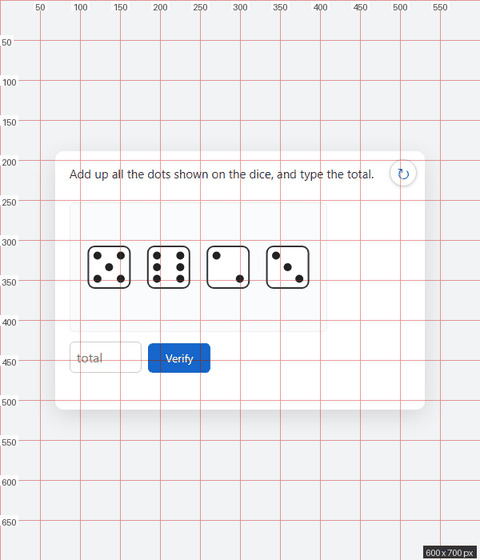

**dice_count | solved | 3 steps | robotic=0.00 | ep_1787343052_ef2ba4**

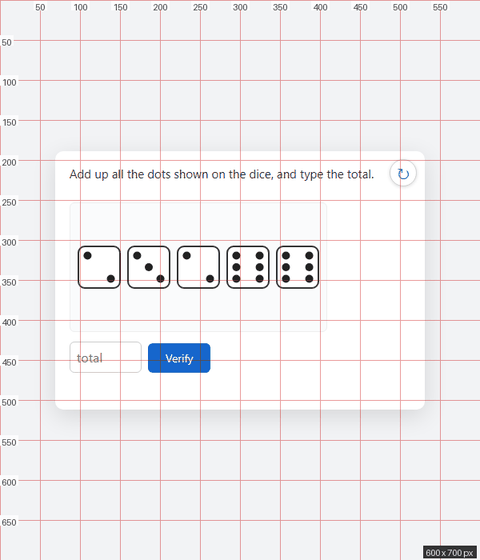

**dice_count | solved | 3 steps | robotic=0.00 | ep_1787343021_c47696**

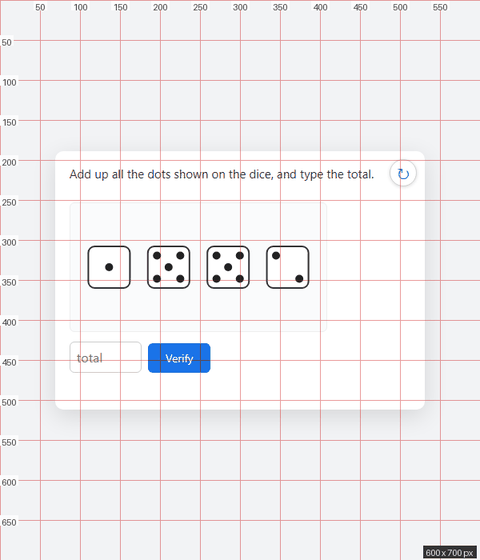

**threed_shape | solved | 1 steps | robotic=0.00 | ep_1787342991_d8485e**

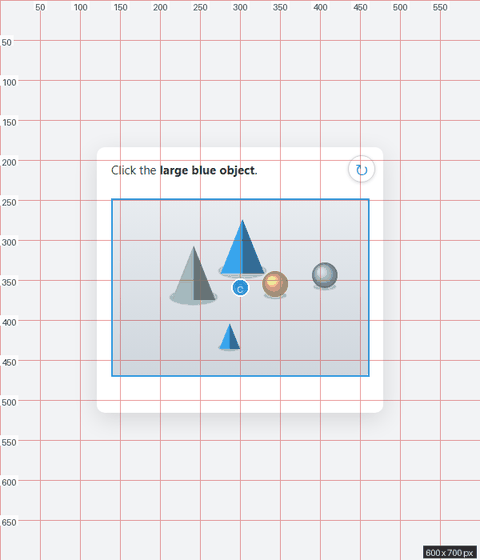

**threed_shape | solved | 1 steps | robotic=0.00 | ep_1787342963_40e19d**

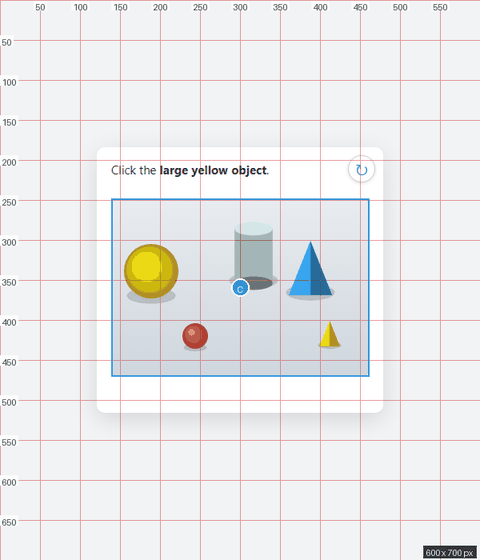

**threed_shape | solved | 2 steps | robotic=0.00 | ep_1787342920_9ce622**

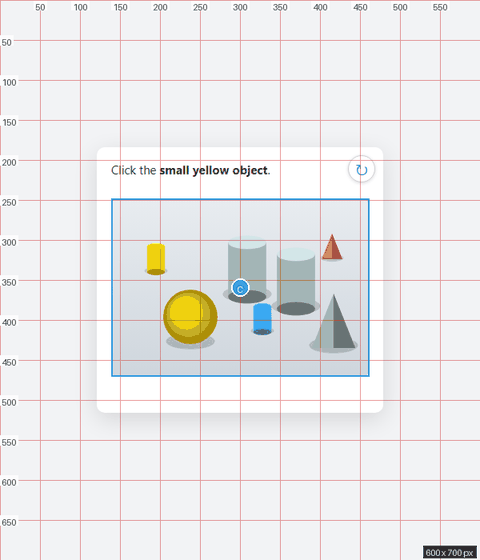

**bingo_swap | solved | 2 steps | robotic=0.00 | ep_1787342835_6c2f2e**

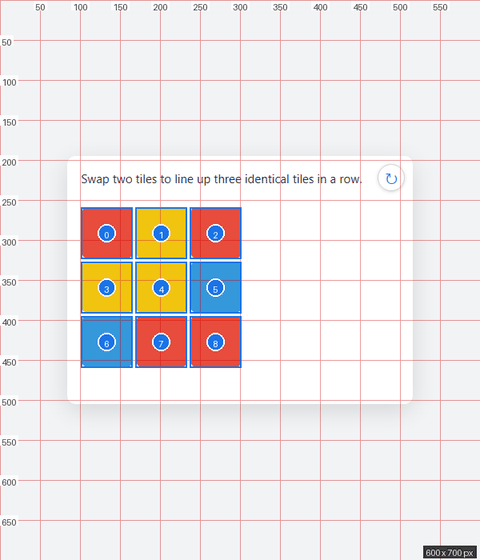

**bingo_swap | solved | 2 steps | robotic=0.00 | ep_1787342794_aa7a68**

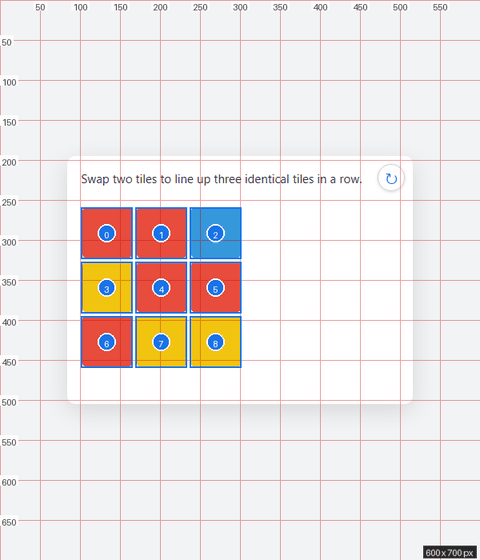

**bingo_swap | solved | 2 steps | robotic=0.00 | ep_1787342750_17319a**

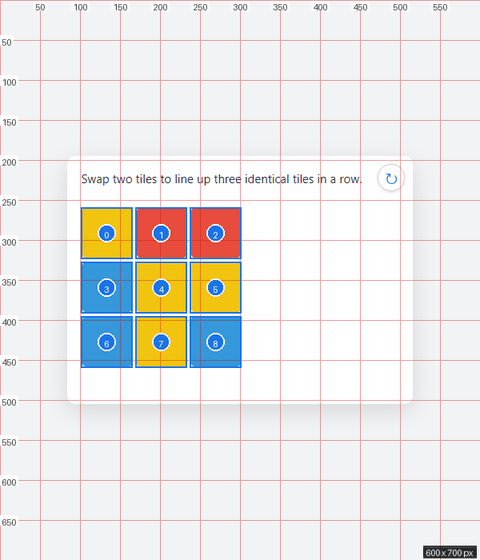

**arithmetic | solved | 3 steps | robotic=0.00 | ep_1787342709_d96f23**

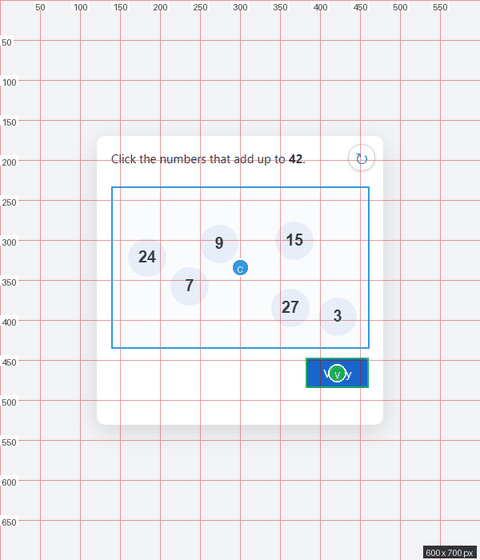

**arithmetic | solved | 10 steps | robotic=0.00 | ep_1787342290_0b3980**

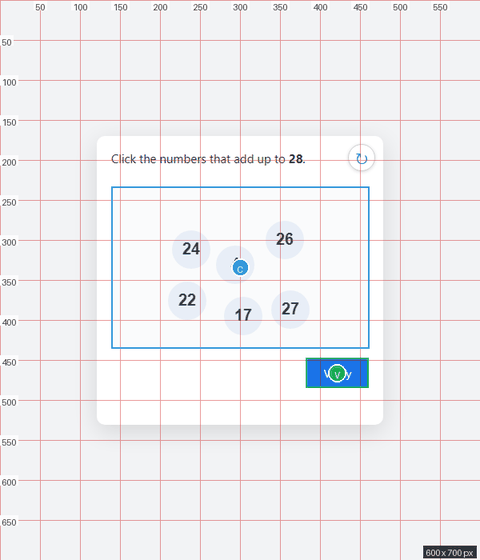

**arithmetic | failed | 12 steps | robotic=0.00 | ep_1787341542_acaac5**

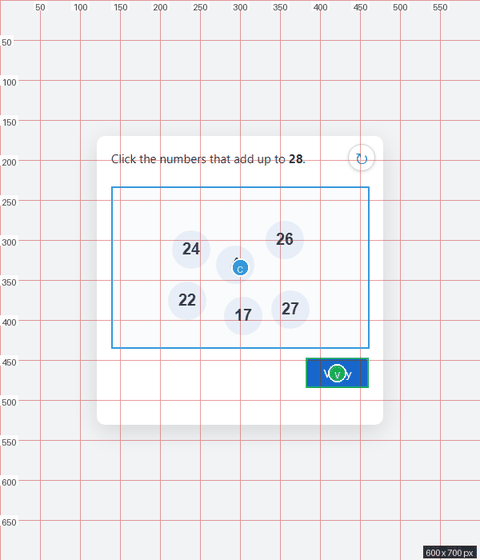

In [28]:
from IPython.display import display, Image as IPyImage, Markdown

MAX_GIFS_TO_SHOW = 12

gifs = sorted(LOGS_DIR.glob("ep_*/episode.gif"),
              key=lambda p: p.stat().st_mtime, reverse=True)
if not gifs:
    display(Markdown("*No episode GIFs yet. Run the benchmark cell first.*"))
else:
    show = gifs if MAX_GIFS_TO_SHOW is None else gifs[:MAX_GIFS_TO_SHOW]
    display(Markdown(f"Showing **{len(show)}** of {len(gifs)} episode GIF(s):"))
    for gp in show:
        meta_path = gp.parent / "meta.json"
        caption = gp.parent.name
        if meta_path.exists():
            try:
                meta = json.loads(meta_path.read_text())
                ok = "solved" if meta.get("success") else "failed"
                caption = (f"{meta.get('captcha_type','?')} | {ok} | "
                           f"{meta.get('num_steps','?')} steps | "
                           f"robotic={meta.get('episode_robotic_score',0):.2f} | {gp.parent.name}")
            except Exception:
                pass
        display(Markdown(f"**{caption}**"))
        display(IPyImage(filename=str(gp)))

## 19. Results analysis

In [29]:
# Success and motion quality by CAPTCHA type, against MCA-Bench references.
by_captcha = {}
for r in all_multi:
    d = by_captcha.setdefault(r.captcha_type, {"solved": 0, "total": 0, "reward": 0.0})
    d["total"] += 1; d["solved"] += int(r.solved); d["reward"] += r.total_reward

# Mean robotic score per type from the episode metas.
robotic_by_type = {}
for ep_dir in LOGS_DIR.glob("ep_*"):
    mp = ep_dir / "meta.json"
    if not mp.exists(): continue
    try: meta = json.loads(mp.read_text())
    except Exception: continue
    ct = meta.get("captcha_type")
    rs = meta.get("episode_robotic_score", 0.0)
    if ct and rs:
        robotic_by_type.setdefault(ct, []).append(rs)

print(f"{'CAPTCHA type':<18}{'solved':>9}{'rate':>7}{'reward':>9}{'robotic':>9}{'VLM ref':>9}")
print("-" * 61)
for ct, d in by_captcha.items():
    rate = d["solved"]/d["total"] if d["total"] else 0
    avg = d["reward"]/d["total"] if d["total"] else 0
    rob = (sum(robotic_by_type[ct])/len(robotic_by_type[ct])) if robotic_by_type.get(ct) else float("nan")
    vlm_ref = CAPTCHA_DIFFICULTY.get(ct, (None, None))[0]
    vlm_s = f"{vlm_ref:.2f}" if vlm_ref is not None else "-"
    rob_s = f"{rob:.2f}" if rob == rob else "-"
    print(f"{ct:<18}{d['solved']:>4}/{d['total']:<4}{rate:>6.0%}{avg:>+9.2f}{rob_s:>9}{vlm_s:>9}")

tot_s = sum(d["solved"] for d in by_captcha.values())
tot_t = sum(d["total"] for d in by_captcha.values())
print("-" * 61)
print(f"{'OVERALL':<18}{tot_s:>4}/{tot_t:<4}{tot_s/max(tot_t,1):>6.0%}")

CAPTCHA type         solved   rate   reward  robotic  VLM ref
-------------------------------------------------------------
checkbox             3/3     100%    +0.90        -        -
image_grid           3/3     100%    +0.75        -     0.96
slider_puzzle        2/3      67%    -0.15     1.00        -
text_captcha         3/3     100%    +0.40        -     0.70
rotation             2/3      67%    -0.68     1.00        -
sequential_click     3/3     100%    +0.83        -     0.93
inverted_letter      2/3      67%    -0.30        -     0.52
hollow_shape         3/3     100%    +0.47        -     0.99
geometric_shape      3/3     100%    +0.95        -     0.96
brightness           3/3     100%    +0.48        -     0.67
arithmetic           3/3     100%    +0.53        -        -
bingo_swap           3/3     100%    +0.90        -        -
threed_shape         3/3     100%    +0.93        -        -
dice_count           3/3     100%    +0.85        -        -
----------------------

<BarContainer object of 14 artists>

<BarContainer object of 14 artists>

[Text(0, 0, 'checkbox'),
 Text(1, 0, 'image_grid'),
 Text(2, 0, 'slider_puzzle'),
 Text(3, 0, 'text_captcha'),
 Text(4, 0, 'rotation'),
 Text(5, 0, 'sequential_click'),
 Text(6, 0, 'inverted_letter'),
 Text(7, 0, 'hollow_shape'),
 Text(8, 0, 'geometric_shape'),
 Text(9, 0, 'brightness'),
 Text(10, 0, 'arithmetic'),
 Text(11, 0, 'bingo_swap'),
 Text(12, 0, 'threed_shape'),
 Text(13, 0, 'dice_count')]

(0.0, 1.0)

Text(0, 0.5, 'success rate')

...

C:\Users\diego\AppData\Local\Temp\ipykernel_47468\861424703.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(types, rotation=60, ha="right", fontsize=8)


[Text(0, 0, 'checkbox'),
 Text(1, 0, 'image_grid'),
 Text(2, 0, 'slider_puzzle'),
 Text(3, 0, 'text_captcha'),
 Text(4, 0, 'rotation'),
 Text(5, 0, 'sequential_click'),
 Text(6, 0, 'inverted_letter'),
 Text(7, 0, 'hollow_shape'),
 Text(8, 0, 'geometric_shape'),
 Text(9, 0, 'brightness'),
 Text(10, 0, 'arithmetic'),
 Text(11, 0, 'bingo_swap'),
 Text(12, 0, 'threed_shape'),
 Text(13, 0, 'dice_count')]

(0.0, 1.0)

Text(0, 0.5, 'mean robotic score')

Text(0.5, 1.0, 'Motion quality (1 = robotic, would fail motor-control CAPTCHA)')

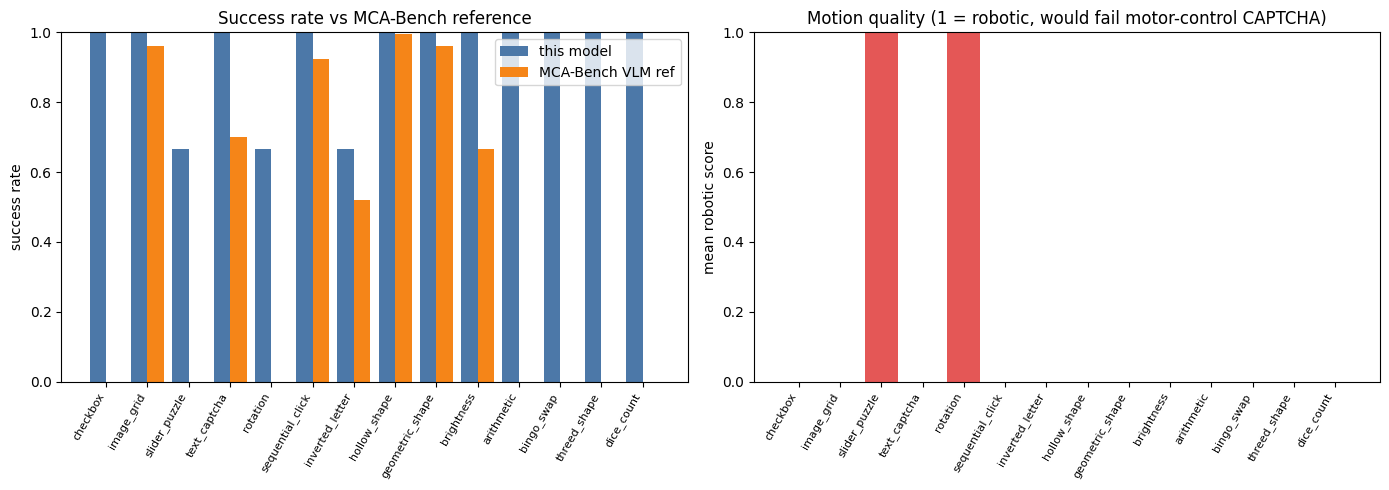

In [30]:
import matplotlib.pyplot as plt

types = list(by_captcha.keys())
rates = [by_captcha[t]["solved"]/by_captcha[t]["total"] if by_captcha[t]["total"] else 0 for t in types]
vlm_refs = [CAPTCHA_DIFFICULTY.get(t, (0, 0))[0] or 0 for t in types]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
import numpy as _np
xpos = _np.arange(len(types))
ax1.bar(xpos - 0.2, rates, 0.4, label="this model", color="#4C78A8")
ax1.bar(xpos + 0.2, vlm_refs, 0.4, label="MCA-Bench VLM ref", color="#F58518")
ax1.set_xticks(xpos); ax1.set_xticklabels(types, rotation=60, ha="right", fontsize=8)
ax1.set_ylim(0, 1); ax1.set_ylabel("success rate"); ax1.legend()
ax1.set_title("Success rate vs MCA-Bench reference")

robs = [(sum(robotic_by_type[t])/len(robotic_by_type[t])) if robotic_by_type.get(t) else 0 for t in types]
ax2.bar(types, robs, color="#E45756")
ax2.set_xticklabels(types, rotation=60, ha="right", fontsize=8)
ax2.set_ylim(0, 1); ax2.set_ylabel("mean robotic score")
ax2.set_title("Motion quality (1 = robotic, would fail motor-control CAPTCHA)")
plt.tight_layout(); plt.show()

## 20. Train the routing policy on all collected data

Runs automatically after the benchmark. Reads every schema-v2 trajectory,
trains the per-type routing policy, and writes `learned_policy.json`, which
Section 8 loads on the next run. Run the benchmark a few times and re-run this to
improve the policy — it always trains on the full accumulated set.

In [31]:
policy_payload = train_all_and_export(LOGS_DIR, WORK_DIR / "learned_policy.json")

# Research artifact: dump every step's chain-of-thought + tool choice so the
# paper can analyse HOW the model reasons and picks tools on each puzzle.
reasoning_entries = export_reasoning_traces(LOGS_DIR, WORK_DIR / "reasoning_traces.json")

# Did the model's own code actually run? Audit every run_image_code / run_js /
# run_python call, with the full text of any failure so it can be fixed.
code_records = export_code_execution_report(LOGS_DIR, WORK_DIR / "code_execution_report.json")

# Reload the freshly trained policy and make it live immediately: update the
# module global AND the orchestrator instance, so the very next benchmark run
# uses it automatically (the benchmark cell also re-reads it from disk on start).
LEARNED_POLICY = load_learned_policy()
globals()["LEARNED_POLICY"] = LEARNED_POLICY
try:
    orchestrator.learned_policy = LEARNED_POLICY
except Exception:
    pass
if LEARNED_POLICY and LEARNED_POLICY.get("orderings"):
    n = len(LEARNED_POLICY.get("orderings", {}))
    print(f"\nlearned_policy.json now covers {n} CAPTCHA type(s), saved to "
          f"{(WORK_DIR / 'learned_policy.json')}.")
    print("It is now LIVE: the next run of the benchmark cell will load it from "
          "disk automatically and feed the learned tool-order hint to the model. "
          "You do not need to change anything — just run the benchmark again.")
else:
    print("\nNot enough data to train a policy yet. Run the benchmark for more "
          "trials (or more CAPTCHA types), then run this cell again.")

Loaded 53 episode(s), 339 step(s) (schema v2).
Global pooled policy trained on 339 steps (held-out R^2=0.4299, MAE=0.2829).

CAPTCHA type       ok?   ordering (best-first)
------------------------------------------------------------------------------
arithmetic         no    click_selector > click_at > zoom_region > run_image_code
bingo_swap         no    click_at > click_selector
brightness         no    click_selector > sample_color > click_at > double_click
checkbox           no    wait > click_at
dice_count         no    click_selector > type_text > zoom_region
geometric_shape    no    click_at
hollow_shape       no    run_image_code > click_at > click_selector > double_click
image_grid         no    click_selector > run_image_code > click_at > zoom_region
inverted_letter    no    click_at > zoom_region > flip_region > click_selector
rotation           no    wait > drag > click_selector > click_at
sequential_click   no    click_at > zoom_region
slider_puzzle      no    zoom_region 

## 21. Inspect memory and reflections

Shows what the model accumulated and reflected on across attempts for a given
instance.

In [32]:
from IPython.display import display, Markdown
import json as _json

CAPTCHA_TYPE = "slider_puzzle"   # change me
PUZZLE_SEED = None               # or an int


def show_memory(captcha_type, puzzle_seed=None):
    files = sorted(MEMORY_DIR.glob(f"mem_*_{captcha_type}.json"))
    if not files:
        display(Markdown(f"*No memory files for `{captcha_type}`.*")); return
    display(Markdown(f"# Memory for `{captcha_type}` (seed={puzzle_seed})"))
    for f in files:
        try: m = _json.loads(f.read_text())
        except Exception: continue
        if puzzle_seed is not None and m.get("puzzle_seed") != puzzle_seed:
            continue
        display(Markdown(f"## `{f.name}` — {len(m.get('attempts', []))} attempt(s)"))
        for i, a in enumerate(m.get("attempts", []), 1):
            outcome = "SUCCESS" if a.get("success") else "FAIL"
            display(Markdown(f"### Attempt {i}: {outcome} "
                             f"(reward={a.get('total_reward',0):+.2f}, {a.get('num_steps','?')} steps)"))
            acts = a.get("actions_taken", []) or []
            if acts:
                display(Markdown("**Actions:** " + " | ".join(f"`{x}`" for x in acts[:8])))
            if a.get("reflection"):
                display(Markdown(f"**Reflection:**\n```\n{a['reflection'][:1200]}\n```"))


show_memory(CAPTCHA_TYPE, PUZZLE_SEED)

# Memory for `slider_puzzle` (seed=None)

## `mem_1787320066_slider_puzzle.json` — 1 attempt(s)

### Attempt 1: SUCCESS (reward=+0.85, 3 steps)

**Actions:** `drag(from_x=168, from_y=452, to_x=298, to_y=452, steps=30)` | `zoom_region(x=148, y=237, w=300, h=180)` | `drag(from_x=298, from_y=452, to_x=393, to_y=452, steps=30)`

## `mem_1787322809_slider_puzzle.json` — 3 attempt(s)

...

### Attempt 3: FAIL (reward=-0.70, 12 steps)

**Actions:** `run_image_code(code=import numpy as np
g = np.a...)` | `run_image_code(code=import numpy as np
a = np.a...)` | `run_image_code(code=import numpy as np
g = np.a...)` | `drag(from_x=167, from_y=443, to_x=330, to_y=443, steps=25)` | `drag(from_x=332, from_y=455, to_x=348, to_y=455, steps=15)` | `run_image_code(code=import numpy as np
a = np.a...)` | `drag(from_x=331, from_y=466, to_x=347, to_y=466, steps=15)` | `click_selector(selector=.slider-handle)`

## `mem_1787323020_slider_puzzle.json` — 1 attempt(s)

### Attempt 1: SUCCESS (reward=+0.80, 4 steps)

**Actions:** `zoom_region(x=140, y=230, w=320, h=185)` | `run_image_code(code=import numpy as np
from PIL...)` | `drag(from_x=172, from_y=448, to_x=292, to_y=448, steps=30)` | `drag(from_x=292, from_y=448, to_x=328, to_y=448, steps=30)`

## 22. Optional: fine-tune a language model on the trajectories

The routing policy in Section 20 is the mandatory learner and needs no GPU. If
you also want to fine-tune an actual model (SFT then DPO/GRPO) on the same
trajectories, the shape of that pipeline is below. Off by default.

In [33]:
# Optional LoRA fine-tuning sketch. Off by default — needs a GPU and a training
# stack. The routing policy above already closes the learning loop without either.
RUN_LORA_FINETUNE = False

if RUN_LORA_FINETUNE:
    # 1. Build an SFT dataset from successful trajectories: each example is
    #    (prompt with screenshot + context) -> (tool call the model should make).
    # 2. Supervised fine-tune a small VLM on those with LoRA adapters.
    # 3. Optionally DPO/GRPO using (success, motor robotic_score) as the
    #    preference signal, so the model learns to solve AND move less robotically.
    print("LoRA fine-tuning would run here (SFT -> DPO/GRPO). Not enabled.")
else:
    print("LoRA fine-tuning is off. The routing policy (Section 20) is the active learner.")

LoRA fine-tuning is off. The routing policy (Section 20) is the active learner.


## 23. Cleanup

In [34]:
try:
    agent.stop(); print("Browser closed.")
except Exception as e:
    print(f"Browser cleanup note: {e}")
try:
    stop_server(); print("Server stopped.")
except Exception as e:
    print(f"Server cleanup note: {e}")

Browser closed.
Server stopped.
